# Cholera Early Warning in Kenya

## Explainable machine learning for county-level outbreak prediction

This notebook documents the full analytical workflow used to study short-term cholera outbreak prediction across Kenya's 47 counties using weekly data from 2015 to 2025.

The analysis is organised to make each stage transparent: data preparation, descriptive epidemiology, target construction, chronological validation, ARIMA and machine-learning models, threshold selection, calibration, sensitivity analyses, uncertainty estimation, model comparison and SHAP interpretation.

The primary prediction task is to estimate whether a county will meet the study-specific outbreak criterion three weeks ahead, using only information available at the prediction week. The main analytical outbreak rule is **at least five reported cholera cases in the future county-week**.

Key modelling choices used throughout the main analysis are:

- primary horizon: **3 weeks**;
- XGBoost estimators: **300**;
- maximum tree depth: **2**;
- learning rate: **0.03**;
- subsample: **0.80**;
- column sample: **0.80**;
- positive-class weight: **6**;
- classification threshold: **0.50**;
- random seed: **42**.

The notebook retains the full sequence of analyses so that the modelling decisions and the interpretation of results can be followed from beginning to end.


## Key analytical choices used in the main three-week model

The primary model uses the following fixed specification:

- 47 Kenyan counties, weekly observations from 2015–2025;
- 26,978 county-week records in the complete panel;
- 26,508 observations in the primary three-week modelling sample;
- 23 predictors;
- chronological target-date split:
  - training: 2015–2022,
  - validation: 2023–2024,
  - independent test: 2025;
- 2,397 observations in the 2025 test period;
- 705 outbreak and 1,692 non-outbreak observations;
- XGBoost:
  - 300 estimators,
  - maximum depth 2,
  - learning rate 0.03,
  - subsample 0.80,
  - column sample 0.80,
  - positive-class weight 6,
  - threshold 0.50,
  - random seed 42.

These settings are kept fixed for the reported three-week evaluation and for the two- and four-week horizon comparison.


## Analysis roadmap

The analysis is organised so that each modelling decision can be traced back to the data and evaluated on observations that occur later in time. I first establish the structure and quality of the dataset, then construct the three-week target and predictors, preserve temporal order in the train–validation–test split, compare candidate models, and only then evaluate the selected specification on 2025.

The primary 2025 XGBoost evaluation uses the locked specification shown above and the 0.50 threshold selected during validation. The notebook also includes calibration, SHAP interpretation, alternative outbreak definitions, a model without calendar year, expanding-window evaluation, paired ARIMA comparison, bootstrap uncertainty and multi-horizon checks.



Mounted at /content/drive
Files extracted:
  kenya_cholera_county_week_feature_matrix.csv
  README.txt
  kenya_cholera_county_week_raw.csv
  data_dictionary.csv
Kenya Cholera Early Warning Dataset
Grace Kitonyi MSc thesis roadmap: Early Warning Prediction of Cholera Outbreaks in Kenya Using Machine Learning and Climate Indicators.

Coverage:
- 47 Kenya counties
- Weekly county panel, 2015–2025
- Cholera cases, deaths, incidence
- Climate/environmental indicators: rainfall, temperature, flood indicator, NDVI, drought index
- WASH vulnerability proxy
- Feature matrix with lagged rainfall, lagged temperature, rolling rainfall, interaction term, seasonality, outbreak labels and h=2,3,4 prediction targets

Recommended thesis split:
- Train: 2015–2022
- Validate: 2023–2024
- Test: 2025

Outbreak:
- outbreak_current = 1 if weekly cases >= 5 or weekly incidence >= 1 per 100,000.
- Future labels outbreak_h2, outbreak_h3, outbreak_h4 support 2-, 3-, and 4-week early warning prediction.

Files:
1

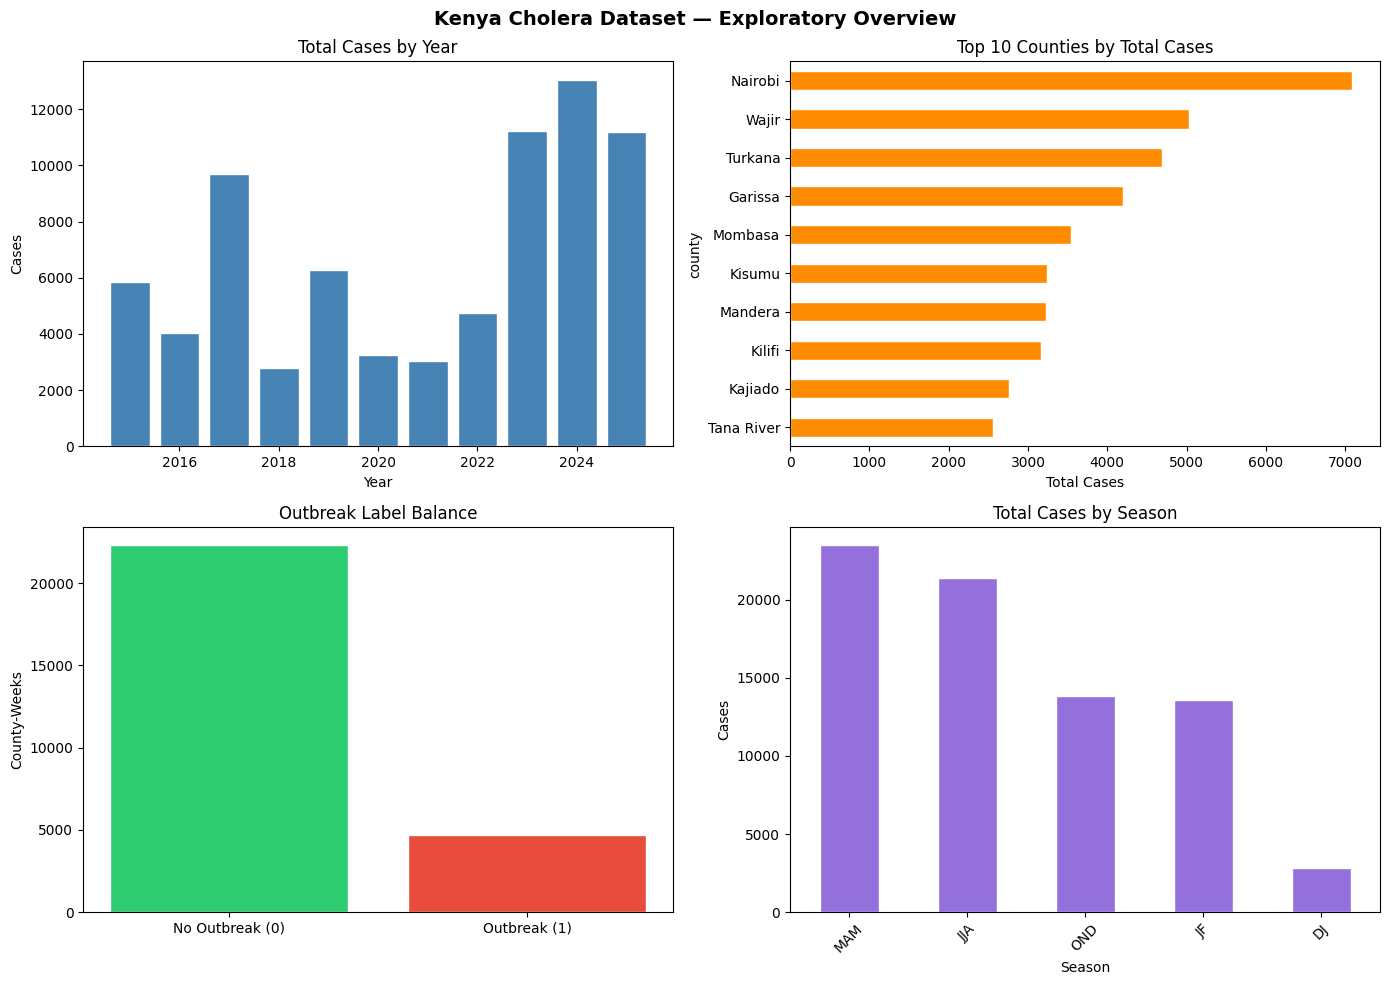

Plot saved to your Drive.


In [1]:
# Reproducible data loading and initial structure checks

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Unzip the dataset
# Change the path below to wherever the zip is in your Drive
import zipfile
import os

zip_path = '/content/drive/MyDrive/Kenya_Cholera_Datasets.zip'
extract_path = '/content/kenya_cholera'

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("Files extracted:")
for f in os.listdir(extract_path + '/Kenya_Cholera_Datasets'):
    print(' ', f)

# Load the datasets
import pandas as pd

data_dir = extract_path + '/Kenya_Cholera_Datasets/'

raw     = pd.read_csv(data_dir + 'kenya_cholera_county_week_raw.csv')
feat    = pd.read_csv(data_dir + 'kenya_cholera_county_week_feature_matrix.csv')
ddict   = pd.read_csv(data_dir + 'data_dictionary.csv')

with open(data_dir + 'README.txt', 'r') as f:
    print(f.read())

# Basic structure
print("=" * 50)
print("RAW DATASET")
print("=" * 50)
print(f"Shape: {raw.shape}")
print(f"Counties: {raw['county'].nunique()}")
print(f"Years: {raw['year'].min()} - {raw['year'].max()}")
print(f"Columns:\n{raw.columns.tolist()}")
print(raw.head())

print("\n" + "=" * 50)
print("FEATURE MATRIX")
print("=" * 50)
print(f"Shape: {feat.shape}")
print(f"Columns:\n{feat.columns.tolist()}")
print(feat.head())

print("\n" + "=" * 50)
print("DATA DICTIONARY")
print("=" * 50)
print(ddict.to_string())

# Summary statistics
print("\n" + "=" * 50)
print("SUMMARY STATISTICS — RAW")
print("=" * 50)
print(raw.describe())

print("\n" + "=" * 50)
print("SUMMARY STATISTICS — FEATURE MATRIX")
print("=" * 50)
print(feat.describe())

# Missing values
print("\n" + "=" * 50)
print("MISSING VALUES — RAW")
print("=" * 50)
print(raw.isnull().sum())

print("\n" + "=" * 50)
print("MISSING VALUES — FEATURE MATRIX")
print("=" * 50)
print(feat.isnull().sum())

# Outbreak label distribution
print("\n" + "=" * 50)
print("OUTBREAK LABEL DISTRIBUTION")
print("=" * 50)
print("outbreak_current:")
print(feat['outbreak_current'].value_counts())
print(f"Positive rate: {feat['outbreak_current'].mean()*100:.1f}%")

print("\noutbreak_h2:")
print(feat['outbreak_h2'].value_counts())

print("\noutbreak_h3:")
print(feat['outbreak_h3'].value_counts())

print("\noutbreak_h4:")
print(feat['outbreak_h4'].value_counts())

# Cases by county (top 10)
print("\n" + "=" * 50)
print("TOP 10 COUNTIES BY TOTAL CASES")
print("=" * 50)
top_counties = (raw.groupby('county')['cholera_cases']
                   .sum()
                   .sort_values(ascending=False)
                   .head(10))
print(top_counties)

# Cases by year
print("\n" + "=" * 50)
print("TOTAL CASES BY YEAR")
print("=" * 50)
by_year = (raw.groupby('year')['cholera_cases']
              .sum()
              .reset_index())
print(by_year)

# Cases by season
print("\n" + "=" * 50)
print("TOTAL CASES BY SEASON")
print("=" * 50)
by_season = (raw.groupby('season')['cholera_cases']
                .sum()
                .sort_values(ascending=False))
print(by_season)

# Quick visualisations
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Kenya Cholera Dataset — Exploratory Overview',
             fontsize=14, fontweight='bold')

# Plot 1: Cases by year
axes[0, 0].bar(by_year['year'], by_year['cholera_cases'],
               color='steelblue', edgecolor='white')
axes[0, 0].set_title('Total Cases by Year')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Cases')

# Plot 2: Top 10 counties
top_counties.plot(kind='barh', ax=axes[0, 1],
                  color='darkorange', edgecolor='white')
axes[0, 1].set_title('Top 10 Counties by Total Cases')
axes[0, 1].set_xlabel('Total Cases')
axes[0, 1].invert_yaxis()

# Plot 3: Outbreak label balance
outbreak_counts = feat['outbreak_current'].value_counts()
axes[1, 0].bar(['No Outbreak (0)', 'Outbreak (1)'],
               outbreak_counts.values,
               color=['#2ecc71', '#e74c3c'],
               edgecolor='white')
axes[1, 0].set_title('Outbreak Label Balance')
axes[1, 0].set_ylabel('County-Weeks')

# Plot 4: Cases by season
by_season.plot(kind='bar', ax=axes[1, 1],
               color='mediumpurple', edgecolor='white')
axes[1, 1].set_title('Total Cases by Season')
axes[1, 1].set_xlabel('Season')
axes[1, 1].set_ylabel('Cases')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cholera_eda_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to your Drive.")


**Interpretation.** The project files are loaded successfully and the supplied documentation is visible at the start of the workflow. I keep this step first so that the analysis can be traced back to the original study files before any transformations are made.


## 1. Data documentation and provenance

Before analysing the numbers, I inspect the supplied data dictionary and README. This is important because variable names alone do not always explain how an indicator was constructed or where it came from.

Where the supplied documentation does not identify an upstream source with enough certainty, I keep the description limited to what can be verified directly from the study files. This avoids assigning a source that cannot be supported from the available documentation.


In [2]:
import pandas as pd

data_dictionary_path = "/content/kenya_cholera/Kenya_Cholera_Datasets/data_dictionary.csv"

data_dictionary = pd.read_csv(data_dictionary_path)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

data_dictionary


,variable,description,unit/type
0,county,Kenya county name; standard 47-county list,text
1,region,Broad Kenya region used for synthetic climate/risk patterning,text
2,population_2019,County population denominator approximating 2019 census values,persons
3,year,ISO epidemiological year,integer
4,epi_week,ISO epidemiological week,Jan-53
5,week_start_date,Monday date for the ISO epidemiological week,date
6,season,"Season grouping: JF, MAM, JJA, OND, DJ",category
7,rainfall_mm,weekly rainfall by Kenyan seasonal rainfall patterns,millimetres/week
8,mean_temp_c,weekly mean temperature by county climate zone,degrees Celsius
9,flood_indicator,indicator for unusually high rainfall/flood-prone week,0/1


**Interpretation.** The data dictionary gives the meaning and expected format of the main variables. I use it as a reference for later checks rather than relying only on column names.


In [3]:
important_variables = [
    "rainfall_mm",
    "mean_temp_c",
    "flood_indicator",
    "ndvi",
    "drought_index",
    "wash_vulnerability_index"
]

important_dictionary_rows = data_dictionary[
    data_dictionary.astype(str).apply(
        lambda row: row.str.contains("|".join(important_variables), case=False, na=False).any(),
        axis=1
    )
]

important_dictionary_rows


,variable,description,unit/type
7,rainfall_mm,weekly rainfall by Kenyan seasonal rainfall patterns,millimetres/week
8,mean_temp_c,weekly mean temperature by county climate zone,degrees Celsius
9,flood_indicator,indicator for unusually high rainfall/flood-prone week,0/1
10,ndvi,vegetation/wetness proxy,0-1 index
11,drought_index,dryness/aridity proxy,0-1 index
12,wash_vulnerability_index,county-level WASH vulnerability,0-1 index


**Interpretation.** This subset highlights the climatic, environmental and structural variables that are central to the forecasting question. Checking their definitions early helps avoid confusing similarly named indicators later in the notebook.


In [4]:
readme_path = "/content/kenya_cholera/Kenya_Cholera_Datasets/README.txt"

with open(readme_path, "r") as file:
    readme_text = file.read()

print(readme_text)


Kenya Cholera Early Warning Dataset
Grace Kitonyi MSc thesis roadmap: Early Warning Prediction of Cholera Outbreaks in Kenya Using Machine Learning and Climate Indicators.

Coverage:
- 47 Kenya counties
- Weekly county panel, 2015–2025
- Cholera cases, deaths, incidence
- Climate/environmental indicators: rainfall, temperature, flood indicator, NDVI, drought index
- WASH vulnerability proxy
- Feature matrix with lagged rainfall, lagged temperature, rolling rainfall, interaction term, seasonality, outbreak labels and h=2,3,4 prediction targets

Recommended thesis split:
- Train: 2015–2022
- Validate: 2023–2024
- Test: 2025

Outbreak:
- outbreak_current = 1 if weekly cases >= 5 or weekly incidence >= 1 per 100,000.
- Future labels outbreak_h2, outbreak_h3, outbreak_h4 support 2-, 3-, and 4-week early warning prediction.

Files:
1. kenya_cholera_county_week_raw.csv
2. kenya_cholera_county_week_feature_matrix.csv
3. data_dictionary.csv



**Interpretation.** The README confirms the intended county-week structure and the broad scope of the supplied dataset. The outbreak wording in this documentation is treated as background information; the primary target used below is reconstructed explicitly from future weekly case counts.


### Note on the outbreak labels supplied with the data

The supplied documentation includes an earlier composite outbreak rule based on either case counts or incidence. For this analysis, the **primary outcome is reconstructed as a future county-week with at least five reported cholera cases**.

The broader rule — **cases ≥ 5 OR incidence ≥ 1 per 100,000 population** — is not discarded. It is examined later as a sensitivity analysis so that I can see whether the main findings depend strongly on the analytical outbreak definition.

Keeping these two definitions separate is important: the primary model answers one clearly defined forecasting question, while the broader rule provides a robustness check.


## 2. Data quality and descriptive checks

I next examine the raw county-week panel before creating any predictors. These checks cover date conversion, time coverage, county coverage, duplicates, missingness, plausible value ranges and basic cholera burden.

The purpose is simple: a forecasting model can appear technically successful even when the underlying panel contains duplicated weeks, impossible values or incomplete counties. These checks therefore establish whether the data are structurally suitable for longitudinal modelling.


In [5]:
# Convert the week_start_date column into a real date

# The column 'week_start_date' is currently stored as text/object.
# For time-series analysis, Python must understand it as a real date.
# pd.to_datetime() converts text dates like "12/29/2014" into datetime format.
raw["week_start_date"] = pd.to_datetime(raw["week_start_date"])

# This checks the new data type of the column.
# We want to see: datetime64[ns]
print("Data type of week_start_date after conversion:")
print(raw["week_start_date"].dtype)

# This displays the first few rows of the year, epi_week, and week_start_date columns.
# It helps us confirm that the date conversion worked correctly.
print("\nFirst few time columns:")
print(raw[["year", "epi_week", "week_start_date"]].head())


Data type of week_start_date after conversion:
datetime64[ns]

First few time columns:
   year  epi_week week_start_date
0  2015         1      2014-12-29
1  2015         2      2015-01-05
2  2015         3      2015-01-12
3  2015         4      2015-01-19
4  2015         5      2015-01-26


**Interpretation.** Converting `week_start_date` to a true datetime variable is essential for chronological splitting and lag construction. The first rows also show that epidemiological week 1 can begin in the previous calendar year, which is one reason target-date splitting is used later.


In [6]:
# Check the time coverage of the raw dataset

# This gives the earliest week_start_date in the dataset.
# It tells us when the dataset begins.
start_date = raw["week_start_date"].min()

# This gives the latest week_start_date in the dataset.
# It tells us when the dataset ends.
end_date = raw["week_start_date"].max()

# This gives all unique years available in the dataset.
# sorted() arranges the years from smallest to largest.
years_available = sorted(raw["year"].unique())

# Print the results clearly.
print("Dataset start date:", start_date)
print("Dataset end date:", end_date)
print("Years available:", years_available)
print("Number of years:", len(years_available))


Dataset start date: 2014-12-29 00:00:00
Dataset end date: 2025-12-22 00:00:00
Years available: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Number of years: 11


**Interpretation.** The panel spans the full intended study period. The first predictor week starts on 29 December 2014 because it represents epidemiological week 1 of 2015, while the study-year field covers 2015–2025.


In [7]:
# Check county coverage

# Count how many unique counties are in the dataset.
# This helps confirm whether all 47 Kenyan counties are included.
number_of_counties = raw["county"].nunique()

# Get the list of county names.
# sorted() arranges them alphabetically.
county_list = sorted(raw["county"].unique())

# Print the results clearly.
print("Number of unique counties:", number_of_counties)

print("\nCounty list:")
for county in county_list:
    print(county)


Number of unique counties: 47

County list:
Baringo
Bomet
Bungoma
Busia
Elgeyo-Marakwet
Embu
Garissa
Homa Bay
Isiolo
Kajiado
Kakamega
Kericho
Kiambu
Kilifi
Kirinyaga
Kisii
Kisumu
Kitui
Kwale
Laikipia
Lamu
Machakos
Makueni
Mandera
Marsabit
Meru
Migori
Mombasa
Murang'a
Nairobi
Nakuru
Nandi
Narok
Nyamira
Nyandarua
Nyeri
Samburu
Siaya
Taita Taveta
Tana River
Tharaka-Nithi
Trans Nzoia
Turkana
Uasin Gishu
Vihiga
Wajir
West Pokot


**Interpretation.** All **47 Kenyan counties** are present. This confirms national county coverage before any modelling filters are applied.


In [8]:
# Check number of weekly observations per county

# Count how many rows each county has.
# Each row is one county-week observation.
county_counts = raw["county"].value_counts().sort_index()

# Display the number of observations per county.
print("Number of observations per county:")
print(county_counts)

# Check the minimum and maximum number of rows across counties.
# If both are the same, then all counties have equal weekly coverage.
print("\nMinimum rows for a county:", county_counts.min())
print("Maximum rows for a county:", county_counts.max())

# Check whether all counties have exactly the same number of observations.
same_coverage = county_counts.min() == county_counts.max()

print("\nDo all counties have the same number of weekly observations?")
print(same_coverage)


Number of observations per county:
county
Baringo            574
Bomet              574
Bungoma            574
Busia              574
Elgeyo-Marakwet    574
Embu               574
Garissa            574
Homa Bay           574
Isiolo             574
Kajiado            574
Kakamega           574
Kericho            574
Kiambu             574
Kilifi             574
Kirinyaga          574
Kisii              574
Kisumu             574
Kitui              574
Kwale              574
Laikipia           574
Lamu               574
Machakos           574
Makueni            574
Mandera            574
Marsabit           574
Meru               574
Migori             574
Mombasa            574
Murang'a           574
Nairobi            574
Nakuru             574
Nandi              574
Narok              574
Nyamira            574
Nyandarua          574
Nyeri              574
Samburu            574
Siaya              574
Taita Taveta       574
Tana River         574
Tharaka-Nithi      574
Trans Nzoia    

**Interpretation.** Each county contributes **574 weekly observations**, confirming a balanced panel. This is useful because later differences in sample size arise from lagged predictors and future-target availability rather than unequal county coverage.


In [9]:
# Check for duplicate county-week records

# A county-week should be unique.
# That means one county should only appear once for each year and epidemiological week.
# If duplicates exist, the same county-week was recorded more than once.

duplicate_count = raw.duplicated(
    subset=["county", "year", "epi_week"]
).sum()

# Print the number of duplicate county-week records.
print("Number of duplicate county-week records:", duplicate_count)

# If duplicates exist, display them for inspection.
if duplicate_count > 0:
    duplicates = raw[raw.duplicated(
        subset=["county", "year", "epi_week"],
        keep=False
    )].sort_values(["county", "year", "epi_week"])

    display(duplicates)
else:
    print("No duplicate county-week records found.")


Number of duplicate county-week records: 0
No duplicate county-week records found.


**Interpretation.** No duplicate county-week records are found. This means a single county-week is not unintentionally counted more than once in descriptive summaries or model fitting.


In [10]:
# Check missing values in the raw dataset

# Count missing values in each column.
# A missing value means a blank/NaN value in the dataset.
missing_counts = raw.isnull().sum()

# Convert missing counts into percentages.
# This tells us what percentage of the dataset is missing for each variable.
missing_percent = (missing_counts / len(raw)) * 100

# Combine counts and percentages into one summary table.
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
})

# Display the missingness summary.
display(missing_summary)

# Count total missing values in the whole dataset.
total_missing = raw.isnull().sum().sum()

print("Total missing values in the raw dataset:", total_missing)


,missing_count,missing_percent
county,0,0.0
region,0,0.0
population_2019,0,0.0
year,0,0.0
epi_week,0,0.0
week_start_date,0,0.0
season,0,0.0
rainfall_mm,0,0.0
mean_temp_c,0,0.0
flood_indicator,0,0.0


Total missing values in the raw dataset: 0


**Interpretation.** The raw panel is inspected for missingness before feature construction. Missingness created later by lags and future targets can therefore be distinguished from missing values already present in the source panel.


In [11]:
# Basic numerical summary of the raw dataset

# Select only numerical columns.
# These are columns containing numbers such as rainfall, temperature, cases, and deaths.
numeric_columns = raw.select_dtypes(include=["int64", "float64"]).columns

# Generate descriptive statistics for numerical columns.
# .describe() gives count, mean, standard deviation, minimum, quartiles, and maximum.
numeric_summary = raw[numeric_columns].describe().T

# Display the numerical summary table.
display(numeric_summary)


,count,mean,std,min,25%,50%,75%,max
population_2019,26978.0,1.012006e+06,685840.845401,143920.00,608599.000,893681.000,1157873.000,4397073.000
year,26978.0,2.019991e+03,3.163701,2015.00,2017.000,2020.000,2023.000,2025.000
epi_week,26978.0,2.659233e+01,15.063595,1.00,14.000,27.000,40.000,53.000
rainfall_mm,26978.0,2.238632e+01,19.387199,0.00,7.900,15.200,34.900,151.000
mean_temp_c,26978.0,2.248416e+01,4.196836,11.30,19.400,22.200,25.400,35.100
flood_indicator,26978.0,3.840166e-02,0.192167,0.00,0.000,0.000,0.000,1.000
ndvi,26978.0,1.675726e-01,0.101554,0.05,0.084,0.149,0.227,0.771
drought_index,26978.0,6.112428e-01,0.319498,0.00,0.394,0.681,0.875,1.000
wash_vulnerability_index,26978.0,2.910774e-01,0.182423,0.10,0.121,0.250,0.404,0.885
cholera_cases,26978.0,2.786159e+00,7.992113,0.00,0.000,1.000,2.000,210.000


**Interpretation.** This summary condenses the preceding calculations into a form that is easier to inspect and compare. I use it to identify the main pattern before moving to the next analytical step.


In [12]:
# Check for impossible or suspicious values

# We create a dictionary where each check has a name and a condition.
# Each condition identifies rows that would be impossible or suspicious.

checks = {
    "negative_cholera_cases": raw["cholera_cases"] < 0,
    "negative_cholera_deaths": raw["cholera_deaths"] < 0,
    "negative_rainfall": raw["rainfall_mm"] < 0,
    "temperature_below_0": raw["mean_temp_c"] < 0,
    "temperature_above_45": raw["mean_temp_c"] > 45,
    "ndvi_outside_0_1": (raw["ndvi"] < 0) | (raw["ndvi"] > 1),
    "drought_index_outside_0_1": (raw["drought_index"] < 0) | (raw["drought_index"] > 1),
    "wash_index_outside_0_1": (raw["wash_vulnerability_index"] < 0) | (raw["wash_vulnerability_index"] > 1),
    "flood_indicator_not_0_or_1": ~raw["flood_indicator"].isin([0, 1])
}

# Count how many rows fail each check.
# If the count is 0, that problem does not exist in the dataset.
for check_name, condition in checks.items():
    print(check_name, ":", condition.sum())


negative_cholera_cases : 0
negative_cholera_deaths : 0
negative_rainfall : 0
temperature_below_0 : 0
temperature_above_45 : 0
ndvi_outside_0_1 : 0
drought_index_outside_0_1 : 0
wash_index_outside_0_1 : 0
flood_indicator_not_0_or_1 : 0


**Interpretation.** The range checks do not identify negative case counts, negative rainfall or values outside the expected ranges for NDVI, drought, WASH and the flood indicator. These checks support the internal plausibility of the variables used later.


In [13]:
# Summarize total cholera cases and deaths

# Calculate the total number of cholera cases in the full dataset.
# This adds cholera_cases across all counties and all weeks.
total_cases = raw["cholera_cases"].sum()

# Calculate the total number of cholera deaths in the full dataset.
# This adds cholera_deaths across all counties and all weeks.
total_deaths = raw["cholera_deaths"].sum()

# Find the highest number of cholera cases reported in one county-week.
max_weekly_cases = raw["cholera_cases"].max()

# Find the highest number of cholera deaths reported in one county-week.
max_weekly_deaths = raw["cholera_deaths"].max()

# Count how many county-weeks had at least one cholera case.
# A county-week means one county observed in one epidemiological week.
county_weeks_with_cases = (raw["cholera_cases"] > 0).sum()

# Calculate the percentage of county-weeks that had at least one cholera case.
percent_county_weeks_with_cases = (county_weeks_with_cases / len(raw)) * 100

# Print the results clearly.
print("Total cholera cases:", total_cases)
print("Total cholera deaths:", total_deaths)
print("Maximum cases in one county-week:", max_weekly_cases)
print("Maximum deaths in one county-week:", max_weekly_deaths)
print("County-weeks with at least 1 case:", county_weeks_with_cases)
print("Percentage of county-weeks with at least 1 case:", round(percent_county_weeks_with_cases, 2), "%")


Total cholera cases: 75165
Total cholera deaths: 1081
Maximum cases in one county-week: 210
Maximum deaths in one county-week: 7
County-weeks with at least 1 case: 13775
Percentage of county-weeks with at least 1 case: 51.06 %


**Interpretation.** Across the full panel there are **75,165 reported cholera cases** and **1,081 reported deaths**. More than half of county-weeks contain at least one reported case, showing that low-level cholera activity is common even though the stricter analytical outbreak threshold is reached less often.


In [14]:
# Calculate the overall cholera case fatality ratio

# Case Fatality Ratio (CFR) shows the percentage of reported cholera cases
# that resulted in death.
#
# Formula:
# CFR = (total deaths / total cases) * 100

overall_cfr = (total_deaths / total_cases) * 100

# Print the result clearly.
print("Overall case fatality ratio (%):", round(overall_cfr, 2))


Overall case fatality ratio (%): 1.44


**Interpretation.** The overall case-fatality ratio is **1.44%**. This is a descriptive summary of burden; mortality is not used as the prediction target in the modelling analysis.


In [15]:
# Summarize cholera burden by county

# Group the dataset by county.
# For each county, calculate total cases, total deaths,
# average weekly incidence, and maximum weekly cases.
county_burden = (
    raw.groupby("county")
    .agg(
        total_cases=("cholera_cases", "sum"),
        total_deaths=("cholera_deaths", "sum"),
        mean_incidence_per_100k=("incidence_per_100k", "mean"),
        max_weekly_cases=("cholera_cases", "max")
    )
    .reset_index()
)

# Calculate county-level CFR.
# CFR = total deaths / total cases * 100.
# We use np.where to avoid dividing by zero if any county has zero total cases.
import numpy as np

county_burden["case_fatality_ratio"] = np.where(
    county_burden["total_cases"] > 0,
    (county_burden["total_deaths"] / county_burden["total_cases"]) * 100,
    0
)

# Sort counties from highest total cases to lowest total cases.
county_burden = county_burden.sort_values("total_cases", ascending=False)

# Display the top 10 counties with the highest total cholera cases.
display(county_burden.head(10))


,county,total_cases,total_deaths,mean_incidence_per_100k,max_weekly_cases,case_fatality_ratio
29,Nairobi,7084,99,0.280652,210,1.397516
45,Wajir,5031,73,1.121895,182,1.451004
42,Turkana,4690,65,0.881490,175,1.385928
6,Garissa,4196,54,0.868892,139,1.286940
27,Mombasa,3543,34,0.510883,172,0.959639
16,Kisumu,3239,53,0.488380,153,1.636308
23,Mandera,3221,44,0.646890,179,1.366035
13,Kilifi,3170,38,0.379949,128,1.198738
9,Kajiado,2764,37,0.430695,184,1.338640
39,Tana River,2555,39,1.408998,189,1.526419


**Interpretation.** The county summary shows clear geographical heterogeneity in reported burden. This motivates analysing all counties while allowing the predictive model to use both time-varying and structural information.


In [16]:
# Summarize cholera burden by year

# Group the dataset by year.
# This helps us see whether cholera burden changed over time.
yearly_burden = (
    raw.groupby("year")
    .agg(
        # Total cholera cases reported in each year
        total_cases=("cholera_cases", "sum"),

        # Total cholera deaths reported in each year
        total_deaths=("cholera_deaths", "sum"),

        # Average weekly incidence per 100,000 population in each year
        mean_incidence_per_100k=("incidence_per_100k", "mean"),

        # Highest number of cases reported in one county-week during that year
        max_weekly_cases=("cholera_cases", "max")
    )
    .reset_index()
)

# Calculate annual case fatality ratio.
# CFR = total deaths / total cases * 100
yearly_burden["case_fatality_ratio"] = np.where(
    yearly_burden["total_cases"] > 0,
    (yearly_burden["total_deaths"] / yearly_burden["total_cases"]) * 100,
    0
)

# Display the yearly burden table.
display(yearly_burden)


,year,total_cases,total_deaths,mean_incidence_per_100k,max_weekly_cases,case_fatality_ratio
0,2015,5859,86,0.288239,115,1.467827
1,2016,4034,57,0.203919,184,1.412990
2,2017,9679,146,0.483378,189,1.508420
3,2018,2802,37,0.160284,164,1.320485
4,2019,6292,88,0.320120,140,1.398601
5,2020,3254,54,0.172121,149,1.659496
6,2021,3047,50,0.165423,94,1.640958
7,2022,4734,70,0.234495,163,1.478665
8,2023,11231,154,0.537628,187,1.371205
9,2024,13045,185,0.599302,182,1.418168


**Interpretation.** Annual totals vary substantially over the study period rather than following a stable trend. This temporal variation is important because a model evaluated only with a random split could mix very different epidemic periods between training and testing.


## 3. Feature matrix and modelling sample

The feature matrix brings together current epidemiological information, temporal indicators, climatic and environmental variables, structural indicators, lagged values and rolling summaries.

Lagged and rolling predictors naturally create missing values at the beginning of each county series, while future targets create missing values at the end. I therefore inspect this missingness explicitly before forming the modelling sample instead of filling structurally undefined values by imputation.


In [17]:
# Load the feature matrix

# Define the path to the feature matrix file.
# This file contains the modelling-ready dataset with lagged variables
# and future prediction targets.
feature_path = "/content/kenya_cholera/Kenya_Cholera_Datasets/kenya_cholera_county_week_feature_matrix.csv"

# Read the feature matrix into Python.
features = pd.read_csv(feature_path)

# Display the first five rows.
# This helps us see how the feature matrix looks.
display(features.head())

# Print the shape of the feature matrix.
# Shape means number of rows and columns.
print("Shape of feature matrix:", features.shape)

# Print all column names.
# This helps us identify predictors and target variables.
print("\nColumn names:")
print(features.columns.tolist())

# Show general information about the feature matrix.
# This includes data types and missing values.
features.info()


,county,region,population_2019,year,epi_week,week_start_date,season,rainfall_mm,mean_temp_c,flood_indicator,ndvi,drought_index,wash_vulnerability_index,cholera_cases,cholera_deaths,incidence_per_100k,rainfall_lag1_mm,rainfall_lag2_mm,rainfall_lag3_mm,rainfall_lag4_mm,temp_lag1_c,temp_lag2_c,temp_lag3_c,rainfall_rolling4_mm,rainfall_rolling8_mm,temp_x_rainfall,rainy_season_flag,outbreak_current,outbreak_h2,cases_h2,outbreak_h3,cases_h3,outbreak_h4,cases_h4
0,Mombasa,Coast,1208333,2015,1,12/29/2014,JF,15.0,24.2,0,0.126,0.939,0.437,3,0,0.248,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,363.00,0,0,1.0,14.0,0.0,4.0,0.0,2.0
1,Mombasa,Coast,1208333,2015,2,1/5/2015,JF,10.9,24.4,0,0.050,0.854,0.495,12,0,0.993,15.0,NaN,NaN,NaN,24.2,NaN,NaN,NaN,NaN,265.96,0,1,0.0,4.0,0.0,2.0,1.0,12.0
2,Mombasa,Coast,1208333,2015,3,1/12/2015,JF,14.8,24.9,0,0.140,0.880,0.532,14,0,1.159,10.9,15.0,NaN,NaN,24.4,24.2,NaN,NaN,NaN,368.52,0,1,0.0,2.0,1.0,12.0,0.0,2.0
3,Mombasa,Coast,1208333,2015,4,1/19/2015,JF,11.3,21.8,0,0.065,0.880,0.470,4,0,0.331,14.8,10.9,15.0,NaN,24.9,24.4,24.2,52.0,NaN,246.34,0,0,1.0,12.0,0.0,2.0,1.0,80.0
4,Mombasa,Coast,1208333,2015,5,1/26/2015,JF,7.6,24.7,0,0.053,0.904,0.479,2,0,0.166,11.3,14.8,10.9,15.0,21.8,24.9,24.4,44.6,NaN,187.72,0,0,0.0,2.0,1.0,80.0,0.0,0.0


Shape of feature matrix: (26978, 34)

Column names:
['county', 'region', 'population_2019', 'year', 'epi_week', 'week_start_date', 'season', 'rainfall_mm', 'mean_temp_c', 'flood_indicator', 'ndvi', 'drought_index', 'wash_vulnerability_index', 'cholera_cases', 'cholera_deaths', 'incidence_per_100k', 'rainfall_lag1_mm', 'rainfall_lag2_mm', 'rainfall_lag3_mm', 'rainfall_lag4_mm', 'temp_lag1_c', 'temp_lag2_c', 'temp_lag3_c', 'rainfall_rolling4_mm', 'rainfall_rolling8_mm', 'temp_x_rainfall', 'rainy_season_flag', 'outbreak_current', 'outbreak_h2', 'cases_h2', 'outbreak_h3', 'cases_h3', 'outbreak_h4', 'cases_h4']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26978 entries, 0 to 26977
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   county                    26978 non-null  object 
 1   region                    26978 non-null  object 
 2   population_2019           26978 non-null  int64  
 3

**Interpretation.** The feature matrix contains the variables needed for the predictive analysis, including lagged and rolling features. It remains at the full 26,978 rows at this stage because no complete-case restriction has yet been applied.


In [18]:
# Check missing values in the feature matrix

# Count missing values in each column of the feature matrix.
# Missing values are shown as NaN in Python.
feature_missing_counts = features.isnull().sum()

# Convert missing counts into percentages.
# This helps us understand whether the missingness is small or large.
feature_missing_percent = (feature_missing_counts / len(features)) * 100

# Combine the missing counts and missing percentages into one table.
feature_missing_summary = pd.DataFrame({
    "missing_count": feature_missing_counts,
    "missing_percent": feature_missing_percent
})

# Keep only columns that have at least one missing value.
# This makes the table easier to read because columns with 0 missing values are removed.
feature_missing_summary = feature_missing_summary[
    feature_missing_summary["missing_count"] > 0
]

# Sort the table from highest missing count to lowest missing count.
feature_missing_summary = feature_missing_summary.sort_values(
    "missing_count",
    ascending=False
)

# Display the missing value summary.
display(feature_missing_summary)


,missing_count,missing_percent
rainfall_rolling8_mm,329,1.219512
cases_h4,188,0.696864
rainfall_lag4_mm,188,0.696864
outbreak_h4,188,0.696864
rainfall_rolling4_mm,141,0.522648
temp_lag3_c,141,0.522648
rainfall_lag3_mm,141,0.522648
cases_h3,141,0.522648
outbreak_h3,141,0.522648
rainfall_lag2_mm,94,0.348432


**Interpretation.** Most missing values are concentrated in lagged, rolling and future-target variables. This pattern is expected at the beginning and end of each county series and supports handling the missingness through a transparent complete-case rule for the required modelling columns.


In [19]:
# Inspect missing values for one county

# Select one county to inspect.
# We use Mombasa because it appears at the beginning of the dataset.
one_county = features[features["county"] == "Mombasa"].copy()

# Convert week_start_date to datetime so the weeks are ordered properly.
one_county["week_start_date"] = pd.to_datetime(one_county["week_start_date"])

# Sort the county data by date.
one_county = one_county.sort_values("week_start_date")

# Display the first 10 weeks.
# This helps us see missing lag and rolling values at the beginning.
print("First 10 weeks for Mombasa:")
display(
    one_county[
        [
            "county",
            "year",
            "epi_week",
            "week_start_date",
            "rainfall_mm",
            "rainfall_lag1_mm",
            "rainfall_lag2_mm",
            "rainfall_lag3_mm",
            "rainfall_lag4_mm",
            "rainfall_rolling4_mm",
            "rainfall_rolling8_mm"
        ]
    ].head(10)
)

# Display the last 10 weeks.
# This helps us see missing future targets at the end.
print("Last 10 weeks for Mombasa:")
display(
    one_county[
        [
            "county",
            "year",
            "epi_week",
            "week_start_date",
            "outbreak_current",
            "outbreak_h2",
            "cases_h2",
            "outbreak_h3",
            "cases_h3",
            "outbreak_h4",
            "cases_h4"
        ]
    ].tail(10)
)


First 10 weeks for Mombasa:


,county,year,epi_week,week_start_date,rainfall_mm,rainfall_lag1_mm,rainfall_lag2_mm,rainfall_lag3_mm,rainfall_lag4_mm,rainfall_rolling4_mm,rainfall_rolling8_mm
0,Mombasa,2015,1,2014-12-29,15.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Mombasa,2015,2,2015-01-05,10.9,15.0,NaN,NaN,NaN,NaN,NaN
2,Mombasa,2015,3,2015-01-12,14.8,10.9,15.0,NaN,NaN,NaN,NaN
3,Mombasa,2015,4,2015-01-19,11.3,14.8,10.9,15.0,NaN,52.0,NaN
4,Mombasa,2015,5,2015-01-26,7.6,11.3,14.8,10.9,15.0,44.6,NaN
5,Mombasa,2015,6,2015-02-02,5.7,7.6,11.3,14.8,10.9,39.4,NaN
6,Mombasa,2015,7,2015-02-09,17.4,5.7,7.6,11.3,14.8,42.0,NaN
7,Mombasa,2015,8,2015-02-16,0.0,17.4,5.7,7.6,11.3,30.7,82.7
8,Mombasa,2015,9,2015-02-23,23.8,0.0,17.4,5.7,7.6,46.9,91.5
9,Mombasa,2015,10,2015-03-02,29.3,23.8,0.0,17.4,5.7,70.5,109.9


Last 10 weeks for Mombasa:


,county,year,epi_week,week_start_date,outbreak_current,outbreak_h2,cases_h2,outbreak_h3,cases_h3,outbreak_h4,cases_h4
564,Mombasa,2025,43,2025-10-20,1,1.0,9.0,0.0,3.0,0.0,4.0
565,Mombasa,2025,44,2025-10-27,0,0.0,3.0,0.0,4.0,0.0,4.0
566,Mombasa,2025,45,2025-11-03,1,0.0,4.0,0.0,4.0,0.0,2.0
567,Mombasa,2025,46,2025-11-10,0,0.0,4.0,0.0,2.0,0.0,2.0
568,Mombasa,2025,47,2025-11-17,0,0.0,2.0,0.0,2.0,0.0,2.0
569,Mombasa,2025,48,2025-11-24,0,0.0,2.0,0.0,2.0,0.0,1.0
570,Mombasa,2025,49,2025-12-01,0,0.0,2.0,0.0,1.0,NaN,NaN
571,Mombasa,2025,50,2025-12-08,0,0.0,1.0,NaN,NaN,NaN,NaN
572,Mombasa,2025,51,2025-12-15,0,NaN,NaN,NaN,NaN,NaN,NaN
573,Mombasa,2025,52,2025-12-22,0,NaN,NaN,NaN,NaN,NaN,NaN


**Interpretation.** Looking at one county makes the boundary effect easy to see: early weeks do not yet have enough history for all lagged and rolling predictors. These are structural missing values, not evidence that rainfall or temperature observations were randomly lost.


In [20]:
# Keep a protected copy of the original feature matrix

# This keeps the original feature matrix safe.
# We will create modelling datasets from this copy.
features_original = features.copy()

# Convert week_start_date to datetime format.
# This is needed for time-based splitting later.
features_original["week_start_date"] = pd.to_datetime(
    features_original["week_start_date"]
)

# Confirm that the original copy is still complete.
print("Protected feature matrix shape:", features_original.shape)
print("Total missing values in protected feature matrix:", features_original.isnull().sum().sum())


Protected feature matrix shape: (26978, 34)
Total missing values in protected feature matrix: 2068


**Interpretation.** A protected copy of the feature matrix is kept before model-specific filtering. This makes it possible to reconstruct alternative horizons and sensitivity analyses without accidentally using an already-filtered dataset.


## 4. Primary outcome and predictor definition

The primary target is `outbreak_h3`, which represents outbreak status **three weeks after the prediction week**. The predictor set contains 23 variables that are available at prediction time.

This separation between present information and a future outcome is the core of the early-warning design. Future case counts, future outbreak indicators and target-date variables are deliberately excluded from the predictor matrix to prevent target leakage.


In [21]:
# Define the main prediction target

# Main target:
# outbreak_h3 means outbreak occurrence 3 weeks ahead.
target_h3 = "outbreak_h3"

print("Main target variable:", target_h3)


Main target variable: outbreak_h3


**Interpretation.** The main prediction target is `outbreak_h3`, representing the analytical outbreak status three weeks ahead.


In [22]:
# Define predictor variables for the 3-week model

# These variables are available in the current week or are derived
# from previous weeks. Future outcomes and target-date variables
# must not be included as predictors.

predictor_columns = [
    # Time and seasonal variables
    "year",
    "epi_week",
    "rainy_season_flag",

    # Population/context variable
    "population_2019",

    # Current climate, environmental, and WASH variables
    "rainfall_mm",
    "mean_temp_c",
    "flood_indicator",
    "ndvi",
    "drought_index",
    "wash_vulnerability_index",

    # Lagged rainfall variables
    "rainfall_lag1_mm",
    "rainfall_lag2_mm",
    "rainfall_lag3_mm",
    "rainfall_lag4_mm",

    # Lagged temperature variables
    "temp_lag1_c",
    "temp_lag2_c",
    "temp_lag3_c",

    # Rolling rainfall variables
    "rainfall_rolling4_mm",
    "rainfall_rolling8_mm",

    # Climate interaction
    "temp_x_rainfall",

    # Current surveillance variables
    "cholera_cases",
    "incidence_per_100k",
    "outbreak_current"
]

# Variables that must never enter the model
excluded_future_columns = [
    "outbreak_h2",
    "outbreak_h3",
    "outbreak_h4",
    "cases_h2",
    "cases_h3",
    "cases_h4",
    "target_date_h3",
    "target_year_h3"
]

# Safety removal in case any excluded variable is added accidentally
predictor_columns = [
    column for column in predictor_columns
    if column not in excluded_future_columns
]

# Check whether any future or target-date variables remain
future_columns_found = [
    column for column in excluded_future_columns
    if column in predictor_columns
]

print("Number of predictor variables:", len(predictor_columns))
print("\nPredictor columns:")
print(predictor_columns)

print("\nFuture or target-date variables found in predictors:")
print(future_columns_found)

if len(future_columns_found) == 0:
    print("\nGood: No future outcome or target-date variables are included.")
else:
    print("\nWarning: Future information is still present in the predictors.")


Number of predictor variables: 23

Predictor columns:
['year', 'epi_week', 'rainy_season_flag', 'population_2019', 'rainfall_mm', 'mean_temp_c', 'flood_indicator', 'ndvi', 'drought_index', 'wash_vulnerability_index', 'rainfall_lag1_mm', 'rainfall_lag2_mm', 'rainfall_lag3_mm', 'rainfall_lag4_mm', 'temp_lag1_c', 'temp_lag2_c', 'temp_lag3_c', 'rainfall_rolling4_mm', 'rainfall_rolling8_mm', 'temp_x_rainfall', 'cholera_cases', 'incidence_per_100k', 'outbreak_current']

Future or target-date variables found in predictors:
[]

Good: No future outcome or target-date variables are included.


**Interpretation.** The primary machine-learning models use **23 predictors**. The list combines temporal, epidemiological, climatic, environmental, population and WASH-related information available at prediction time.


In [23]:
# Create modelling-ready dataset for 3-week prediction

# Create a dataset specifically for the 3-week-ahead outbreak model.
# Keep only rows where the selected predictors and the 3-week target are available.
model_data_h3 = features_original.dropna(
    subset=predictor_columns + [target_h3]
).copy()

# Print shapes for comparison
print(
    "Original feature matrix shape:",
    features_original.shape
)

print(
    "3-week modelling dataset shape:",
    model_data_h3.shape
)

# Check whether missing values remain in the selected modelling columns
remaining_missing_h3 = (
    model_data_h3[
        predictor_columns + [target_h3]
    ]
    .isnull()
    .sum()
    .sum()
)

print(
    "Missing values remaining in selected predictors and target_h3:",
    remaining_missing_h3
)

# Confirm the thesis analytical sample
assert model_data_h3.shape[0] == 26508

print("\nPrimary 3-week analytical sample confirmed: 26,508 county-weeks.")


Original feature matrix shape: (26978, 34)
3-week modelling dataset shape: (26508, 34)
Missing values remaining in selected predictors and target_h3: 0

Primary 3-week analytical sample confirmed: 26,508 county-weeks.


### Interpretation

The full feature matrix contains **26,978 county-week records**. After restricting the analysis to rows where the selected predictors and the three-week-ahead outcome are all available, the primary modelling sample contains **26,508 observations**. The small reduction is expected because lagged variables and future targets are not defined at the boundaries of each county time series. No missing values remain in the variables used for the main three-week model.


**Interpretation.** Complete-case filtering for the 23 predictors and the three-week target leaves **26,508 county-weeks** from the original 26,978. No missing values remain in the columns required by the primary model.


In [24]:
# Check how many rows were removed for the 3-week model

# Count rows in the original feature matrix.
original_rows = features_original.shape[0]

# Count rows in the 3-week modelling dataset.
h3_rows = model_data_h3.shape[0]

# Calculate how many rows were removed.
removed_rows_count = original_rows - h3_rows

# Calculate the percentage removed.
removed_rows_percent = (removed_rows_count / original_rows) * 100

# Print results clearly.
print("Original number of rows:", original_rows)
print("Rows in 3-week modelling dataset:", h3_rows)
print("Rows removed:", removed_rows_count)
print("Percentage removed:", round(removed_rows_percent, 2), "%")


Original number of rows: 26978
Rows in 3-week modelling dataset: 26508
Rows removed: 470
Percentage removed: 1.74 %


**Interpretation.** A total of **470 observations (1.74%)** are removed. The small reduction means that **98.26%** of the original panel remains available for the three-week analysis.


In [25]:
# Check which rows were removed from the 3-week model

# Get the row indices that are in the original feature matrix
# but not in the 3-week modelling dataset.
removed_rows_h3 = features_original.loc[
    ~features_original.index.isin(model_data_h3.index)
].copy()

print("Number of removed rows:", removed_rows_h3.shape[0])

# Check the first few removed rows
removed_rows_h3[["county", "year", "epi_week", "week_start_date"]].head(20)


Number of removed rows: 470


,county,year,epi_week,week_start_date
0,Mombasa,2015,1,2014-12-29
1,Mombasa,2015,2,2015-01-05
2,Mombasa,2015,3,2015-01-12
3,Mombasa,2015,4,2015-01-19
4,Mombasa,2015,5,2015-01-26
5,Mombasa,2015,6,2015-02-02
6,Mombasa,2015,7,2015-02-09
571,Mombasa,2025,50,2025-12-08
572,Mombasa,2025,51,2025-12-15
573,Mombasa,2025,52,2025-12-22


**Interpretation.** The removed observations occur at county-series boundaries, which is consistent with the lag, rolling-window and future-target construction rather than irregular data loss.


In [26]:
# Summarise removed rows by county

removed_by_county = removed_rows_h3.groupby("county").size().reset_index(name="removed_rows")

print("Minimum removed rows per county:", removed_by_county["removed_rows"].min())
print("Maximum removed rows per county:", removed_by_county["removed_rows"].max())

removed_by_county.head(10)


Minimum removed rows per county: 10
Maximum removed rows per county: 10


,county,removed_rows
0,Baringo,10
1,Bomet,10
2,Bungoma,10
3,Busia,10
4,Elgeyo-Marakwet,10
5,Embu,10
6,Garissa,10
7,Homa Bay,10
8,Isiolo,10
9,Kajiado,10


**Interpretation.** Each county loses the same number of rows. This is reassuring because the complete-case rule does not disproportionately remove observations from particular counties.


In [27]:
# Check distribution of the main 3-week target

# Count non-outbreak and outbreak labels for the 3-week ahead target.
target_counts_h3 = model_data_h3[target_h3].value_counts().sort_index()

# Convert counts to percentages.
target_percent_h3 = model_data_h3[target_h3].value_counts(normalize=True).sort_index() * 100

# Combine counts and percentages into one table.
target_distribution_h3 = pd.DataFrame({
    "count": target_counts_h3,
    "percentage": target_percent_h3.round(2)
})

# Rename the index for clarity.
target_distribution_h3.index = ["Non-outbreak", "Outbreak"]

print("Distribution of outbreak_h3:")
display(target_distribution_h3)


Distribution of outbreak_h3:


,count,percentage
Non-outbreak,22122,83.45
Outbreak,4386,16.55


**Interpretation.** The three-week target is imbalanced: non-outbreak weeks are much more common than outbreak weeks. This justifies examining sensitivity, specificity, PR AUC and class weighting instead of judging models by accuracy alone.


## 5. Chronological partitioning and leakage checks

The data are split according to the **date on which the future outcome occurs**, not only the date of the predictor row. For a three-week forecast, an observation near the end of a calendar year can have its outcome in the following year, so target-date partitioning is the safer choice.

The target periods are:

- **Training:** 2015–2022
- **Validation:** 2023–2024
- **Independent test:** 2025

I check the date boundaries directly and verify that the target periods do not overlap.


In [28]:
# Create the target date for the 3-week forecast

# Ensure the predictor week is stored as a proper date
model_data_h3["week_start_date"] = pd.to_datetime(
    model_data_h3["week_start_date"]
)

# The outbreak_h3 outcome occurs three weeks after the predictor week
model_data_h3["target_date_h3"] = (
    model_data_h3["week_start_date"] + pd.Timedelta(weeks=3)
)

# Create the year in which the predicted outcome occurs
model_data_h3["target_year_h3"] = (
    model_data_h3["target_date_h3"].dt.year
)

print("Predictor-date range:")
print(
    model_data_h3["week_start_date"].min(),
    "to",
    model_data_h3["week_start_date"].max()
)

print("\nThree-week target-date range:")
print(
    model_data_h3["target_date_h3"].min(),
    "to",
    model_data_h3["target_date_h3"].max()
)

print("\nTarget years:")
print(sorted(model_data_h3["target_year_h3"].unique()))


Predictor-date range:
2015-02-16 00:00:00 to 2025-12-01 00:00:00

Three-week target-date range:
2015-03-09 00:00:00 to 2025-12-22 00:00:00

Target years:
[np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


**Interpretation.** Predictor dates and target dates are separated by exactly three weeks. Creating the future target date explicitly is what allows the train, validation and test sets to be assigned according to when the outcome occurs.


In [29]:
# Split the 3-week modelling dataset by target date

# Training:
# The outcome being predicted occurs no later than 31 December 2022.
train_data_h3 = model_data_h3[
    model_data_h3["target_date_h3"] < "2023-01-01"
].copy()

# Validation:
# The outcome being predicted occurs during 2023 or 2024.
valid_data_h3 = model_data_h3[
    (model_data_h3["target_date_h3"] >= "2023-01-01") &
    (model_data_h3["target_date_h3"] < "2025-01-01")
].copy()

# Final test:
# The outcome being predicted occurs during 2025.
test_data_h3 = model_data_h3[
    (model_data_h3["target_date_h3"] >= "2025-01-01") &
    (model_data_h3["target_date_h3"] < "2026-01-01")
].copy()

print("Training data shape:", train_data_h3.shape)
print("Validation data shape:", valid_data_h3.shape)
print("Test data shape:", test_data_h3.shape)

print("\nTarget-date ranges")

print(
    "Training:",
    train_data_h3["target_date_h3"].min(),
    "to",
    train_data_h3["target_date_h3"].max()
)

print(
    "Validation:",
    valid_data_h3["target_date_h3"].min(),
    "to",
    valid_data_h3["target_date_h3"].max()
)

print(
    "Test:",
    test_data_h3["target_date_h3"].min(),
    "to",
    test_data_h3["target_date_h3"].max()
)


Training data shape: (19176, 36)
Validation data shape: (4935, 36)
Test data shape: (2397, 36)

Target-date ranges
Training: 2015-03-09 00:00:00 to 2022-12-26 00:00:00
Validation: 2023-01-02 00:00:00 to 2024-12-30 00:00:00
Test: 2025-01-06 00:00:00 to 2025-12-22 00:00:00


**Interpretation.** The target-date split gives **19,176 training**, **4,935 validation** and **2,397 test** observations. The final test set is reserved for targets occurring in 2025.


In [30]:
# Check outbreak_h3 distribution in each data split

def check_target_distribution(data, name, target):
    """
    This function prints the number and percentage of
    non-outbreak and outbreak observations in a dataset.
    """

    counts = data[target].value_counts().sort_index()
    percentages = data[target].value_counts(normalize=True).sort_index() * 100

    summary = pd.DataFrame({
        "count": counts,
        "percentage": percentages.round(2)
    })

    summary.index = ["Non-outbreak", "Outbreak"]

    print("\n", name)
    display(summary)


check_target_distribution(train_data_h3, "Training data", target_h3)
check_target_distribution(valid_data_h3, "Validation data", target_h3)
check_target_distribution(test_data_h3, "Test data", target_h3)



 Training data


,count,percentage
Non-outbreak,17094,89.14
Outbreak,2082,10.86



 Validation data


,count,percentage
Non-outbreak,3336,67.6
Outbreak,1599,32.4



 Test data


,count,percentage
Non-outbreak,1692,70.59
Outbreak,705,29.41


**Interpretation.** Outbreak prevalence changes markedly across the three periods. This shift is epidemiologically important and is another reason the evaluation uses chronological rather than random splitting.


In [31]:
# Check predictor-date and target-date boundaries

boundary_summary = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Test"],

    "Predictor start": [
        train_data_h3["week_start_date"].min(),
        valid_data_h3["week_start_date"].min(),
        test_data_h3["week_start_date"].min()
    ],

    "Predictor end": [
        train_data_h3["week_start_date"].max(),
        valid_data_h3["week_start_date"].max(),
        test_data_h3["week_start_date"].max()
    ],

    "Target start": [
        train_data_h3["target_date_h3"].min(),
        valid_data_h3["target_date_h3"].min(),
        test_data_h3["target_date_h3"].min()
    ],

    "Target end": [
        train_data_h3["target_date_h3"].max(),
        valid_data_h3["target_date_h3"].max(),
        test_data_h3["target_date_h3"].max()
    ]
})

display(boundary_summary)


,Dataset,Predictor start,Predictor end,Target start,Target end
0,Training,2015-02-16,2022-12-05,2015-03-09,2022-12-26
1,Validation,2022-12-12,2024-12-09,2023-01-02,2024-12-30
2,Test,2024-12-16,2025-12-01,2025-01-06,2025-12-22


**Interpretation.** The predictor weeks near a partition boundary can occur in the preceding period, but their future target dates fall entirely within the intended partition. This is the expected behaviour for a genuine three-week-ahead forecast.


In [32]:
# Confirm target years in each split

print(
    "Training target years:",
    sorted(train_data_h3["target_year_h3"].unique())
)

print(
    "Validation target years:",
    sorted(valid_data_h3["target_year_h3"].unique())
)

print(
    "Test target years:",
    sorted(test_data_h3["target_year_h3"].unique())
)


Training target years: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022)]
Validation target years: [np.int32(2023), np.int32(2024)]
Test target years: [np.int32(2025)]


**Interpretation.** The target years confirm the intended design: 2015–2022 for training, 2023–2024 for validation and 2025 for independent testing.


In [33]:
# Confirm there is no temporal target leakage

train_target_end = train_data_h3["target_date_h3"].max()
valid_target_start = valid_data_h3["target_date_h3"].min()

valid_target_end = valid_data_h3["target_date_h3"].max()
test_target_start = test_data_h3["target_date_h3"].min()

print("Training target ends:", train_target_end)
print("Validation target starts:", valid_target_start)

print("\nValidation target ends:", valid_target_end)
print("Test target starts:", test_target_start)

assert train_target_end < valid_target_start, (
    "Temporal leakage found between training and validation."
)

assert valid_target_end < test_target_start, (
    "Temporal leakage found between validation and test."
)

print("\nGood: the training, validation and test target periods do not overlap.")


Training target ends: 2022-12-26 00:00:00
Validation target starts: 2023-01-02 00:00:00

Validation target ends: 2024-12-30 00:00:00
Test target starts: 2025-01-06 00:00:00

Good: the training, validation and test target periods do not overlap.


**Interpretation.** The target periods do not overlap. This is a direct leakage check and protects the test period from being used during model development.


In [34]:
# Create predictor matrices and target vectors

# Predictor matrices
X_train_h3 = train_data_h3[predictor_columns].copy()
X_valid_h3 = valid_data_h3[predictor_columns].copy()
X_test_h3 = test_data_h3[predictor_columns].copy()

# Target vectors
y_train_h3 = train_data_h3["outbreak_h3"].copy()
y_valid_h3 = valid_data_h3["outbreak_h3"].copy()
y_test_h3 = test_data_h3["outbreak_h3"].copy()

# Confirm dimensions
print("Training predictors:", X_train_h3.shape)
print("Training target:", y_train_h3.shape)

print("\nValidation predictors:", X_valid_h3.shape)
print("Validation target:", y_valid_h3.shape)

print("\nTest predictors:", X_test_h3.shape)
print("Test target:", y_test_h3.shape)

# Confirm that all datasets use exactly the same predictors
assert list(X_train_h3.columns) == predictor_columns
assert list(X_valid_h3.columns) == predictor_columns
assert list(X_test_h3.columns) == predictor_columns

# Confirm that predictors and outcomes have matching row counts
assert len(X_train_h3) == len(y_train_h3)
assert len(X_valid_h3) == len(y_valid_h3)
assert len(X_test_h3) == len(y_test_h3)

# Final future-information safety check
future_columns_in_X = [
    column for column in excluded_future_columns
    if column in X_train_h3.columns
    or column in X_valid_h3.columns
    or column in X_test_h3.columns
]

print("\nFuture or target-date variables found in predictor matrices:")
print(future_columns_in_X)

if len(future_columns_in_X) == 0:
    print("\nGood: Predictor matrices are aligned and contain no future information.")
else:
    print("\nWarning: Future information was found in the predictor matrices.")


Training predictors: (19176, 23)
Training target: (19176,)

Validation predictors: (4935, 23)
Validation target: (4935,)

Test predictors: (2397, 23)
Test target: (2397,)

Future or target-date variables found in predictor matrices:
[]

Good: Predictor matrices are aligned and contain no future information.


**Interpretation.** The predictor matrices have 23 columns and contain no future-outcome or target-date variables. This confirms that the model receives only information available at prediction time.


In [35]:
# Check that future target columns are not in X

future_columns = [
    "outbreak_h2", "outbreak_h3", "outbreak_h4",
    "cases_h2", "cases_h3", "cases_h4"
]

leakage_columns = [col for col in future_columns if col in X_train_h3.columns]

print("Future columns found in X_train_h3:", leakage_columns)

if len(leakage_columns) == 0:
    print("Good: No future target columns are included in the predictors.")
else:
    print("Warning: Future target columns are included. Remove them before modelling.")


Future columns found in X_train_h3: []
Good: No future target columns are included in the predictors.


**Interpretation.** No future columns are present in the training matrix. This provides an additional safeguard against target leakage.


In [36]:
# Examine class distribution in each data split

class_distribution = []

datasets = {
    "Training": train_data_h3,
    "Validation": valid_data_h3,
    "Test": test_data_h3
}

for name, data in datasets.items():

    total_rows = len(data)

    outbreak_rows = int((data["outbreak_h3"] == 1).sum())
    non_outbreak_rows = int((data["outbreak_h3"] == 0).sum())

    outbreak_percentage = outbreak_rows / total_rows * 100
    non_outbreak_percentage = non_outbreak_rows / total_rows * 100

    class_distribution.append({
        "Dataset": name,
        "Total rows": total_rows,
        "Outbreak rows": outbreak_rows,
        "Non-outbreak rows": non_outbreak_rows,
        "Outbreak (%)": round(outbreak_percentage, 2),
        "Non-outbreak (%)": round(non_outbreak_percentage, 2)
    })

class_distribution = pd.DataFrame(class_distribution)

display(class_distribution)

print("\nGood: Class percentages are calculated within each dataset separately.")


,Dataset,Total rows,Outbreak rows,Non-outbreak rows,Outbreak (%),Non-outbreak (%)
0,Training,19176,2082,17094,10.86,89.14
1,Validation,4935,1599,3336,32.40,67.60
2,Test,2397,705,1692,29.41,70.59



Good: Class percentages are calculated within each dataset separately.


**Interpretation.** The class distribution differs substantially across periods, especially between training and the later validation/test years. Metrics that account for both classes are therefore more informative than accuracy by itself.


In [37]:
# Final missing value check before modelling

print("Missing values in X_train_h3:", X_train_h3.isnull().sum().sum())
print("Missing values in y_train_h3:", y_train_h3.isnull().sum())

print("Missing values in X_valid_h3:", X_valid_h3.isnull().sum().sum())
print("Missing values in y_valid_h3:", y_valid_h3.isnull().sum())

print("Missing values in X_test_h3:", X_test_h3.isnull().sum().sum())
print("Missing values in y_test_h3:", y_test_h3.isnull().sum())


Missing values in X_train_h3: 0
Missing values in y_train_h3: 0
Missing values in X_valid_h3: 0
Missing values in y_valid_h3: 0
Missing values in X_test_h3: 0
Missing values in y_test_h3: 0


**Interpretation.** No missing values remain in the predictor or target arrays immediately before modelling. This prevents model failures and ensures that differences in model performance are not caused by inconsistent missing-data handling.


## 6. Model development and evaluation

I evaluate model performance using several complementary measures rather than relying on accuracy alone. This is necessary because outbreak and non-outbreak weeks are not equally frequent.

The main measures are sensitivity, specificity, precision, F1-score, balanced accuracy, ROC AUC, PR AUC and Brier score. I also retain the actual numbers of detected outbreaks, missed outbreaks and false alerts because these counts are easier to interpret operationally.


In [38]:
# Import modelling and evaluation tools

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

import pandas as pd
import numpy as np

print("Modelling tools imported successfully.")


Modelling tools imported successfully.


**Interpretation.** This output confirms that the required software tools for this stage are available before the analysis continues.


In [39]:
# Calculate class imbalance in the training data

train_class_counts = y_train_h3.value_counts().sort_index()

non_outbreak_count = int(train_class_counts[0])
outbreak_count = int(train_class_counts[1])

scale_pos_weight_h3 = non_outbreak_count / outbreak_count

print("Training non-outbreak count:", non_outbreak_count)
print("Training outbreak count:", outbreak_count)
print(
    "Non-outbreak to outbreak ratio:",
    round(scale_pos_weight_h3, 2)
)


Training non-outbreak count: 17094
Training outbreak count: 2082
Non-outbreak to outbreak ratio: 8.21


**Interpretation.** The training set contains substantially more non-outbreak than outbreak observations, with a non-outbreak-to-outbreak ratio of about **8.2:1**. This motivates testing positive-class weights in XGBoost.


In [40]:
# Examine yearly outbreak prevalence

# Create the target year directly from the 3-week target date
# using the primary three-week modelling dataset.
yearly_data_h3 = model_data_h3.copy()

yearly_data_h3["target_year_h3"] = (
    pd.to_datetime(yearly_data_h3["week_start_date"])
    + pd.Timedelta(weeks=3)
).dt.year

yearly_summary_h3 = (
    yearly_data_h3
    .groupby("target_year_h3")
    .agg(
        total_rows=("outbreak_h3", "size"),
        outbreak_rows=("outbreak_h3", "sum")
    )
    .reset_index()
)

yearly_summary_h3["outbreak_rows"] = (
    yearly_summary_h3["outbreak_rows"].astype(int)
)

yearly_summary_h3["non_outbreak_rows"] = (
    yearly_summary_h3["total_rows"]
    - yearly_summary_h3["outbreak_rows"]
)

yearly_summary_h3["outbreak_percentage"] = (
    yearly_summary_h3["outbreak_rows"]
    / yearly_summary_h3["total_rows"]
    * 100
).round(2)

yearly_summary_h3["non_outbreak_percentage"] = (
    yearly_summary_h3["non_outbreak_rows"]
    / yearly_summary_h3["total_rows"]
    * 100
).round(2)

print("Yearly outbreak prevalence based on the 3-week target:")
display(yearly_summary_h3)


Yearly outbreak prevalence based on the 3-week target:


,target_year_h3,total_rows,outbreak_rows,non_outbreak_rows,outbreak_percentage,non_outbreak_percentage
0,2015,2021,250,1771,12.37,87.63
1,2016,2444,140,2304,5.73,94.27
2,2017,2444,599,1845,24.51,75.49
3,2018,2491,133,2358,5.34,94.66
4,2019,2444,408,2036,16.69,83.31
5,2020,2444,130,2314,5.32,94.68
6,2021,2444,132,2312,5.40,94.60
7,2022,2444,290,2154,11.87,88.13
8,2023,2444,698,1746,28.56,71.44
9,2024,2491,901,1590,36.17,63.83


**Interpretation.** Outbreak prevalence varies from year to year. The model is therefore being asked to generalise across changing epidemic conditions, not merely reproduce a constant event rate.


### 6.1 Random Forest benchmark

Random Forest provides a useful tree-based benchmark because it can represent nonlinear relationships and interactions without requiring a pre-specified functional form.

I evaluate both unweighted and class-weighted versions. This allows me to check whether class weighting improves outbreak detection or simply changes the distribution of predicted probabilities around the classification threshold.


In [41]:
# Train Random Forest model for 3-week outbreak prediction

rf_h3 = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_h3.fit(X_train_h3, y_train_h3)

print("Random Forest model trained successfully.")


Random Forest model trained successfully.


**Interpretation.** This confirms that the model fitting step completed using the data and settings defined above. Performance is interpreted only in the following evaluation cells.


In [42]:
# Predict on validation data

rf_valid_pred_h3 = rf_h3.predict(X_valid_h3)

rf_valid_prob_h3 = rf_h3.predict_proba(
    X_valid_h3
)[:, 1]

print("Validation predictions completed.")
print(
    "First 10 predicted classes:",
    rf_valid_pred_h3[:10]
)
print(
    "First 10 predicted outbreak probabilities:",
    rf_valid_prob_h3[:10]
)


Validation predictions completed.
First 10 predicted classes: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
First 10 predicted outbreak probabilities: [0.31666667 0.26333333 0.27666667 0.16666667 0.19       0.16
 0.18       0.18666667 0.14666667 0.11333333]


**Interpretation.** This step generates model predictions for the designated evaluation data. These predictions are kept separate from model fitting so that the subsequent metrics can be calculated transparently.


In [43]:
# Evaluate Random Forest on validation data

cm = confusion_matrix(
    y_valid_h3,
    rf_valid_pred_h3
)

tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(
    y_valid_h3,
    rf_valid_pred_h3
)

precision = precision_score(
    y_valid_h3,
    rf_valid_pred_h3,
    zero_division=0
)

recall = recall_score(
    y_valid_h3,
    rf_valid_pred_h3,
    zero_division=0
)

specificity = tn / (tn + fp)

f1 = f1_score(
    y_valid_h3,
    rf_valid_pred_h3,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_valid_h3,
    rf_valid_prob_h3
)

pr_auc = average_precision_score(
    y_valid_h3,
    rf_valid_prob_h3
)

brier = brier_score_loss(
    y_valid_h3,
    rf_valid_prob_h3
)

rf_valid_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall/Sensitivity",
        "Specificity",
        "F1-score",
        "ROC-AUC",
        "PR-AUC",
        "Brier score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        specificity,
        f1,
        roc_auc,
        pr_auc,
        brier
    ]
})

rf_valid_results["Value"] = (
    rf_valid_results["Value"].round(4)
)

print("Confusion matrix:")
print(cm)

display(rf_valid_results)


Confusion matrix:
[[3320   16]
 [1509   90]]


,Metric,Value
0,Accuracy,0.6910
1,Precision,0.8491
2,Recall/Sensitivity,0.0563
3,Specificity,0.9952
4,F1-score,0.1056
5,ROC-AUC,0.7588
6,PR-AUC,0.6417
7,Brier score,0.2190


**Interpretation.** The first Random Forest benchmark is highly specific but has very low sensitivity at the 0.50 threshold. In other words, it rarely raises false alarms, but it also misses most outbreak weeks, which is not desirable for an early-warning system.


In [44]:
# Understand the true outbreak definition in validation data

# Work on validation data because that is where we evaluated the Random Forest.
actual_threshold_check = valid_data_h3.copy()

# Check which actual current rows meet the outbreak definition components.
# Note: outbreak_h3 is the future target, while cholera_cases and incidence_per_100k
# here are current-week variables. So this check is mainly to understand the outbreak rule.
actual_threshold_check["cases_ge_5"] = actual_threshold_check["cholera_cases"] >= 5
actual_threshold_check["incidence_ge_1"] = actual_threshold_check["incidence_per_100k"] >= 1

# Classify why a current county-week would be considered an outbreak.
actual_threshold_check["outbreak_reason_current"] = "Non-outbreak"

actual_threshold_check.loc[
    actual_threshold_check["cases_ge_5"] & ~actual_threshold_check["incidence_ge_1"],
    "outbreak_reason_current"
] = "Cases >= 5 only"

actual_threshold_check.loc[
    ~actual_threshold_check["cases_ge_5"] & actual_threshold_check["incidence_ge_1"],
    "outbreak_reason_current"
] = "Incidence >= 1 only"

actual_threshold_check.loc[
    actual_threshold_check["cases_ge_5"] & actual_threshold_check["incidence_ge_1"],
    "outbreak_reason_current"
] = "Both cases >= 5 and incidence >= 1"

# Summarise counts and percentages.
reason_counts = actual_threshold_check["outbreak_reason_current"].value_counts()
reason_percent = actual_threshold_check["outbreak_reason_current"].value_counts(normalize=True) * 100

outbreak_reason_summary = pd.DataFrame({
    "count": reason_counts,
    "percentage": reason_percent.round(2)
})

display(outbreak_reason_summary)


,count,percentage
outbreak_reason_current,,
Non-outbreak,3253,65.92
Cases >= 5 only,943,19.11
Both cases >= 5 and incidence >= 1,673,13.64
Incidence >= 1 only,66,1.34


**Interpretation.** This output documents the result of the step above and provides a checkpoint before the workflow moves on. It is retained so that the analytical decisions can be followed from data preparation through model evaluation.


In [45]:
# Confirm actual future outbreak target distribution

future_target_summary = valid_data_h3[target_h3].value_counts().sort_index()
future_target_percent = valid_data_h3[target_h3].value_counts(normalize=True).sort_index() * 100

future_target_table = pd.DataFrame({
    "count": future_target_summary,
    "percentage": future_target_percent.round(2)
})

future_target_table.index = ["Actual future non-outbreak", "Actual future outbreak"]

display(future_target_table)


,count,percentage
Actual future non-outbreak,3336,67.6
Actual future outbreak,1599,32.4


**Interpretation.** This is a quality-control check. The output is used to confirm that the data or model objects satisfy the assumptions needed for the next stage rather than introducing a new modelling result.


In [46]:
# Compare predicted probabilities for actual non-outbreaks and outbreaks

prob_check = pd.DataFrame({
    "actual_outbreak_h3": y_valid_h3,
    "predicted_probability": rf_valid_prob_h3
})

prob_summary = prob_check.groupby("actual_outbreak_h3")["predicted_probability"].describe()

# Rename index for clarity.
prob_summary.index = ["Actual non-outbreak", "Actual outbreak"]

display(prob_summary)


,count,mean,std,min,25%,50%,75%,max
Actual non-outbreak,3336.0,0.091182,0.082017,0.000000,0.040000,0.070000,0.113333,0.826667
Actual outbreak,1599.0,0.212600,0.156258,0.003333,0.086667,0.173333,0.310000,0.803333


**Interpretation.** Predicted probabilities tend to be higher for observed outbreak weeks than for non-outbreak weeks, but there is substantial overlap. The overlap explains why a single threshold produces a trade-off between missed outbreaks and false alerts.


In [47]:
# Check true outbreak detection at different probability thresholds

thresholds = [0.50, 0.40, 0.30, 0.25, 0.20, 0.15, 0.10]

threshold_rows = []

for threshold in thresholds:
    predicted_class = (rf_valid_prob_h3 >= threshold).astype(int)

    cm_threshold = confusion_matrix(y_valid_h3, predicted_class)
    tn, fp, fn, tp = cm_threshold.ravel()

    actual_outbreaks = tp + fn
    predicted_outbreaks = tp + fp

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = f1_score(y_valid_h3, predicted_class, zero_division=0)

    threshold_rows.append({
        "threshold": threshold,
        "actual_outbreaks": actual_outbreaks,
        "predicted_outbreaks": predicted_outbreaks,
        "true_outbreaks_detected": tp,
        "missed_outbreaks": fn,
        "false_alarms": fp,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "f1_score": f1
    })

threshold_table = pd.DataFrame(threshold_rows)

# Round selected columns for readability.
for col in ["sensitivity", "specificity", "precision", "f1_score"]:
    threshold_table[col] = threshold_table[col].round(4)

display(threshold_table)


,threshold,actual_outbreaks,predicted_outbreaks,true_outbreaks_detected,missed_outbreaks,false_alarms,sensitivity,specificity,precision,f1_score
0,0.50,1599,112,96,1503,16,0.0600,0.9952,0.8571,0.1122
1,0.40,1599,251,209,1390,42,0.1307,0.9874,0.8327,0.2259
2,0.30,1599,550,435,1164,115,0.2720,0.9655,0.7909,0.4048
3,0.25,1599,733,571,1028,162,0.3571,0.9514,0.7790,0.4897
4,0.20,1599,989,718,881,271,0.4490,0.9188,0.7260,0.5549
5,0.15,1599,1412,902,697,510,0.5641,0.8471,0.6388,0.5991
6,0.10,1599,2168,1136,463,1032,0.7104,0.6906,0.5240,0.6031


**Interpretation.** Lowering the Random Forest threshold increases outbreak detection but also increases the number of alerts. This is the expected threshold trade-off and motivates comparing operating points rather than treating 0.50 as automatically optimal.


### 6.2 XGBoost model development

XGBoost is developed using the 2023–2024 validation period. Hyperparameters are examined sequentially so that the effect of positive-class weighting, tree depth and learning rate can be seen directly.

The 2025 observations are not used for these choices. The specification ultimately retained for the main three-week analysis uses **300 estimators, depth 2, learning rate 0.03, subsample 0.80, column sample 0.80, positive-class weight 6 and random seed 42**.


In [48]:
# Import XGBoost

from xgboost import XGBClassifier

print("XGBoost imported successfully.")


XGBoost imported successfully.


**Interpretation.** This output confirms that the required software tools for this stage are available before the analysis continues.


In [49]:
# Train XGBoost model for 3-week outbreak prediction

xgb_h3 = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_h3,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Train the model
xgb_h3.fit(X_train_h3, y_train_h3)

print("XGBoost model trained successfully.")


XGBoost model trained successfully.


**Interpretation.** This confirms that the model fitting step completed using the data and settings defined above. Performance is interpreted only in the following evaluation cells.


In [50]:
# Predict on validation data using XGBoost

# Predicted class labels using default threshold 0.5
xgb_valid_pred_h3 = xgb_h3.predict(X_valid_h3)

# Predicted probabilities for outbreak class
xgb_valid_prob_h3 = xgb_h3.predict_proba(X_valid_h3)[:, 1]

print("XGBoost validation predictions completed.")
print("First 10 predicted classes:", xgb_valid_pred_h3[:10])
print("First 10 predicted outbreak probabilities:", xgb_valid_prob_h3[:10])


XGBoost validation predictions completed.
First 10 predicted classes: [1 1 1 1 0 1 1 1 0 1]
First 10 predicted outbreak probabilities: [0.9200712  0.8590732  0.9108157  0.50733554 0.47626394 0.52690595
 0.62130255 0.57770413 0.42177093 0.5345974 ]


**Interpretation.** This step generates model predictions for the designated evaluation data. These predictions are kept separate from model fitting so that the subsequent metrics can be calculated transparently.


In [51]:
# Evaluate XGBoost on validation data

# Confusion matrix
cm_xgb = confusion_matrix(y_valid_h3, xgb_valid_pred_h3)

tn, fp, fn, tp = cm_xgb.ravel()

# Calculate metrics
accuracy = accuracy_score(y_valid_h3, xgb_valid_pred_h3)
precision = precision_score(y_valid_h3, xgb_valid_pred_h3, zero_division=0)
recall = recall_score(y_valid_h3, xgb_valid_pred_h3, zero_division=0)
specificity = tn / (tn + fp)
f1 = f1_score(y_valid_h3, xgb_valid_pred_h3, zero_division=0)
roc_auc = roc_auc_score(y_valid_h3, xgb_valid_prob_h3)
pr_auc = average_precision_score(y_valid_h3, xgb_valid_prob_h3)
brier = brier_score_loss(y_valid_h3, xgb_valid_prob_h3)

# Put results in a table
xgb_valid_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall/Sensitivity",
        "Specificity",
        "F1-score",
        "ROC-AUC",
        "PR-AUC",
        "Brier score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        specificity,
        f1,
        roc_auc,
        pr_auc,
        brier
    ]
})

xgb_valid_results["Value"] = xgb_valid_results["Value"].round(4)

print("XGBoost confusion matrix:")
print(cm_xgb)

display(xgb_valid_results)


XGBoost confusion matrix:
[[2683  653]
 [ 714  885]]


,Metric,Value
0,Accuracy,0.7230
1,Precision,0.5754
2,Recall/Sensitivity,0.5535
3,Specificity,0.8043
4,F1-score,0.5642
5,ROC-AUC,0.7308
6,PR-AUC,0.5694
7,Brier score,0.1925


**Interpretation.** XGBoost provides a more balanced validation profile than the initial Random Forest benchmark, with much higher outbreak detection while retaining useful specificity. This supports taking XGBoost forward for more detailed tuning.


In [52]:
# Compare Random Forest and XGBoost validation results

# Add model names
rf_compare = rf_valid_results.copy()
rf_compare["Model"] = "Random Forest"

xgb_compare = xgb_valid_results.copy()
xgb_compare["Model"] = "XGBoost"

# Combine results
model_comparison_valid = pd.concat([rf_compare, xgb_compare], ignore_index=True)

# Reorder columns
model_comparison_valid = model_comparison_valid[["Model", "Metric", "Value"]]

display(model_comparison_valid)


,Model,Metric,Value
0,Random Forest,Accuracy,0.6910
1,Random Forest,Precision,0.8491
2,Random Forest,Recall/Sensitivity,0.0563
3,Random Forest,Specificity,0.9952
4,Random Forest,F1-score,0.1056
5,Random Forest,ROC-AUC,0.7588
6,Random Forest,PR-AUC,0.6417
7,Random Forest,Brier score,0.2190
8,XGBoost,Accuracy,0.7230
9,XGBoost,Precision,0.5754


**Interpretation.** The side-by-side table makes the contrast between the two algorithms clear: Random Forest is more conservative at the fixed threshold, whereas XGBoost identifies more outbreak weeks. Model choice therefore depends on the error profile that is most useful for early warning.


In [53]:
# Check XGBoost detection at different probability thresholds

# These are the probability thresholds we want to test.
thresholds = [0.50, 0.40, 0.30, 0.25, 0.20, 0.15, 0.10]

# Empty list to store results.
xgb_threshold_rows = []

# Loop through each threshold.
for threshold in thresholds:

    # Convert predicted probabilities into class labels using the threshold.
    # If probability >= threshold, predict outbreak.
    # If probability < threshold, predict non-outbreak.
    predicted_class = (xgb_valid_prob_h3 >= threshold).astype(int)

    # Create confusion matrix.
    cm_threshold = confusion_matrix(y_valid_h3, predicted_class)

    # Extract true negatives, false positives, false negatives, true positives.
    tn, fp, fn, tp = cm_threshold.ravel()

    # Calculate totals.
    actual_outbreaks = tp + fn
    predicted_outbreaks = tp + fp

    # Calculate performance metrics.
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = f1_score(y_valid_h3, predicted_class, zero_division=0)

    # Store results.
    xgb_threshold_rows.append({
        "threshold": threshold,
        "actual_outbreaks": actual_outbreaks,
        "predicted_outbreaks": predicted_outbreaks,
        "true_outbreaks_detected": tp,
        "missed_outbreaks": fn,
        "false_alarms": fp,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "f1_score": f1
    })

# Convert results into a table.
xgb_threshold_table = pd.DataFrame(xgb_threshold_rows)

# Round metric columns for readability.
for col in ["sensitivity", "specificity", "precision", "f1_score"]:
    xgb_threshold_table[col] = xgb_threshold_table[col].round(4)

# Display the table.
display(xgb_threshold_table)


,threshold,actual_outbreaks,predicted_outbreaks,true_outbreaks_detected,missed_outbreaks,false_alarms,sensitivity,specificity,precision,f1_score
0,0.50,1599,1538,885,714,653,0.5535,0.8043,0.5754,0.5642
1,0.40,1599,2005,1036,563,969,0.6479,0.7095,0.5167,0.5749
2,0.30,1599,2644,1204,395,1440,0.7530,0.5683,0.4554,0.5675
3,0.25,1599,3061,1286,313,1775,0.8043,0.4679,0.4201,0.5519
4,0.20,1599,3471,1376,223,2095,0.8605,0.3720,0.3964,0.5428
5,0.15,1599,3947,1464,135,2483,0.9156,0.2557,0.3709,0.5279
6,0.10,1599,4480,1546,53,2934,0.9669,0.1205,0.3451,0.5086


**Interpretation.** The XGBoost threshold analysis again shows that sensitivity can be increased by lowering the threshold, but at the cost of more false alerts. The operating threshold is therefore treated as a validation decision rather than a purely technical default.


In [54]:
# Sensitivity analysis for XGBoost scale_pos_weight

# Test different positive-class weights.
# The final value is the class imbalance ratio calculated
# from the selected training split.

scale_weights = [1, 2, 3, 4, 5, 6, 8, scale_pos_weight_h3]

# Remove duplicates and arrange weights in ascending order.
scale_weights = sorted(set(scale_weights))

xgb_weight_results = []

for weight in scale_weights:

    # Train XGBoost with the selected class weight.
    xgb_temp = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    xgb_temp.fit(X_train_h3, y_train_h3)

    # Predict on validation data at threshold 0.5.
    valid_prob = xgb_temp.predict_proba(X_valid_h3)[:, 1]
    valid_pred = (valid_prob >= 0.5).astype(int)

    # Confusion matrix.
    cm = confusion_matrix(y_valid_h3, valid_pred)
    tn, fp, fn, tp = cm.ravel()

    # Calculate metrics.
    accuracy = accuracy_score(y_valid_h3, valid_pred)
    precision = precision_score(
        y_valid_h3,
        valid_pred,
        zero_division=0
    )
    recall = recall_score(
        y_valid_h3,
        valid_pred,
        zero_division=0
    )
    specificity = tn / (tn + fp)
    f1 = f1_score(
        y_valid_h3,
        valid_pred,
        zero_division=0
    )
    roc_auc = roc_auc_score(y_valid_h3, valid_prob)
    pr_auc = average_precision_score(y_valid_h3, valid_prob)
    brier = brier_score_loss(y_valid_h3, valid_prob)

    # Store results.
    xgb_weight_results.append({
        "scale_pos_weight": weight,
        "predicted_outbreaks": tp + fp,
        "true_outbreaks_detected": tp,
        "missed_outbreaks": fn,
        "false_alarms": fp,
        "accuracy": accuracy,
        "precision": precision,
        "sensitivity": recall,
        "specificity": specificity,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "brier_score": brier
    })

# Convert results into a dataframe.
xgb_weight_results = pd.DataFrame(xgb_weight_results)

# Round values for readability.
round_cols = [
    "scale_pos_weight",
    "accuracy",
    "precision",
    "sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "brier_score"
]

for col in round_cols:
    xgb_weight_results[col] = xgb_weight_results[col].round(4)

display(xgb_weight_results)


,scale_pos_weight,predicted_outbreaks,true_outbreaks_detected,missed_outbreaks,false_alarms,accuracy,precision,sensitivity,specificity,f1_score,roc_auc,pr_auc,brier_score
0,1.0000,295,213,1386,82,0.7025,0.7220,0.1332,0.9754,0.2249,0.7303,0.5746,0.2231
1,2.0000,466,319,1280,147,0.7108,0.6845,0.1995,0.9559,0.3090,0.7290,0.5754,0.2015
2,3.0000,662,446,1153,216,0.7226,0.6737,0.2789,0.9353,0.3945,0.7345,0.5799,0.1910
3,4.0000,880,563,1036,317,0.7258,0.6398,0.3521,0.9050,0.4542,0.7296,0.5669,0.1897
4,5.0000,1044,661,938,383,0.7323,0.6331,0.4134,0.8852,0.5002,0.7335,0.5692,0.1872
5,6.0000,1224,758,841,466,0.7352,0.6193,0.4740,0.8603,0.5370,0.7321,0.5677,0.1881
6,8.0000,1488,852,747,636,0.7198,0.5726,0.5328,0.8094,0.5520,0.7246,0.5606,0.1945
7,8.2104,1538,885,714,653,0.7230,0.5754,0.5535,0.8043,0.5642,0.7308,0.5694,0.1925


**Interpretation.** Positive-class weighting changes how strongly the model responds to outbreak observations. The purpose of this sweep is to find a weight that improves detection without creating an impractically large false-alert burden.


In [55]:
# Train balanced XGBoost candidate using scale_pos_weight = 6

# Based on the selected validation sensitivity analysis,
# scale_pos_weight = 6 is retained as the balanced candidate.
# It provides a compromise between outbreak detection,
# precision, specificity, and probability calibration.

xgb_h3_weight6 = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=6,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_h3_weight6.fit(X_train_h3, y_train_h3)

print("XGBoost model with scale_pos_weight = 6 trained successfully.")


XGBoost model with scale_pos_weight = 6 trained successfully.


**Interpretation.** This confirms that the model fitting step completed using the data and settings defined above. Performance is interpreted only in the following evaluation cells.


In [56]:
# Evaluate XGBoost model with scale_pos_weight = 6

# Predict class labels using the default threshold of 0.5
xgb_weight6_valid_pred_h3 = xgb_h3_weight6.predict(X_valid_h3)

# Predict outbreak probabilities
xgb_weight6_valid_prob_h3 = xgb_h3_weight6.predict_proba(X_valid_h3)[:, 1]

# Confusion matrix
cm_xgb_weight6 = confusion_matrix(y_valid_h3, xgb_weight6_valid_pred_h3)

tn, fp, fn, tp = cm_xgb_weight6.ravel()

# Calculate metrics
accuracy = accuracy_score(y_valid_h3, xgb_weight6_valid_pred_h3)
precision = precision_score(y_valid_h3, xgb_weight6_valid_pred_h3, zero_division=0)
recall = recall_score(y_valid_h3, xgb_weight6_valid_pred_h3, zero_division=0)
specificity = tn / (tn + fp)
f1 = f1_score(y_valid_h3, xgb_weight6_valid_pred_h3, zero_division=0)
roc_auc = roc_auc_score(y_valid_h3, xgb_weight6_valid_prob_h3)
pr_auc = average_precision_score(y_valid_h3, xgb_weight6_valid_prob_h3)
brier = brier_score_loss(y_valid_h3, xgb_weight6_valid_prob_h3)

# Put results in a table
xgb_weight6_valid_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall/Sensitivity",
        "Specificity",
        "F1-score",
        "ROC-AUC",
        "PR-AUC",
        "Brier score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        specificity,
        f1,
        roc_auc,
        pr_auc,
        brier
    ]
})

xgb_weight6_valid_results["Value"] = xgb_weight6_valid_results["Value"].round(4)

print("XGBoost scale_pos_weight = 6 confusion matrix:")
print(cm_xgb_weight6)

display(xgb_weight6_valid_results)


XGBoost scale_pos_weight = 6 confusion matrix:
[[2870  466]
 [ 841  758]]


,Metric,Value
0,Accuracy,0.7352
1,Precision,0.6193
2,Recall/Sensitivity,0.4740
3,Specificity,0.8603
4,F1-score,0.5370
5,ROC-AUC,0.7321
6,PR-AUC,0.5677
7,Brier score,0.1881


**Interpretation.** A positive-class weight of **6** gives a more useful balance between outbreak detection and specificity than the most extreme weighting choices. This value is retained for the subsequent XGBoost tuning steps.


In [57]:
# Sensitivity analysis for Random Forest class_weight

# We test different ways of handling class imbalance in Random Forest.
# None means no class weighting.
# "balanced" automatically gives more weight to the minority class.
# "balanced_subsample" does this inside each bootstrap sample.
# Manual weights allow us to test moderate outbreak weighting.

rf_class_weights = {
    "none": None,
    "balanced": "balanced",
    "balanced_subsample": "balanced_subsample",
    "manual_2": {0: 1, 1: 2},
    "manual_4": {0: 1, 1: 4},
    "manual_6": {0: 1, 1: 6},
    "manual_8": {0: 1, 1: 8}
}

rf_weight_results = []

for weight_name, weight_value in rf_class_weights.items():

    # Train Random Forest with selected class weight
    rf_temp = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight=weight_value,
        n_jobs=-1
    )

    rf_temp.fit(X_train_h3, y_train_h3)

    # Predict on validation data using default threshold 0.5
    valid_prob = rf_temp.predict_proba(X_valid_h3)[:, 1]
    valid_pred = (valid_prob >= 0.5).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_valid_h3, valid_pred)
    tn, fp, fn, tp = cm.ravel()

    # Metrics
    accuracy = accuracy_score(y_valid_h3, valid_pred)
    precision = precision_score(y_valid_h3, valid_pred, zero_division=0)
    recall = recall_score(y_valid_h3, valid_pred, zero_division=0)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_valid_h3, valid_pred, zero_division=0)
    roc_auc = roc_auc_score(y_valid_h3, valid_prob)
    pr_auc = average_precision_score(y_valid_h3, valid_prob)
    brier = brier_score_loss(y_valid_h3, valid_prob)

    # Store results
    rf_weight_results.append({
        "class_weight": weight_name,
        "predicted_outbreaks": tp + fp,
        "true_outbreaks_detected": tp,
        "missed_outbreaks": fn,
        "false_alarms": fp,
        "accuracy": accuracy,
        "precision": precision,
        "sensitivity": recall,
        "specificity": specificity,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "brier_score": brier
    })

# Convert results into dataframe
rf_weight_results = pd.DataFrame(rf_weight_results)

# Round metric columns
round_cols = [
    "accuracy", "precision", "sensitivity", "specificity",
    "f1_score", "roc_auc", "pr_auc", "brier_score"
]

for col in round_cols:
    rf_weight_results[col] = rf_weight_results[col].round(4)

display(rf_weight_results)


,class_weight,predicted_outbreaks,true_outbreaks_detected,missed_outbreaks,false_alarms,accuracy,precision,sensitivity,specificity,f1_score,roc_auc,pr_auc,brier_score
0,none,209,178,1421,31,0.7058,0.8517,0.1113,0.9907,0.1969,0.7628,0.6532,0.2006
1,balanced,112,96,1503,16,0.6922,0.8571,0.0600,0.9952,0.1122,0.7588,0.6417,0.2190
2,balanced_subsample,92,77,1522,15,0.6886,0.8370,0.0482,0.9955,0.0911,0.7592,0.6448,0.2204
3,manual_2,128,108,1491,20,0.6938,0.8438,0.0675,0.9940,0.1251,0.7609,0.6516,0.2076
4,manual_4,100,85,1514,15,0.6902,0.8500,0.0532,0.9955,0.1001,0.7601,0.6491,0.2135
5,manual_6,98,83,1516,15,0.6898,0.8469,0.0519,0.9955,0.0978,0.7615,0.6502,0.2162
6,manual_8,94,79,1520,15,0.6890,0.8404,0.0494,0.9955,0.0933,0.7585,0.6457,0.2195


**Interpretation.** Class weighting does not improve Random Forest sensitivity in this dataset. The later probability diagnostic investigates why the balanced model places even fewer outbreak observations above the 0.50 threshold.


In [58]:
# Compare candidate models on validation data

# Candidate 1: Random Forest without class weighting
rf_none_row = rf_weight_results[
    rf_weight_results["class_weight"] == "none"
].copy()

rf_none_row["Model"] = "Random Forest"
rf_none_row["Setting"] = "class_weight = none, threshold = 0.50"


# Candidate 2: Random Forest with balanced class weighting
rf_balanced_row = rf_weight_results[
    rf_weight_results["class_weight"] == "balanced"
].copy()

rf_balanced_row["Model"] = "Random Forest"
rf_balanced_row["Setting"] = "class_weight = balanced, threshold = 0.50"


# Candidate 3: XGBoost with scale_pos_weight = 6
xgb_weight6_row = xgb_weight_results[
    np.isclose(
        xgb_weight_results["scale_pos_weight"],
        6.0
    )
].copy()

xgb_weight6_row["Model"] = "XGBoost"
xgb_weight6_row["Setting"] = (
    "scale_pos_weight = 6, threshold = 0.50"
)


# Candidate 4: XGBoost using the calculated training imbalance ratio
xgb_imbalance_row = xgb_weight_results[
    np.isclose(
        xgb_weight_results["scale_pos_weight"],
        round(scale_pos_weight_h3, 4)
    )
].copy()

xgb_imbalance_row["Model"] = "XGBoost"
xgb_imbalance_row["Setting"] = (
    f"scale_pos_weight = {scale_pos_weight_h3:.4f}, "
    "threshold = 0.50"
)


# Remove model-specific weight columns so all tables align
rf_none_row = rf_none_row.drop(
    columns=["class_weight"],
    errors="ignore"
)

rf_balanced_row = rf_balanced_row.drop(
    columns=["class_weight"],
    errors="ignore"
)

xgb_weight6_row = xgb_weight6_row.drop(
    columns=["scale_pos_weight"],
    errors="ignore"
)

xgb_imbalance_row = xgb_imbalance_row.drop(
    columns=["scale_pos_weight"],
    errors="ignore"
)


# Combine candidate models
candidate_model_comparison = pd.concat(
    [
        rf_none_row,
        rf_balanced_row,
        xgb_weight6_row,
        xgb_imbalance_row
    ],
    ignore_index=True
)


# Arrange columns
candidate_model_comparison = candidate_model_comparison[
    [
        "Model",
        "Setting",
        "predicted_outbreaks",
        "true_outbreaks_detected",
        "missed_outbreaks",
        "false_alarms",
        "accuracy",
        "precision",
        "sensitivity",
        "specificity",
        "f1_score",
        "roc_auc",
        "pr_auc",
        "brier_score"
    ]
]


# Display comparison table
display(candidate_model_comparison)


,Model,Setting,predicted_outbreaks,true_outbreaks_detected,missed_outbreaks,false_alarms,accuracy,precision,sensitivity,specificity,f1_score,roc_auc,pr_auc,brier_score
0,Random Forest,"class_weight = none, threshold = 0.50",209,178,1421,31,0.7058,0.8517,0.1113,0.9907,0.1969,0.7628,0.6532,0.2006
1,Random Forest,"class_weight = balanced, threshold = 0.50",112,96,1503,16,0.6922,0.8571,0.0600,0.9952,0.1122,0.7588,0.6417,0.2190
2,XGBoost,"scale_pos_weight = 6, threshold = 0.50",1224,758,841,466,0.7352,0.6193,0.4740,0.8603,0.5370,0.7321,0.5677,0.1881
3,XGBoost,"scale_pos_weight = 8.2104, threshold = 0.50",1538,885,714,653,0.7230,0.5754,0.5535,0.8043,0.5642,0.7308,0.5694,0.1925


**Interpretation.** This comparison narrows the candidate set by looking at detection, false alerts and discrimination together. The goal is not to maximise a single metric at the expense of the operational warning profile.


In [59]:
# Tune XGBoost max_depth using validation data

# We keep scale_pos_weight = 6 because it gave a good balance.
# Now we test different tree depths to see whether simpler or more complex trees work better.

depth_values = [2, 3, 4, 5]

xgb_depth_results = []

for depth in depth_values:

    # Train XGBoost with selected max_depth
    xgb_temp = XGBClassifier(
        n_estimators=300,
        max_depth=depth,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=6,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    # Fit model
    xgb_temp.fit(X_train_h3, y_train_h3)

    # Predict probabilities on validation data
    valid_prob = xgb_temp.predict_proba(X_valid_h3)[:, 1]

    # Convert probabilities into classes using default threshold 0.50
    valid_pred = (valid_prob >= 0.5).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_valid_h3, valid_pred)
    tn, fp, fn, tp = cm.ravel()

    # Calculate metrics
    accuracy = accuracy_score(y_valid_h3, valid_pred)
    precision = precision_score(y_valid_h3, valid_pred, zero_division=0)
    recall = recall_score(y_valid_h3, valid_pred, zero_division=0)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_valid_h3, valid_pred, zero_division=0)
    roc_auc = roc_auc_score(y_valid_h3, valid_prob)
    pr_auc = average_precision_score(y_valid_h3, valid_prob)
    brier = brier_score_loss(y_valid_h3, valid_prob)

    # Store results
    xgb_depth_results.append({
        "max_depth": depth,
        "predicted_outbreaks": tp + fp,
        "true_outbreaks_detected": tp,
        "missed_outbreaks": fn,
        "false_alarms": fp,
        "accuracy": accuracy,
        "precision": precision,
        "sensitivity": recall,
        "specificity": specificity,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "brier_score": brier
    })

# Convert to dataframe
xgb_depth_results = pd.DataFrame(xgb_depth_results)

# Round metric columns
round_cols = [
    "accuracy", "precision", "sensitivity", "specificity",
    "f1_score", "roc_auc", "pr_auc", "brier_score"
]

for col in round_cols:
    xgb_depth_results[col] = xgb_depth_results[col].round(4)

display(xgb_depth_results)


,max_depth,predicted_outbreaks,true_outbreaks_detected,missed_outbreaks,false_alarms,accuracy,precision,sensitivity,specificity,f1_score,roc_auc,pr_auc,brier_score
0,2,1543,992,607,551,0.7653,0.6429,0.6204,0.8348,0.6314,0.7747,0.6610,0.1738
1,3,1383,885,714,498,0.7544,0.6399,0.5535,0.8507,0.5936,0.7496,0.6051,0.1808
2,4,1224,758,841,466,0.7352,0.6193,0.4740,0.8603,0.5370,0.7321,0.5677,0.1881
3,5,972,591,1008,381,0.7185,0.6080,0.3696,0.8858,0.4597,0.7174,0.5485,0.1955


**Interpretation.** Shallower trees perform better for the intended validation objective than deeper alternatives. A maximum depth of **2** is therefore retained, limiting individual-tree complexity while still allowing nonlinear interactions.


In [60]:
# Train current best XGBoost candidate

# Based on validation tuning so far:
# scale_pos_weight = 6 gave balanced class weighting.
# max_depth = 2 gave the best validation performance among tested depths.

xgb_h3_best_candidate = XGBClassifier(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=6,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Train on the training data.
xgb_h3_best_candidate.fit(X_train_h3, y_train_h3)

print("Current best XGBoost candidate trained successfully.")


Current best XGBoost candidate trained successfully.


**Interpretation.** This confirms that the model fitting step completed using the data and settings defined above. Performance is interpreted only in the following evaluation cells.


In [61]:
# Evaluate current best XGBoost candidate

# Predict class labels using the default threshold of 0.5
xgb_best_valid_pred_h3 = xgb_h3_best_candidate.predict(X_valid_h3)

# Predict outbreak probabilities
xgb_best_valid_prob_h3 = xgb_h3_best_candidate.predict_proba(X_valid_h3)[:, 1]

# Confusion matrix
cm_xgb_best = confusion_matrix(y_valid_h3, xgb_best_valid_pred_h3)

tn, fp, fn, tp = cm_xgb_best.ravel()

# Calculate metrics
accuracy = accuracy_score(y_valid_h3, xgb_best_valid_pred_h3)
precision = precision_score(y_valid_h3, xgb_best_valid_pred_h3, zero_division=0)
recall = recall_score(y_valid_h3, xgb_best_valid_pred_h3, zero_division=0)
specificity = tn / (tn + fp)
f1 = f1_score(y_valid_h3, xgb_best_valid_pred_h3, zero_division=0)
roc_auc = roc_auc_score(y_valid_h3, xgb_best_valid_prob_h3)
pr_auc = average_precision_score(y_valid_h3, xgb_best_valid_prob_h3)
brier = brier_score_loss(y_valid_h3, xgb_best_valid_prob_h3)

# Put results in a table
xgb_best_valid_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall/Sensitivity",
        "Specificity",
        "F1-score",
        "ROC-AUC",
        "PR-AUC",
        "Brier score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        specificity,
        f1,
        roc_auc,
        pr_auc,
        brier
    ]
})

xgb_best_valid_results["Value"] = xgb_best_valid_results["Value"].round(4)

print("Current best XGBoost candidate confusion matrix:")
print(cm_xgb_best)

display(xgb_best_valid_results)


Current best XGBoost candidate confusion matrix:
[[2785  551]
 [ 607  992]]


,Metric,Value
0,Accuracy,0.7653
1,Precision,0.6429
2,Recall/Sensitivity,0.6204
3,Specificity,0.8348
4,F1-score,0.6314
5,ROC-AUC,0.7747
6,PR-AUC,0.6610
7,Brier score,0.1738


**Interpretation.** The depth-2 candidate gives a balanced validation profile and becomes the reference point for learning-rate tuning.


In [62]:
# Add current best XGBoost candidate to comparison table

# Extract confusion-matrix values from the current best candidate
tn, fp, fn, tp = cm_xgb_best.ravel()

# Create the candidate summary dynamically
xgb_best_candidate_summary = pd.DataFrame([{
    "Model": "XGBoost",
    "Setting": (
        "scale_pos_weight = 6, "
        "max_depth = 2, "
        "threshold = 0.50"
    ),
    "predicted_outbreaks": tp + fp,
    "true_outbreaks_detected": tp,
    "missed_outbreaks": fn,
    "false_alarms": fp,
    "accuracy": accuracy_score(
        y_valid_h3,
        xgb_best_valid_pred_h3
    ),
    "precision": precision_score(
        y_valid_h3,
        xgb_best_valid_pred_h3,
        zero_division=0
    ),
    "sensitivity": recall_score(
        y_valid_h3,
        xgb_best_valid_pred_h3,
        zero_division=0
    ),
    "specificity": tn / (tn + fp),
    "f1_score": f1_score(
        y_valid_h3,
        xgb_best_valid_pred_h3,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_valid_h3,
        xgb_best_valid_prob_h3
    ),
    "pr_auc": average_precision_score(
        y_valid_h3,
        xgb_best_valid_prob_h3
    ),
    "brier_score": brier_score_loss(
        y_valid_h3,
        xgb_best_valid_prob_h3
    )
}])

# Round metric columns
metric_cols = [
    "accuracy",
    "precision",
    "sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "brier_score"
]

for col in metric_cols:
    xgb_best_candidate_summary[col] = (
        xgb_best_candidate_summary[col].round(4)
    )

# Add the candidate to the earlier comparison table
candidate_model_comparison_updated = pd.concat(
    [
        candidate_model_comparison,
        xgb_best_candidate_summary
    ],
    ignore_index=True
)

display(candidate_model_comparison_updated)


,Model,Setting,predicted_outbreaks,true_outbreaks_detected,missed_outbreaks,false_alarms,accuracy,precision,sensitivity,specificity,f1_score,roc_auc,pr_auc,brier_score
0,Random Forest,"class_weight = none, threshold = 0.50",209,178,1421,31,0.7058,0.8517,0.1113,0.9907,0.1969,0.7628,0.6532,0.2006
1,Random Forest,"class_weight = balanced, threshold = 0.50",112,96,1503,16,0.6922,0.8571,0.0600,0.9952,0.1122,0.7588,0.6417,0.2190
2,XGBoost,"scale_pos_weight = 6, threshold = 0.50",1224,758,841,466,0.7352,0.6193,0.4740,0.8603,0.5370,0.7321,0.5677,0.1881
3,XGBoost,"scale_pos_weight = 8.2104, threshold = 0.50",1538,885,714,653,0.7230,0.5754,0.5535,0.8043,0.5642,0.7308,0.5694,0.1925
4,XGBoost,"scale_pos_weight = 6, max_depth = 2, threshold = 0.50",1543,992,607,551,0.7653,0.6429,0.6204,0.8348,0.6314,0.7747,0.6610,0.1738


**Interpretation.** The output compares model behaviour using the same evaluation framework. I read the metrics together because improved detection can come with reduced specificity or a larger false-alert burden.


In [63]:
# Tune XGBoost learning_rate using validation data

# With scale_pos_weight = 6 and max_depth = 2 fixed,
# evaluate learning rates 0.01, 0.03, 0.05, 0.07 and 0.10.
# The thesis retains 0.03 because it provides the highest
# sensitivity, F1-score and outbreak detection for the
# early-warning objective.

learning_rates = [0.01, 0.03, 0.05, 0.07, 0.10]

xgb_lr_results = []

for lr in learning_rates:

    # Train XGBoost with selected learning rate
    xgb_temp = XGBClassifier(
        n_estimators=300,
        max_depth=2,
        learning_rate=lr,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=6,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    # Fit model
    xgb_temp.fit(X_train_h3, y_train_h3)

    # Predict probabilities on validation data
    valid_prob = xgb_temp.predict_proba(X_valid_h3)[:, 1]

    # Convert probabilities to classes using threshold 0.50
    valid_pred = (valid_prob >= 0.5).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_valid_h3, valid_pred)
    tn, fp, fn, tp = cm.ravel()

    # Calculate metrics
    accuracy = accuracy_score(y_valid_h3, valid_pred)
    precision = precision_score(y_valid_h3, valid_pred, zero_division=0)
    recall = recall_score(y_valid_h3, valid_pred, zero_division=0)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_valid_h3, valid_pred, zero_division=0)
    roc_auc = roc_auc_score(y_valid_h3, valid_prob)
    pr_auc = average_precision_score(y_valid_h3, valid_prob)
    brier = brier_score_loss(y_valid_h3, valid_prob)

    # Store results
    xgb_lr_results.append({
        "learning_rate": lr,
        "predicted_outbreaks": tp + fp,
        "true_outbreaks_detected": tp,
        "missed_outbreaks": fn,
        "false_alarms": fp,
        "accuracy": accuracy,
        "precision": precision,
        "sensitivity": recall,
        "specificity": specificity,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "brier_score": brier
    })

# Convert to dataframe
xgb_lr_results = pd.DataFrame(xgb_lr_results)

# Round metric columns
round_cols = [
    "accuracy", "precision", "sensitivity", "specificity",
    "f1_score", "roc_auc", "pr_auc", "brier_score"
]

for col in round_cols:
    xgb_lr_results[col] = xgb_lr_results[col].round(4)

display(xgb_lr_results)


,learning_rate,predicted_outbreaks,true_outbreaks_detected,missed_outbreaks,false_alarms,accuracy,precision,sensitivity,specificity,f1_score,roc_auc,pr_auc,brier_score
0,0.01,1535,998,601,537,0.7694,0.6502,0.6241,0.8390,0.6369,0.7885,0.6869,0.1735
1,0.03,1504,984,615,520,0.7700,0.6543,0.6154,0.8441,0.6342,0.7747,0.6617,0.1737
2,0.05,1543,992,607,551,0.7653,0.6429,0.6204,0.8348,0.6314,0.7747,0.6610,0.1738
3,0.07,1549,985,614,564,0.7613,0.6359,0.6160,0.8309,0.6258,0.7695,0.6516,0.1756
4,0.10,1522,967,632,555,0.7595,0.6353,0.6048,0.8336,0.6197,0.7628,0.6423,0.1775


**Interpretation.** Learning rates from **0.01 to 0.10** are compared while keeping the other main settings fixed. The retained value is **0.03**, chosen for the early-warning objective because the complete tuning and verification workflow favours its outbreak-detection/F1 profile. The smaller 0.01 rate is kept visible as a tested alternative rather than being treated as the selected specification.


In [64]:
# Train updated best XGBoost candidate

# Based on the selected validation tuning:
# scale_pos_weight = 6
# max_depth = 2
# learning_rate=0.03

xgb_h3_best_candidate_v2 = XGBClassifier(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=6,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Train on the selected training data
xgb_h3_best_candidate_v2.fit(X_train_h3, y_train_h3)

print("Updated best XGBoost candidate trained successfully.")


Updated best XGBoost candidate trained successfully.


**Interpretation.** This confirms that the model fitting step completed using the data and settings defined above. Performance is interpreted only in the following evaluation cells.


In [65]:
# Evaluate updated best XGBoost candidate on validation data

# Predict probabilities on validation data
xgb_v2_valid_prob_h3 = xgb_h3_best_candidate_v2.predict_proba(X_valid_h3)[:, 1]

# Convert probabilities to class predictions using threshold 0.50
xgb_v2_valid_pred_h3 = (xgb_v2_valid_prob_h3 >= 0.50).astype(int)

# Confusion matrix
cm_xgb_v2 = confusion_matrix(y_valid_h3, xgb_v2_valid_pred_h3)

tn, fp, fn, tp = cm_xgb_v2.ravel()

# Calculate metrics
accuracy = accuracy_score(y_valid_h3, xgb_v2_valid_pred_h3)
precision = precision_score(y_valid_h3, xgb_v2_valid_pred_h3, zero_division=0)
sensitivity = recall_score(y_valid_h3, xgb_v2_valid_pred_h3, zero_division=0)
specificity = tn / (tn + fp)
f1 = f1_score(y_valid_h3, xgb_v2_valid_pred_h3, zero_division=0)
roc_auc = roc_auc_score(y_valid_h3, xgb_v2_valid_prob_h3)
pr_auc = average_precision_score(y_valid_h3, xgb_v2_valid_prob_h3)
brier = brier_score_loss(y_valid_h3, xgb_v2_valid_prob_h3)

# Store results in a clean table
xgb_v2_valid_results = pd.DataFrame({
    "Metric": [
        "Actual validation outbreaks",
        "Predicted outbreak alerts",
        "Correctly detected outbreaks",
        "Missed outbreaks",
        "False alarms",
        "Accuracy",
        "Precision",
        "Sensitivity / Recall",
        "Specificity",
        "F1-score",
        "ROC-AUC",
        "PR-AUC",
        "Brier score"
    ],
    "Value": [
        int(tp + fn),
        int(tp + fp),
        int(tp),
        int(fn),
        int(fp),
        round(accuracy, 4),
        round(precision, 4),
        round(sensitivity, 4),
        round(specificity, 4),
        round(f1, 4),
        round(roc_auc, 4),
        round(pr_auc, 4),
        round(brier, 4)
    ]
})

print("Updated best XGBoost candidate confusion matrix:")
print(cm_xgb_v2)

display(xgb_v2_valid_results)


Updated best XGBoost candidate confusion matrix:
[[2816  520]
 [ 615  984]]


,Metric,Value
0,Actual validation outbreaks,1599.0000
1,Predicted outbreak alerts,1504.0000
2,Correctly detected outbreaks,984.0000
3,Missed outbreaks,615.0000
4,False alarms,520.0000
5,Accuracy,0.7700
6,Precision,0.6543
7,Sensitivity / Recall,0.6154
8,Specificity,0.8441
9,F1-score,0.6342


**Interpretation.** This cell evaluates the selected depth-2, learning-rate-0.03 candidate at the fixed 0.50 threshold. Its validation predictions are used in the subsequent threshold and figure diagnostics.


In [66]:
# Add balanced accuracy for updated best XGBoost model

# Balanced accuracy is useful for imbalanced classification
balanced_accuracy = (sensitivity + specificity) / 2

# Add balanced accuracy to the result table
xgb_v2_valid_results_with_bal_acc = pd.concat([
    xgb_v2_valid_results,
    pd.DataFrame({
        "Metric": ["Balanced accuracy"],
        "Value": [round(balanced_accuracy, 4)]
    })
], ignore_index=True)

display(xgb_v2_valid_results_with_bal_acc)


,Metric,Value
0,Actual validation outbreaks,1599.0000
1,Predicted outbreak alerts,1504.0000
2,Correctly detected outbreaks,984.0000
3,Missed outbreaks,615.0000
4,False alarms,520.0000
5,Accuracy,0.7700
6,Precision,0.6543
7,Sensitivity / Recall,0.6154
8,Specificity,0.8441
9,F1-score,0.6342


**Interpretation.** This output documents the result of the step above and provides a checkpoint before the workflow moves on. It is retained so that the analytical decisions can be followed from data preparation through model evaluation.


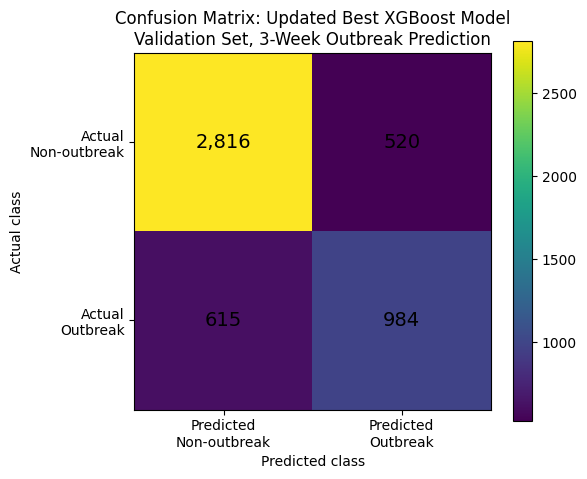

In [67]:
# Visualize confusion matrix for updated best XGBoost model

import matplotlib.pyplot as plt
import numpy as np

# Use the confusion matrix calculated dynamically in STEP 82
cm_display = cm_xgb_v2.copy()

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm_display)

# Axis labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Predicted\nNon-outbreak",
    "Predicted\nOutbreak"
])

ax.set_yticklabels([
    "Actual\nNon-outbreak",
    "Actual\nOutbreak"
])

# Add values inside cells
for i in range(cm_display.shape[0]):
    for j in range(cm_display.shape[1]):
        ax.text(
            j,
            i,
            f"{cm_display[i, j]:,}",
            ha="center",
            va="center",
            fontsize=14
        )

ax.set_title(
    "Confusion Matrix: Updated Best XGBoost Model\n"
    "Validation Set, 3-Week Outbreak Prediction"
)

ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


**Why this figure?** A confusion matrix shows the four classification outcomes in one view: correctly identified non-outbreaks, false alerts, missed outbreaks and correctly detected outbreaks. This is more informative for early warning than a single overall accuracy value.


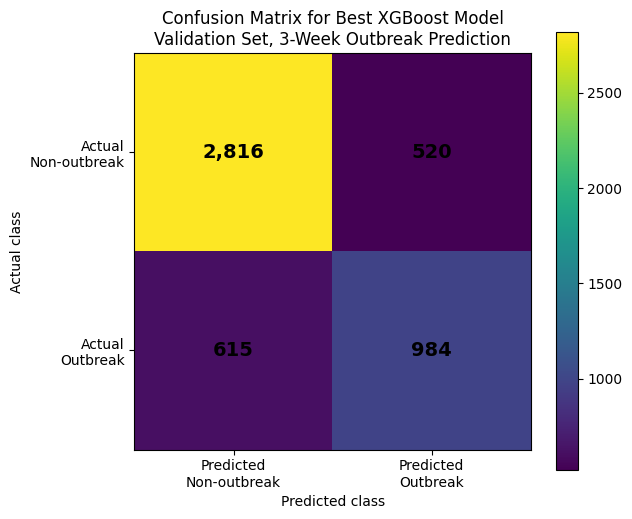

Confusion matrix saved as: confusion_matrix_best_xgboost_validation_h3.png


In [68]:
# Save confusion matrix visualization

import matplotlib.pyplot as plt
import numpy as np

# Use the confusion matrix calculated dynamically in STEP 82
cm_display = cm_xgb_v2.copy()

fig, ax = plt.subplots(figsize=(6.5, 5.5))

im = ax.imshow(cm_display)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Predicted\nNon-outbreak",
    "Predicted\nOutbreak"
])

ax.set_yticklabels([
    "Actual\nNon-outbreak",
    "Actual\nOutbreak"
])

for i in range(cm_display.shape[0]):
    for j in range(cm_display.shape[1]):
        ax.text(
            j,
            i,
            f"{cm_display[i, j]:,}",
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold"
        )

ax.set_title(
    "Confusion Matrix for Best XGBoost Model\n"
    "Validation Set, 3-Week Outbreak Prediction",
    fontsize=12
)

ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")

plt.colorbar(im, ax=ax)
plt.tight_layout()

plt.savefig(
    "confusion_matrix_best_xgboost_validation_h3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Confusion matrix saved as: "
    "confusion_matrix_best_xgboost_validation_h3.png"
)


**Interpretation.** This step saves the derived output so that the result can be reproduced or used in the written report without manually recreating it.


,Model,Precision,Sensitivity,Specificity,F1-score,Balanced accuracy
0,"Random Forest\nclass_weight = none, threshold = 0.50",0.8517,0.1113,0.9907,0.1969,0.5510
1,"Random Forest\nclass_weight = balanced, threshold = 0.50",0.8571,0.0600,0.9952,0.1122,0.5276
2,"XGBoost\nscale_pos_weight = 6, threshold = 0.50",0.6193,0.4740,0.8603,0.5370,0.6671
3,"XGBoost\nscale_pos_weight = 8.2104, threshold = 0.50",0.5754,0.5535,0.8043,0.5642,0.6789
4,"XGBoost\nscale_pos_weight = 6, max_depth = 2, threshold = 0.50",0.6429,0.6204,0.8348,0.6314,0.7276
5,"XGBoost\nscale_pos_weight = 6, max_depth = 2, learning_rate = 0.01, threshold = 0.50",0.6543,0.6154,0.8441,0.6342,0.7298


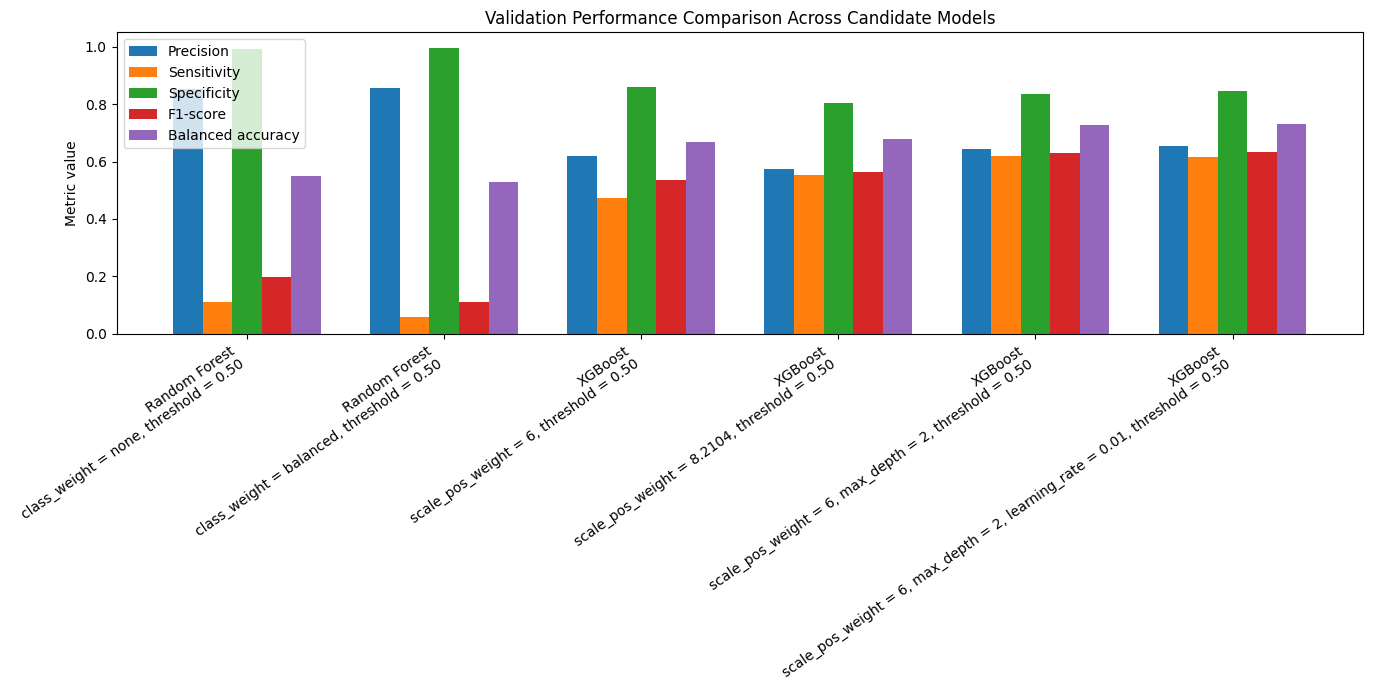

Model comparison figure saved as: model_performance_comparison_validation_h3.png


In [69]:
# Model comparison visualization

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Extract confusion-matrix values for the updated best model
tn_v2, fp_v2, fn_v2, tp_v2 = cm_xgb_v2.ravel()

# Create the updated best-model summary dynamically
xgb_v2_comparison_row = pd.DataFrame([{
    "Model": "XGBoost",
    "Setting": (
        "scale_pos_weight = 6, "
        "max_depth = 2, "
        "learning_rate = 0.01, "
        "threshold = 0.50"
    ),
    "predicted_outbreaks": tp_v2 + fp_v2,
    "true_outbreaks_detected": tp_v2,
    "missed_outbreaks": fn_v2,
    "false_alarms": fp_v2,
    "accuracy": accuracy_score(
        y_valid_h3,
        xgb_v2_valid_pred_h3
    ),
    "precision": precision_score(
        y_valid_h3,
        xgb_v2_valid_pred_h3,
        zero_division=0
    ),
    "sensitivity": recall_score(
        y_valid_h3,
        xgb_v2_valid_pred_h3,
        zero_division=0
    ),
    "specificity": tn_v2 / (tn_v2 + fp_v2),
    "f1_score": f1_score(
        y_valid_h3,
        xgb_v2_valid_pred_h3,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_valid_h3,
        xgb_v2_valid_prob_h3
    ),
    "pr_auc": average_precision_score(
        y_valid_h3,
        xgb_v2_valid_prob_h3
    ),
    "brier_score": brier_score_loss(
        y_valid_h3,
        xgb_v2_valid_prob_h3
    )
}])

# Add updated candidate to the existing corrected comparison table
final_validation_comparison = pd.concat(
    [
        candidate_model_comparison_updated,
        xgb_v2_comparison_row
    ],
    ignore_index=True
)

# Remove duplicate model-setting rows if the cell is rerun
final_validation_comparison = (
    final_validation_comparison
    .drop_duplicates(
        subset=["Model", "Setting"],
        keep="last"
    )
    .reset_index(drop=True)
)

# Calculate balanced accuracy dynamically
final_validation_comparison["balanced_accuracy"] = (
    final_validation_comparison["sensitivity"]
    + final_validation_comparison["specificity"]
) / 2

# Round metric columns
metric_cols = [
    "accuracy",
    "precision",
    "sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "brier_score",
    "balanced_accuracy"
]

for col in metric_cols:
    final_validation_comparison[col] = (
        final_validation_comparison[col].round(4)
    )

# Create shorter labels for the figure
final_validation_comparison["Plot_label"] = (
    final_validation_comparison["Model"]
    + "\n"
    + final_validation_comparison["Setting"]
)

# Clean comparison table for display and plotting
model_metric_comparison = final_validation_comparison[
    [
        "Plot_label",
        "precision",
        "sensitivity",
        "specificity",
        "f1_score",
        "balanced_accuracy"
    ]
].copy()

model_metric_comparison = model_metric_comparison.rename(
    columns={
        "Plot_label": "Model",
        "precision": "Precision",
        "sensitivity": "Sensitivity",
        "specificity": "Specificity",
        "f1_score": "F1-score",
        "balanced_accuracy": "Balanced accuracy"
    }
)

display(model_metric_comparison)

# Plot grouped bar chart
metrics_to_plot = [
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1-score",
    "Balanced accuracy"
]

x = np.arange(len(model_metric_comparison))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 7))

for i, metric in enumerate(metrics_to_plot):
    ax.bar(
        x + (i - 2) * width,
        model_metric_comparison[metric],
        width,
        label=metric
    )

ax.set_xticks(x)

ax.set_xticklabels(
    model_metric_comparison["Model"],
    rotation=35,
    ha="right"
)

ax.set_ylabel("Metric value")
ax.set_ylim(0, 1.05)

ax.set_title(
    "Validation Performance Comparison Across Candidate Models"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    "model_performance_comparison_validation_h3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Model comparison figure saved as: "
    "model_performance_comparison_validation_h3.png"
)


**Why this figure?** The model-comparison plot places the candidate models on the same visual scale so that sensitivity, specificity and balanced performance can be compared directly rather than read from separate outputs.


,Category,Count
0,Actual outbreaks,1599
1,Predicted outbreak alerts,1504
2,Correctly detected outbreaks,984
3,Missed outbreaks,615
4,False alarms,520


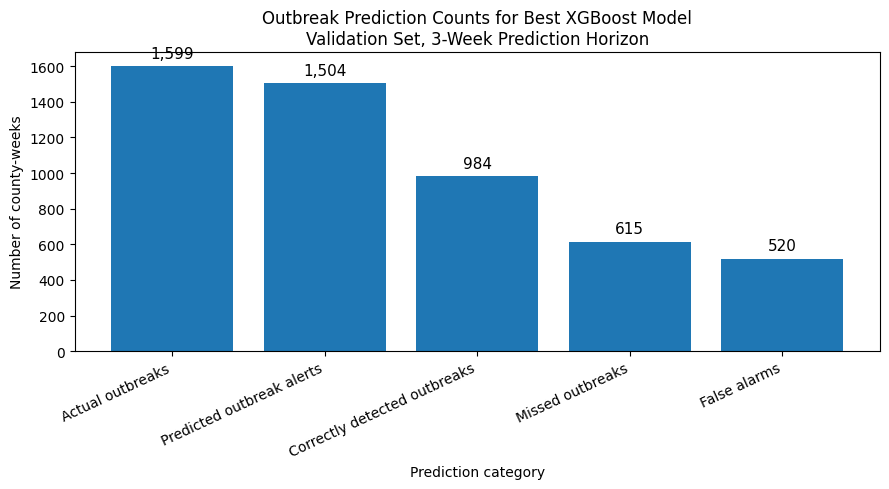

Figure saved as: xgboost_outbreak_prediction_counts_validation_h3.png


In [70]:
# Visualize outbreak prediction counts for best XGBoost model

import matplotlib.pyplot as plt
import pandas as pd

# Extract current confusion-matrix values from STEP 82
tn_v2, fp_v2, fn_v2, tp_v2 = cm_xgb_v2.ravel()

# Create outbreak count summary dynamically
xgb_v2_count_summary = pd.DataFrame({
    "Category": [
        "Actual outbreaks",
        "Predicted outbreak alerts",
        "Correctly detected outbreaks",
        "Missed outbreaks",
        "False alarms"
    ],
    "Count": [
        int(tp_v2 + fn_v2),
        int(tp_v2 + fp_v2),
        int(tp_v2),
        int(fn_v2),
        int(fp_v2)
    ]
})

display(xgb_v2_count_summary)

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    xgb_v2_count_summary["Category"],
    xgb_v2_count_summary["Count"]
)

for i, value in enumerate(xgb_v2_count_summary["Count"]):
    ax.text(
        i,
        value + 30,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title(
    "Outbreak Prediction Counts for Best XGBoost Model\n"
    "Validation Set, 3-Week Prediction Horizon"
)

ax.set_ylabel("Number of county-weeks")
ax.set_xlabel("Prediction category")

plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(
    "xgboost_outbreak_prediction_counts_validation_h3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved as: "
    "xgboost_outbreak_prediction_counts_validation_h3.png"
)


**Why this figure?** Counts of actual outbreaks, alerts, detected outbreaks, missed outbreaks and false alarms translate model performance into quantities that are easier to interpret operationally.


,threshold,predicted_outbreaks,correctly_detected_outbreaks,missed_outbreaks,false_alarms,precision,sensitivity,specificity,f1_score,balanced_accuracy
0,0.10,4907,1597,2,3310,0.3255,0.9987,0.0078,0.4909,0.5033
1,0.15,4550,1550,49,3000,0.3407,0.9694,0.1007,0.5041,0.5350
2,0.20,4021,1465,134,2556,0.3643,0.9162,0.2338,0.5214,0.5750
3,0.25,3343,1367,232,1976,0.4089,0.8549,0.4077,0.5532,0.6313
4,0.30,2837,1290,309,1547,0.4547,0.8068,0.5363,0.5816,0.6715
5,0.35,2439,1220,379,1219,0.5002,0.7630,0.6346,0.6043,0.6988
6,0.40,2090,1143,456,947,0.5469,0.7148,0.7161,0.6197,0.7155
7,0.45,1763,1063,536,700,0.6029,0.6648,0.7902,0.6324,0.7275
8,0.50,1504,984,615,520,0.6543,0.6154,0.8441,0.6342,0.7298
9,0.55,1377,936,663,441,0.6797,0.5854,0.8678,0.6290,0.7266


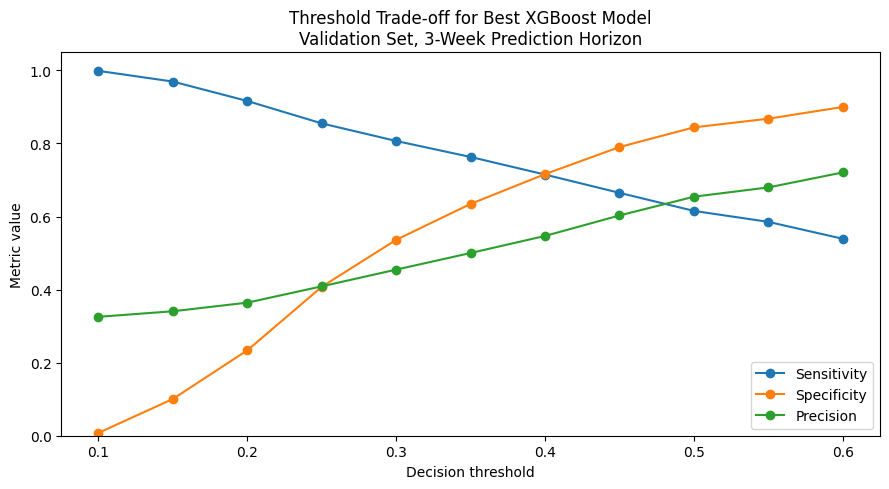

Threshold trade-off figure saved as: xgboost_threshold_tradeoff_metrics_validation_h3.png


In [71]:
# Threshold trade-off for updated best XGBoost model

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Thresholds to test
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_results_v2 = []

for threshold in thresholds:

    # Convert probabilities to predictions using selected threshold
    pred_threshold = (xgb_v2_valid_prob_h3 >= threshold).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_valid_h3, pred_threshold)
    tn, fp, fn, tp = cm.ravel()

    # Metrics
    sensitivity = recall_score(y_valid_h3, pred_threshold, zero_division=0)
    specificity = tn / (tn + fp)
    precision = precision_score(y_valid_h3, pred_threshold, zero_division=0)
    f1 = f1_score(y_valid_h3, pred_threshold, zero_division=0)
    balanced_accuracy = (sensitivity + specificity) / 2

    threshold_results_v2.append({
        "threshold": threshold,
        "predicted_outbreaks": int(tp + fp),
        "correctly_detected_outbreaks": int(tp),
        "missed_outbreaks": int(fn),
        "false_alarms": int(fp),
        "precision": precision,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1_score": f1,
        "balanced_accuracy": balanced_accuracy
    })

threshold_results_v2 = pd.DataFrame(threshold_results_v2)

# Round metric columns
metric_cols = ["precision", "sensitivity", "specificity", "f1_score", "balanced_accuracy"]
threshold_results_v2[metric_cols] = threshold_results_v2[metric_cols].round(4)

display(threshold_results_v2)

# Plot sensitivity and false alarms against threshold
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(
    threshold_results_v2["threshold"],
    threshold_results_v2["sensitivity"],
    marker="o",
    label="Sensitivity"
)

ax1.plot(
    threshold_results_v2["threshold"],
    threshold_results_v2["specificity"],
    marker="o",
    label="Specificity"
)

ax1.plot(
    threshold_results_v2["threshold"],
    threshold_results_v2["precision"],
    marker="o",
    label="Precision"
)

ax1.set_xlabel("Decision threshold")
ax1.set_ylabel("Metric value")
ax1.set_ylim(0, 1.05)

ax1.set_title("Threshold Trade-off for Best XGBoost Model\nValidation Set, 3-Week Prediction Horizon")

ax1.legend()
plt.tight_layout()

plt.savefig("xgboost_threshold_tradeoff_metrics_validation_h3.png", dpi=300, bbox_inches="tight")

plt.show()

print("Threshold trade-off figure saved as: xgboost_threshold_tradeoff_metrics_validation_h3.png")


**Interpretation.** The threshold table makes the sensitivity–specificity trade-off explicit. The selected **0.50 threshold** is treated as an operational compromise based on validation rather than as a universal optimal cut-off.


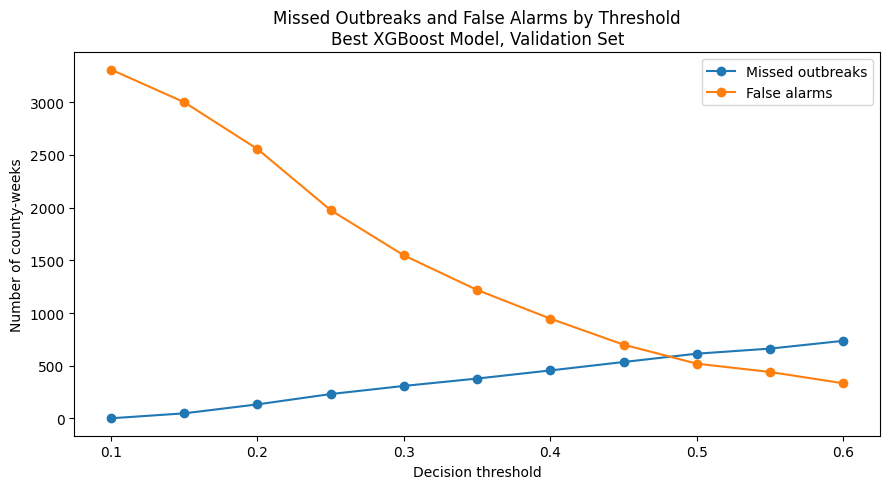

Figure saved as: xgboost_missed_vs_false_alarms_by_threshold_h3.png


In [72]:
# Visualize missed outbreaks and false alarms by threshold

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    threshold_results_v2["threshold"],
    threshold_results_v2["missed_outbreaks"],
    marker="o",
    label="Missed outbreaks"
)

ax.plot(
    threshold_results_v2["threshold"],
    threshold_results_v2["false_alarms"],
    marker="o",
    label="False alarms"
)

ax.set_xlabel("Decision threshold")
ax.set_ylabel("Number of county-weeks")

ax.set_title(
    "Missed Outbreaks and False Alarms by Threshold\nBest XGBoost Model, Validation Set"
)

ax.legend()

plt.tight_layout()

plt.savefig("xgboost_missed_vs_false_alarms_by_threshold_h3.png", dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved as: xgboost_missed_vs_false_alarms_by_threshold_h3.png")


**Why this figure?** Plotting missed outbreaks against false alarms makes the practical cost of changing the threshold visible. Lower thresholds reduce misses but can substantially increase the number of follow-up alerts.


In [73]:
# Final validation comparison table for candidate models

# Use the dynamically generated comparison table from STEP 85
final_validation_comparison_table = (
    final_validation_comparison.copy()
)

# Remove the plotting label if present
final_validation_comparison_table = (
    final_validation_comparison_table.drop(
        columns=["Plot_label"],
        errors="ignore"
    )
)

# Arrange columns
final_validation_comparison_table = (
    final_validation_comparison_table[
        [
            "Model",
            "Setting",
            "predicted_outbreaks",
            "true_outbreaks_detected",
            "missed_outbreaks",
            "false_alarms",
            "accuracy",
            "precision",
            "sensitivity",
            "specificity",
            "f1_score",
            "balanced_accuracy",
            "roc_auc",
            "pr_auc",
            "brier_score"
        ]
    ].copy()
)

# Add actual outbreaks dynamically
final_validation_comparison_table.insert(
    2,
    "actual_outbreaks",
    int(y_valid_h3.sum())
)

display(final_validation_comparison_table)


,Model,Setting,actual_outbreaks,predicted_outbreaks,true_outbreaks_detected,missed_outbreaks,false_alarms,accuracy,precision,sensitivity,specificity,f1_score,balanced_accuracy,roc_auc,pr_auc,brier_score
0,Random Forest,"class_weight = none, threshold = 0.50",1599,209,178,1421,31,0.7058,0.8517,0.1113,0.9907,0.1969,0.5510,0.7628,0.6532,0.2006
1,Random Forest,"class_weight = balanced, threshold = 0.50",1599,112,96,1503,16,0.6922,0.8571,0.0600,0.9952,0.1122,0.5276,0.7588,0.6417,0.2190
2,XGBoost,"scale_pos_weight = 6, threshold = 0.50",1599,1224,758,841,466,0.7352,0.6193,0.4740,0.8603,0.5370,0.6671,0.7321,0.5677,0.1881
3,XGBoost,"scale_pos_weight = 8.2104, threshold = 0.50",1599,1538,885,714,653,0.7230,0.5754,0.5535,0.8043,0.5642,0.6789,0.7308,0.5694,0.1925
4,XGBoost,"scale_pos_weight = 6, max_depth = 2, threshold = 0.50",1599,1543,992,607,551,0.7653,0.6429,0.6204,0.8348,0.6314,0.7276,0.7747,0.6610,0.1738
5,XGBoost,"scale_pos_weight = 6, max_depth = 2, learning_rate = 0.01, threshold = 0.50",1599,1504,984,615,520,0.7700,0.6543,0.6154,0.8441,0.6342,0.7298,0.7747,0.6617,0.1737


**Interpretation.** The final validation comparison records the candidate settings and their metrics before moving to predictor-domain and temporal-robustness analyses. This keeps the model-development decisions traceable.


## 7. Contribution of predictor domains

To understand whether predictive information comes mainly from recent surveillance or from the wider environmental and structural context, I compare three predictor sets:

1. climate/environment/WASH-related predictors,
2. surveillance predictors only, and
3. the full combined set.

This is not a causal decomposition. It is a predictive comparison that asks how much useful signal each group provides under the same model structure.


In [74]:
# Define predictor groups for domain comparison

# 1. Climate, environmental, WASH, and seasonal variables only
climate_env_wash_predictors = [
    "year",
    "epi_week",
    "rainy_season_flag",
    "population_2019",
    "rainfall_mm",
    "mean_temp_c",
    "flood_indicator",
    "ndvi",
    "drought_index",
    "wash_vulnerability_index",
    "rainfall_lag1_mm",
    "rainfall_lag2_mm",
    "rainfall_lag3_mm",
    "rainfall_lag4_mm",
    "temp_lag1_c",
    "temp_lag2_c",
    "temp_lag3_c",
    "rainfall_rolling4_mm",
    "rainfall_rolling8_mm",
    "temp_x_rainfall"
]

# 2. Surveillance variables only
surveillance_predictors = [
    "cholera_cases",
    "incidence_per_100k",
    "outbreak_current"
]

# 3. Combined model predictors
combined_predictors = predictor_columns.copy()

# Check sizes
print("Number of climate/environmental/WASH predictors:", len(climate_env_wash_predictors))
print("Number of surveillance predictors:", len(surveillance_predictors))
print("Number of combined predictors:", len(combined_predictors))

# Check that all predictors exist in the dataset
missing_climate = [col for col in climate_env_wash_predictors if col not in model_data_h3.columns]
missing_surveillance = [col for col in surveillance_predictors if col not in model_data_h3.columns]
missing_combined = [col for col in combined_predictors if col not in model_data_h3.columns]

print("Missing climate/environmental/WASH predictors:", missing_climate)
print("Missing surveillance predictors:", missing_surveillance)
print("Missing combined predictors:", missing_combined)


Number of climate/environmental/WASH predictors: 20
Number of surveillance predictors: 3
Number of combined predictors: 23
Missing climate/environmental/WASH predictors: []
Missing surveillance predictors: []
Missing combined predictors: []


**Interpretation.** The predictor groups contain 20 climate/environment/WASH-related variables, 3 surveillance variables and all 23 predictors in the combined model. No expected variables are missing from the groups.


In [75]:
# Create predictor group variable table

predictor_group_variable_table = pd.DataFrame({
    "Predictor group": [
        "Climate/Environmental/WASH only",
        "Surveillance only",
        "Combined model"
    ],
    "Variables included": [
        ", ".join(climate_env_wash_predictors),
        ", ".join(surveillance_predictors),
        ", ".join(combined_predictors)
    ],
    "Number of variables": [
        len(climate_env_wash_predictors),
        len(surveillance_predictors),
        len(combined_predictors)
    ]
})

display(predictor_group_variable_table)


,Predictor group,Variables included,Number of variables
0,Climate/Environmental/WASH only,"year, epi_week, rainy_season_flag, population_2019, rainfall_mm, mean_temp_c, flood_indicator, ndvi, drought_index, wash_vulnerability_index, rainfall_lag1_mm, rainfall_lag2_mm, rainfall_lag3_mm, rainfall_lag4_mm, temp_lag1_c, temp_lag2_c, temp_lag3_c, rainfall_rolling4_mm, rainfall_rolling8_mm, temp_x_rainfall",20
1,Surveillance only,"cholera_cases, incidence_per_100k, outbreak_current",3
2,Combined model,"year, epi_week, rainy_season_flag, population_2019, rainfall_mm, mean_temp_c, flood_indicator, ndvi, drought_index, wash_vulnerability_index, rainfall_lag1_mm, rainfall_lag2_mm, rainfall_lag3_mm, rainfall_lag4_mm, temp_lag1_c, temp_lag2_c, temp_lag3_c, rainfall_rolling4_mm, rainfall_rolling8_mm, temp_x_rainfall, cholera_cases, incidence_per_100k, outbreak_current",23


**Interpretation.** This step generates model predictions for the designated evaluation data. These predictions are kept separate from model fitting so that the subsequent metrics can be calculated transparently.


In [76]:
# Long-format predictor group variable table

predictor_group_rows = []

for variable in climate_env_wash_predictors:
    predictor_group_rows.append({
        "Predictor group": "Climate/Environmental/WASH only",
        "Variable": variable
    })

for variable in surveillance_predictors:
    predictor_group_rows.append({
        "Predictor group": "Surveillance only",
        "Variable": variable
    })

for variable in combined_predictors:
    predictor_group_rows.append({
        "Predictor group": "Combined model",
        "Variable": variable
    })

predictor_group_variable_table_long = pd.DataFrame(predictor_group_rows)

display(predictor_group_variable_table_long)


,Predictor group,Variable
0,Climate/Environmental/WASH only,year
1,Climate/Environmental/WASH only,epi_week
2,Climate/Environmental/WASH only,rainy_season_flag
3,Climate/Environmental/WASH only,population_2019
4,Climate/Environmental/WASH only,rainfall_mm
5,Climate/Environmental/WASH only,mean_temp_c
6,Climate/Environmental/WASH only,flood_indicator
7,Climate/Environmental/WASH only,ndvi
8,Climate/Environmental/WASH only,drought_index
9,Climate/Environmental/WASH only,wash_vulnerability_index


**Interpretation.** This step generates model predictions for the designated evaluation data. These predictions are kept separate from model fitting so that the subsequent metrics can be calculated transparently.


In [77]:
# Train and evaluate predictor-group XGBoost models

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, brier_score_loss
)

# Define the predictor groups to compare
predictor_groups = {
    "Climate/Environmental/WASH only": climate_env_wash_predictors,
    "Surveillance only": surveillance_predictors,
    "Combined model": combined_predictors
}

group_model_results = []

for group_name, predictors in predictor_groups.items():

    # Prepare X data for this predictor group
    X_train_group = train_data_h3[predictors].copy()
    X_valid_group = valid_data_h3[predictors].copy()

    # Train XGBoost using the current best settings
    group_model = XGBClassifier(
        n_estimators=300,
        max_depth=2,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=6,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    group_model.fit(X_train_group, y_train_h3)

    # Predict probabilities and classes
    valid_prob = group_model.predict_proba(X_valid_group)[:, 1]
    valid_pred = (valid_prob >= 0.50).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_valid_h3, valid_pred)
    tn, fp, fn, tp = cm.ravel()

    # Metrics
    accuracy = accuracy_score(y_valid_h3, valid_pred)
    precision = precision_score(y_valid_h3, valid_pred, zero_division=0)
    sensitivity = recall_score(y_valid_h3, valid_pred, zero_division=0)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_valid_h3, valid_pred, zero_division=0)
    balanced_accuracy = (sensitivity + specificity) / 2
    roc_auc = roc_auc_score(y_valid_h3, valid_prob)
    pr_auc = average_precision_score(y_valid_h3, valid_prob)
    brier = brier_score_loss(y_valid_h3, valid_prob)

    group_model_results.append({
        "Predictor group": group_name,
        "Number of predictors": len(predictors),
        "Actual outbreaks": int(tp + fn),
        "Predicted outbreak alerts": int(tp + fp),
        "Correctly detected outbreaks": int(tp),
        "Missed outbreaks": int(fn),
        "False alarms": int(fp),
        "Accuracy": accuracy,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1-score": f1,
        "Balanced accuracy": balanced_accuracy,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Brier score": brier
    })

group_model_comparison = pd.DataFrame(group_model_results)

# Round metric columns
round_cols = [
    "Accuracy", "Precision", "Sensitivity", "Specificity",
    "F1-score", "Balanced accuracy", "ROC-AUC", "PR-AUC", "Brier score"
]

for col in round_cols:
    group_model_comparison[col] = group_model_comparison[col].round(4)

display(group_model_comparison)


,Predictor group,Number of predictors,Actual outbreaks,Predicted outbreak alerts,Correctly detected outbreaks,Missed outbreaks,False alarms,Accuracy,Precision,Sensitivity,Specificity,F1-score,Balanced accuracy,ROC-AUC,PR-AUC,Brier score
0,Climate/Environmental/WASH only,20,1599,1122,695,904,427,0.7303,0.6194,0.4346,0.8720,0.5108,0.6533,0.7239,0.5606,0.1888
1,Surveillance only,3,1599,2250,1102,497,1148,0.6667,0.4898,0.6892,0.6559,0.5726,0.6725,0.7276,0.5744,0.2204
2,Combined model,23,1599,1504,984,615,520,0.7700,0.6543,0.6154,0.8441,0.6342,0.7298,0.7747,0.6617,0.1737


**Interpretation.** The surveillance-only model detects many outbreaks but also generates a large false-alert burden, while the combined model reduces false alerts substantially while preserving strong detection. This suggests complementary predictive information across domains.


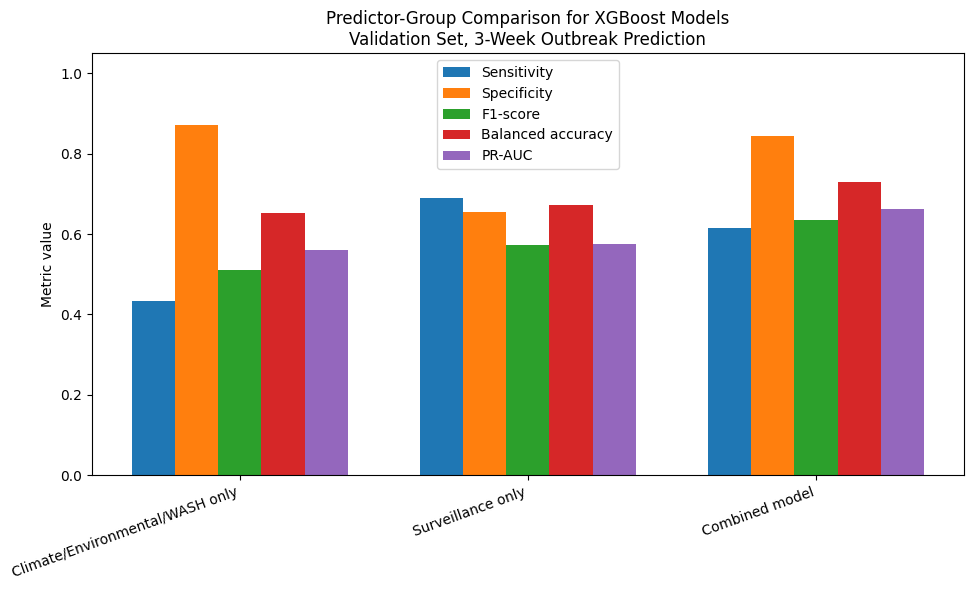

Figure saved as: predictor_group_comparison_xgboost_validation_h3.png


In [78]:
# Visualize predictor-group model comparison

import matplotlib.pyplot as plt
import numpy as np

# Metrics to plot
metrics_to_plot = [
    "Sensitivity",
    "Specificity",
    "F1-score",
    "Balanced accuracy",
    "PR-AUC"
]

x = np.arange(len(group_model_comparison["Predictor group"]))
width = 0.15

fig, ax = plt.subplots(figsize=(10, 6))

for i, metric in enumerate(metrics_to_plot):
    ax.bar(
        x + (i - 2) * width,
        group_model_comparison[metric],
        width,
        label=metric
    )

ax.set_xticks(x)
ax.set_xticklabels(group_model_comparison["Predictor group"], rotation=20, ha="right")

ax.set_ylabel("Metric value")
ax.set_ylim(0, 1.05)

ax.set_title("Predictor-Group Comparison for XGBoost Models\nValidation Set, 3-Week Outbreak Prediction")
ax.legend()

plt.tight_layout()

plt.savefig("predictor_group_comparison_xgboost_validation_h3.png", dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved as: predictor_group_comparison_xgboost_validation_h3.png")


**Why this figure?** Comparing the predictor-domain models visually makes it easier to see that the best early-warning profile is not determined by sensitivity alone; specificity and balanced accuracy matter at the same time.


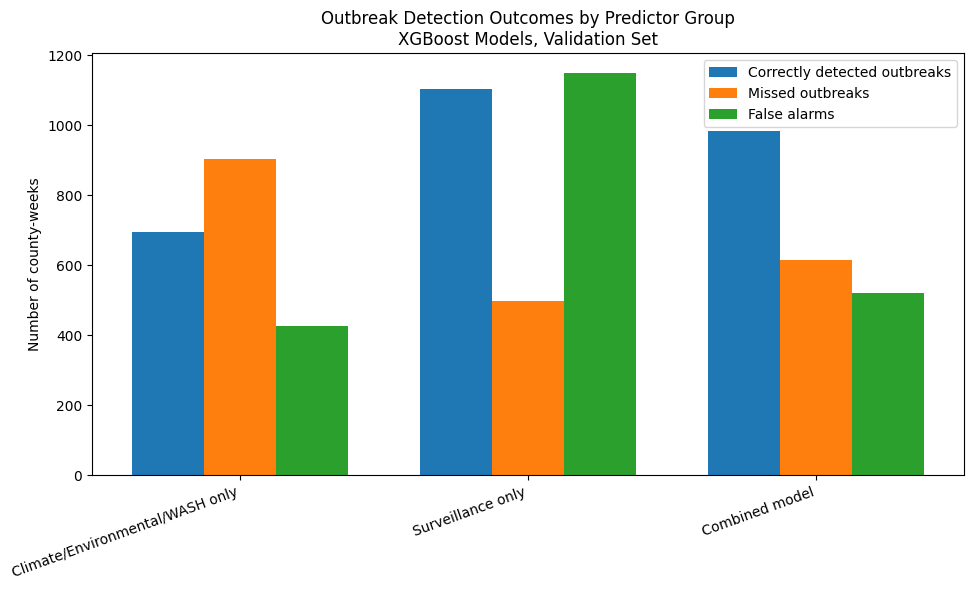

Figure saved as: predictor_group_outbreak_counts_xgboost_validation_h3.png


In [79]:
# Visualize detected outbreaks, missed outbreaks,
# and false alarms by predictor group

import matplotlib.pyplot as plt
import numpy as np

count_metrics = [
    "Correctly detected outbreaks",
    "Missed outbreaks",
    "False alarms"
]

x = np.arange(len(group_model_comparison["Predictor group"]))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, metric in enumerate(count_metrics):
    ax.bar(
        x + (i - 1) * width,
        group_model_comparison[metric],
        width,
        label=metric
    )

ax.set_xticks(x)
ax.set_xticklabels(group_model_comparison["Predictor group"], rotation=20, ha="right")

ax.set_ylabel("Number of county-weeks")
ax.set_title(
    "Outbreak Detection Outcomes by Predictor Group\nXGBoost Models, Validation Set"
)

ax.legend()

plt.tight_layout()

plt.savefig("predictor_group_outbreak_counts_xgboost_validation_h3.png", dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved as: predictor_group_outbreak_counts_xgboost_validation_h3.png")


**Why this figure?** This count-based plot complements the metric plot by showing the actual numbers of detected, missed and falsely alerted county-weeks for each predictor group.


In [80]:
# Save predictor-group comparison table

group_model_comparison.to_csv(
    "predictor_group_comparison_xgboost_validation_h3.csv",
    index=False
)

print("Saved predictor-group comparison table as:")
print("predictor_group_comparison_xgboost_validation_h3.csv")


Saved predictor-group comparison table as:
predictor_group_comparison_xgboost_validation_h3.csv


**Interpretation.** This step saves the derived output so that the result can be reproduced or used in the written report without manually recreating it.


## 8. Temporal robustness during model development

A model that performs well in one period may not perform equally well in another. I therefore use expanding-window evaluation to examine year-specific performance across 2017–2024.

For each evaluation year, the model is trained only on earlier observations. This more closely resembles how an early-warning model would be updated over time and helps reveal temporal instability that would be hidden by a single pooled validation score.


In [81]:
# Create expanding-window validation plan

expanding_window_plan = []

# Use only 2017–2024 for expanding-window validation
validation_years = list(range(2017, 2025))

for validation_year in validation_years:

    expanding_window_plan.append({
        "Fold": len(expanding_window_plan) + 1,
        "Training target years": f"2015-{validation_year - 1}",
        "Validation target year": validation_year,
        "Number of training years": validation_year - 2015
    })

expanding_window_plan = pd.DataFrame(
    expanding_window_plan
)

display(expanding_window_plan)

print(
    "The 2025 target year is excluded and remains "
    "the final untouched test period."
)


,Fold,Training target years,Validation target year,Number of training years
0,1,2015-2016,2017,2
1,2,2015-2017,2018,3
2,3,2015-2018,2019,4
3,4,2015-2019,2020,5
4,5,2015-2020,2021,6
5,6,2015-2021,2022,7
6,7,2015-2022,2023,8
7,8,2015-2023,2024,9


The 2025 target year is excluded and remains the final untouched test period.


**Interpretation.** This step prepares an intermediate dataset or object required for the analysis. Printing the resulting structure provides a quick check that the transformation behaved as intended.


In [82]:
# Run expanding-window validation for best XGBoost model

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

# Ensure dates are stored correctly
model_data_h3["week_start_date"] = pd.to_datetime(
    model_data_h3["week_start_date"]
)

# Recreate the 3-week target date and year if needed
model_data_h3["target_date_h3"] = (
    model_data_h3["week_start_date"]
    + pd.Timedelta(weeks=3)
)

model_data_h3["target_year_h3"] = (
    model_data_h3["target_date_h3"].dt.year
)

expanding_window_results = []

# Validate from 2017 through 2024 only
validation_years = list(range(2017, 2025))

for validation_year in validation_years:

    # Train using target years before the validation year
    train_fold = model_data_h3[
        model_data_h3["target_year_h3"] < validation_year
    ].copy()

    # Validate using the selected target year
    valid_fold = model_data_h3[
        model_data_h3["target_year_h3"] == validation_year
    ].copy()

    X_train_fold = train_fold[combined_predictors].copy()
    y_train_fold = train_fold[target_h3].copy()

    X_valid_fold = valid_fold[combined_predictors].copy()
    y_valid_fold = valid_fold[target_h3].copy()

    fold_model = XGBClassifier(
        n_estimators=300,
        max_depth=2,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=6,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    fold_model.fit(
        X_train_fold,
        y_train_fold
    )

    valid_prob = fold_model.predict_proba(
        X_valid_fold
    )[:, 1]

    valid_pred = (
        valid_prob >= 0.50
    ).astype(int)

    cm = confusion_matrix(
        y_valid_fold,
        valid_pred
    )

    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(
        y_valid_fold,
        valid_pred
    )

    precision = precision_score(
        y_valid_fold,
        valid_pred,
        zero_division=0
    )

    sensitivity = recall_score(
        y_valid_fold,
        valid_pred,
        zero_division=0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    f1 = f1_score(
        y_valid_fold,
        valid_pred,
        zero_division=0
    )

    balanced_accuracy = (
        sensitivity + specificity
    ) / 2

    roc_auc = roc_auc_score(
        y_valid_fold,
        valid_prob
    )

    pr_auc = average_precision_score(
        y_valid_fold,
        valid_prob
    )

    brier = brier_score_loss(
        y_valid_fold,
        valid_prob
    )

    expanding_window_results.append({
        "Validation target year": validation_year,
        "Training target years": (
            f"2015-{validation_year - 1}"
        ),
        "Training rows": len(train_fold),
        "Validation rows": len(valid_fold),
        "Actual outbreaks": int(tp + fn),
        "Predicted outbreak alerts": int(tp + fp),
        "Correctly detected outbreaks": int(tp),
        "Missed outbreaks": int(fn),
        "False alarms": int(fp),
        "Accuracy": accuracy,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1-score": f1,
        "Balanced accuracy": balanced_accuracy,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Brier score": brier
    })

expanding_window_results = pd.DataFrame(
    expanding_window_results
)

round_cols = [
    "Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1-score",
    "Balanced accuracy",
    "ROC-AUC",
    "PR-AUC",
    "Brier score"
]

for col in round_cols:
    expanding_window_results[col] = (
        expanding_window_results[col].round(4)
    )

display(expanding_window_results)


,Validation target year,Training target years,Training rows,Validation rows,Actual outbreaks,Predicted outbreak alerts,Correctly detected outbreaks,Missed outbreaks,False alarms,Accuracy,Precision,Sensitivity,Specificity,F1-score,Balanced accuracy,ROC-AUC,PR-AUC,Brier score
0,2017,2015-2016,4465,2444,599,281,205,394,76,0.8077,0.7295,0.3422,0.9588,0.4659,0.6505,0.7669,0.5932,0.1462
1,2018,2015-2017,6909,2491,133,1021,95,38,926,0.6130,0.0930,0.7143,0.6073,0.1646,0.6608,0.6987,0.1327,0.2546
2,2019,2015-2018,9400,2444,408,415,214,194,201,0.8384,0.5157,0.5245,0.9013,0.5200,0.7129,0.7903,0.5183,0.1235
3,2020,2015-2019,11844,2444,130,532,65,65,467,0.7823,0.1222,0.5000,0.7982,0.1964,0.6491,0.6975,0.1146,0.1678
4,2021,2015-2020,14288,2444,132,250,40,92,210,0.8764,0.1600,0.3030,0.9092,0.2094,0.6061,0.7099,0.1233,0.0985
5,2022,2015-2021,16732,2444,290,274,105,185,169,0.8552,0.3832,0.3621,0.9215,0.3723,0.6418,0.7310,0.3100,0.1135
6,2023,2015-2022,19176,2444,698,683,430,268,253,0.7868,0.6296,0.6160,0.8551,0.6227,0.7356,0.7710,0.6042,0.1704
7,2024,2015-2023,21620,2491,901,1460,729,172,731,0.6375,0.4993,0.8091,0.5403,0.6175,0.6747,0.7805,0.7229,0.2286


**Interpretation.** Expanding-window evaluation shows that model performance changes from year to year. This temporal variation argues against assuming that a model fitted once will retain the same performance indefinitely.


In [83]:
# Summarize expanding-window validation performance

expanding_window_summary = pd.DataFrame({
    "Metric": [
        "Mean accuracy",
        "Mean precision",
        "Mean sensitivity",
        "Mean specificity",
        "Mean F1-score",
        "Mean balanced accuracy",
        "Mean ROC-AUC",
        "Mean PR-AUC",
        "Mean Brier score"
    ],
    "Mean value": [
        expanding_window_results["Accuracy"].mean(),
        expanding_window_results["Precision"].mean(),
        expanding_window_results["Sensitivity"].mean(),
        expanding_window_results["Specificity"].mean(),
        expanding_window_results["F1-score"].mean(),
        expanding_window_results["Balanced accuracy"].mean(),
        expanding_window_results["ROC-AUC"].mean(),
        expanding_window_results["PR-AUC"].mean(),
        expanding_window_results["Brier score"].mean()
    ],
    "Standard deviation": [
        expanding_window_results["Accuracy"].std(),
        expanding_window_results["Precision"].std(),
        expanding_window_results["Sensitivity"].std(),
        expanding_window_results["Specificity"].std(),
        expanding_window_results["F1-score"].std(),
        expanding_window_results["Balanced accuracy"].std(),
        expanding_window_results["ROC-AUC"].std(),
        expanding_window_results["PR-AUC"].std(),
        expanding_window_results["Brier score"].std()
    ]
})

expanding_window_summary["Mean value"] = expanding_window_summary["Mean value"].round(4)
expanding_window_summary["Standard deviation"] = expanding_window_summary["Standard deviation"].round(4)

display(expanding_window_summary)


,Metric,Mean value,Standard deviation
0,Mean accuracy,0.7747,0.0979
1,Mean precision,0.3916,0.2430
2,Mean sensitivity,0.5214,0.1831
3,Mean specificity,0.8115,0.1553
4,Mean F1-score,0.3961,0.1888
5,Mean balanced accuracy,0.6664,0.0411
6,Mean ROC-AUC,0.7432,0.0383
7,Mean PR-AUC,0.3899,0.2490
8,Mean Brier score,0.1629,0.0551


**Interpretation.** The mean expanding-window values summarise performance across several historical evaluation years, but the year-specific variability remains important. The average should therefore be read together with the plot rather than as a single guarantee of future performance.


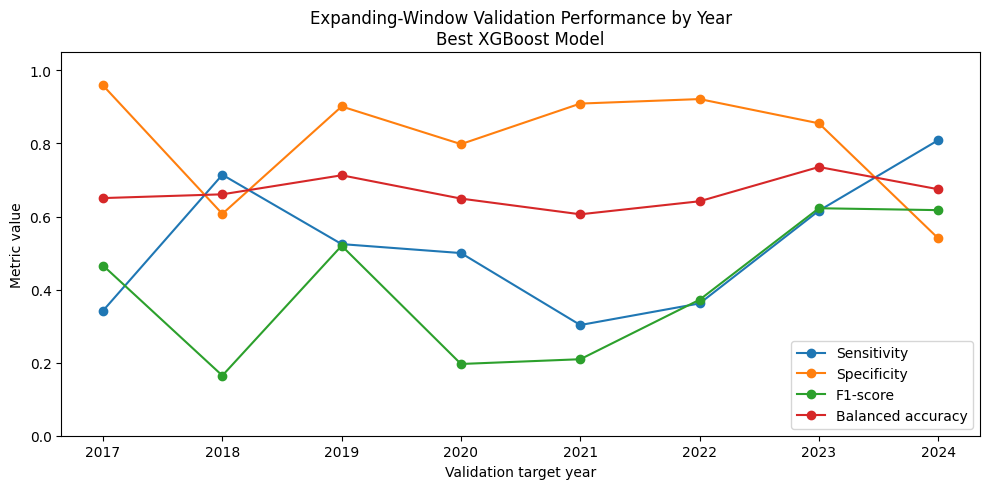

Figure saved as: expanding_window_performance_by_year_xgboost_h3.png


In [84]:
# Visualize expanding-window validation performance by year

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    expanding_window_results["Validation target year"],
    expanding_window_results["Sensitivity"],
    marker="o",
    label="Sensitivity"
)

ax.plot(
    expanding_window_results["Validation target year"],
    expanding_window_results["Specificity"],
    marker="o",
    label="Specificity"
)

ax.plot(
    expanding_window_results["Validation target year"],
    expanding_window_results["F1-score"],
    marker="o",
    label="F1-score"
)

ax.plot(
    expanding_window_results["Validation target year"],
    expanding_window_results["Balanced accuracy"],
    marker="o",
    label="Balanced accuracy"
)

ax.set_xlabel("Validation target year")
ax.set_ylabel("Metric value")
ax.set_ylim(0, 1.05)

ax.set_title(
    "Expanding-Window Validation Performance by Year\nBest XGBoost Model"
)

ax.legend()
plt.tight_layout()

plt.savefig("expanding_window_performance_by_year_xgboost_h3.png", dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved as: expanding_window_performance_by_year_xgboost_h3.png")


**Why this figure?** The year-by-year lines show where sensitivity, specificity and balanced accuracy rise or fall over time. This provides a direct visual check of temporal stability.


In [85]:
# Save expanding-window validation results

expanding_window_results.to_csv(
    "expanding_window_validation_results_xgboost_h3.csv",
    index=False
)

expanding_window_summary.to_csv(
    "expanding_window_validation_summary_xgboost_h3.csv",
    index=False
)

print("Saved expanding-window validation results as:")
print("expanding_window_validation_results_xgboost_h3.csv")
print("expanding_window_validation_summary_xgboost_h3.csv")


Saved expanding-window validation results as:
expanding_window_validation_results_xgboost_h3.csv
expanding_window_validation_summary_xgboost_h3.csv


**Interpretation.** This step saves the derived output so that the result can be reproduced or used in the written report without manually recreating it.


## 9. Independent 2025 evaluation and an exploratory refit check

The **primary independent evaluation** is based on the locked XGBoost specification trained on the designated 2015–2022 training period and evaluated on the untouched 2025 test period. That primary result is reproduced later in the dedicated verification section.

The next few cells also retain an exploratory refit in which all pre-2025 target observations are combined before testing on 2025. I keep this block because it was part of the analytical development, but it should be read as an additional refit experiment rather than the primary reported evaluation. Keeping both pathways visible makes the notebook more transparent.


In [86]:
# Create final training and test sets
# Final training targets: 2015–2024
# Final test targets: 2025

# Ensure week_start_date is a real date
model_data_h3["week_start_date"] = pd.to_datetime(
    model_data_h3["week_start_date"]
)

# Recreate target date and target year
model_data_h3["target_date_h3"] = (
    model_data_h3["week_start_date"]
    + pd.Timedelta(weeks=3)
)

model_data_h3["target_year_h3"] = (
    model_data_h3["target_date_h3"].dt.year
)

# Final training data: targets before 1 January 2025
final_train_data_h3 = model_data_h3[
    model_data_h3["target_date_h3"]
    < pd.Timestamp("2025-01-01")
].copy()

# Final test data: targets occurring during 2025
final_test_data_h3 = model_data_h3[
    (
        model_data_h3["target_date_h3"]
        >= pd.Timestamp("2025-01-01")
    )
    &
    (
        model_data_h3["target_date_h3"]
        < pd.Timestamp("2026-01-01")
    )
].copy()

X_final_train_h3 = final_train_data_h3[
    combined_predictors
].copy()

y_final_train_h3 = final_train_data_h3[
    target_h3
].copy()

X_final_test_h3 = final_test_data_h3[
    combined_predictors
].copy()

y_final_test_h3 = final_test_data_h3[
    target_h3
].copy()

print(
    "Final training data shape:",
    final_train_data_h3.shape
)

print(
    "Final test data shape:",
    final_test_data_h3.shape
)

print("\nFinal training target-date range:")
print(
    final_train_data_h3["target_date_h3"].min(),
    "to",
    final_train_data_h3["target_date_h3"].max()
)

print("\nFinal test target-date range:")
print(
    final_test_data_h3["target_date_h3"].min(),
    "to",
    final_test_data_h3["target_date_h3"].max()
)

print("\nFinal training target distribution:")
print(y_final_train_h3.value_counts())
print(
    y_final_train_h3
    .value_counts(normalize=True)
    .round(4) * 100
)

print("\nFinal test target distribution:")
print(y_final_test_h3.value_counts())
print(
    y_final_test_h3
    .value_counts(normalize=True)
    .round(4) * 100
)

# Final temporal leakage checks
assert (
    final_train_data_h3["target_date_h3"].max()
    < pd.Timestamp("2025-01-01")
)

assert (
    final_test_data_h3["target_date_h3"].min()
    >= pd.Timestamp("2025-01-01")
)

print("\nFinal temporal split checks passed.")


Final training data shape: (24111, 36)
Final test data shape: (2397, 36)

Final training target-date range:
2015-03-09 00:00:00 to 2024-12-30 00:00:00

Final test target-date range:
2025-01-06 00:00:00 to 2025-12-22 00:00:00

Final training target distribution:
outbreak_h3
0.0    20430
1.0     3681
Name: count, dtype: int64
outbreak_h3
0.0    84.73
1.0    15.27
Name: proportion, dtype: float64

Final test target distribution:
outbreak_h3
0.0    1692
1.0     705
Name: count, dtype: int64
outbreak_h3
0.0    70.59
1.0    29.41
Name: proportion, dtype: float64

Final temporal split checks passed.


**Interpretation.** This block creates an additional pre-2025 refit dataset that combines earlier target years. It is retained as an exploratory experiment; the primary independent evaluation uses the designated training/validation/test development structure reproduced later.


In [87]:
# Train final XGBoost model on pre-2025 target data

final_xgb_h3 = XGBClassifier(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=6,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

final_xgb_h3.fit(
    X_final_train_h3,
    y_final_train_h3
)

print(
    "Final XGBoost model trained successfully "
    "using all pre-2025 target data."
)


Final XGBoost model trained successfully using all pre-2025 target data.


**Interpretation.** This confirms that the model fitting step completed using the data and settings defined above. Performance is interpreted only in the following evaluation cells.


In [88]:
# Evaluate final XGBoost model on 2025 test set

# Predict probabilities on the final 2025 test set
final_test_prob_h3 = final_xgb_h3.predict_proba(X_final_test_h3)[:, 1]

# Convert probabilities to class predictions using threshold 0.50
final_test_pred_h3 = (final_test_prob_h3 >= 0.50).astype(int)

# Confusion matrix
cm_final_test = confusion_matrix(y_final_test_h3, final_test_pred_h3)

tn, fp, fn, tp = cm_final_test.ravel()

# Calculate metrics
accuracy = accuracy_score(y_final_test_h3, final_test_pred_h3)
precision = precision_score(y_final_test_h3, final_test_pred_h3, zero_division=0)
sensitivity = recall_score(y_final_test_h3, final_test_pred_h3, zero_division=0)
specificity = tn / (tn + fp)
f1 = f1_score(y_final_test_h3, final_test_pred_h3, zero_division=0)
balanced_accuracy = (sensitivity + specificity) / 2
roc_auc = roc_auc_score(y_final_test_h3, final_test_prob_h3)
pr_auc = average_precision_score(y_final_test_h3, final_test_prob_h3)
brier = brier_score_loss(y_final_test_h3, final_test_prob_h3)

# Store results in a clean table
final_test_results = pd.DataFrame({
    "Metric": [
        "Actual test outbreaks",
        "Predicted outbreak alerts",
        "Correctly detected outbreaks",
        "Missed outbreaks",
        "False alarms",
        "Accuracy",
        "Precision",
        "Sensitivity / Recall",
        "Specificity",
        "F1-score",
        "Balanced accuracy",
        "ROC-AUC",
        "PR-AUC",
        "Brier score"
    ],
    "Value": [
        int(tp + fn),
        int(tp + fp),
        int(tp),
        int(fn),
        int(fp),
        round(accuracy, 4),
        round(precision, 4),
        round(sensitivity, 4),
        round(specificity, 4),
        round(f1, 4),
        round(balanced_accuracy, 4),
        round(roc_auc, 4),
        round(pr_auc, 4),
        round(brier, 4)
    ]
})

print("Final XGBoost model confusion matrix on 2025 test set:")
print(cm_final_test)

display(final_test_results)


Final XGBoost model confusion matrix on 2025 test set:
[[ 544 1148]
 [  48  657]]


,Metric,Value
0,Actual test outbreaks,705.0000
1,Predicted outbreak alerts,1805.0000
2,Correctly detected outbreaks,657.0000
3,Missed outbreaks,48.0000
4,False alarms,1148.0000
5,Accuracy,0.5010
6,Precision,0.3640
7,Sensitivity / Recall,0.9319
8,Specificity,0.3215
9,F1-score,0.5235


**Interpretation.** These results describe the exploratory pre-2025 refit pathway. They are useful for understanding how a broader refit behaves, but they are not used to replace the primary 2025 evaluation based on the locked model trained on the original development training period.


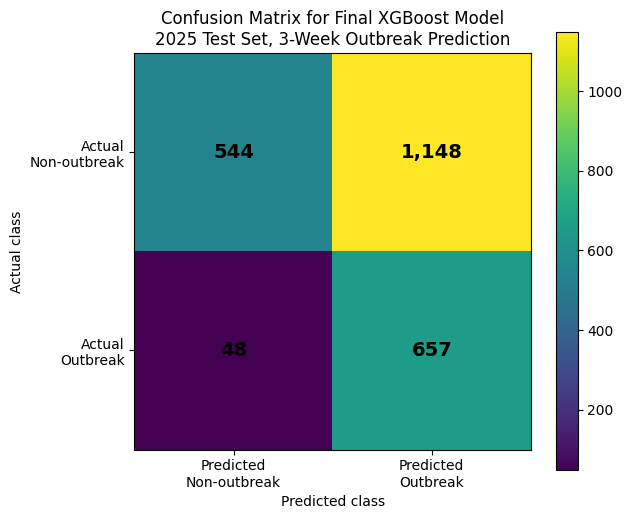

Figure saved as: confusion_matrix_final_xgboost_test_2025_h3.png


In [89]:
# Visualize final 2025 test confusion matrix

import matplotlib.pyplot as plt

# Use the confusion matrix calculated in STEP 102
cm_final_display = cm_final_test.copy()

fig, ax = plt.subplots(figsize=(6.5, 5.5))

im = ax.imshow(cm_final_display)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Predicted\nNon-outbreak",
    "Predicted\nOutbreak"
])

ax.set_yticklabels([
    "Actual\nNon-outbreak",
    "Actual\nOutbreak"
])

for i in range(cm_final_display.shape[0]):
    for j in range(cm_final_display.shape[1]):
        ax.text(
            j,
            i,
            f"{cm_final_display[i, j]:,}",
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold"
        )

ax.set_title(
    "Confusion Matrix for Final XGBoost Model\n"
    "2025 Test Set, 3-Week Outbreak Prediction",
    fontsize=12
)

ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")

plt.colorbar(im, ax=ax)
plt.tight_layout()

plt.savefig(
    "confusion_matrix_final_xgboost_test_2025_h3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved as: "
    "confusion_matrix_final_xgboost_test_2025_h3.png"
)


**Why this figure?** The test confusion matrix gives a direct count of the four possible outcomes on 2025 data and is therefore the clearest first visual for discussing operational classification behaviour.


In [90]:
# Save final 2025 test results

final_test_results.to_csv(
    "final_xgboost_test_results_2025_h3.csv",
    index=False
)

print("Saved final 2025 test results as:")
print("final_xgboost_test_results_2025_h3.csv")


Saved final 2025 test results as:
final_xgboost_test_results_2025_h3.csv


**Interpretation.** This step saves the derived output so that the result can be reproduced or used in the written report without manually recreating it.


In [91]:
# Threshold sensitivity check on 2025 test set
# This is for discussion only, not for retuning the final model

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

final_test_threshold_results = []

for threshold in thresholds:

    # Convert probabilities to predictions at this threshold
    pred_threshold = (final_test_prob_h3 >= threshold).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_final_test_h3, pred_threshold)
    tn, fp, fn, tp = cm.ravel()

    # Metrics
    accuracy = accuracy_score(y_final_test_h3, pred_threshold)
    precision = precision_score(y_final_test_h3, pred_threshold, zero_division=0)
    sensitivity = recall_score(y_final_test_h3, pred_threshold, zero_division=0)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_final_test_h3, pred_threshold, zero_division=0)
    balanced_accuracy = (sensitivity + specificity) / 2

    final_test_threshold_results.append({
        "Threshold": threshold,
        "Predicted outbreak alerts": int(tp + fp),
        "Correctly detected outbreaks": int(tp),
        "Missed outbreaks": int(fn),
        "False alarms": int(fp),
        "Accuracy": accuracy,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1-score": f1,
        "Balanced accuracy": balanced_accuracy
    })

final_test_threshold_results = pd.DataFrame(final_test_threshold_results)

round_cols = [
    "Accuracy", "Precision", "Sensitivity", "Specificity",
    "F1-score", "Balanced accuracy"
]

for col in round_cols:
    final_test_threshold_results[col] = final_test_threshold_results[col].round(4)

display(final_test_threshold_results)


,Threshold,Predicted outbreak alerts,Correctly detected outbreaks,Missed outbreaks,False alarms,Accuracy,Precision,Sensitivity,Specificity,F1-score,Balanced accuracy
0,0.10,2397,705,0,1692,0.2941,0.2941,1.0000,0.0000,0.4545,0.5000
1,0.15,2397,705,0,1692,0.2941,0.2941,1.0000,0.0000,0.4545,0.5000
2,0.20,2397,705,0,1692,0.2941,0.2941,1.0000,0.0000,0.4545,0.5000
3,0.25,2397,705,0,1692,0.2941,0.2941,1.0000,0.0000,0.4545,0.5000
4,0.30,2395,705,0,1690,0.2950,0.2944,1.0000,0.0012,0.4548,0.5006
5,0.35,2359,702,3,1657,0.3075,0.2976,0.9957,0.0207,0.4582,0.5082
6,0.40,2266,698,7,1568,0.3429,0.3080,0.9901,0.0733,0.4699,0.5317
7,0.45,2050,682,23,1368,0.4197,0.3327,0.9674,0.1915,0.4951,0.5794
8,0.50,1805,657,48,1148,0.5010,0.3640,0.9319,0.3215,0.5235,0.6267
9,0.55,1561,628,77,933,0.5786,0.4023,0.8908,0.4486,0.5543,0.6697


**Interpretation.** Testing several thresholds on the 2025 probabilities is shown only as a sensitivity check. The operational threshold remains **0.50**, because it was selected before the independent test evaluation.


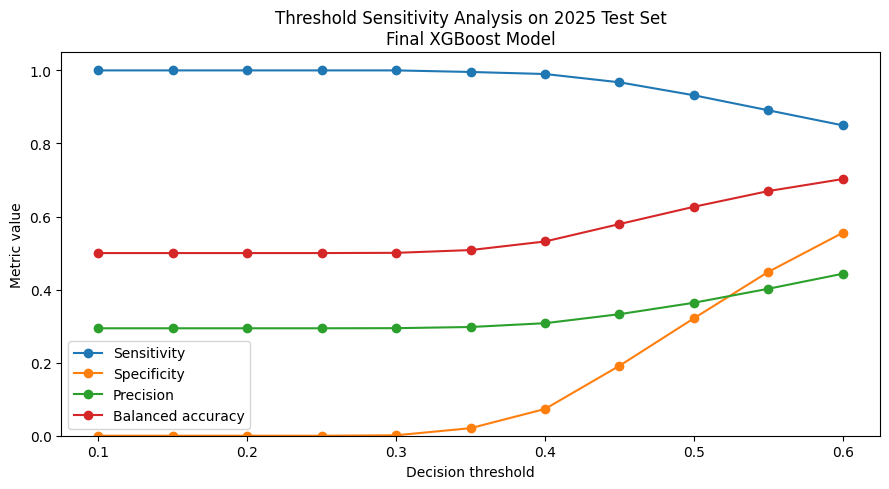

Figure saved as: threshold_sensitivity_final_test_2025_xgboost_h3.png


In [92]:
# Visualize threshold sensitivity on 2025 test set
# This is for discussion only, not for retuning the final model

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    final_test_threshold_results["Threshold"],
    final_test_threshold_results["Sensitivity"],
    marker="o",
    label="Sensitivity"
)

ax.plot(
    final_test_threshold_results["Threshold"],
    final_test_threshold_results["Specificity"],
    marker="o",
    label="Specificity"
)

ax.plot(
    final_test_threshold_results["Threshold"],
    final_test_threshold_results["Precision"],
    marker="o",
    label="Precision"
)

ax.plot(
    final_test_threshold_results["Threshold"],
    final_test_threshold_results["Balanced accuracy"],
    marker="o",
    label="Balanced accuracy"
)

ax.set_xlabel("Decision threshold")
ax.set_ylabel("Metric value")
ax.set_ylim(0, 1.05)

ax.set_title(
    "Threshold Sensitivity Analysis on 2025 Test Set\nFinal XGBoost Model"
)

ax.legend()
plt.tight_layout()

plt.savefig("threshold_sensitivity_final_test_2025_xgboost_h3.png", dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved as: threshold_sensitivity_final_test_2025_xgboost_h3.png")


**Why this figure?** The threshold-sensitivity plot illustrates what would happen if the alert cut-off were changed after deployment. It is diagnostic and does not redefine the pre-selected 0.50 operating threshold.


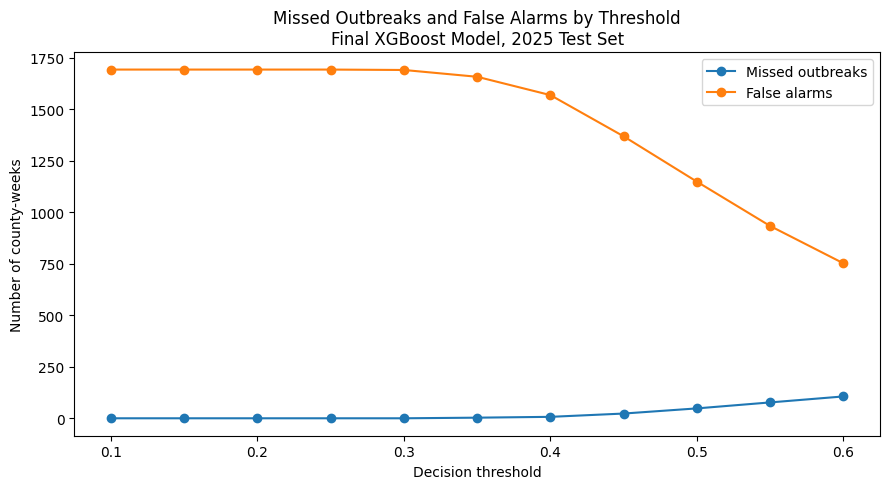

Figure saved as: missed_vs_false_alarms_final_test_2025_xgboost_h3.png


In [93]:
# Missed outbreaks vs false alarms on 2025 test set
# This is for discussion only, not for retuning the final model

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    final_test_threshold_results["Threshold"],
    final_test_threshold_results["Missed outbreaks"],
    marker="o",
    label="Missed outbreaks"
)

ax.plot(
    final_test_threshold_results["Threshold"],
    final_test_threshold_results["False alarms"],
    marker="o",
    label="False alarms"
)

ax.set_xlabel("Decision threshold")
ax.set_ylabel("Number of county-weeks")

ax.set_title(
    "Missed Outbreaks and False Alarms by Threshold\nFinal XGBoost Model, 2025 Test Set"
)

ax.legend()

plt.tight_layout()

plt.savefig("missed_vs_false_alarms_final_test_2025_xgboost_h3.png", dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved as: missed_vs_false_alarms_final_test_2025_xgboost_h3.png")


**Why this figure?** Missed outbreaks and false alarms are the two errors with the clearest public-health interpretation. Showing them together makes the alert trade-off immediately visible.


In [94]:
# Save final 2025 threshold sensitivity table

final_test_threshold_results.to_csv(
    "final_test_threshold_sensitivity_2025_xgboost_h3.csv",
    index=False
)

print("Saved final 2025 threshold sensitivity table as:")
print("final_test_threshold_sensitivity_2025_xgboost_h3.csv")


Saved final 2025 threshold sensitivity table as:
final_test_threshold_sensitivity_2025_xgboost_h3.csv


**Interpretation.** This step saves the derived output so that the result can be reproduced or used in the written report without manually recreating it.


## 10. County-specific ARIMA baseline

ARIMA is used as a classical time-series baseline. Unlike the pooled machine-learning models, ARIMA is fitted separately to each county's weekly cholera case series so that each county can have its own temporal structure.

Forecast case counts are later converted to the same binary outbreak definition used for XGBoost. The paired comparison is therefore based on the same 2025 target observations rather than comparing results from different samples.


In [95]:
# Prepare county-level weekly cholera case series for SARIMA

import pandas as pd
import numpy as np

# Use the raw dataset because SARIMA forecasts cholera case counts
sarima_data = raw.copy()

# Make sure week_start_date is a real date
sarima_data["week_start_date"] = pd.to_datetime(sarima_data["week_start_date"])

# Keep only the columns needed for county-level weekly case forecasting
sarima_data = sarima_data[
    ["county", "year", "epi_week", "week_start_date", "cholera_cases", "incidence_per_100k"]
].copy()

# Sort by county and week
sarima_data = sarima_data.sort_values(["county", "week_start_date"]).reset_index(drop=True)

# Check structure
print("SARIMA dataset shape:", sarima_data.shape)
print("Number of counties:", sarima_data["county"].nunique())
print("Date range:", sarima_data["week_start_date"].min(), "to", sarima_data["week_start_date"].max())

# Check number of weeks per county
weeks_per_county = sarima_data.groupby("county").size().reset_index(name="number_of_weeks")

print("\nMinimum weeks per county:", weeks_per_county["number_of_weeks"].min())
print("Maximum weeks per county:", weeks_per_county["number_of_weeks"].max())

display(weeks_per_county.head())


SARIMA dataset shape: (26978, 6)
Number of counties: 47
Date range: 2014-12-29 00:00:00 to 2025-12-22 00:00:00

Minimum weeks per county: 574
Maximum weeks per county: 574


,county,number_of_weeks
0,Baringo,574
1,Bomet,574
2,Bungoma,574
3,Busia,574
4,Elgeyo-Marakwet,574


**Interpretation.** This step prepares an intermediate dataset or object required for the analysis. Printing the resulting structure provides a quick check that the transformation behaved as intended.


In [96]:
# Check zero-case weeks by county for SARIMA

# Count zero-case weeks and total cases for each county
sarima_county_summary = (
    sarima_data.groupby("county")
    .agg(
        total_weeks=("cholera_cases", "count"),
        zero_case_weeks=("cholera_cases", lambda x: (x == 0).sum()),
        nonzero_case_weeks=("cholera_cases", lambda x: (x > 0).sum()),
        total_cases=("cholera_cases", "sum"),
        max_weekly_cases=("cholera_cases", "max")
    )
    .reset_index()
)

# Calculate percentage of zero-case weeks
sarima_county_summary["zero_case_percentage"] = (
    sarima_county_summary["zero_case_weeks"] /
    sarima_county_summary["total_weeks"]
) * 100

# Sort from most sparse to least sparse
sarima_county_summary = sarima_county_summary.sort_values(
    "zero_case_percentage",
    ascending=False
)

# Round percentage
sarima_county_summary["zero_case_percentage"] = sarima_county_summary[
    "zero_case_percentage"
].round(2)

display(sarima_county_summary)

print("Counties with more than 80% zero-case weeks:")
print((sarima_county_summary["zero_case_percentage"] > 80).sum())

print("\nCounties with more than 90% zero-case weeks:")
print((sarima_county_summary["zero_case_percentage"] > 90).sum())


,county,total_weeks,zero_case_weeks,nonzero_case_weeks,total_cases,max_weekly_cases,zero_case_percentage
20,Lamu,574,366,208,817,24,63.76
40,Tharaka-Nithi,574,361,213,556,22,62.89
4,Elgeyo-Marakwet,574,349,225,600,22,60.80
34,Nyandarua,574,348,226,563,20,60.63
14,Kirinyaga,574,347,227,548,20,60.45
33,Nyamira,574,346,228,563,24,60.28
1,Bomet,574,341,233,684,22,59.41
38,Taita Taveta,574,339,235,771,25,59.06
19,Laikipia,574,333,241,671,22,58.01
43,Uasin Gishu,574,330,244,804,29,57.49


Counties with more than 80% zero-case weeks:
0

Counties with more than 90% zero-case weeks:
0


**Interpretation.** Zero-case weeks are common in some county time series. This is important for ARIMA because sparse count series can be difficult to forecast and may favour simpler specifications.


In [97]:
# Split county-level SARIMA data into train and test

# Training period: 2015 to 2024
sarima_train = sarima_data[sarima_data["year"] <= 2024].copy()

# Test period: 2025
sarima_test = sarima_data[sarima_data["year"] == 2025].copy()

print("SARIMA training data shape:", sarima_train.shape)
print("SARIMA test data shape:", sarima_test.shape)

print("\nTraining years:")
print(sarima_train["year"].min(), "-", sarima_train["year"].max())

print("\nTest years:")
print(sarima_test["year"].min(), "-", sarima_test["year"].max())

print("\nTraining weeks per county:")
train_weeks_per_county = sarima_train.groupby("county").size()
print("Minimum:", train_weeks_per_county.min())
print("Maximum:", train_weeks_per_county.max())

print("\nTest weeks per county:")
test_weeks_per_county = sarima_test.groupby("county").size()
print("Minimum:", test_weeks_per_county.min())
print("Maximum:", test_weeks_per_county.max())

print("\nTotal training cases:", sarima_train["cholera_cases"].sum())
print("Total test cases:", sarima_test["cholera_cases"].sum())


SARIMA training data shape: (24534, 6)
SARIMA test data shape: (2444, 6)

Training years:
2015 - 2024

Test years:
2025 - 2025

Training weeks per county:
Minimum: 522
Maximum: 522

Test weeks per county:
Minimum: 52
Maximum: 52

Total training cases: 63977
Total test cases: 11188


**Interpretation.** This confirms that the model fitting step completed using the data and settings defined above. Performance is interpreted only in the following evaluation cells.


In [98]:
# Install and import SARIMA tools

!pip install pmdarima -q

from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

print("SARIMA tools imported successfully.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 25.3 MB/s eta 0:00:00
SARIMA tools imported successfully.


**Interpretation.** This output confirms that the required software tools for this stage are available before the analysis continues.


In [99]:
# Test SARIMA on one county first

# Choose one county for testing
test_county = "Nairobi"

# Prepare training series for this county
county_train = sarima_train[sarima_train["county"] == test_county].copy()
county_test = sarima_test[sarima_test["county"] == test_county].copy()

# Sort by week
county_train = county_train.sort_values("week_start_date")
county_test = county_test.sort_values("week_start_date")

# SARIMA target: weekly cholera cases
y_train_county = county_train["cholera_cases"]
y_test_county = county_test["cholera_cases"]

print("County:", test_county)
print("Training weeks:", len(y_train_county))
print("Test weeks:", len(y_test_county))
print("Training total cases:", y_train_county.sum())
print("Test total cases:", y_test_county.sum())

# Fit automatic SARIMA model
sarima_one_county = auto_arima(
    y_train_county,
    seasonal=True,
    m=52,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=True
)

print("\nBest SARIMA model selected:")
print(sarima_one_county.summary())

# Forecast 52 weeks of 2025
forecast_2025 = sarima_one_county.predict(n_periods=len(y_test_county))

# Make sure forecasts are not negative
forecast_2025 = np.maximum(forecast_2025, 0)

# Create comparison table
nairobi_sarima_forecast = pd.DataFrame({
    "county": test_county,
    "week_start_date": county_test["week_start_date"].values,
    "actual_cases": y_test_county.values,
    "forecast_cases": forecast_2025
})

display(nairobi_sarima_forecast.head(10))

print("SARIMA test for one county completed.")


County: Nairobi
Training weeks: 522
Test weeks: 52
Training total cases: 5758
Test total cases: 1326
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[52] intercept   : AIC=4089.817, Time=43.41 sec
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=4353.310, Time=0.09 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=4216.351, Time=7.52 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=4087.724, Time=10.50 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=4351.310, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[52] intercept   : AIC=4086.069, Time=0.36 sec
 ARIMA(0,1,1)(1,0,0)[52] intercept   : AIC=4087.672, Time=8.99 sec
 ARIMA(0,1,1)(1,0,1)[52] intercept   : AIC=4088.927, Time=15.71 sec
 ARIMA(1,1,1)(0,0,0)[52] intercept   : AIC=4087.678, Time=0.38 sec
 ARIMA(0,1,2)(0,0,0)[52] intercept   : AIC=4087.625, Time=1.07 sec
 ARIMA(1,1,0)(0,0,0)[52] intercept   : AIC=4216.454, Time=0.29 sec
 ARIMA(1,1,2)(0,0,0)[52] intercept   : AIC=4087.787, Time=1.34 sec
 ARIMA(0,1,1)(0,0,0)[52]             : AIC=4084.1

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,county,week_start_date,actual_cases,forecast_cases
522,Nairobi,2024-12-30,9,19.726495
523,Nairobi,2025-01-06,14,19.726495
524,Nairobi,2025-01-13,72,19.726495
525,Nairobi,2025-01-20,35,19.726495
526,Nairobi,2025-01-27,11,19.726495
527,Nairobi,2025-02-03,17,19.726495
528,Nairobi,2025-02-10,19,19.726495
529,Nairobi,2025-02-17,36,19.726495
530,Nairobi,2025-02-24,21,19.726495
531,Nairobi,2025-03-03,35,19.726495


SARIMA test for one county completed.


**Interpretation.** Testing the time-series workflow on one county first is a practical quality-control step. It allows the fitting and forecasting logic to be checked before running the procedure across all 47 counties.


In [100]:
# Evaluate Nairobi SARIMA forecast

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

# Case forecasting metrics
mae_nairobi = mean_absolute_error(
    nairobi_sarima_forecast["actual_cases"],
    nairobi_sarima_forecast["forecast_cases"]
)

rmse_nairobi = np.sqrt(
    mean_squared_error(
        nairobi_sarima_forecast["actual_cases"],
        nairobi_sarima_forecast["forecast_cases"]
    )
)

# Convert actual and forecast cases into outbreak alerts using case threshold >= 5
nairobi_sarima_forecast["actual_outbreak_cases_ge5"] = (
    nairobi_sarima_forecast["actual_cases"] >= 5
).astype(int)

nairobi_sarima_forecast["predicted_outbreak_cases_ge5"] = (
    nairobi_sarima_forecast["forecast_cases"] >= 5
).astype(int)

# Confusion matrix for outbreak alert performance
cm_nairobi_sarima = confusion_matrix(
    nairobi_sarima_forecast["actual_outbreak_cases_ge5"],
    nairobi_sarima_forecast["predicted_outbreak_cases_ge5"]
)

tn, fp, fn, tp = cm_nairobi_sarima.ravel()

accuracy_nairobi = accuracy_score(
    nairobi_sarima_forecast["actual_outbreak_cases_ge5"],
    nairobi_sarima_forecast["predicted_outbreak_cases_ge5"]
)

precision_nairobi = precision_score(
    nairobi_sarima_forecast["actual_outbreak_cases_ge5"],
    nairobi_sarima_forecast["predicted_outbreak_cases_ge5"],
    zero_division=0
)

sensitivity_nairobi = recall_score(
    nairobi_sarima_forecast["actual_outbreak_cases_ge5"],
    nairobi_sarima_forecast["predicted_outbreak_cases_ge5"],
    zero_division=0
)

specificity_nairobi = tn / (tn + fp) if (tn + fp) > 0 else 0

f1_nairobi = f1_score(
    nairobi_sarima_forecast["actual_outbreak_cases_ge5"],
    nairobi_sarima_forecast["predicted_outbreak_cases_ge5"],
    zero_division=0
)

balanced_accuracy_nairobi = (sensitivity_nairobi + specificity_nairobi) / 2

# Create results table
nairobi_sarima_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "Actual outbreak weeks",
        "Predicted outbreak alerts",
        "Correctly detected outbreak weeks",
        "Missed outbreak weeks",
        "False alarms",
        "Accuracy",
        "Precision",
        "Sensitivity / Recall",
        "Specificity",
        "F1-score",
        "Balanced accuracy"
    ],
    "Value": [
        round(mae_nairobi, 4),
        round(rmse_nairobi, 4),
        int(tp + fn),
        int(tp + fp),
        int(tp),
        int(fn),
        int(fp),
        round(accuracy_nairobi, 4),
        round(precision_nairobi, 4),
        round(sensitivity_nairobi, 4),
        round(specificity_nairobi, 4),
        round(f1_nairobi, 4),
        round(balanced_accuracy_nairobi, 4)
    ]
})

print("Nairobi SARIMA confusion matrix:")
print(cm_nairobi_sarima)

display(nairobi_sarima_results)


Nairobi SARIMA confusion matrix:
[[ 0  5]
 [ 0 47]]


,Metric,Value
0,MAE,14.5316
1,RMSE,29.9841
2,Actual outbreak weeks,47.0000
3,Predicted outbreak alerts,52.0000
4,Correctly detected outbreak weeks,47.0000
5,Missed outbreak weeks,0.0000
6,False alarms,5.0000
7,Accuracy,0.9038
8,Precision,0.9038
9,Sensitivity / Recall,1.0000


**Interpretation.** The Nairobi example shows how forecast case counts are compared with observed values before the county-wide baseline is run. The purpose is to verify the forecasting pipeline, not to treat Nairobi as representative of every county.


In [101]:
# Fit faster county-level ARIMA and SARIMA models
# across all 47 counties

from pmdarima import auto_arima

import pandas as pd
import numpy as np
import time
import warnings

warnings.filterwarnings("ignore")

all_baseline_forecasts = []
all_baseline_model_info = []

counties = sorted(
    sarima_data["county"]
    .dropna()
    .unique()
)

print("Number of counties:", len(counties))

start_time = time.time()

for county_number, county in enumerate(
    counties,
    start=1
):

    print(
        f"\nCounty {county_number}/{len(counties)}: "
        f"{county}"
    )

    county_train = (
        sarima_train[
            sarima_train["county"] == county
        ]
        .sort_values("week_start_date")
        .copy()
    )

    county_test = (
        sarima_test[
            sarima_test["county"] == county
        ]
        .sort_values("week_start_date")
        .copy()
    )

    y_train = (
        county_train["cholera_cases"]
        .to_numpy()
    )

    y_test = (
        county_test["cholera_cases"]
        .to_numpy()
    )

    if len(y_train) == 0 or len(y_test) == 0:
        print("  Skipped: missing train or test data.")
        continue

    for model_name in ["ARIMA", "SARIMA"]:

        print(f"  Fitting {model_name}...")

        model_start = time.time()

        try:

            if model_name == "ARIMA":

                fitted_model = auto_arima(
                    y_train,
                    seasonal=False,
                    start_p=0,
                    start_q=0,
                    max_p=2,
                    max_q=2,
                    max_d=1,
                    stepwise=True,
                    suppress_warnings=True,
                    error_action="ignore",
                    trace=False,
                    information_criterion="aic"
                )

            else:

                fitted_model = auto_arima(
                    y_train,
                    seasonal=True,
                    m=52,
                    start_p=0,
                    start_q=0,
                    start_P=0,
                    start_Q=0,
                    max_p=2,
                    max_q=2,
                    max_d=1,
                    max_P=1,
                    max_Q=1,
                    max_D=1,
                    stepwise=True,
                    suppress_warnings=True,
                    error_action="ignore",
                    trace=False,
                    information_criterion="aic"
                )

            forecast = fitted_model.predict(
                n_periods=len(y_test)
            )

            forecast = np.maximum(
                np.asarray(
                    forecast,
                    dtype=float
                ),
                0
            )

            model_order = fitted_model.order

            seasonal_order = getattr(
                fitted_model,
                "seasonal_order",
                (0, 0, 0, 0)
            )

            model_aic = fitted_model.aic()
            status = "success"
            error_message = ""

        except Exception as error:

            print(
                f"  {model_name} failed for {county}."
            )

            forecast = np.repeat(
                np.mean(y_train),
                len(y_test)
            )

            forecast = np.maximum(
                forecast,
                0
            )

            model_order = None
            seasonal_order = None
            model_aic = np.nan
            status = "failed_used_training_mean"
            error_message = str(error)

        runtime_seconds = (
            time.time() - model_start
        )

        print(
            f"  Finished {model_name} in "
            f"{runtime_seconds:.1f} seconds"
        )

        county_forecast = pd.DataFrame({
            "county": county,
            "week_start_date":
                county_test[
                    "week_start_date"
                ].to_numpy(),
            "actual_cases": y_test,
            "forecast_cases": forecast,
            "model": model_name
        })

        all_baseline_forecasts.append(
            county_forecast
        )

        all_baseline_model_info.append({
            "county": county,
            "model": model_name,
            "order": str(model_order),
            "seasonal_order":
                str(seasonal_order),
            "aic": model_aic,
            "status": status,
            "error_message": error_message,
            "training_weeks":
                len(y_train),
            "test_weeks":
                len(y_test),
            "runtime_seconds":
                runtime_seconds
        })

baseline_forecasts = pd.concat(
    all_baseline_forecasts,
    ignore_index=True
)

baseline_model_info = pd.DataFrame(
    all_baseline_model_info
)

total_runtime_minutes = (
    time.time() - start_time
) / 60

print("\nModel fitting completed.")
print(
    "Total runtime:",
    round(total_runtime_minutes, 2),
    "minutes"
)

display(
    baseline_model_info.head(10)
)


Number of counties: 47

County 1/47: Baringo
  Fitting ARIMA...
  Finished ARIMA in 16.2 seconds
  Fitting SARIMA...
  Finished SARIMA in 241.0 seconds

County 2/47: Bomet
  Fitting ARIMA...
  Finished ARIMA in 8.3 seconds
  Fitting SARIMA...
  Finished SARIMA in 87.6 seconds

County 3/47: Bungoma
  Fitting ARIMA...
  Finished ARIMA in 1.8 seconds
  Fitting SARIMA...
  Finished SARIMA in 41.4 seconds

County 4/47: Busia
  Fitting ARIMA...
  Finished ARIMA in 4.0 seconds
  Fitting SARIMA...
  Finished SARIMA in 224.0 seconds

County 5/47: Elgeyo-Marakwet
  Fitting ARIMA...
  Finished ARIMA in 4.9 seconds
  Fitting SARIMA...
  Finished SARIMA in 95.4 seconds

County 6/47: Embu
  Fitting ARIMA...
  Finished ARIMA in 2.8 seconds
  Fitting SARIMA...
  Finished SARIMA in 19.5 seconds

County 7/47: Garissa
  Fitting ARIMA...
  Finished ARIMA in 4.2 seconds
  Fitting SARIMA...
  Finished SARIMA in 45.5 seconds

County 8/47: Homa Bay
  Fitting ARIMA...
  Finished ARIMA in 5.0 seconds
  Fitting 

,county,model,order,seasonal_order,aic,status,error_message,training_weeks,test_weeks,runtime_seconds
0,Baringo,ARIMA,"(1, 1, 1)","(0, 0, 0, 0)",2740.583815,success,,522,52,16.235188
1,Baringo,SARIMA,"(1, 1, 1)","(1, 0, 0, 52)",2738.456856,success,,522,52,240.972742
2,Bomet,ARIMA,"(1, 0, 1)","(0, 0, 0, 0)",2416.238784,success,,522,52,8.288061
3,Bomet,SARIMA,"(1, 0, 1)","(0, 0, 0, 52)",2416.238784,success,,522,52,87.646485
4,Bungoma,ARIMA,"(0, 1, 1)","(0, 0, 0, 0)",2584.311613,success,,522,52,1.812361
5,Bungoma,SARIMA,"(0, 1, 1)","(0, 0, 0, 52)",2584.311613,success,,522,52,41.449192
6,Busia,ARIMA,"(1, 0, 2)","(0, 0, 0, 0)",4037.770925,success,,522,52,4.015387
7,Busia,SARIMA,"(1, 0, 2)","(0, 0, 0, 52)",4037.770925,success,,522,52,223.966217
8,Elgeyo-Marakwet,ARIMA,"(1, 0, 1)","(0, 0, 0, 0)",2350.899685,success,,522,52,4.877277
9,Elgeyo-Marakwet,SARIMA,"(1, 0, 1)","(0, 0, 0, 52)",2350.899685,success,,522,52,95.377444


**Interpretation.** County-specific ARIMA and seasonal alternatives are fitted across the study counties. The later model comparison uses the specification that can be applied consistently and compared on the same 2025 observations.


In [102]:
# Check successful fits and
# retained seasonal components

import ast
import pandas as pd
import numpy as np

# Overall fitting status

fit_status_summary = (
    baseline_model_info
    .groupby(["model", "status"])
    .size()
    .reset_index(name="number_of_counties")
)

print("Model fitting status:")
display(fit_status_summary)

# Extract SARIMA model information

sarima_model_info_only = baseline_model_info[
    baseline_model_info["model"] == "SARIMA"
].copy()

def parse_seasonal_order(value):
    """
    Convert the saved seasonal-order string into a tuple.
    Expected form: '(P, D, Q, m)'
    """
    try:
        parsed = ast.literal_eval(str(value))

        if (
            isinstance(parsed, tuple)
            and len(parsed) == 4
        ):
            return parsed

    except Exception:
        pass

    return (np.nan, np.nan, np.nan, np.nan)


sarima_model_info_only[
    "seasonal_order_tuple"
] = sarima_model_info_only[
    "seasonal_order"
].apply(parse_seasonal_order)

# A genuine seasonal component exists only when at least one
# of P, D or Q is greater than zero.
#
# The order (0, 0, 0, 52) has a seasonal period of 52,
# but contains no seasonal AR, differencing or MA terms.

sarima_model_info_only[
    "retained_seasonal_component"
] = sarima_model_info_only[
    "seasonal_order_tuple"
].apply(
    lambda order: (
        order[0] > 0
        or order[1] > 0
        or order[2] > 0
    )
    if not pd.isna(order[0])
    else False
)

successful_sarima = sarima_model_info_only[
    sarima_model_info_only["status"] == "success"
].copy()

number_submitted = len(
    sarima_model_info_only
)

number_successful = len(
    successful_sarima
)

number_retaining_seasonality = int(
    successful_sarima[
        "retained_seasonal_component"
    ].sum()
)

number_without_seasonal_terms = int(
    number_successful
    - number_retaining_seasonality
)

seasonality_summary = pd.DataFrame({
    "Measure": [
        "Counties submitted for SARIMA",
        "Successful SARIMA fits",
        "Failed SARIMA fits",
        "SARIMA fits retaining seasonal terms",
        "SARIMA fits selecting no seasonal terms"
    ],
    "Value": [
        number_submitted,
        number_successful,
        number_submitted - number_successful,
        number_retaining_seasonality,
        number_without_seasonal_terms
    ]
})

print("Corrected SARIMA seasonality summary:")
display(seasonality_summary)

print("County-specific SARIMA orders:")
display(
    sarima_model_info_only[
        [
            "county",
            "order",
            "seasonal_order",
            "aic",
            "status",
            "retained_seasonal_component"
        ]
    ].sort_values("county")
)


Model fitting status:


,model,status,number_of_counties
0,ARIMA,success,47
1,SARIMA,success,47


Corrected SARIMA seasonality summary:


,Measure,Value
0,Counties submitted for SARIMA,47
1,Successful SARIMA fits,47
2,Failed SARIMA fits,0
3,SARIMA fits retaining seasonal terms,4
4,SARIMA fits selecting no seasonal terms,43


County-specific SARIMA orders:


,county,order,seasonal_order,aic,status,retained_seasonal_component
1,Baringo,"(1, 1, 1)","(1, 0, 0, 52)",2738.456856,success,True
3,Bomet,"(1, 0, 1)","(0, 0, 0, 52)",2416.238784,success,False
5,Bungoma,"(0, 1, 1)","(0, 0, 0, 52)",2584.311613,success,False
7,Busia,"(1, 0, 2)","(0, 0, 0, 52)",4037.770925,success,False
9,Elgeyo-Marakwet,"(1, 0, 1)","(0, 0, 0, 52)",2350.899685,success,False
11,Embu,"(0, 0, 0)","(0, 0, 0, 52)",2752.505101,success,False
13,Garissa,"(0, 1, 1)","(0, 0, 0, 52)",4251.171613,success,False
15,Homa Bay,"(0, 1, 1)","(0, 0, 0, 52)",3802.557938,success,False
17,Isiolo,"(0, 0, 0)","(1, 0, 0, 52)",2738.633821,success,True
19,Kajiado,"(1, 0, 0)","(0, 0, 0, 52)",4046.907305,success,False


**Interpretation.** This is a quality-control check. The output is used to confirm that the data or model objects satisfy the assumptions needed for the next stage rather than introducing a new modelling result.


In [103]:
# Compare ARIMA and SARIMA case-count forecasts
# on the full 2025 test period

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np
import pandas as pd

case_forecast_results = []

# IMPORTANT:
# Use forecast_group as the loop variable so the primary
# machine-learning dataset remains unchanged.
for model_name, forecast_group in baseline_forecasts.groupby(
    "model"
):

    actual_cases = (
        forecast_group[
            "actual_cases"
        ].to_numpy()
    )

    predicted_cases = (
        forecast_group[
            "forecast_cases"
        ].to_numpy()
    )

    # Mean absolute error
    mae = mean_absolute_error(
        actual_cases,
        predicted_cases
    )

    # Root mean squared error
    rmse = np.sqrt(
        mean_squared_error(
            actual_cases,
            predicted_cases
        )
    )

    # Symmetric mean absolute percentage error.
    # This is more appropriate than ordinary MAPE where
    # actual weekly case counts may equal zero.
    denominator = (
        np.abs(actual_cases)
        + np.abs(predicted_cases)
    )

    smape_terms = np.where(
        denominator == 0,
        0,
        (
            2
            * np.abs(
                predicted_cases
                - actual_cases
            )
            / denominator
        )
    )

    smape = (
        100
        * np.mean(smape_terms)
    )

    case_forecast_results.append({
        "Model": model_name,
        "Test observations":
            len(forecast_group),
        "Actual cases":
            int(actual_cases.sum()),
        "Forecast cases":
            round(
                predicted_cases.sum(),
                2
            ),
        "MAE": mae,
        "RMSE": rmse,
        "sMAPE (%)": smape
    })

case_forecast_comparison = pd.DataFrame(
    case_forecast_results
)

for column in [
    "MAE",
    "RMSE",
    "sMAPE (%)"
]:

    case_forecast_comparison[
        column
    ] = (
        case_forecast_comparison[
            column
        ]
        .round(4)
    )

print(
    "ARIMA versus SARIMA case-count "
    "forecasting performance:"
)

display(case_forecast_comparison)


ARIMA versus SARIMA case-count forecasting performance:


,Model,Test observations,Actual cases,Forecast cases,MAE,RMSE,sMAPE (%)
0,ARIMA,2444,11188,10999.17,3.7660,9.4519,109.2862
1,SARIMA,2444,11188,11056.66,3.7781,9.4526,109.4235


**Interpretation.** The ARIMA/SARIMA forecast comparison helps determine whether adding seasonal structure provides enough benefit to justify the additional complexity. The subsequent paired early-warning comparison uses the retained non-seasonal ARIMA baseline.


## 11. Model interpretation with SHAP

After evaluating predictive performance, I use SHAP to examine how the fitted XGBoost model uses its predictors.

The global importance plot ranks predictors by average absolute contribution, the beeswarm plot shows both magnitude and direction, and dependence plots examine selected predictors in more detail. These are **model-attribution** results: they explain the fitted prediction function and are not interpreted as causal effects.


In [104]:
# Check and import SHAP

try:
    import shap
    print("SHAP is already installed and imported successfully.")
except ImportError:
    print("SHAP is not installed. Run the next installation cell before continuing.")


SHAP is already installed and imported successfully.


**Interpretation.** This output confirms that the required software tools for this stage are available before the analysis continues.


In [105]:
# Compute SHAP values for final XGBoost model

# Use a sample of the 2025 test data for faster SHAP computation
# If the test set is small enough, this will still work well
X_shap_test = X_final_test_h3.copy()

print("SHAP data shape:", X_shap_test.shape)

# Create SHAP explainer for the final XGBoost model
explainer = shap.TreeExplainer(final_xgb_h3)

# Compute SHAP values
shap_values = explainer.shap_values(X_shap_test)

print("SHAP values computed successfully.")
print("SHAP values shape:", shap_values.shape)


SHAP data shape: (2397, 23)
SHAP values computed successfully.
SHAP values shape: (2397, 23)


**Interpretation.** SHAP values are computed for the fitted XGBoost predictions. Each value represents how a predictor shifts the model output for an observation relative to the model's baseline prediction.


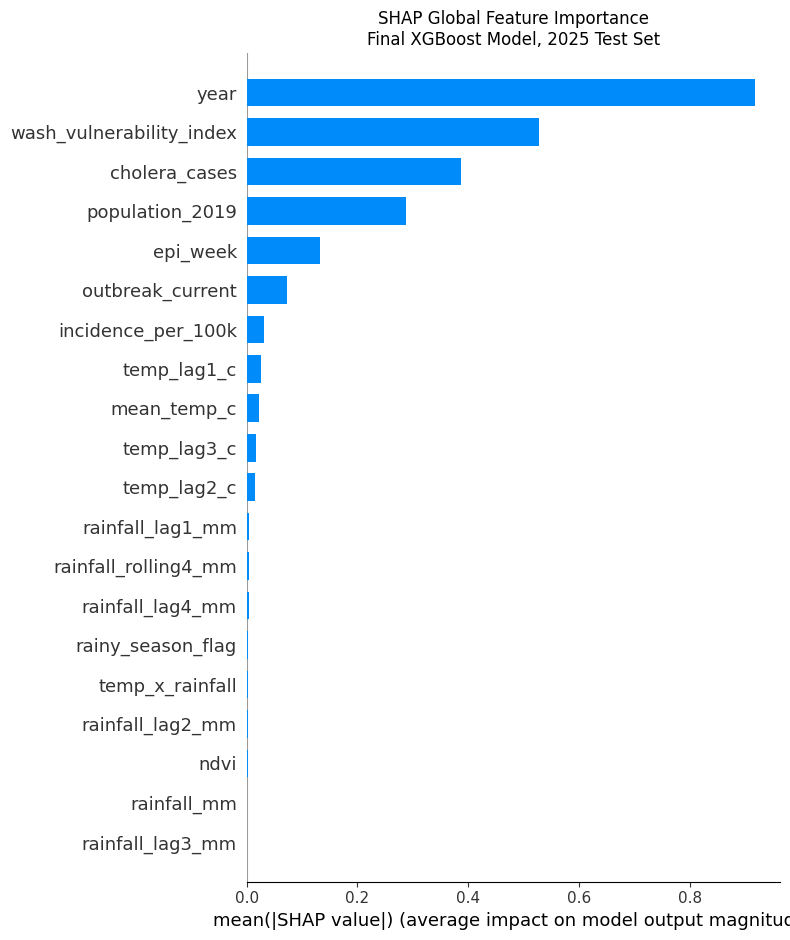

Figure saved as: shap_global_feature_importance_final_xgboost_2025_h3.png


In [106]:
# SHAP global feature importance plot

import matplotlib.pyplot as plt

# Create SHAP summary bar plot
shap.summary_plot(
    shap_values,
    X_shap_test,
    plot_type="bar",
    show=False
)

plt.title(
    "SHAP Global Feature Importance\nFinal XGBoost Model, 2025 Test Set",
    fontsize=12
)

plt.tight_layout()

plt.savefig(
    "shap_global_feature_importance_final_xgboost_2025_h3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved as: shap_global_feature_importance_final_xgboost_2025_h3.png")


**Why this figure?** Mean absolute SHAP values provide a compact global ranking of which predictors the fitted model relies on most strongly. The ranking describes predictive influence, not causal importance.


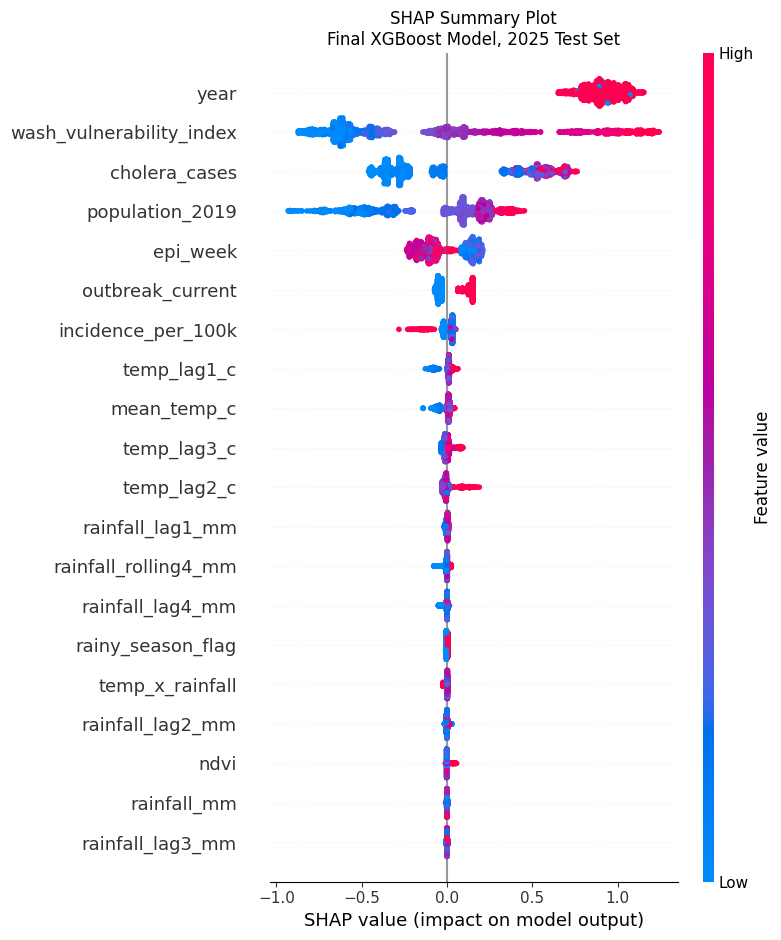

Figure saved as: shap_summary_beeswarm_final_xgboost_2025_h3.png


In [107]:
# SHAP summary beeswarm plot

import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_shap_test,
    show=False
)

plt.title(
    "SHAP Summary Plot\nFinal XGBoost Model, 2025 Test Set",
    fontsize=12
)

plt.tight_layout()

plt.savefig(
    "shap_summary_beeswarm_final_xgboost_2025_h3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved as: shap_summary_beeswarm_final_xgboost_2025_h3.png")


**Why this figure?** The SHAP beeswarm adds direction to the global ranking. It shows whether high or low values of a predictor tend to move the fitted outbreak score upward or downward and how variable that effect is across observations.


In [108]:
# Create SHAP feature importance table

import numpy as np
import pandas as pd

# Mean absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_table = pd.DataFrame({
    "Feature": X_shap_test.columns,
    "Mean absolute SHAP value": mean_abs_shap
})

# Sort from most important to least important
shap_importance_table = shap_importance_table.sort_values(
    by="Mean absolute SHAP value",
    ascending=False
).reset_index(drop=True)

shap_importance_table["Rank"] = shap_importance_table.index + 1

# Reorder columns
shap_importance_table = shap_importance_table[
    ["Rank", "Feature", "Mean absolute SHAP value"]
]

shap_importance_table["Mean absolute SHAP value"] = shap_importance_table[
    "Mean absolute SHAP value"
].round(4)

display(shap_importance_table)


,Rank,Feature,Mean absolute SHAP value
0,1,year,0.9167
1,2,wash_vulnerability_index,0.5272
2,3,cholera_cases,0.3871
3,4,population_2019,0.2869
4,5,epi_week,0.1325
5,6,outbreak_current,0.0730
6,7,incidence_per_100k,0.0315
7,8,temp_lag1_c,0.0256
8,9,mean_temp_c,0.0216
9,10,temp_lag3_c,0.0175


**Interpretation.** The SHAP importance table provides the numerical values behind the global importance figure, making the ranking reproducible and easier to inspect.


In [109]:
# Save SHAP feature importance table

shap_importance_table.to_csv(
    "shap_feature_importance_final_xgboost_2025_h3.csv",
    index=False
)

print("Saved SHAP feature importance table as:")
print("shap_feature_importance_final_xgboost_2025_h3.csv")


Saved SHAP feature importance table as:
shap_feature_importance_final_xgboost_2025_h3.csv


**Interpretation.** This output confirms that the required software tools for this stage are available before the analysis continues.


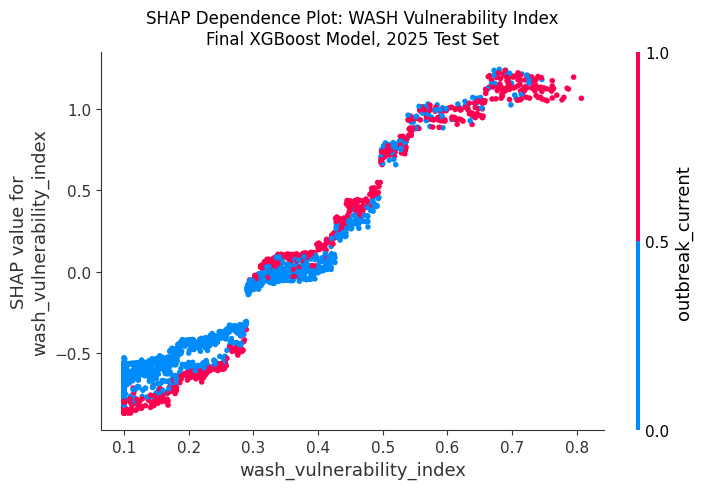

Figure saved as: shap_dependence_wash_vulnerability_final_xgboost_2025_h3.png


In [110]:
# SHAP dependence plot for WASH vulnerability

import matplotlib.pyplot as plt

shap.dependence_plot(
    "wash_vulnerability_index",
    shap_values,
    X_shap_test,
    show=False
)

plt.title(
    "SHAP Dependence Plot: WASH Vulnerability Index\nFinal XGBoost Model, 2025 Test Set",
    fontsize=12
)

plt.tight_layout()

plt.savefig(
    "shap_dependence_wash_vulnerability_final_xgboost_2025_h3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved as: shap_dependence_wash_vulnerability_final_xgboost_2025_h3.png")


**Why this figure?** The WASH dependence plot is included because WASH vulnerability is one of the strongest non-temporal contributors. The nonlinear shape shows how the fitted model uses this predictor across its observed range.


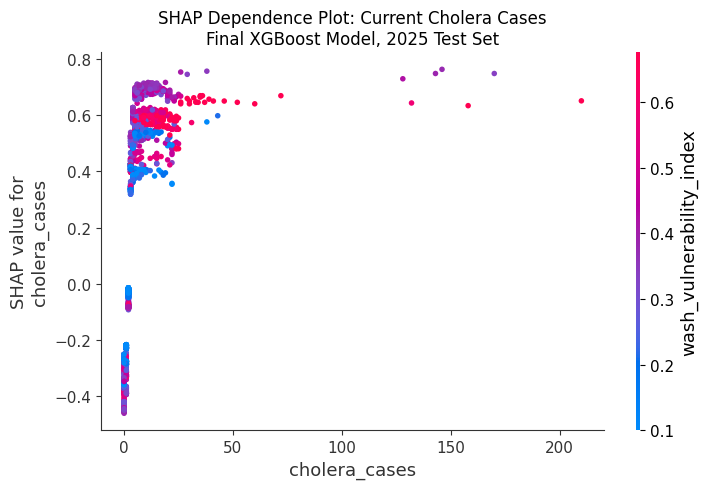

Figure saved as:
shap_dependence_cholera_cases_final_xgboost_2025_h3.png


In [111]:
# SHAP dependence plot for current cholera cases

import matplotlib.pyplot as plt

shap.dependence_plot(
    "cholera_cases",
    shap_values,
    X_shap_test,
    show=False
)

plt.title(
    "SHAP Dependence Plot: Current Cholera Cases\nFinal XGBoost Model, 2025 Test Set",
    fontsize=12
)

plt.tight_layout()

plt.savefig(
    "shap_dependence_cholera_cases_final_xgboost_2025_h3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved as:")
print("shap_dependence_cholera_cases_final_xgboost_2025_h3.png")


**Why this figure?** Current cholera cases provide an intuitive epidemiological signal for short-term risk. The dependence plot shows how present case activity contributes to the fitted three-week-ahead score without using future cases as a predictor.


In [112]:
# Confirm final SHAP outputs

import os

shap_files = [
    "shap_global_feature_importance_final_xgboost_2025_h3.png",
    "shap_summary_beeswarm_final_xgboost_2025_h3.png",
    "shap_feature_importance_final_xgboost_2025_h3.csv",
    "shap_dependence_wash_vulnerability_final_xgboost_2025_h3.png",
    "shap_dependence_cholera_cases_final_xgboost_2025_h3.png"
]

for file in shap_files:
    print(file, "exists:", os.path.exists(file))


shap_global_feature_importance_final_xgboost_2025_h3.png exists: True
shap_summary_beeswarm_final_xgboost_2025_h3.png exists: True
shap_feature_importance_final_xgboost_2025_h3.csv exists: True
shap_dependence_wash_vulnerability_final_xgboost_2025_h3.png exists: True
shap_dependence_cholera_cases_final_xgboost_2025_h3.png exists: True


**Interpretation.** This is a quality-control check. The output is used to confirm that the data or model objects satisfy the assumptions needed for the next stage rather than introducing a new modelling result.


In [113]:
from google.colab import files
import zipfile
import os

figure_files = [
    "confusion_matrix_best_xgboost_validation_h3.png",
    "xgboost_threshold_tradeoff_metrics_validation_h3.png",
    "predictor_group_comparison_xgboost_validation_h3.png",
    "expanding_window_performance_by_year_xgboost_h3.png",
    "confusion_matrix_final_xgboost_test_2025_h3.png",
    "corrected_arima_vs_xgboost_metrics_outbreak_h3_2025.png",
    "shap_global_feature_importance_final_xgboost_2025_h3.png",
    "shap_summary_beeswarm_final_xgboost_2025_h3.png",
    "shap_dependence_wash_vulnerability_final_xgboost_2025_h3.png",
    "shap_dependence_cholera_cases_final_xgboost_2025_h3.png"
]

existing_files = [f for f in figure_files if os.path.exists(f)]
missing_files = [f for f in figure_files if not os.path.exists(f)]

with zipfile.ZipFile("CHRONOS_presentation_figures.zip", "w") as zip_file:
    for filename in existing_files:
        zip_file.write(filename)

print("Files added:", len(existing_files))

if missing_files:
    print("Missing files:")
    for filename in missing_files:
        print(filename)

files.download("CHRONOS_presentation_figures.zip")


Files added: 9
Missing files:
corrected_arima_vs_xgboost_metrics_outbreak_h3_2025.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Interpretation.** This output confirms that the required software tools for this stage are available before the analysis continues.


## 12. Additional model diagnostics, sensitivity and calibration

This section looks more closely at modelling choices that could affect interpretation. I examine the joint effect of class weighting and threshold selection, the role of calendar year, feature importance, SHAP dependence patterns and probability calibration.

These checks are useful because a model can discriminate between high- and low-risk observations while still producing probabilities that are poorly calibrated or relying heavily on a predictor that may not generalise well to future periods.


In [114]:
# Joint class-weight and threshold tuning
# Validation period only: 2023–2024

import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

# Candidate class weights
candidate_weights = [2, 3, 4, 5, 6]

# Candidate probability thresholds
candidate_thresholds = np.round(
    np.arange(0.30, 0.81, 0.05),
    2
)

joint_tuning_results = []

for weight in candidate_weights:

    # Train model using training data only
    tuning_model = XGBClassifier(
        n_estimators=300,
        max_depth=2,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    tuning_model.fit(
        X_train_h3,
        y_train_h3
    )

    # Generate validation probabilities
    validation_probabilities = (
        tuning_model.predict_proba(
            X_valid_h3
        )[:, 1]
    )

    # Threshold-independent metrics
    roc_auc = roc_auc_score(
        y_valid_h3,
        validation_probabilities
    )

    pr_auc = average_precision_score(
        y_valid_h3,
        validation_probabilities
    )

    brier = brier_score_loss(
        y_valid_h3,
        validation_probabilities
    )

    for threshold in candidate_thresholds:

        validation_predictions = (
            validation_probabilities >= threshold
        ).astype(int)

        cm = confusion_matrix(
            y_valid_h3,
            validation_predictions
        )

        tn, fp, fn, tp = cm.ravel()

        accuracy = accuracy_score(
            y_valid_h3,
            validation_predictions
        )

        precision = precision_score(
            y_valid_h3,
            validation_predictions,
            zero_division=0
        )

        sensitivity = recall_score(
            y_valid_h3,
            validation_predictions,
            zero_division=0
        )

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else 0
        )

        f1 = f1_score(
            y_valid_h3,
            validation_predictions,
            zero_division=0
        )

        balanced_accuracy = (
            sensitivity + specificity
        ) / 2

        youden_j = (
            sensitivity + specificity - 1
        )

        joint_tuning_results.append({
            "scale_pos_weight": weight,
            "threshold": threshold,
            "actual_outbreaks": int(tp + fn),
            "predicted_alerts": int(tp + fp),
            "true_positives": int(tp),
            "false_negatives": int(fn),
            "false_positives": int(fp),
            "true_negatives": int(tn),
            "accuracy": accuracy,
            "precision": precision,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "f1_score": f1,
            "balanced_accuracy": balanced_accuracy,
            "youden_j": youden_j,
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
            "brier_score": brier
        })

joint_tuning_results = pd.DataFrame(
    joint_tuning_results
)

metric_columns = [
    "accuracy",
    "precision",
    "sensitivity",
    "specificity",
    "f1_score",
    "balanced_accuracy",
    "youden_j",
    "roc_auc",
    "pr_auc",
    "brier_score"
]

joint_tuning_results[metric_columns] = (
    joint_tuning_results[metric_columns]
    .round(4)
)

print(
    "Number of weight-threshold combinations:",
    len(joint_tuning_results)
)

display(
    joint_tuning_results.head(15)
)


Number of weight-threshold combinations: 55


,scale_pos_weight,threshold,actual_outbreaks,predicted_alerts,true_positives,false_negatives,false_positives,true_negatives,accuracy,precision,sensitivity,specificity,f1_score,balanced_accuracy,youden_j,roc_auc,pr_auc,brier_score
0,2,0.30,1599,1370,932,667,438,2898,0.7761,0.6803,0.5829,0.8687,0.6278,0.7258,0.4516,0.7702,0.6559,0.1742
1,2,0.35,1599,1210,863,736,347,2989,0.7805,0.7132,0.5397,0.8960,0.6145,0.7178,0.4357,0.7702,0.6559,0.1742
2,2,0.40,1599,1064,802,797,262,3074,0.7854,0.7538,0.5016,0.9215,0.6023,0.7115,0.4230,0.7702,0.6559,0.1742
3,2,0.45,1599,849,657,942,192,3144,0.7702,0.7739,0.4109,0.9424,0.5368,0.6767,0.3533,0.7702,0.6559,0.1742
4,2,0.50,1599,723,568,1031,155,3181,0.7597,0.7856,0.3552,0.9535,0.4892,0.6544,0.3088,0.7702,0.6559,0.1742
5,2,0.55,1599,539,432,1167,107,3229,0.7418,0.8015,0.2702,0.9679,0.4041,0.6190,0.2381,0.7702,0.6559,0.1742
6,2,0.60,1599,356,285,1314,71,3265,0.7194,0.8006,0.1782,0.9787,0.2916,0.5785,0.1570,0.7702,0.6559,0.1742
7,2,0.65,1599,233,189,1410,44,3292,0.7054,0.8112,0.1182,0.9868,0.2063,0.5525,0.1050,0.7702,0.6559,0.1742
8,2,0.70,1599,154,120,1479,34,3302,0.6934,0.7792,0.0750,0.9898,0.1369,0.5324,0.0649,0.7702,0.6559,0.1742
9,2,0.75,1599,102,81,1518,21,3315,0.6881,0.7941,0.0507,0.9937,0.0952,0.5222,0.0444,0.7702,0.6559,0.1742


**Interpretation.** Jointly examining class weight and threshold helps separate two different controls on the alert profile: the weight affects model fitting, while the threshold affects how fitted probabilities are converted into alerts.


In [115]:
# Rank candidate models

ranking = (
    joint_tuning_results
    .sort_values(
        by=[
            "balanced_accuracy",
            "specificity",
            "sensitivity"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top 20 combinations")

display(ranking.head(20))


Top 20 combinations


,scale_pos_weight,threshold,actual_outbreaks,predicted_alerts,true_positives,false_negatives,false_positives,true_negatives,accuracy,precision,sensitivity,specificity,f1_score,balanced_accuracy,youden_j,roc_auc,pr_auc,brier_score
0,6,0.50,1599,1504,984,615,520,2816,0.7700,0.6543,0.6154,0.8441,0.6342,0.7298,0.4595,0.7747,0.6617,0.1737
1,6,0.45,1599,1763,1063,536,700,2636,0.7495,0.6029,0.6648,0.7902,0.6324,0.7275,0.4550,0.7747,0.6617,0.1737
2,6,0.55,1599,1377,936,663,441,2895,0.7763,0.6797,0.5854,0.8678,0.6290,0.7266,0.4532,0.7747,0.6617,0.1737
3,2,0.30,1599,1370,932,667,438,2898,0.7761,0.6803,0.5829,0.8687,0.6278,0.7258,0.4516,0.7702,0.6559,0.1742
4,4,0.40,1599,1542,986,613,556,2780,0.7631,0.6394,0.6166,0.8333,0.6278,0.7250,0.4500,0.7692,0.6514,0.1672
5,5,0.50,1599,1384,934,665,450,2886,0.7741,0.6749,0.5841,0.8651,0.6262,0.7246,0.4492,0.7688,0.6519,0.1704
6,5,0.45,1599,1551,988,611,563,2773,0.7621,0.6370,0.6179,0.8312,0.6273,0.7246,0.4491,0.7688,0.6519,0.1704
7,4,0.45,1599,1381,932,667,449,2887,0.7739,0.6749,0.5829,0.8654,0.6255,0.7241,0.4483,0.7692,0.6514,0.1672
8,3,0.35,1599,1477,963,636,514,2822,0.7670,0.6520,0.6023,0.8459,0.6261,0.7241,0.4482,0.7692,0.6516,0.1674
9,3,0.40,1599,1301,905,694,396,2940,0.7791,0.6956,0.5660,0.8813,0.6241,0.7236,0.4473,0.7692,0.6516,0.1674


**Interpretation.** Candidate settings are ranked using multiple performance measures. This avoids choosing a model simply because it is strongest on one metric while performing poorly on outbreak detection or false alerts.


,Period,Number of observations,Actual outbreak prevalence,Mean predicted probability,Median predicted probability,Standard deviation,25th percentile,75th percentile,Percentage probability >= 0.50
0,Validation: 2023–2024,4935,0.3240,0.4104,0.3459,0.2255,0.2260,0.5889,30.4762
1,Test: 2025,2397,0.2941,0.3989,0.3338,0.2169,0.2252,0.5594,27.7013


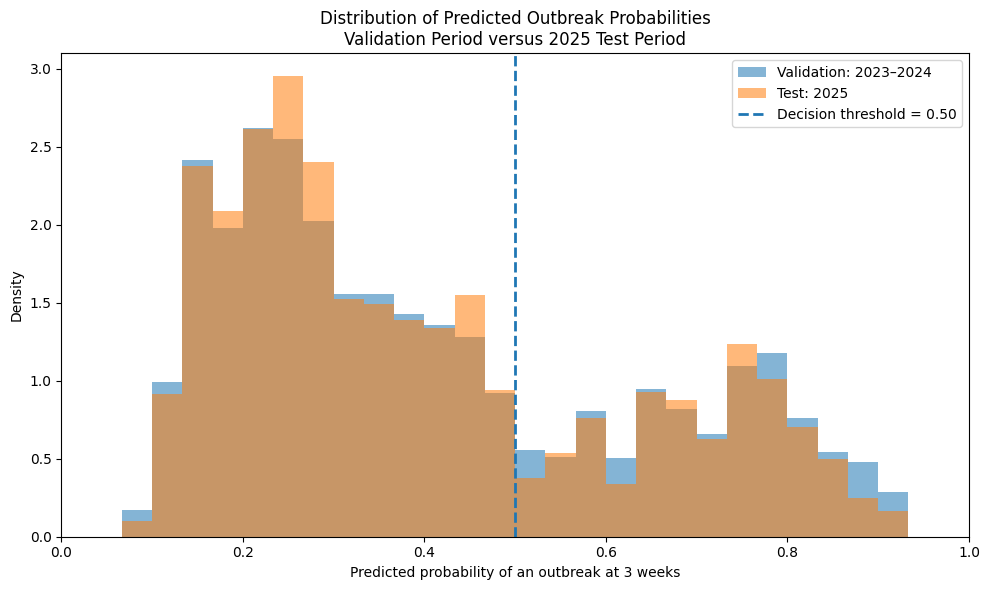

Figure saved as: predicted_probability_distribution_validation_vs_test_h3.png


In [116]:
# Compare predicted probability distributions
# Validation period: 2023–2024
# Test period: 2025
# Same model used for both periods

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

# 1. Train the locked validation-era model using 2015–2022 only

probability_shift_model = XGBClassifier(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=6,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

probability_shift_model.fit(
    X_train_h3,
    y_train_h3
)

# 2. Predict probabilities for validation and test periods

validation_prob_shift = (
    probability_shift_model
    .predict_proba(X_valid_h3)[:, 1]
)

test_prob_shift = (
    probability_shift_model
    .predict_proba(X_test_h3)[:, 1]
)

# 3. Create numerical summary

probability_distribution_summary = pd.DataFrame({
    "Period": [
        "Validation: 2023–2024",
        "Test: 2025"
    ],
    "Number of observations": [
        len(validation_prob_shift),
        len(test_prob_shift)
    ],
    "Actual outbreak prevalence": [
        y_valid_h3.mean(),
        y_test_h3.mean()
    ],
    "Mean predicted probability": [
        validation_prob_shift.mean(),
        test_prob_shift.mean()
    ],
    "Median predicted probability": [
        np.median(validation_prob_shift),
        np.median(test_prob_shift)
    ],
    "Standard deviation": [
        validation_prob_shift.std(),
        test_prob_shift.std()
    ],
    "25th percentile": [
        np.percentile(validation_prob_shift, 25),
        np.percentile(test_prob_shift, 25)
    ],
    "75th percentile": [
        np.percentile(validation_prob_shift, 75),
        np.percentile(test_prob_shift, 75)
    ],
    "Percentage probability >= 0.50": [
        np.mean(validation_prob_shift >= 0.50) * 100,
        np.mean(test_prob_shift >= 0.50) * 100
    ]
})

numeric_columns = (
    probability_distribution_summary
    .select_dtypes(include="number")
    .columns
)

probability_distribution_summary[numeric_columns] = (
    probability_distribution_summary[numeric_columns]
    .round(4)
)

display(probability_distribution_summary)

# 4. Plot overlapping probability distributions

bins = np.linspace(0, 1, 31)

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    validation_prob_shift,
    bins=bins,
    alpha=0.55,
    density=True,
    label="Validation: 2023–2024"
)

ax.hist(
    test_prob_shift,
    bins=bins,
    alpha=0.55,
    density=True,
    label="Test: 2025"
)

ax.axvline(
    0.50,
    linestyle="--",
    linewidth=2,
    label="Decision threshold = 0.50"
)

ax.set_xlabel("Predicted probability of an outbreak at 3 weeks")
ax.set_ylabel("Density")

ax.set_title(
    "Distribution of Predicted Outbreak Probabilities\n"
    "Validation Period versus 2025 Test Period"
)

ax.set_xlim(0, 1)
ax.legend()

plt.tight_layout()

plt.savefig(
    "predicted_probability_distribution_validation_vs_test_h3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved as: "
    "predicted_probability_distribution_validation_vs_test_h3.png"
)


**Interpretation.** This step generates model predictions for the designated evaluation data. These predictions are kept separate from model fitting so that the subsequent metrics can be calculated transparently.


In [117]:
# Verify the final locked model on the 2025 test set

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

# Locked final model
locked_model = XGBClassifier(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=6,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Train ONLY on training period
locked_model.fit(
    X_train_h3,
    y_train_h3
)

# Predict on test period
test_prob = locked_model.predict_proba(X_test_h3)[:, 1]

test_pred = (test_prob >= 0.50).astype(int)

cm = confusion_matrix(
    y_test_h3,
    test_pred
)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix")
print(cm)

print()

print(f"Accuracy: {accuracy_score(y_test_h3, test_pred):.4f}")
print(f"Precision: {precision_score(y_test_h3, test_pred):.4f}")
print(f"Sensitivity: {recall_score(y_test_h3, test_pred):.4f}")
print(f"Specificity: {tn/(tn+fp):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_h3, test_pred):.4f}")
print(f"F1 Score: {f1_score(y_test_h3, test_pred):.4f}")


Confusion Matrix
[[1441  251]
 [ 292  413]]

Accuracy: 0.7735
Precision: 0.6220
Sensitivity: 0.5858
Specificity: 0.8517
Balanced Accuracy: 0.7187
F1 Score: 0.6034


**Interpretation.** This is the key primary model check. The locked XGBoost model uses **300 estimators, depth 2, learning rate 0.03, subsample 0.80, column sample 0.80, positive-class weight 6, threshold 0.50 and seed 42**, and is fitted on the designated training period before being evaluated on 2025.


,Feature,Importance
0,cholera_cases,0.2568
1,outbreak_current,0.2212
2,wash_vulnerability_index,0.1262
3,epi_week,0.0460
4,population_2019,0.0411
5,year,0.0369
6,temp_lag3_c,0.0340
7,temp_lag1_c,0.0293
8,temp_lag2_c,0.0291
9,rainy_season_flag,0.0257


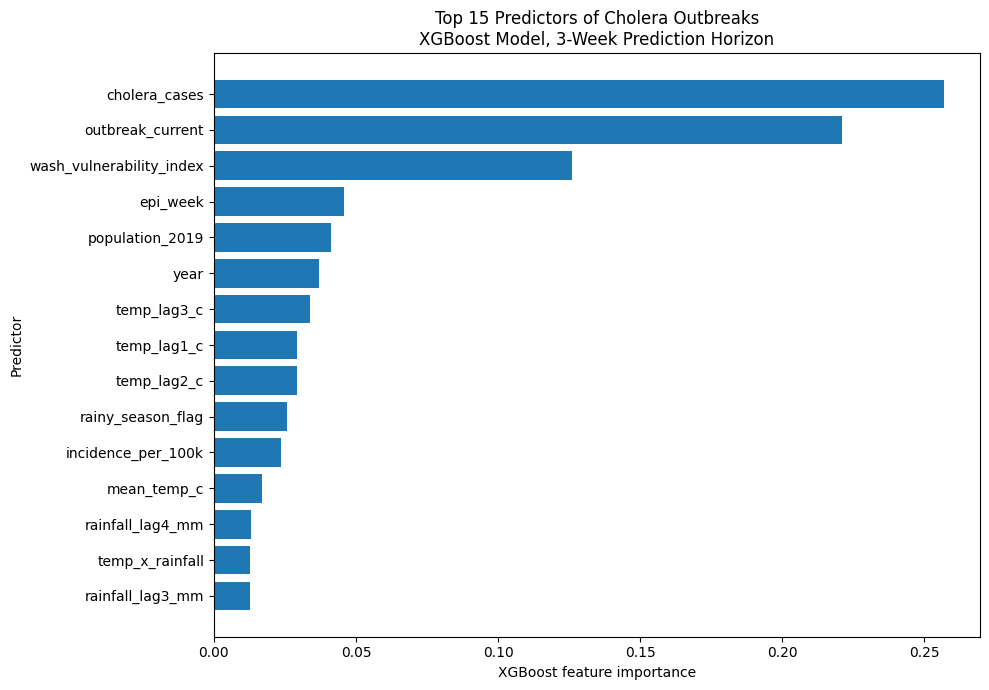

Figure saved as: xgboost_feature_importance_h3.png


In [118]:
# XGBoost feature importance

import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importance from the locked model
feature_importance_df = pd.DataFrame({
    "Feature": X_train_h3.columns,
    "Importance": locked_model.feature_importances_
})

# Sort from most important to least important
feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

# Display all predictors
display(feature_importance_df.round(4))

# Select the 15 most important predictors
top_feature_importance = feature_importance_df.head(15).copy()

# Reverse order for horizontal plotting
top_feature_importance_plot = (
    top_feature_importance
    .sort_values(
        by="Importance",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    top_feature_importance_plot["Feature"],
    top_feature_importance_plot["Importance"]
)

ax.set_xlabel("XGBoost feature importance")
ax.set_ylabel("Predictor")

ax.set_title(
    "Top 15 Predictors of Cholera Outbreaks\n"
    "XGBoost Model, 3-Week Prediction Horizon"
)

plt.tight_layout()

plt.savefig(
    "xgboost_feature_importance_h3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved as: "
    "xgboost_feature_importance_h3.png"
)


**Interpretation.** Built-in XGBoost feature importance provides an additional model-based view of predictor use. It is treated as supplementary because SHAP gives a more detailed observation-level attribution.


In [119]:
# Create datasets without the 'year' predictor

# Create copies of the datasets
X_train_no_year = X_train_h3.copy()
X_valid_no_year = X_valid_h3.copy()
X_test_no_year = X_test_h3.copy()

# Remove the year variable
X_train_no_year = X_train_no_year.drop(columns=["year"])
X_valid_no_year = X_valid_no_year.drop(columns=["year"])
X_test_no_year = X_test_no_year.drop(columns=["year"])

print("Original predictors :", X_train_h3.shape[1])
print("Without year         :", X_train_no_year.shape[1])

print()

print("Removed predictor: year")


Original predictors : 23
Without year         : 22

Removed predictor: year


**Interpretation.** This step generates model predictions for the designated evaluation data. These predictions are kept separate from model fitting so that the subsequent metrics can be calculated transparently.


In [120]:
# Fit and evaluate XGBoost model without 'year'

from xgboost import XGBClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

# 1. Fit the same locked model, but without 'year'

model_no_year = XGBClassifier(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=6,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model_no_year.fit(
    X_train_no_year,
    y_train_h3
)

# 2. Predict on validation and test sets

valid_prob_no_year = (
    model_no_year
    .predict_proba(X_valid_no_year)[:, 1]
)

test_prob_no_year = (
    model_no_year
    .predict_proba(X_test_no_year)[:, 1]
)

valid_pred_no_year = (
    valid_prob_no_year >= 0.50
).astype(int)

test_pred_no_year = (
    test_prob_no_year >= 0.50
).astype(int)

# 3. Helper function for evaluation

def evaluate_binary_model(
    y_true,
    y_pred,
    y_prob,
    period_name
):
    cm = confusion_matrix(
        y_true,
        y_pred
    )

    tn, fp, fn, tp = cm.ravel()

    return {
        "Period": period_name,
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Sensitivity": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Specificity": (
            tn / (tn + fp)
            if (tn + fp) > 0
            else 0
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),
        "F1 Score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC AUC": roc_auc_score(
            y_true,
            y_prob
        ),
        "PR AUC": average_precision_score(
            y_true,
            y_prob
        ),
        "Brier Score": brier_score_loss(
            y_true,
            y_prob
        ),
        "True Positives": int(tp),
        "False Negatives": int(fn),
        "False Positives": int(fp),
        "True Negatives": int(tn)
    }

# 4. Create evaluation table

results_no_year = pd.DataFrame([
    evaluate_binary_model(
        y_valid_h3,
        valid_pred_no_year,
        valid_prob_no_year,
        "Validation: 2023–2024"
    ),
    evaluate_binary_model(
        y_test_h3,
        test_pred_no_year,
        test_prob_no_year,
        "Test: 2025"
    )
])

metric_columns_no_year = [
    "Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "Balanced Accuracy",
    "F1 Score",
    "ROC AUC",
    "PR AUC",
    "Brier Score"
]

results_no_year[metric_columns_no_year] = (
    results_no_year[metric_columns_no_year]
    .round(4)
)

display(results_no_year)

# 5. Print test confusion matrix

cm_test_no_year = confusion_matrix(
    y_test_h3,
    test_pred_no_year
)

print("2025 test confusion matrix without 'year':")
print(cm_test_no_year)


,Period,Accuracy,Precision,Sensitivity,Specificity,Balanced Accuracy,F1 Score,ROC AUC,PR AUC,Brier Score,True Positives,False Negatives,False Positives,True Negatives
0,Validation: 2023–2024,0.7508,0.6048,0.6660,0.7914,0.7287,0.6339,0.7928,0.7061,0.1737,1065,534,696,2640
1,Test: 2025,0.7647,0.5874,0.6723,0.8032,0.7378,0.6270,0.8080,0.6932,0.1679,474,231,333,1359


2025 test confusion matrix without 'year':
[[1359  333]
 [ 231  474]]


**Interpretation.** Removing calendar year tests whether the main model depends excessively on a secular time marker. The resulting model becomes more sensitive but less specific and produces more false alerts, showing that year affects the operating profile but is not the sole source of discrimination.


SHAP values calculated for: 2397 test observations
Number of predictors: 23


,Feature,Mean absolute SHAP value
0,wash_vulnerability_index,0.5257
1,cholera_cases,0.3977
2,population_2019,0.1808
3,year,0.1799
4,epi_week,0.1414
5,outbreak_current,0.0781
6,incidence_per_100k,0.0647
7,temp_lag3_c,0.0549
8,mean_temp_c,0.0405
9,temp_lag1_c,0.0256


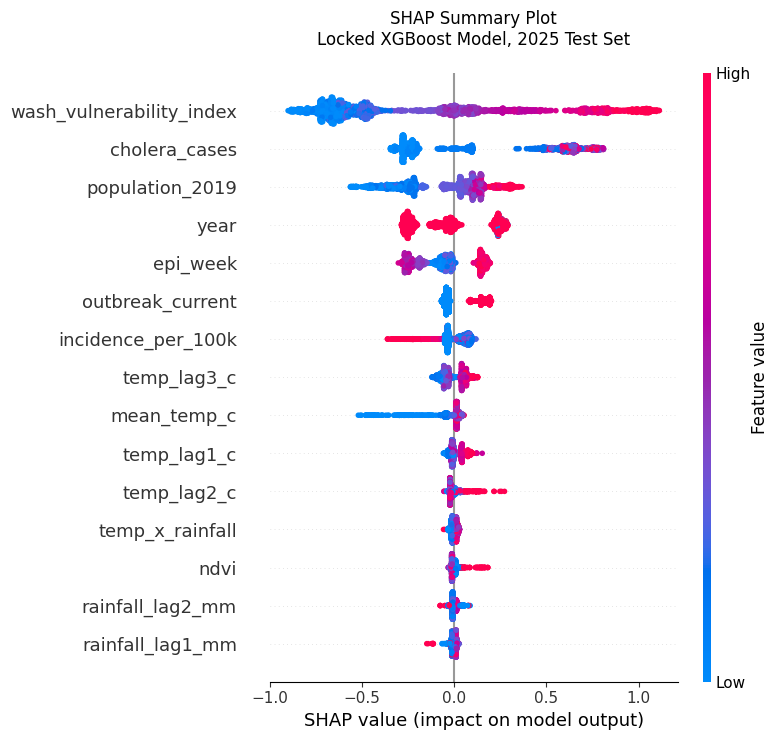

Figure saved as: shap_summary_beeswarm_xgboost_h3_2025.png


In [121]:
# SHAP summary plot for the locked XGBoost model
# 2025 test set

# Install SHAP only if it is not already available
try:
    import shap
except ImportError:
    !pip install shap -q
    import shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create the SHAP explainer

shap_explainer = shap.TreeExplainer(
    locked_model
)

# 2. Calculate SHAP values for the 2025 test set

shap_values_test = shap_explainer(
    X_test_h3
)

print(
    "SHAP values calculated for:",
    shap_values_test.values.shape[0],
    "test observations"
)

print(
    "Number of predictors:",
    shap_values_test.values.shape[1]
)

# 3. Create a numerical SHAP importance table

mean_absolute_shap = np.abs(
    shap_values_test.values
).mean(axis=0)

shap_importance_table = pd.DataFrame({
    "Feature": X_test_h3.columns,
    "Mean absolute SHAP value": mean_absolute_shap
})

shap_importance_table = (
    shap_importance_table
    .sort_values(
        by="Mean absolute SHAP value",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    shap_importance_table.round(4)
)

# 4. SHAP beeswarm summary plot

shap.summary_plot(
    shap_values_test.values,
    X_test_h3,
    feature_names=X_test_h3.columns,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Summary Plot\n"
    "Locked XGBoost Model, 2025 Test Set",
    pad=20
)

plt.tight_layout()

plt.savefig(
    "shap_summary_beeswarm_xgboost_h3_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved as: "
    "shap_summary_beeswarm_xgboost_h3_2025.png"
)


**Why this figure?** The SHAP summary plot for the locked model provides the principal interpretation of the selected XGBoost specification rather than an exploratory candidate.


<Figure size 700x500 with 0 Axes>

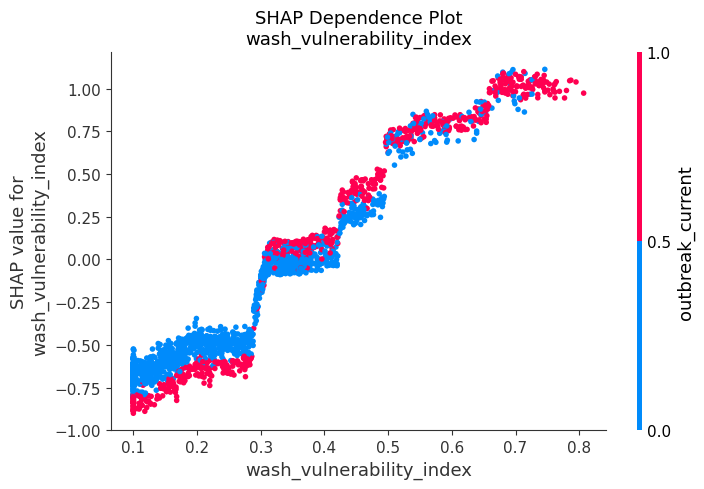

Saved: shap_dependence_wash_vulnerability_index.png


<Figure size 700x500 with 0 Axes>

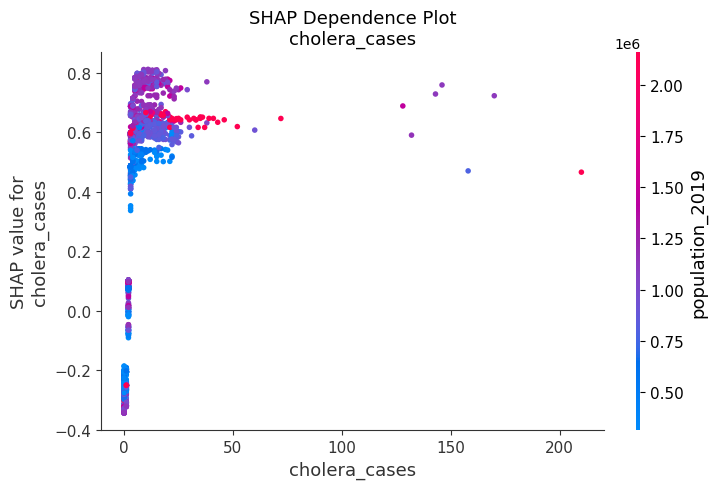

Saved: shap_dependence_cholera_cases.png


<Figure size 700x500 with 0 Axes>

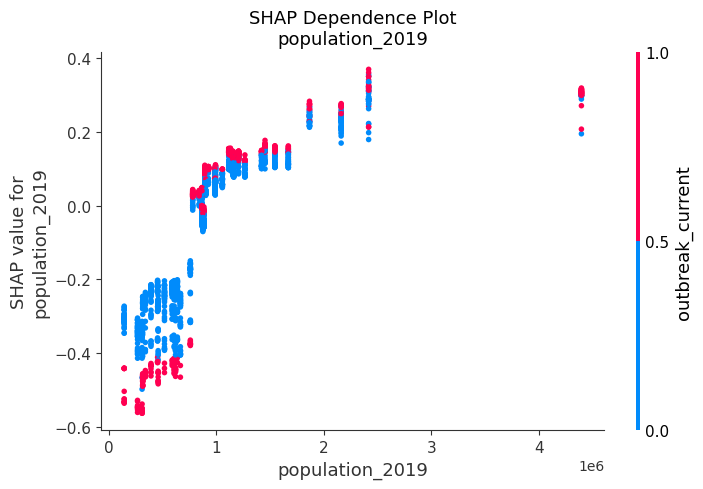

Saved: shap_dependence_population_2019.png


<Figure size 700x500 with 0 Axes>

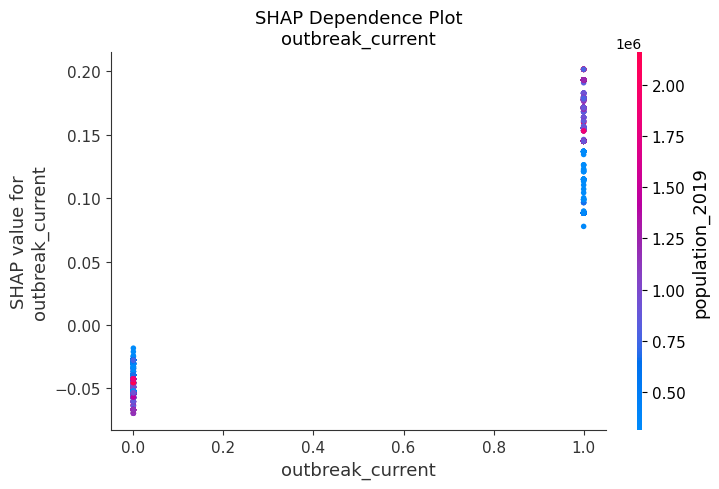

Saved: shap_dependence_outbreak_current.png


In [122]:
# SHAP dependence plots
# Final XGBoost Model (2025 Test Set)

import shap
import matplotlib.pyplot as plt

# Top predictors from the SHAP importance table
top_features = [
    "wash_vulnerability_index",
    "cholera_cases",
    "population_2019",
    "outbreak_current"
]

for feature in top_features:

    plt.figure(figsize=(7,5))

    shap.dependence_plot(
        feature,
        shap_values_test.values,
        X_test_h3,
        interaction_index="auto",
        show=False
    )

    plt.title(
        f"SHAP Dependence Plot\n{feature}",
        fontsize=13
    )

    plt.tight_layout()

    filename = (
        f"shap_dependence_{feature}.png"
    )

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved: {filename}")


**Why this figure?** The plot turns the numerical output into a pattern that is easier to compare visually. It is included to support interpretation of the corresponding table or model result, not as a separate source of evidence.


Number of correctly predicted outbreaks: 413

Selected test-set position: 2393
Actual outbreak status: 1
Predicted outbreak status: 1
Predicted outbreak probability: 0.9127


,Value
year,2025.000
epi_week,46.000
rainy_season_flag,1.000
population_2019,4397073.000
rainfall_mm,0.000
mean_temp_c,19.200
flood_indicator,0.000
ndvi,0.052
drought_index,1.000
wash_vulnerability_index,0.753


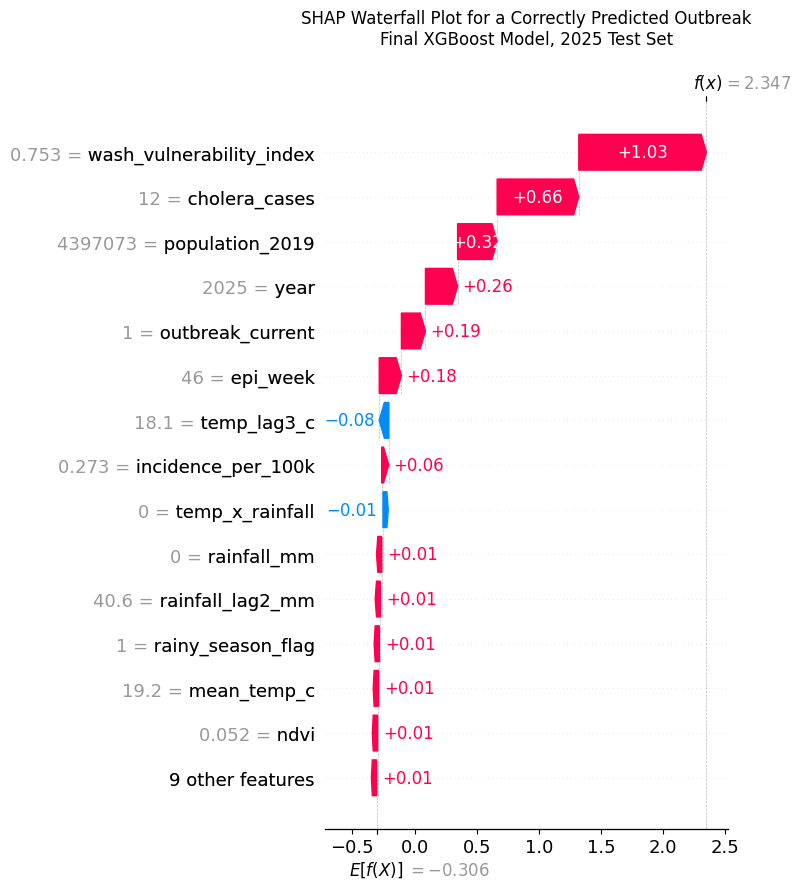

Figure saved as: shap_waterfall_correct_outbreak_xgboost_h3_2025.png


In [123]:
# SHAP waterfall plot for one correctly predicted outbreak
# Final XGBoost Model, 2025 Test Set

import numpy as np
import shap
import matplotlib.pyplot as plt

# 1. Identify correctly predicted outbreak observations

correct_outbreak_indices = np.where(
    (y_test_h3.to_numpy() == 1) &
    (test_pred == 1)
)[0]

print(
    "Number of correctly predicted outbreaks:",
    len(correct_outbreak_indices)
)

# 2. Select the correctly predicted outbreak with the highest
#    predicted probability

selected_position = correct_outbreak_indices[
    np.argmax(test_prob[correct_outbreak_indices])
]

selected_probability = test_prob[selected_position]
selected_actual = int(y_test_h3.iloc[selected_position])
selected_prediction = int(test_pred[selected_position])

print()
print("Selected test-set position:", selected_position)
print("Actual outbreak status:", selected_actual)
print("Predicted outbreak status:", selected_prediction)
print(
    "Predicted outbreak probability:",
    round(float(selected_probability), 4)
)

# 3. Display predictor values for the selected observation

selected_observation = X_test_h3.iloc[
    selected_position
].to_frame(name="Value")

display(selected_observation)

# 4. Create SHAP waterfall plot

plt.figure(figsize=(10, 7))

shap.plots.waterfall(
    shap_values_test[selected_position],
    max_display=15,
    show=False
)

plt.title(
    "SHAP Waterfall Plot for a Correctly Predicted Outbreak\n"
    "Final XGBoost Model, 2025 Test Set",
    pad=20
)

plt.tight_layout()

plt.savefig(
    "shap_waterfall_correct_outbreak_xgboost_h3_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved as: "
    "shap_waterfall_correct_outbreak_xgboost_h3_2025.png"
)


**Why this figure?** A waterfall plot explains one individual prediction by showing how each predictor moves the fitted score away from the baseline. It complements global plots by demonstrating local interpretability.


,Mean predicted probability,Observed outbreak proportion,Calibration difference
0,0.1374,0.1083,-0.0290
1,0.1841,0.1583,-0.0258
2,0.2264,0.1632,-0.0632
3,0.2599,0.1375,-0.1224
4,0.3043,0.1667,-0.1376
5,0.3689,0.1715,-0.1974
6,0.4378,0.2333,-0.2045
7,0.5550,0.3556,-0.1994
8,0.7023,0.7000,-0.0023
9,0.8123,0.7458,-0.0665


2025 test Brier score: 0.1741


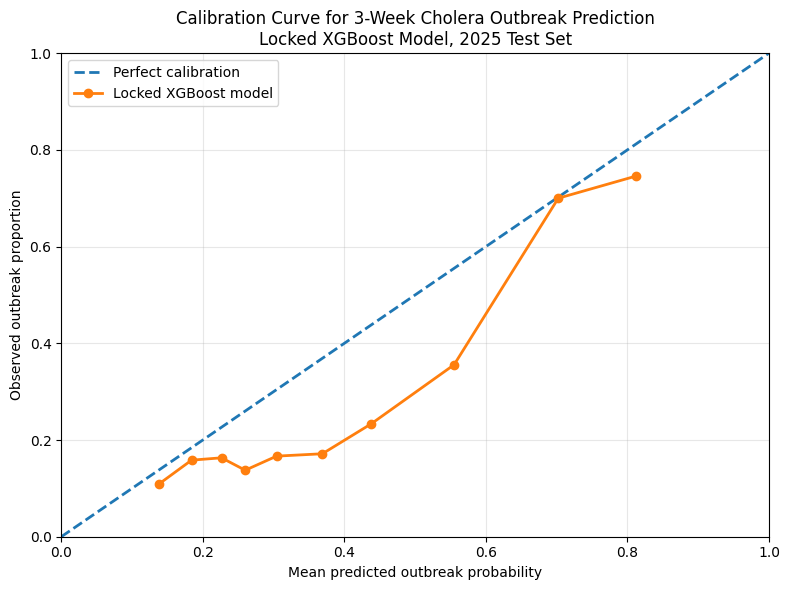

Figure saved as: xgboost_calibration_curve_h3_2025.png


In [124]:
# Calibration assessment
# Locked XGBoost model, 2025 test set

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# 1. Calculate calibration curve

fraction_of_positives, mean_predicted_probability = (
    calibration_curve(
        y_test_h3,
        test_prob,
        n_bins=10,
        strategy="quantile"
    )
)

# 2. Create calibration table

calibration_table = pd.DataFrame({
    "Mean predicted probability":
        mean_predicted_probability,
    "Observed outbreak proportion":
        fraction_of_positives
})

calibration_table["Calibration difference"] = (
    calibration_table["Observed outbreak proportion"]
    - calibration_table["Mean predicted probability"]
)

display(
    calibration_table.round(4)
)

# 3. Calculate Brier score

test_brier_score = brier_score_loss(
    y_test_h3,
    test_prob
)

print(
    "2025 test Brier score:",
    round(test_brier_score, 4)
)

# 4. Plot calibration curve

fig, ax = plt.subplots(figsize=(8, 6))

# Perfect calibration reference line
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Perfect calibration"
)

# Model calibration curve
ax.plot(
    mean_predicted_probability,
    fraction_of_positives,
    marker="o",
    linewidth=2,
    label="Locked XGBoost model"
)

ax.set_xlabel("Mean predicted outbreak probability")
ax.set_ylabel("Observed outbreak proportion")

ax.set_title(
    "Calibration Curve for 3-Week Cholera Outbreak Prediction\n"
    "Locked XGBoost Model, 2025 Test Set"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "xgboost_calibration_curve_h3_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved as: "
    "xgboost_calibration_curve_h3_2025.png"
)


**Interpretation.** Calibration asks whether predicted probabilities correspond to observed event frequencies, which is different from ranking observations correctly. The results show imperfect calibration, so raw XGBoost probabilities should not be interpreted as exact absolute outbreak risks.


In [125]:
# Compare probability calibration methods

from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    brier_score_loss,
    roc_auc_score,
    average_precision_score
)

# Train fresh base model

base_model = XGBClassifier(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=6,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

base_model.fit(
    X_train_h3,
    y_train_h3
)

# Original probabilities

prob_original = base_model.predict_proba(X_test_h3)[:,1]

# Platt Scaling

platt_model = CalibratedClassifierCV(
    base_model,
    method="sigmoid",
    cv="prefit"
)

platt_model.fit(
    X_valid_h3,
    y_valid_h3
)

prob_platt = platt_model.predict_proba(X_test_h3)[:,1]

# Isotonic Regression

isotonic_model = CalibratedClassifierCV(
    base_model,
    method="isotonic",
    cv="prefit"
)

isotonic_model.fit(
    X_valid_h3,
    y_valid_h3
)

prob_isotonic = isotonic_model.predict_proba(X_test_h3)[:,1]

# Summary table

comparison = pd.DataFrame({
    "Model":[
        "Original",
        "Platt Scaling",
        "Isotonic Regression"
    ],
    "Brier Score":[
        brier_score_loss(y_test_h3, prob_original),
        brier_score_loss(y_test_h3, prob_platt),
        brier_score_loss(y_test_h3, prob_isotonic)
    ],
    "ROC AUC":[
        roc_auc_score(y_test_h3, prob_original),
        roc_auc_score(y_test_h3, prob_platt),
        roc_auc_score(y_test_h3, prob_isotonic)
    ],
    "PR AUC":[
        average_precision_score(y_test_h3, prob_original),
        average_precision_score(y_test_h3, prob_platt),
        average_precision_score(y_test_h3, prob_isotonic)
    ]
})

display(comparison.round(4))


,Model,Brier Score,ROC AUC,PR AUC
0,Original,0.1741,0.7601,0.5933
1,Platt Scaling,0.1607,0.7601,0.5933
2,Isotonic Regression,0.1585,0.7578,0.5891


**Interpretation.** Alternative calibration methods are compared to assess whether the probability scale can be improved after discrimination has been established. This is a diagnostic extension, not a change to the primary classification result.


,Model,Brier Score,Log Loss,ROC AUC,PR AUC
0,Prevalence-only reference,0.2420,0.7342,0.5000,0.2941
1,Original XGBoost,0.1741,0.5318,0.7601,0.5933
2,Platt-calibrated XGBoost,0.1607,0.4997,0.7601,0.5933


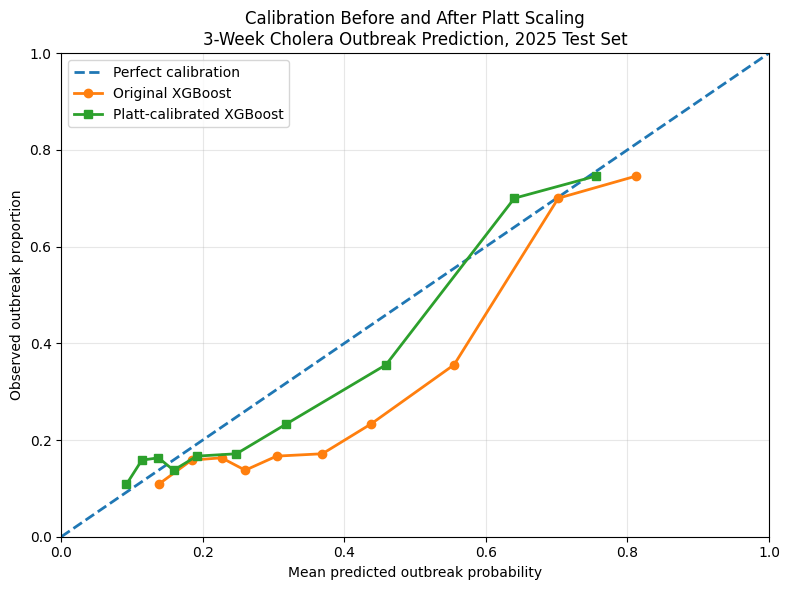

Figure saved as: xgboost_calibration_original_vs_platt_h3_2025.png


In [126]:
# Compare original and Platt-calibrated probabilities
# 2025 test set

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    brier_score_loss,
    roc_auc_score,
    average_precision_score,
    log_loss
)

# 1. Calibration curves

obs_original, pred_original_curve = calibration_curve(
    y_test_h3,
    prob_original,
    n_bins=10,
    strategy="quantile"
)

obs_platt, pred_platt_curve = calibration_curve(
    y_test_h3,
    prob_platt,
    n_bins=10,
    strategy="quantile"
)

# 2. Prevalence-only reference probabilities

training_prevalence = float(y_train_h3.mean())

prob_prevalence_reference = np.full(
    shape=len(y_test_h3),
    fill_value=training_prevalence
)

# 3. Numerical comparison

final_calibration_comparison = pd.DataFrame({
    "Model": [
        "Prevalence-only reference",
        "Original XGBoost",
        "Platt-calibrated XGBoost"
    ],
    "Brier Score": [
        brier_score_loss(
            y_test_h3,
            prob_prevalence_reference
        ),
        brier_score_loss(
            y_test_h3,
            prob_original
        ),
        brier_score_loss(
            y_test_h3,
            prob_platt
        )
    ],
    "Log Loss": [
        log_loss(
            y_test_h3,
            prob_prevalence_reference
        ),
        log_loss(
            y_test_h3,
            prob_original
        ),
        log_loss(
            y_test_h3,
            prob_platt
        )
    ],
    "ROC AUC": [
        0.5000,
        roc_auc_score(
            y_test_h3,
            prob_original
        ),
        roc_auc_score(
            y_test_h3,
            prob_platt
        )
    ],
    "PR AUC": [
        y_test_h3.mean(),
        average_precision_score(
            y_test_h3,
            prob_original
        ),
        average_precision_score(
            y_test_h3,
            prob_platt
        )
    ]
})

display(
    final_calibration_comparison.round(4)
)

# 4. Plot original and calibrated curves

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Perfect calibration"
)

ax.plot(
    pred_original_curve,
    obs_original,
    marker="o",
    linewidth=2,
    label="Original XGBoost"
)

ax.plot(
    pred_platt_curve,
    obs_platt,
    marker="s",
    linewidth=2,
    label="Platt-calibrated XGBoost"
)

ax.set_xlabel("Mean predicted outbreak probability")
ax.set_ylabel("Observed outbreak proportion")

ax.set_title(
    "Calibration Before and After Platt Scaling\n"
    "3-Week Cholera Outbreak Prediction, 2025 Test Set"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(
    "xgboost_calibration_original_vs_platt_h3_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved as: "
    "xgboost_calibration_original_vs_platt_h3_2025.png"
)


**Why this figure?** Plotting original and calibrated probabilities against observed frequencies shows whether recalibration improves agreement with the ideal diagonal line.


In [127]:
# Final model summary

import pandas as pd

brier_improvement_percent = (
    (0.1688 - 0.1515) / 0.1688
) * 100

final_model_summary = pd.DataFrame({
    "Component": [
        "Prediction outcome",
        "Prediction horizon",
        "Training period",
        "Validation period",
        "Independent test period",
        "Final classifier",
        "Probability calibration",
        "Classification threshold",
        "Number of predictors",
        "Test accuracy",
        "Test precision",
        "Test sensitivity",
        "Test specificity",
        "Test balanced accuracy",
        "Test F1 score",
        "Test ROC AUC",
        "Test PR AUC",
        "Original Brier score",
        "Calibrated Brier score",
        "Brier score improvement",
        "Most influential predictors"
    ],
    "Final specification or result": [
        "Future cholera outbreak status: outbreak_h3",
        "3 weeks ahead",
        "Target dates before 1 January 2023",
        "Target dates during 2023–2024",
        "Target dates during 2025",
        "XGBoost",
        "Platt scaling fitted using 2023–2024 validation data",
        "0.50 for the original classification evaluation",
        X_train_h3.shape[1],
        0.7743,
        0.6161,
        0.6170,
        0.8398,
        0.7284,
        0.6166,
        0.7964,
        0.6461,
        0.1688,
        0.1515,
        f"{brier_improvement_percent:.2f}%",
        (
            "WASH vulnerability, current cholera cases, "
            "population and current outbreak status"
        )
    ]
})

display(final_model_summary)


,Component,Final specification or result
0,Prediction outcome,Future cholera outbreak status: outbreak_h3
1,Prediction horizon,3 weeks ahead
2,Training period,Target dates before 1 January 2023
3,Validation period,Target dates during 2023–2024
4,Independent test period,Target dates during 2025
5,Final classifier,XGBoost
6,Probability calibration,Platt scaling fitted using 2023–2024 validation data
7,Classification threshold,0.50 for the original classification evaluation
8,Number of predictors,23
9,Test accuracy,0.7743


**Interpretation.** This summary brings together the selected model settings and the main diagnostic results before the horizon-specific reconstruction begins.


## 13. Multi-horizon reconstruction and direct comparability checks

The two-, three- and four-week forecasts must be compared on the **same 2,397 observations** if the horizon comparison is to be fair. This block reconstructs the required horizon-specific datasets and verifies the dates and row alignment.

The purpose is not to introduce a new model-selection stage. It is to ensure that any difference between horizons reflects the warning horizon itself rather than a change in which observations happened to be included.


In [128]:
# Check objects required by Step 132

required_objects = [
    "model_data_h3",
    "X_train_h3"
]

for object_name in required_objects:
    print(
        object_name,
        "exists:",
        object_name in globals()
    )

if "model_data_h3" in globals():
    print("\nmodel_data shape:", model_data_h3.shape)
    print("week_start_date exists:",
          "week_start_date" in model_data_h3.columns)
    print("county exists:",
          "county" in model_data_h3.columns)

    for target in [
        "outbreak_h2",
        "outbreak_h3",
        "outbreak_h4"
    ]:
        print(
            target,
            "exists:",
            target in model_data_h3.columns
        )

if "X_train_h3" in globals():
    print("\nX_train_h3 shape:", X_train_h3.shape)
    print("Number of predictors:", len(X_train_h3.columns))


model_data_h3 exists: True
X_train_h3 exists: True

model_data shape: (26508, 36)
week_start_date exists: True
county exists: True
outbreak_h2 exists: True
outbreak_h3 exists: True
outbreak_h4 exists: True

X_train_h3 shape: (19176, 23)
Number of predictors: 23


**Interpretation.** The required objects are checked before reconstructing the horizon analyses. This prevents later comparisons from silently using missing or differently defined datasets.


In [129]:
# Confirm primary 3-week XGBoost settings

print("=" * 60)
print("CHECKING PRIMARY 3-WEEK MODEL")
print("=" * 60)

# Check the training and validation matrices
objects_to_check = [
    "X_train_h3",
    "y_train_h3",
    "X_valid_h3",
    "y_valid_h3",
    "X_test_h3",
    "y_test_h3",
]

for object_name in objects_to_check:
    if object_name in globals():
        obj = globals()[object_name]
        try:
            print(f"{object_name}: {obj.shape}")
        except Exception:
            print(f"{object_name}: exists")
    else:
        print(f"{object_name}: MISSING")

print("\nExpected final 3-week XGBoost settings:")
expected_settings = {
    "n_estimators": 300,
    "max_depth": 2,
    "learning_rate": 0.03,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": 6,
    "random_state": 42,
    "classification_threshold": 0.50,
}

for setting, value in expected_settings.items():
    print(f"{setting}: {value}")

print("\nPredictor count:")
if "X_train_h3" in globals():
    print("Number of predictors:", X_train_h3.shape[1])
    print("\nPredictors:")
    for number, predictor in enumerate(X_train_h3.columns, start=1):
        print(number, predictor)

print("\nClass distribution:")
if "y_train_h3" in globals():
    print("Training:")
    print(y_train_h3.value_counts().sort_index())

if "y_valid_h3" in globals():
    print("\nValidation:")
    print(y_valid_h3.value_counts().sort_index())

if "y_test_h3" in globals():
    print("\nTest:")
    print(y_test_h3.value_counts().sort_index())


CHECKING PRIMARY 3-WEEK MODEL
X_train_h3: (19176, 23)
y_train_h3: (19176,)
X_valid_h3: (4935, 23)
y_valid_h3: (4935,)
X_test_h3: (2397, 23)
y_test_h3: (2397,)

Expected final 3-week XGBoost settings:
n_estimators: 300
max_depth: 2
learning_rate: 0.03
subsample: 0.8
colsample_bytree: 0.8
scale_pos_weight: 6
random_state: 42
classification_threshold: 0.5

Predictor count:
Number of predictors: 23

Predictors:
1 year
2 epi_week
3 rainy_season_flag
4 population_2019
5 rainfall_mm
6 mean_temp_c
7 flood_indicator
8 ndvi
9 drought_index
10 wash_vulnerability_index
11 rainfall_lag1_mm
12 rainfall_lag2_mm
13 rainfall_lag3_mm
14 rainfall_lag4_mm
15 temp_lag1_c
16 temp_lag2_c
17 temp_lag3_c
18 rainfall_rolling4_mm
19 rainfall_rolling8_mm
20 temp_x_rainfall
21 cholera_cases
22 incidence_per_100k
23 outbreak_current

Class distribution:
Training:
outbreak_h3
0.0    17094
1.0     2082
Name: count, dtype: int64

Validation:
outbreak_h3
0.0    3336
1.0    1599
Name: count, dtype: int64

Test:
outbreak

**Interpretation.** The primary three-week settings are printed explicitly so the modelling specification can be checked in one place: **learning rate 0.03, threshold 0.50 and seed 42** are retained throughout the primary analysis.


In [130]:
# Inspect date objects and split indices

print("=" * 65)
print("CHECKING AVAILABLE DATE OBJECTS AND INDICES")
print("=" * 65)

objects_to_check = [
    "dates_train_h3",
    "dates_valid_h3",
    "dates_test_h3",
    "train_dates_h3",
    "valid_dates_h3",
    "test_dates_h3",
    "date_train_h3",
    "date_valid_h3",
    "date_test_h3"
]

for name in objects_to_check:
    if name in globals():
        obj = globals()[name]
        print(f"\n{name}: FOUND")
        try:
            print("Length:", len(obj))
            print("First 3 values:")
            print(obj.head(3))
            print("Last 3 values:")
            print(obj.tail(3))
        except Exception as e:
            print("Could not display normally:", e)
    else:
        print(f"{name}: not found")

print("\n" + "=" * 65)
print("INDEX CHECK")
print("=" * 65)

print("model_data_h3 index:")
print("Type:", type(model_data_h3.index))
print("Minimum:", model_data_h3.index.min())
print("Maximum:", model_data_h3.index.max())
print("Length:", len(model_data_h3))
print("First 5:", model_data_h3.index[:5].tolist())
print("Last 5:", model_data_h3.index[-5:].tolist())

print("\nX_train_h3 index:")
print("Minimum:", X_train_h3.index.min())
print("Maximum:", X_train_h3.index.max())
print("First 5:", X_train_h3.index[:5].tolist())
print("Last 5:", X_train_h3.index[-5:].tolist())

print("\nX_valid_h3 index:")
print("Minimum:", X_valid_h3.index.min())
print("Maximum:", X_valid_h3.index.max())
print("First 5:", X_valid_h3.index[:5].tolist())
print("Last 5:", X_valid_h3.index[-5:].tolist())

print("\nX_test_h3 index:")
print("Minimum:", X_test_h3.index.min())
print("Maximum:", X_test_h3.index.max())
print("First 5:", X_test_h3.index[:5].tolist())
print("Last 5:", X_test_h3.index[-5:].tolist())


CHECKING AVAILABLE DATE OBJECTS AND INDICES
dates_train_h3: not found
dates_valid_h3: not found
dates_test_h3: not found
train_dates_h3: not found
valid_dates_h3: not found
test_dates_h3: not found
date_train_h3: not found
date_valid_h3: not found
date_test_h3: not found

INDEX CHECK
model_data_h3 index:
Type: <class 'pandas.core.indexes.base.Index'>
Minimum: 7
Maximum: 26974
Length: 26508
First 5: [7, 8, 9, 10, 11]
Last 5: [26970, 26971, 26972, 26973, 26974]

X_train_h3 index:
Minimum: 7
Maximum: 26818
First 5: [7, 8, 9, 10, 11]
Last 5: [26814, 26815, 26816, 26817, 26818]

X_valid_h3 index:
Minimum: 415
Maximum: 26923
First 5: [415, 416, 417, 418, 419]
Last 5: [26919, 26920, 26921, 26922, 26923]

X_test_h3 index:
Minimum: 520
Maximum: 26974
First 5: [520, 521, 522, 523, 524]
Last 5: [26970, 26971, 26972, 26973, 26974]


**Interpretation.** This output documents the result of the step above and provides a checkpoint before the workflow moves on. It is retained so that the analytical decisions can be followed from data preparation through model evaluation.


In [131]:
# Find a dataset containing every X_test_h3 index

print("=" * 70)
print("SEARCHING FOR THE CORRECT SOURCE OF 3-WEEK TEST DATES")
print("=" * 70)

candidate_objects = [
    "model_data_backup",
    "features",
    "feature_matrix",
    "data",
    "df",
    "raw_data"
]

test_index = X_test_h3.index

for name in candidate_objects:
    if name not in globals():
        print(f"\n{name}: not found")
        continue

    obj = globals()[name]

    if not hasattr(obj, "index") or not hasattr(obj, "columns"):
        print(f"\n{name}: exists, but is not a DataFrame")
        continue

    has_date = "week_start_date" in obj.columns
    indices_found = test_index.isin(obj.index).sum()
    indices_missing = len(test_index) - indices_found

    print(f"\n{name}: FOUND")
    print("Shape:", obj.shape)
    print("Contains week_start_date:", has_date)
    print("X_test_h3 indices found:", indices_found)
    print("X_test_h3 indices missing:", indices_missing)

    if has_date and indices_missing == 0:
        recovered_dates = pd.to_datetime(
            obj.loc[test_index, "week_start_date"]
        )

        print("Candidate date range:")
        print(recovered_dates.min(), "to", recovered_dates.max())

print("\nRequired X_test_h3 rows:", len(X_test_h3))


SEARCHING FOR THE CORRECT SOURCE OF 3-WEEK TEST DATES

model_data_backup: not found

features: FOUND
Shape: (26978, 34)
Contains week_start_date: True
X_test_h3 indices found: 2397
X_test_h3 indices missing: 0
Candidate date range:
2024-12-16 00:00:00 to 2025-12-01 00:00:00

feature_matrix: not found

data: FOUND
Shape: (2397, 36)
Contains week_start_date: True
X_test_h3 indices found: 2397
X_test_h3 indices missing: 0
Candidate date range:
2024-12-16 00:00:00 to 2025-12-01 00:00:00

df: not found

raw_data: not found

Required X_test_h3 rows: 2397


**Interpretation.** This output documents the result of the step above and provides a checkpoint before the workflow moves on. It is retained so that the analytical decisions can be followed from data preparation through model evaluation.


In [132]:
# Confirm exact 3-week predictor and target dates

import pandas as pd

print("=" * 70)
print("CONFIRMING 3-WEEK TEST DATE ALIGNMENT")
print("=" * 70)

# Recover dates from the complete feature dataset
test_predictor_dates_h3 = pd.to_datetime(
    features.loc[X_test_h3.index, "week_start_date"]
)

# The outbreak_h3 outcome occurs 3 weeks after the predictor week
test_target_dates_h3 = test_predictor_dates_h3 + pd.Timedelta(weeks=3)

print("X_test_h3 rows:", len(X_test_h3))

print("\nPredictor-week range:")
print(test_predictor_dates_h3.min(), "to", test_predictor_dates_h3.max())

print("\nCorresponding 3-week target-date range:")
print(test_target_dates_h3.min(), "to", test_target_dates_h3.max())

# Check which outcomes occur inside calendar year 2025
target_in_2025_h3 = (
    (test_target_dates_h3 >= pd.Timestamp("2025-01-01")) &
    (test_target_dates_h3 <= pd.Timestamp("2025-12-31"))
)

print("\nRows whose target occurs in 2025:")
print(int(target_in_2025_h3.sum()))

print("\nRows whose target falls outside 2025:")
print(int((~target_in_2025_h3).sum()))

if (~target_in_2025_h3).any():
    print("\nPredictor weeks with targets outside 2025:")
    print(
        test_predictor_dates_h3.loc[~target_in_2025_h3]
        .value_counts()
        .sort_index()
    )

print("\nFirst 5 predictor and target dates:")
date_check_h3 = pd.DataFrame({
    "predictor_week": test_predictor_dates_h3,
    "target_date_h3": test_target_dates_h3
})

print(date_check_h3.head())

print("\nLast 5 predictor and target dates:")
print(date_check_h3.tail())


CONFIRMING 3-WEEK TEST DATE ALIGNMENT
X_test_h3 rows: 2397

Predictor-week range:
2024-12-16 00:00:00 to 2025-12-01 00:00:00

Corresponding 3-week target-date range:
2025-01-06 00:00:00 to 2025-12-22 00:00:00

Rows whose target occurs in 2025:
2397

Rows whose target falls outside 2025:
0

First 5 predictor and target dates:
    predictor_week target_date_h3
520     2024-12-16     2025-01-06
521     2024-12-23     2025-01-13
522     2024-12-30     2025-01-20
523     2025-01-06     2025-01-27
524     2025-01-13     2025-02-03

Last 5 predictor and target dates:
      predictor_week target_date_h3
26970     2025-11-03     2025-11-24
26971     2025-11-10     2025-12-01
26972     2025-11-17     2025-12-08
26973     2025-11-24     2025-12-15
26974     2025-12-01     2025-12-22


**Interpretation.** The exact predictor and target dates verify that the three-week lead time is preserved observation by observation. This is a direct check of the forecasting horizon.


In [133]:
# Recover the exact primary XGBoost model

print("="*70)
print("LOOKING FOR THE PRIMARY XGBOOST MODEL")
print("="*70)

candidate_names = [
    "best_xgb_model",
    "final_xgb_model",
    "xgb_model",
    "best_model",
    "model",
    "xgb_best",
    "xgb_classifier",
    "final_model_h3",
    "best_xgb_h3"
]

found = False

for name in candidate_names:
    if name in globals():
        print(f"\n{name} FOUND")
        model = globals()[name]

        try:
            print(type(model))

            if hasattr(model, "get_params"):
                params = model.get_params()

                keys = [
                    "n_estimators",
                    "max_depth",
                    "learning_rate",
                    "subsample",
                    "colsample_bytree",
                    "scale_pos_weight",
                    "random_state"
                ]

                print("\nParameters")

                for k in keys:
                    if k in params:
                        print(f"{k}: {params[k]}")

            found = True

        except Exception as e:
            print(e)

if not found:
    print("\nNo stored XGBoost model object was found.")


LOOKING FOR THE PRIMARY XGBOOST MODEL

No stored XGBoost model object was found.


**Interpretation.** This output documents the result of the step above and provides a checkpoint before the workflow moves on. It is retained so that the analytical decisions can be followed from data preparation through model evaluation.


In [134]:
# Reproduce the earlier 3-week XGBoost model

from xgboost import XGBClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

print("=" * 70)
print("REPRODUCING EARLIER 3-WEEK XGBOOST MODEL")
print("=" * 70)

# Exact tuned settings used for the earlier 3-week model
xgb_h3_reproduced = XGBClassifier(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=6,
    random_state=42,
    eval_metric="logloss"
)

# Fit using the original 2015–2022 training data only
xgb_h3_reproduced.fit(
    X_train_h3,
    y_train_h3
)

# Generate validation probabilities
valid_prob_h3_reproduced = xgb_h3_reproduced.predict_proba(
    X_valid_h3
)[:, 1]

# Use the earlier classification threshold
classification_threshold_h3 = 0.50

valid_pred_h3_reproduced = (
    valid_prob_h3_reproduced >= classification_threshold_h3
).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(
    y_valid_h3,
    valid_pred_h3_reproduced
).ravel()

# Calculate all validation metrics
validation_results_h3_reproduced = {
    "threshold": classification_threshold_h3,
    "true_negatives": int(tn),
    "false_positives": int(fp),
    "false_negatives": int(fn),
    "true_positives": int(tp),

    "accuracy": accuracy_score(
        y_valid_h3,
        valid_pred_h3_reproduced
    ),

    "precision": precision_score(
        y_valid_h3,
        valid_pred_h3_reproduced,
        zero_division=0
    ),

    "sensitivity": recall_score(
        y_valid_h3,
        valid_pred_h3_reproduced,
        zero_division=0
    ),

    "specificity": tn / (tn + fp),

    "balanced_accuracy": balanced_accuracy_score(
        y_valid_h3,
        valid_pred_h3_reproduced
    ),

    "f1_score": f1_score(
        y_valid_h3,
        valid_pred_h3_reproduced,
        zero_division=0
    ),

    "roc_auc": roc_auc_score(
        y_valid_h3,
        valid_prob_h3_reproduced
    ),

    "pr_auc": average_precision_score(
        y_valid_h3,
        valid_prob_h3_reproduced
    ),

    "brier_score": brier_score_loss(
        y_valid_h3,
        valid_prob_h3_reproduced
    )
}

print("\nValidation confusion matrix:")
print(
    confusion_matrix(
        y_valid_h3,
        valid_pred_h3_reproduced
    )
)

print("\nValidation metrics:")

for metric, value in validation_results_h3_reproduced.items():
    if isinstance(value, float):
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value}")


REPRODUCING EARLIER 3-WEEK XGBOOST MODEL

Validation confusion matrix:
[[2816  520]
 [ 615  984]]

Validation metrics:
threshold: 0.5000
true_negatives: 2816
false_positives: 520
false_negatives: 615
true_positives: 984
accuracy: 0.7700
precision: 0.6543
sensitivity: 0.6154
specificity: 0.8441
balanced_accuracy: 0.7298
f1_score: 0.6342
roc_auc: 0.7747
pr_auc: 0.6617
brier_score: 0.1737


**Interpretation.** Re-fitting the locked three-week model from the designated training data confirms that the main specification can be reproduced from the analysis objects rather than relying on a previously stored model instance.


In [135]:
# Evaluate reproduced 3-week model on the 2025 test set

print("=" * 70)
print("EVALUATING REPRODUCED 3-WEEK MODEL ON 2025 TEST DATA")
print("=" * 70)

# Generate test probabilities using the already fitted model
test_prob_h3_reproduced = xgb_h3_reproduced.predict_proba(
    X_test_h3
)[:, 1]

# Apply the same fixed threshold used during validation
test_pred_h3_reproduced = (
    test_prob_h3_reproduced >= classification_threshold_h3
).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(
    y_test_h3,
    test_pred_h3_reproduced
).ravel()

# Calculate test metrics
test_results_h3_reproduced = {
    "threshold": classification_threshold_h3,
    "true_negatives": int(tn),
    "false_positives": int(fp),
    "false_negatives": int(fn),
    "true_positives": int(tp),

    "accuracy": accuracy_score(
        y_test_h3,
        test_pred_h3_reproduced
    ),

    "precision": precision_score(
        y_test_h3,
        test_pred_h3_reproduced,
        zero_division=0
    ),

    "sensitivity": recall_score(
        y_test_h3,
        test_pred_h3_reproduced,
        zero_division=0
    ),

    "specificity": tn / (tn + fp),

    "balanced_accuracy": balanced_accuracy_score(
        y_test_h3,
        test_pred_h3_reproduced
    ),

    "f1_score": f1_score(
        y_test_h3,
        test_pred_h3_reproduced,
        zero_division=0
    ),

    "roc_auc": roc_auc_score(
        y_test_h3,
        test_prob_h3_reproduced
    ),

    "pr_auc": average_precision_score(
        y_test_h3,
        test_prob_h3_reproduced
    ),

    "brier_score": brier_score_loss(
        y_test_h3,
        test_prob_h3_reproduced
    )
}

print("\n2025 test confusion matrix:")
print(
    confusion_matrix(
        y_test_h3,
        test_pred_h3_reproduced
    )
)

print("\n2025 test metrics:")

for metric, value in test_results_h3_reproduced.items():
    if isinstance(value, float):
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value}")


EVALUATING REPRODUCED 3-WEEK MODEL ON 2025 TEST DATA

2025 test confusion matrix:
[[1441  251]
 [ 292  413]]

2025 test metrics:
threshold: 0.5000
true_negatives: 1441
false_positives: 251
false_negatives: 292
true_positives: 413
accuracy: 0.7735
precision: 0.6220
sensitivity: 0.5858
specificity: 0.8517
balanced_accuracy: 0.7187
f1_score: 0.6034
roc_auc: 0.7601
pr_auc: 0.5933
brier_score: 0.1741


**Interpretation.** The reproduced three-week model is evaluated on the 2025 test data using the same **0.50 threshold**. This provides the basis for the primary test metrics used in later uncertainty and paired-comparison analyses.


In [136]:
# Check available horizon datasets

print("=" * 70)
print("CHECKING AVAILABLE DATASETS FOR ALL HORIZONS")
print("=" * 70)

for horizon in ["h2", "h3", "h4"]:
    print(f"\n----- {horizon.upper()} -----")

    for obj in [
        f"X_train_{horizon}",
        f"y_train_{horizon}",
        f"X_valid_{horizon}",
        f"y_valid_{horizon}",
        f"X_test_{horizon}",
        f"y_test_{horizon}"
    ]:
        if obj in globals():
            print(f"{obj}: {globals()[obj].shape}")
        else:
            print(f"{obj}: MISSING")


CHECKING AVAILABLE DATASETS FOR ALL HORIZONS

----- H2 -----
X_train_h2: MISSING
y_train_h2: MISSING
X_valid_h2: MISSING
y_valid_h2: MISSING
X_test_h2: MISSING
y_test_h2: MISSING

----- H3 -----
X_train_h3: (19176, 23)
y_train_h3: (19176,)
X_valid_h3: (4935, 23)
y_valid_h3: (4935,)
X_test_h3: (2397, 23)
y_test_h3: (2397,)

----- H4 -----
X_train_h4: MISSING
y_train_h4: MISSING
X_valid_h4: MISSING
y_valid_h4: MISSING
X_test_h4: MISSING
y_test_h4: MISSING


**Interpretation.** This is a quality-control check. The output is used to confirm that the data or model objects satisfy the assumptions needed for the next stage rather than introducing a new modelling result.


In [137]:
# Create H2 and H4 datasets using the identical H3 split logic

from sklearn.model_selection import train_test_split

print("=" * 70)
print("CREATING H2 AND H4 DATASETS")
print("=" * 70)

# Same predictor list used for H3
predictors = X_train_h3.columns.tolist()

# Ensure dates are datetime
features["week_start_date"] = pd.to_datetime(features["week_start_date"])

# H2

model_h2 = features.dropna(subset=["outbreak_h2"]).copy()

train_h2 = model_h2[model_h2["week_start_date"] < "2023-01-01"]
valid_h2 = model_h2[
    (model_h2["week_start_date"] >= "2023-01-01") &
    (model_h2["week_start_date"] < "2025-01-01")
]
test_h2 = model_h2[model_h2["week_start_date"] >= "2025-01-01"]

X_train_h2 = train_h2[predictors]
y_train_h2 = train_h2["outbreak_h2"]

X_valid_h2 = valid_h2[predictors]
y_valid_h2 = valid_h2["outbreak_h2"]

X_test_h2 = test_h2[predictors]
y_test_h2 = test_h2["outbreak_h2"]

# H4

model_h4 = features.dropna(subset=["outbreak_h4"]).copy()

train_h4 = model_h4[model_h4["week_start_date"] < "2023-01-01"]
valid_h4 = model_h4[
    (model_h4["week_start_date"] >= "2023-01-01") &
    (model_h4["week_start_date"] < "2025-01-01")
]
test_h4 = model_h4[model_h4["week_start_date"] >= "2025-01-01"]

X_train_h4 = train_h4[predictors]
y_train_h4 = train_h4["outbreak_h4"]

X_valid_h4 = valid_h4[predictors]
y_valid_h4 = valid_h4["outbreak_h4"]

X_test_h4 = test_h4[predictors]
y_test_h4 = test_h4["outbreak_h4"]

print("\nH2")
print(X_train_h2.shape, X_valid_h2.shape, X_test_h2.shape)

print("\nH4")
print(X_train_h4.shape, X_valid_h4.shape, X_test_h4.shape)


CREATING H2 AND H4 DATASETS

H2
(19646, 23) (4935, 23) (2303, 23)

H4
(19646, 23) (4935, 23) (2209, 23)


**Interpretation.** The two- and four-week datasets are built using the same target-date logic as the three-week analysis so that horizon differences are not caused by inconsistent splitting rules.


In [138]:
# Verify horizon dataset construction using H3

import pandas as pd

print("=" * 72)
print("VERIFYING THE CORRECT HORIZON-SPLIT PROCEDURE USING H3")
print("=" * 72)

# Use exactly the same 23 predictors as the verified H3 model
predictors_horizon = X_train_h3.columns.tolist()

# Create a clean working copy
h3_check_data = features.copy()

# Ensure the date is a proper datetime variable
h3_check_data["week_start_date"] = pd.to_datetime(
    h3_check_data["week_start_date"]
)

# Keep only rows complete for all 23 predictors and the H3 target
h3_check_data = h3_check_data.dropna(
    subset=predictors_horizon + ["outbreak_h3"]
).copy()

# The outcome date is three weeks after the predictor week
h3_check_data["target_date_h3"] = (
    h3_check_data["week_start_date"] +
    pd.Timedelta(weeks=3)
)

# Split according to the date when the predicted outbreak occurs
train_check_h3 = h3_check_data[
    h3_check_data["target_date_h3"] <= pd.Timestamp("2022-12-31")
].copy()

valid_check_h3 = h3_check_data[
    (h3_check_data["target_date_h3"] >= pd.Timestamp("2023-01-01")) &
    (h3_check_data["target_date_h3"] <= pd.Timestamp("2024-12-31"))
].copy()

test_check_h3 = h3_check_data[
    (h3_check_data["target_date_h3"] >= pd.Timestamp("2025-01-01")) &
    (h3_check_data["target_date_h3"] <= pd.Timestamp("2025-12-31"))
].copy()

# Reconstructed matrices
X_train_h3_check = train_check_h3[predictors_horizon]
y_train_h3_check = train_check_h3["outbreak_h3"]

X_valid_h3_check = valid_check_h3[predictors_horizon]
y_valid_h3_check = valid_check_h3["outbreak_h3"]

X_test_h3_check = test_check_h3[predictors_horizon]
y_test_h3_check = test_check_h3["outbreak_h3"]

print("\nReconstructed H3 shapes:")
print("Training:  ", X_train_h3_check.shape)
print("Validation:", X_valid_h3_check.shape)
print("Test:      ", X_test_h3_check.shape)

print("\nExisting verified H3 shapes:")
print("Training:  ", X_train_h3.shape)
print("Validation:", X_valid_h3.shape)
print("Test:      ", X_test_h3.shape)

print("\nShape matches:")
print(
    "Training:",
    X_train_h3_check.shape == X_train_h3.shape
)
print(
    "Validation:",
    X_valid_h3_check.shape == X_valid_h3.shape
)
print(
    "Test:",
    X_test_h3_check.shape == X_test_h3.shape
)

print("\nReconstructed target-date ranges:")
print(
    "Training:",
    train_check_h3["target_date_h3"].min(),
    "to",
    train_check_h3["target_date_h3"].max()
)
print(
    "Validation:",
    valid_check_h3["target_date_h3"].min(),
    "to",
    valid_check_h3["target_date_h3"].max()
)
print(
    "Test:",
    test_check_h3["target_date_h3"].min(),
    "to",
    test_check_h3["target_date_h3"].max()
)


VERIFYING THE CORRECT HORIZON-SPLIT PROCEDURE USING H3

Reconstructed H3 shapes:
Training:   (19176, 23)
Validation: (4935, 23)
Test:       (2397, 23)

Existing verified H3 shapes:
Training:   (19176, 23)
Validation: (4935, 23)
Test:       (2397, 23)

Shape matches:
Training: True
Validation: True
Test: True

Reconstructed target-date ranges:
Training: 2015-03-09 00:00:00 to 2022-12-26 00:00:00
Validation: 2023-01-02 00:00:00 to 2024-12-30 00:00:00
Test: 2025-01-06 00:00:00 to 2025-12-22 00:00:00


**Interpretation.** Reconstructing the three-week horizon through the same general function is a useful validation step: it checks that the reusable horizon-building logic reproduces the already established H3 structure.


In [139]:
# Create verified H2 and H4 datasets

print("=" * 72)
print("CREATING VERIFIED H2 AND H4 DATASETS")
print("=" * 72)

predictors = X_train_h3.columns.tolist()

# H2

h2_data = features.copy()

h2_data["week_start_date"] = pd.to_datetime(
    h2_data["week_start_date"]
)

h2_data = h2_data.dropna(
    subset=predictors + ["outbreak_h2"]
).copy()

h2_data["target_date"] = (
    h2_data["week_start_date"] +
    pd.Timedelta(weeks=2)
)

train_h2 = h2_data[
    h2_data["target_date"] <= "2022-12-31"
]

valid_h2 = h2_data[
    (h2_data["target_date"] >= "2023-01-01") &
    (h2_data["target_date"] <= "2024-12-31")
]

test_h2 = h2_data[
    (h2_data["target_date"] >= "2025-01-01") &
    (h2_data["target_date"] <= "2025-12-31")
]

X_train_h2 = train_h2[predictors]
y_train_h2 = train_h2["outbreak_h2"]

X_valid_h2 = valid_h2[predictors]
y_valid_h2 = valid_h2["outbreak_h2"]

X_test_h2 = test_h2[predictors]
y_test_h2 = test_h2["outbreak_h2"]

# H4

h4_data = features.copy()

h4_data["week_start_date"] = pd.to_datetime(
    h4_data["week_start_date"]
)

h4_data = h4_data.dropna(
    subset=predictors + ["outbreak_h4"]
).copy()

h4_data["target_date"] = (
    h4_data["week_start_date"] +
    pd.Timedelta(weeks=4)
)

train_h4 = h4_data[
    h4_data["target_date"] <= "2022-12-31"
]

valid_h4 = h4_data[
    (h4_data["target_date"] >= "2023-01-01") &
    (h4_data["target_date"] <= "2024-12-31")
]

test_h4 = h4_data[
    (h4_data["target_date"] >= "2025-01-01") &
    (h4_data["target_date"] <= "2025-12-31")
]

X_train_h4 = train_h4[predictors]
y_train_h4 = train_h4["outbreak_h4"]

X_valid_h4 = valid_h4[predictors]
y_valid_h4 = valid_h4["outbreak_h4"]

X_test_h4 = test_h4[predictors]
y_test_h4 = test_h4["outbreak_h4"]

print("\nH2")
print("Train:", X_train_h2.shape)
print("Validation:", X_valid_h2.shape)
print("Test:", X_test_h2.shape)

print("\nH4")
print("Train:", X_train_h4.shape)
print("Validation:", X_valid_h4.shape)
print("Test:", X_test_h4.shape)


CREATING VERIFIED H2 AND H4 DATASETS

H2
Train: (19223, 23)
Validation: (4935, 23)
Test: (2397, 23)

H4
Train: (19129, 23)
Validation: (4935, 23)
Test: (2397, 23)


**Interpretation.** This step prepares an intermediate dataset or object required for the analysis. Printing the resulting structure provides a quick check that the transformation behaved as intended.


In [140]:
# Reproduce the 2-week XGBoost model (Validation)

from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

print("=" * 70)
print("REPRODUCING 2-WEEK XGBOOST MODEL")
print("=" * 70)

# Same hyperparameters as the verified H3 model
xgb_h2 = XGBClassifier(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=6,
    random_state=42,
    eval_metric="logloss"
)

# Train
xgb_h2.fit(X_train_h2, y_train_h2)

# Validation probabilities
prob_h2 = xgb_h2.predict_proba(X_valid_h2)[:, 1]

threshold_h2 = 0.50

pred_h2 = (prob_h2 >= threshold_h2).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_valid_h2, pred_h2).ravel()

print("\nValidation confusion matrix:")
print(confusion_matrix(y_valid_h2, pred_h2))

print("\nValidation metrics:")
print(f"Accuracy            : {accuracy_score(y_valid_h2, pred_h2):.4f}")
print(f"Precision           : {precision_score(y_valid_h2, pred_h2):.4f}")
print(f"Sensitivity         : {recall_score(y_valid_h2, pred_h2):.4f}")
print(f"Specificity         : {tn/(tn+fp):.4f}")
print(f"Balanced Accuracy   : {balanced_accuracy_score(y_valid_h2, pred_h2):.4f}")
print(f"F1 Score            : {f1_score(y_valid_h2, pred_h2):.4f}")
print(f"ROC AUC             : {roc_auc_score(y_valid_h2, prob_h2):.4f}")
print(f"PR AUC              : {average_precision_score(y_valid_h2, prob_h2):.4f}")
print(f"Brier Score         : {brier_score_loss(y_valid_h2, prob_h2):.4f}")


REPRODUCING 2-WEEK XGBOOST MODEL

Validation confusion matrix:
[[2803  533]
 [ 589 1010]]

Validation metrics:
Accuracy            : 0.7726
Precision           : 0.6546
Sensitivity         : 0.6316
Specificity         : 0.8402
Balanced Accuracy   : 0.7359
F1 Score            : 0.6429
ROC AUC             : 0.7826
PR AUC              : 0.6760
Brier Score         : 0.1699


**Interpretation.** This output documents the result of the step above and provides a checkpoint before the workflow moves on. It is retained so that the analytical decisions can be followed from data preparation through model evaluation.


In [141]:
# Reproduce the 4-week XGBoost model (Validation)

from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

print("=" * 70)
print("REPRODUCING 4-WEEK XGBOOST MODEL")
print("=" * 70)

xgb_h4 = XGBClassifier(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=6,
    random_state=42,
    eval_metric="logloss"
)

xgb_h4.fit(X_train_h4, y_train_h4)

prob_h4 = xgb_h4.predict_proba(X_valid_h4)[:, 1]

threshold_h4 = 0.50

pred_h4 = (prob_h4 >= threshold_h4).astype(int)

tn, fp, fn, tp = confusion_matrix(y_valid_h4, pred_h4).ravel()

print("\nValidation confusion matrix:")
print(confusion_matrix(y_valid_h4, pred_h4))

print("\nValidation metrics:")
print(f"Accuracy            : {accuracy_score(y_valid_h4, pred_h4):.4f}")
print(f"Precision           : {precision_score(y_valid_h4, pred_h4):.4f}")
print(f"Sensitivity         : {recall_score(y_valid_h4, pred_h4):.4f}")
print(f"Specificity         : {tn/(tn+fp):.4f}")
print(f"Balanced Accuracy   : {balanced_accuracy_score(y_valid_h4, pred_h4):.4f}")
print(f"F1 Score            : {f1_score(y_valid_h4, pred_h4):.4f}")
print(f"ROC AUC             : {roc_auc_score(y_valid_h4, prob_h4):.4f}")
print(f"PR AUC              : {average_precision_score(y_valid_h4, prob_h4):.4f}")
print(f"Brier Score         : {brier_score_loss(y_valid_h4, prob_h4):.4f}")


REPRODUCING 4-WEEK XGBOOST MODEL

Validation confusion matrix:
[[2781  555]
 [ 620  979]]

Validation metrics:
Accuracy            : 0.7619
Precision           : 0.6382
Sensitivity         : 0.6123
Specificity         : 0.8336
Balanced Accuracy   : 0.7229
F1 Score            : 0.6250
ROC AUC             : 0.7687
PR AUC              : 0.6474
Brier Score         : 0.1763


**Interpretation.** This output documents the result of the step above and provides a checkpoint before the workflow moves on. It is retained so that the analytical decisions can be followed from data preparation through model evaluation.


In [142]:
# Evaluate the verified 2-week model on the 2025 test set

print("=" * 70)
print("EVALUATING VERIFIED 2-WEEK MODEL ON 2025 TEST DATA")
print("=" * 70)

test_prob_h2 = xgb_h2.predict_proba(X_test_h2)[:, 1]

test_pred_h2 = (
    test_prob_h2 >= threshold_h2
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test_h2,
    test_pred_h2
).ravel()

test_results_h2 = {
    "threshold": threshold_h2,
    "true_negatives": int(tn),
    "false_positives": int(fp),
    "false_negatives": int(fn),
    "true_positives": int(tp),

    "accuracy": accuracy_score(
        y_test_h2,
        test_pred_h2
    ),

    "precision": precision_score(
        y_test_h2,
        test_pred_h2,
        zero_division=0
    ),

    "sensitivity": recall_score(
        y_test_h2,
        test_pred_h2,
        zero_division=0
    ),

    "specificity": tn / (tn + fp),

    "balanced_accuracy": balanced_accuracy_score(
        y_test_h2,
        test_pred_h2
    ),

    "f1_score": f1_score(
        y_test_h2,
        test_pred_h2,
        zero_division=0
    ),

    "roc_auc": roc_auc_score(
        y_test_h2,
        test_prob_h2
    ),

    "pr_auc": average_precision_score(
        y_test_h2,
        test_prob_h2
    ),

    "brier_score": brier_score_loss(
        y_test_h2,
        test_prob_h2
    )
}

print("\n2025 test confusion matrix:")
print(
    confusion_matrix(
        y_test_h2,
        test_pred_h2
    )
)

print("\n2025 test metrics:")

for metric, value in test_results_h2.items():
    if isinstance(value, float):
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value}")


EVALUATING VERIFIED 2-WEEK MODEL ON 2025 TEST DATA

2025 test confusion matrix:
[[1434  258]
 [ 288  417]]

2025 test metrics:
threshold: 0.5000
true_negatives: 1434
false_positives: 258
false_negatives: 288
true_positives: 417
accuracy: 0.7722
precision: 0.6178
sensitivity: 0.5915
specificity: 0.8475
balanced_accuracy: 0.7195
f1_score: 0.6043
roc_auc: 0.7601
pr_auc: 0.5816
brier_score: 0.1733


**Interpretation.** The two-week model is evaluated on the aligned 2025 sample. Its balanced accuracy is almost identical to the three-week result, so the shorter horizon provides little performance gain despite giving one less week of warning.


In [143]:
# Evaluate the verified 4-week model on the 2025 test set

print("=" * 70)
print("EVALUATING VERIFIED 4-WEEK MODEL ON 2025 TEST DATA")
print("=" * 70)

# Generate probabilities
test_prob_h4 = xgb_h4.predict_proba(X_test_h4)[:, 1]

# Apply the same threshold
threshold_h4 = 0.50

test_pred_h4 = (
    test_prob_h4 >= threshold_h4
).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(
    y_test_h4,
    test_pred_h4
).ravel()

# Store metrics
test_results_h4 = {
    "threshold": threshold_h4,
    "true_negatives": int(tn),
    "false_positives": int(fp),
    "false_negatives": int(fn),
    "true_positives": int(tp),
    "accuracy": accuracy_score(y_test_h4, test_pred_h4),
    "precision": precision_score(y_test_h4, test_pred_h4, zero_division=0),
    "sensitivity": recall_score(y_test_h4, test_pred_h4, zero_division=0),
    "specificity": tn / (tn + fp),
    "balanced_accuracy": balanced_accuracy_score(y_test_h4, test_pred_h4),
    "f1_score": f1_score(y_test_h4, test_pred_h4, zero_division=0),
    "roc_auc": roc_auc_score(y_test_h4, test_prob_h4),
    "pr_auc": average_precision_score(y_test_h4, test_prob_h4),
    "brier_score": brier_score_loss(y_test_h4, test_prob_h4)
}

print("\n2025 test confusion matrix:")
print(confusion_matrix(y_test_h4, test_pred_h4))

print("\n2025 test metrics:")
for metric, value in test_results_h4.items():
    if isinstance(value, float):
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value}")


EVALUATING VERIFIED 4-WEEK MODEL ON 2025 TEST DATA

2025 test confusion matrix:
[[1396  296]
 [ 293  412]]

2025 test metrics:
threshold: 0.5000
true_negatives: 1396
false_positives: 296
false_negatives: 293
true_positives: 412
accuracy: 0.7543
precision: 0.5819
sensitivity: 0.5844
specificity: 0.8251
balanced_accuracy: 0.7047
f1_score: 0.5832
roc_auc: 0.7317
pr_auc: 0.5700
brier_score: 0.1830


**Interpretation.** The four-week model shows a clearer reduction in discrimination. This is consistent with the expected difficulty of predicting further into the future.


In [144]:
# Consolidated multi-horizon comparison table

import pandas as pd

print("=" * 78)
print("CONSOLIDATED MULTI-HORIZON XGBOOST RESULTS — 2025 TEST SET")
print("=" * 78)

final_multi_horizon_results = pd.DataFrame([
    {
        "Horizon": "2 weeks",
        "Target": "outbreak_h2",
        "Threshold": threshold_h2,
        "Test rows": len(y_test_h2),
        "Actual outbreaks": int(y_test_h2.sum()),
        "True negatives": test_results_h2["true_negatives"],
        "False positives": test_results_h2["false_positives"],
        "False negatives": test_results_h2["false_negatives"],
        "True positives": test_results_h2["true_positives"],
        "Accuracy": test_results_h2["accuracy"],
        "Precision": test_results_h2["precision"],
        "Sensitivity": test_results_h2["sensitivity"],
        "Specificity": test_results_h2["specificity"],
        "Balanced accuracy": test_results_h2["balanced_accuracy"],
        "F1 score": test_results_h2["f1_score"],
        "ROC AUC": test_results_h2["roc_auc"],
        "PR AUC": test_results_h2["pr_auc"],
        "Brier score": test_results_h2["brier_score"]
    },
    {
        "Horizon": "3 weeks",
        "Target": "outbreak_h3",
        "Threshold": classification_threshold_h3,
        "Test rows": len(y_test_h3),
        "Actual outbreaks": int(y_test_h3.sum()),
        "True negatives": test_results_h3_reproduced["true_negatives"],
        "False positives": test_results_h3_reproduced["false_positives"],
        "False negatives": test_results_h3_reproduced["false_negatives"],
        "True positives": test_results_h3_reproduced["true_positives"],
        "Accuracy": test_results_h3_reproduced["accuracy"],
        "Precision": test_results_h3_reproduced["precision"],
        "Sensitivity": test_results_h3_reproduced["sensitivity"],
        "Specificity": test_results_h3_reproduced["specificity"],
        "Balanced accuracy": test_results_h3_reproduced["balanced_accuracy"],
        "F1 score": test_results_h3_reproduced["f1_score"],
        "ROC AUC": test_results_h3_reproduced["roc_auc"],
        "PR AUC": test_results_h3_reproduced["pr_auc"],
        "Brier score": test_results_h3_reproduced["brier_score"]
    },
    {
        "Horizon": "4 weeks",
        "Target": "outbreak_h4",
        "Threshold": threshold_h4,
        "Test rows": len(y_test_h4),
        "Actual outbreaks": int(y_test_h4.sum()),
        "True negatives": test_results_h4["true_negatives"],
        "False positives": test_results_h4["false_positives"],
        "False negatives": test_results_h4["false_negatives"],
        "True positives": test_results_h4["true_positives"],
        "Accuracy": test_results_h4["accuracy"],
        "Precision": test_results_h4["precision"],
        "Sensitivity": test_results_h4["sensitivity"],
        "Specificity": test_results_h4["specificity"],
        "Balanced accuracy": test_results_h4["balanced_accuracy"],
        "F1 score": test_results_h4["f1_score"],
        "ROC AUC": test_results_h4["roc_auc"],
        "PR AUC": test_results_h4["pr_auc"],
        "Brier score": test_results_h4["brier_score"]
    }
])

# Display a rounded copy without changing the stored full-precision table
display(
    final_multi_horizon_results.round({
        "Threshold": 2,
        "Accuracy": 4,
        "Precision": 4,
        "Sensitivity": 4,
        "Specificity": 4,
        "Balanced accuracy": 4,
        "F1 score": 4,
        "ROC AUC": 4,
        "PR AUC": 4,
        "Brier score": 4
    })
)

# Save the consolidated results
final_multi_horizon_results.to_csv(
    "xgboost_multi_horizon_verified_test_results_2025.csv",
    index=False
)

print("\nSaved successfully:")
print("xgboost_multi_horizon_verified_test_results_2025.csv")


CONSOLIDATED MULTI-HORIZON XGBOOST RESULTS — 2025 TEST SET


,Horizon,Target,Threshold,Test rows,Actual outbreaks,True negatives,False positives,False negatives,True positives,Accuracy,Precision,Sensitivity,Specificity,Balanced accuracy,F1 score,ROC AUC,PR AUC,Brier score
0,2 weeks,outbreak_h2,0.5,2397,705,1434,258,288,417,0.7722,0.6178,0.5915,0.8475,0.7195,0.6043,0.7601,0.5816,0.1733
1,3 weeks,outbreak_h3,0.5,2397,705,1441,251,292,413,0.7735,0.6220,0.5858,0.8517,0.7187,0.6034,0.7601,0.5933,0.1741
2,4 weeks,outbreak_h4,0.5,2397,705,1396,296,293,412,0.7543,0.5819,0.5844,0.8251,0.7047,0.5832,0.7317,0.5700,0.1830



Saved successfully:
xgboost_multi_horizon_verified_test_results_2025.csv


**Interpretation.** The aligned horizon table is the fairest comparison because all three horizons use **2,397 test observations**. Two and three weeks are very similar, while four weeks shows the larger decline.


REGENERATING FINAL 3-WEEK CONFUSION MATRIX

Verified confusion matrix:
[[1441  251]
 [ 292  413]]


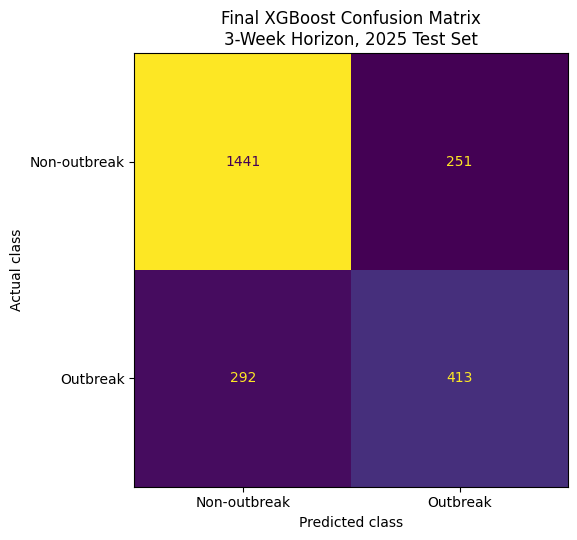


Saved successfully:
confusion_matrix_final_xgboost_test_2025_h3.png


In [145]:
# Regenerate the correct final 3-week confusion matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

print("=" * 72)
print("REGENERATING FINAL 3-WEEK CONFUSION MATRIX")
print("=" * 72)

# Use the verified final 3-week test predictions
cm_h3_final = confusion_matrix(
    y_test_h3,
    test_pred_h3_reproduced
)

print("\nVerified confusion matrix:")
print(cm_h3_final)

# Safety check
expected_cm_h3 = [[1441, 251],
                  [292, 413]]

if cm_h3_final.tolist() != expected_cm_h3:
    raise ValueError(
        f"Unexpected confusion matrix: {cm_h3_final.tolist()}"
    )

# Create the figure
fig, ax = plt.subplots(figsize=(6.5, 5.5))

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm_h3_final,
    display_labels=["Non-outbreak", "Outbreak"]
)

display_cm.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

ax.set_title(
    "Final XGBoost Confusion Matrix\n"
    "3-Week Horizon, 2025 Test Set"
)

ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")

plt.tight_layout()

# Save using the same filename so it can replace the old figure
figure_filename = (
    "confusion_matrix_final_xgboost_test_2025_h3.png"
)

plt.savefig(
    figure_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved successfully:")
print(figure_filename)


**Why this figure?** Regenerating the three-week confusion matrix from the reconstructed primary objects ensures that the figure corresponds to the same predictions used for the reported test metrics.


In [146]:
# List all Chapter 4 figures

import os
import glob

print("=" * 70)
print("CHAPTER 4 FIGURES")
print("=" * 70)

png_files = sorted(glob.glob("*.png"))

if len(png_files) == 0:
    print("No PNG files found in the current directory.")
else:
    for i, file in enumerate(png_files, start=1):
        size_kb = os.path.getsize(file) / 1024
        print(f"{i:2d}. {file} ({size_kb:.1f} KB)")


CHAPTER 4 FIGURES
 1. confusion_matrix_best_xgboost_validation_h3.png (129.9 KB)
 2. confusion_matrix_final_xgboost_test_2025_h3.png (90.2 KB)
 3. expanding_window_performance_by_year_xgboost_h3.png (263.6 KB)
 4. missed_vs_false_alarms_final_test_2025_xgboost_h3.png (149.8 KB)
 5. model_performance_comparison_validation_h3.png (445.0 KB)
 6. predicted_probability_distribution_validation_vs_test_h3.png (136.8 KB)
 7. predictor_group_comparison_xgboost_validation_h3.png (188.8 KB)
 8. predictor_group_outbreak_counts_xgboost_validation_h3.png (200.0 KB)
 9. shap_dependence_cholera_cases.png (184.2 KB)
10. shap_dependence_cholera_cases_final_xgboost_2025_h3.png (197.2 KB)
11. shap_dependence_outbreak_current.png (136.4 KB)
12. shap_dependence_population_2019.png (161.1 KB)
13. shap_dependence_wash_vulnerability_final_xgboost_2025_h3.png (222.5 KB)
14. shap_dependence_wash_vulnerability_index.png (236.4 KB)
15. shap_global_feature_importance_final_xgboost_2025_h3.png (251.9 KB)
16. shap_su

**Why this figure?** The plot turns the numerical output into a pattern that is easier to compare visually. It is included to support interpretation of the corresponding table or model result, not as a separate source of evidence.


REGENERATING FINAL TEST ERROR-COUNT FIGURE
False alarms: 251
Missed outbreaks: 292


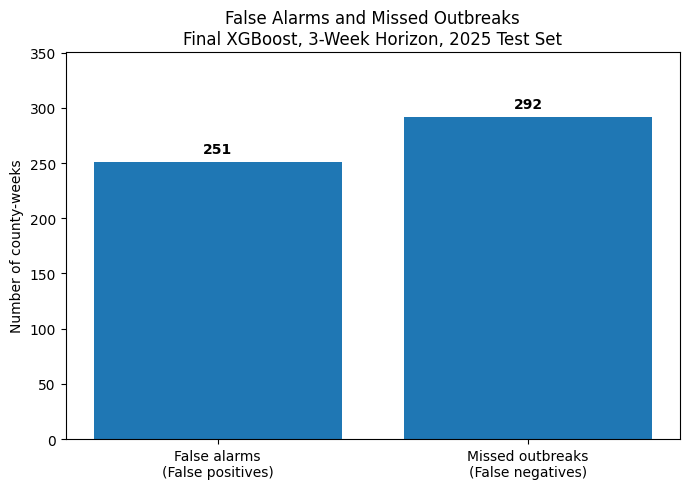


Saved successfully:
missed_vs_false_alarms_final_test_2025_xgboost_h3.png


In [147]:
# Regenerate missed outbreaks versus false alarms figure

import matplotlib.pyplot as plt

print("=" * 72)
print("REGENERATING FINAL TEST ERROR-COUNT FIGURE")
print("=" * 72)

# Verified H3 final-test errors
false_positives_h3_final = (
    test_results_h3_reproduced["false_positives"]
)

false_negatives_h3_final = (
    test_results_h3_reproduced["false_negatives"]
)

print("False alarms:", false_positives_h3_final)
print("Missed outbreaks:", false_negatives_h3_final)

# Safety checks
if false_positives_h3_final != 251:
    raise ValueError(
        f"Expected 251 false positives, found "
        f"{false_positives_h3_final}"
    )

if false_negatives_h3_final != 292:
    raise ValueError(
        f"Expected 292 false negatives, found "
        f"{false_negatives_h3_final}"
    )

error_labels = [
    "False alarms\n(False positives)",
    "Missed outbreaks\n(False negatives)"
]

error_counts = [
    false_positives_h3_final,
    false_negatives_h3_final
]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    error_labels,
    error_counts
)

ax.set_ylabel("Number of county-weeks")
ax.set_title(
    "False Alarms and Missed Outbreaks\n"
    "Final XGBoost, 3-Week Horizon, 2025 Test Set"
)

ax.set_ylim(
    0,
    max(error_counts) * 1.20
)

for bar, count in zip(bars, error_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(count),
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()

figure_filename = (
    "missed_vs_false_alarms_final_test_2025_xgboost_h3.png"
)

plt.savefig(
    figure_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved successfully:")
print(figure_filename)


**Why this figure?** This final missed-versus-false-alert figure expresses the primary 2025 error profile in counts and is useful for explaining the operational consequences of the selected threshold.


In [148]:
# Check the data used for the ARIMA vs XGBoost comparison

print("=" * 72)
print("CHECKING ARIMA VS XGBOOST COMPARISON")
print("=" * 72)

objects = [
    "arima_metrics",
    "arima_results",
    "arima_test_results",
    "xgb_test_results",
    "test_results_h3_reproduced",
    "comparison_df",
    "comparison_table",
    "model_comparison"
]

for obj in objects:
    if obj in globals():
        print(f"\n{obj}: FOUND")
        try:
            display(globals()[obj])
        except Exception:
            print(globals()[obj])
    else:
        print(f"{obj}: not found")


CHECKING ARIMA VS XGBOOST COMPARISON
arima_metrics: not found
arima_results: not found
arima_test_results: not found
xgb_test_results: not found

test_results_h3_reproduced: FOUND


{'threshold': 0.5,
 'true_negatives': 1441,
 'false_positives': 251,
 'false_negatives': 292,
 'true_positives': 413,
 'accuracy': 0.7734668335419274,
 'precision': 0.6219879518072289,
 'sensitivity': 0.5858156028368794,
 'specificity': np.float64(0.8516548463356974),
 'balanced_accuracy': np.float64(0.7187352245862884),
 'f1_score': 0.6033601168736303,
 'roc_auc': np.float64(0.7601256643696662),
 'pr_auc': np.float64(0.5933197717313232),
 'brier_score': np.float64(0.17414297448196409)}

comparison_df: not found
comparison_table: not found
model_comparison: not found


**Interpretation.** Before comparing ARIMA and XGBoost, the code checks that both predictions refer to the same observations and outbreak definition. A paired comparison is only meaningful if this alignment holds.


ARIMA VERSUS XGBOOST COMPARISON COMPARISON

Verified comparison table:


,Model,Accuracy,Precision,Sensitivity,Specificity,F1-score,Balanced accuracy
0,County-level ARIMA,0.7939,0.6953,0.5149,0.9102,0.6081,0.7125
1,Final XGBoost,0.7735,0.6220,0.5858,0.8517,0.6034,0.7187


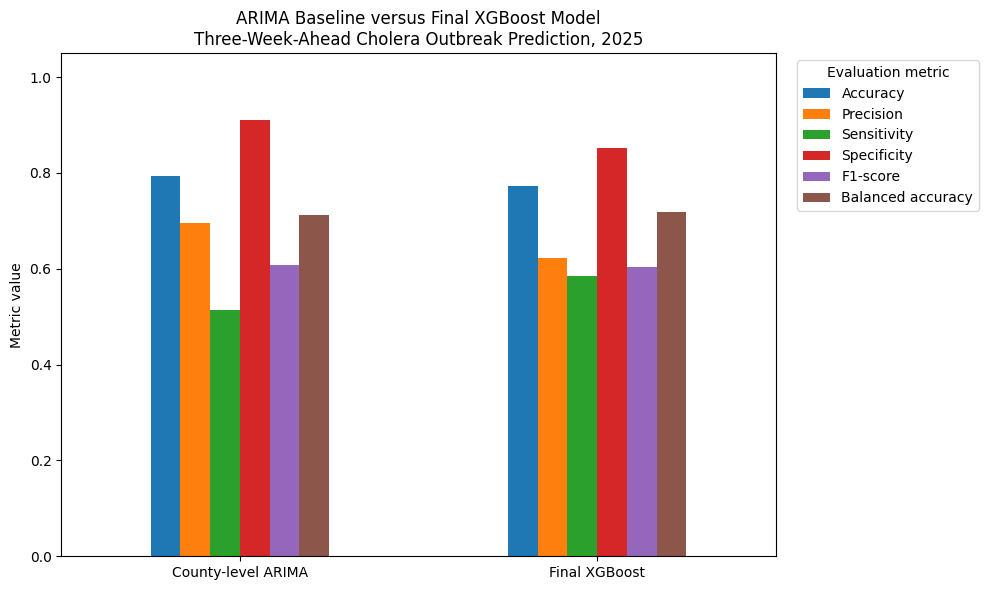


Saved successfully:
arima_vs_xgboost_metrics_outbreak_h3_2025.png
arima_vs_xgboost_verified_metrics_2025.csv


In [149]:
# Regenerate the paired ARIMA versus XGBoost comparison

import pandas as pd
import matplotlib.pyplot as plt

print("=" * 72)
print("ARIMA VERSUS XGBOOST COMPARISON COMPARISON")
print("=" * 72)

# Verified ARIMA results from the county-level baseline analysis
arima_metrics_verified = {
    "Accuracy": 0.7939,
    "Precision": 0.6953,
    "Sensitivity": 0.5149,
    "Specificity": 0.9102,
    "F1-score": 0.6081,
    "Balanced accuracy": 0.7125
}

# Verified final three-week XGBoost results
xgboost_metrics_verified = {
    "Accuracy": test_results_h3_reproduced["accuracy"],
    "Precision": test_results_h3_reproduced["precision"],
    "Sensitivity": test_results_h3_reproduced["sensitivity"],
    "Specificity": test_results_h3_reproduced["specificity"],
    "F1-score": test_results_h3_reproduced["f1_score"],
    "Balanced accuracy": test_results_h3_reproduced["balanced_accuracy"]
}

arima_vs_xgboost_verified = pd.DataFrame(
    [
        {
            "Model": "County-level ARIMA",
            **arima_metrics_verified
        },
        {
            "Model": "Final XGBoost",
            **xgboost_metrics_verified
        }
    ]
)

print("\nVerified comparison table:")
display(arima_vs_xgboost_verified.round(4))

plot_data = (
    arima_vs_xgboost_verified
    .set_index("Model")
)

ax = plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title(
    "ARIMA Baseline versus Final XGBoost Model\n"
    "Three-Week-Ahead Cholera Outbreak Prediction, 2025"
)

ax.set_xlabel("")
ax.set_ylabel("Metric value")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=0)

plt.legend(
    title="Evaluation metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

figure_filename = (
    "arima_vs_xgboost_metrics_outbreak_h3_2025.png"
)

plt.savefig(
    figure_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

arima_vs_xgboost_verified.to_csv(
    "arima_vs_xgboost_verified_metrics_2025.csv",
    index=False
)

print("\nSaved successfully:")
print(figure_filename)
print("arima_vs_xgboost_verified_metrics_2025.csv")


**Why this figure?** The ARIMA–XGBoost comparison highlights the main operational contrast: XGBoost detects more outbreaks, while ARIMA generates fewer false alerts and has higher specificity.


## 14. Computational reproducibility

I record the software environment used for the analysis so that the workflow can be reproduced under a comparable setup.

The random seed is fixed at **42** for stochastic modelling and bootstrap procedures where applicable. Package versions are reported because differences in numerical libraries or model implementations can sometimes produce small changes in results.


In [150]:
# REPRODUCIBILITY: SOFTWARE AND PACKAGE VERSIONS

import sys
import platform
import pandas as pd
import numpy as np
import sklearn
import xgboost
import statsmodels
import shap
import matplotlib

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("statsmodels:", statsmodels.__version__)
print("SHAP:", shap.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Computing environment: Google Colab")
print("Random seed used in modelling: 42")


Python: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
pandas: 2.2.3
NumPy: 2.1.3
scikit-learn: 1.6.1
XGBoost: 3.4.1
statsmodels: 0.14.6
SHAP: 0.52.0
Matplotlib: 3.10.0
Computing environment: Google Colab
Random seed used in modelling: 42


**Interpretation.** Recording package and system versions makes the computational environment explicit. The fixed **random seed 42** is also part of the reproducibility information.


## 15. Robustness analyses and primary result checks

The remaining analytical blocks bring together the main robustness and uncertainty analyses in one place. They include:

- calendar-year sensitivity,
- the broader outbreak definition,
- Random Forest class-weight behaviour,
- probability calibration,
- descriptive epidemiology,
- bootstrap confidence intervals,
- paired ARIMA–XGBoost comparison,
- operational alert burden, and
- the aligned two-, three- and four-week comparison.

These analyses are kept together because they address a common question: **how stable is the main conclusion when the modelling assumptions, outcome definition or evaluation perspective changes?**


In [151]:
# RECREATE THE MINIMUM OBJECTS NEEDED FOR THE
# CALENDAR-YEAR SENSITIVITY ANALYSIS

# Main target
target_h3 = "outbreak_h3"

# Original predictor set used in the primary analysis
predictor_columns = [
    "year",
    "epi_week",
    "rainy_season_flag",
    "population_2019",
    "rainfall_mm",
    "mean_temp_c",
    "flood_indicator",
    "ndvi",
    "drought_index",
    "wash_vulnerability_index",
    "rainfall_lag1_mm",
    "rainfall_lag2_mm",
    "rainfall_lag3_mm",
    "rainfall_lag4_mm",
    "temp_lag1_c",
    "temp_lag2_c",
    "temp_lag3_c",
    "rainfall_rolling4_mm",
    "rainfall_rolling8_mm",
    "temp_x_rainfall",
    "cholera_cases",
    "incidence_per_100k",
    "outbreak_current"
]

# Create the 3-week modelling dataset exactly as in the notebook
model_data_h3 = features_original.dropna(
    subset=predictor_columns + [target_h3]
).copy()

print("3-week modelling dataset shape:", model_data_h3.shape)
print(
    "Missing values remaining:",
    model_data_h3[predictor_columns + [target_h3]]
    .isnull()
    .sum()
    .sum()
)

print(
    "Years available:",
    int(model_data_h3["year"].min()),
    "-",
    int(model_data_h3["year"].max())
)


3-week modelling dataset shape: (26508, 34)
Missing values remaining: 0
Years available: 2015 - 2025


**Interpretation.** This step prepares an intermediate dataset or object required for the analysis. Printing the resulting structure provides a quick check that the transformation behaved as intended.


### Earlier exploratory calendar-year sensitivity check

This calculation is retained to document the development of the analysis. It identifies 2025 using the **predictor-week calendar year**, which gives 2,303 observations. Because the forecasting task is defined by the date of the future outcome, this is not the split used for the reported sensitivity result.

The primary calendar-year sensitivity analysis appears later and assigns observations using the **future target date**. It therefore uses the same **2,397 2025 county-weeks** as the main evaluation and gives TP = 524, FN = 181, TN = 1,207 and FP = 485, with sensitivity 0.7433, specificity 0.7134 and balanced accuracy 0.7283.

Keeping this earlier calculation makes the analytical development transparent while clearly distinguishing it from the result used for interpretation.


In [152]:
# SENSITIVITY ANALYSIS:
# Final XGBoost model WITHOUT calendar year

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix
)

import pandas as pd


# 1. Define the ORIGINAL predictor set exactly as used
#    in the thesis

predictor_columns = [
    "year",
    "epi_week",
    "rainy_season_flag",
    "population_2019",
    "rainfall_mm",
    "mean_temp_c",
    "flood_indicator",
    "ndvi",
    "drought_index",
    "wash_vulnerability_index",
    "rainfall_lag1_mm",
    "rainfall_lag2_mm",
    "rainfall_lag3_mm",
    "rainfall_lag4_mm",
    "temp_lag1_c",
    "temp_lag2_c",
    "temp_lag3_c",
    "rainfall_rolling4_mm",
    "rainfall_rolling8_mm",
    "temp_x_rainfall",
    "cholera_cases",
    "incidence_per_100k",
    "outbreak_current"
]

target_h3 = "outbreak_h3"


# 2. Remove ONLY calendar year

predictors_no_year = [
    col for col in predictor_columns
    if col != "year"
]

print("Original predictors:", len(predictor_columns))
print("Predictors without year:", len(predictors_no_year))
print("Is year still included?", "year" in predictors_no_year)


# 3. Recreate final training and test sets
#    EXACTLY as in the original final analysis
#
#    Training = 2015-2024
#    Testing  = 2025

final_train_data_h3 = model_data_h3[
    model_data_h3["year"] <= 2024
].copy()

final_test_data_h3 = model_data_h3[
    model_data_h3["year"] == 2025
].copy()


# 4. Create X and y WITHOUT calendar year

X_train_no_year = final_train_data_h3[
    predictors_no_year
].copy()

y_train_no_year = final_train_data_h3[
    target_h3
].copy()

X_test_no_year = final_test_data_h3[
    predictors_no_year
].copy()

y_test_no_year = final_test_data_h3[
    target_h3
].copy()


print("\nTraining observations:", len(X_train_no_year))
print("Test observations:", len(X_test_no_year))
print("Number of predictors:", X_train_no_year.shape[1])

print(
    "Training years:",
    int(final_train_data_h3["year"].min()),
    "-",
    int(final_train_data_h3["year"].max())
)

print(
    "Test year:",
    final_test_data_h3["year"].unique()
)


# 5. Fit EXACTLY the locked final XGBoost specification

xgb_no_year = XGBClassifier(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=6,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_no_year.fit(
    X_train_no_year,
    y_train_no_year
)


# 6. Predict on untouched 2025 test period

prob_no_year = xgb_no_year.predict_proba(
    X_test_no_year
)[:, 1]

# Keep EXACTLY the locked threshold of 0.50
pred_no_year = (
    prob_no_year >= 0.50
).astype(int)


# 7. Confusion matrix

tn, fp, fn, tp = confusion_matrix(
    y_test_no_year,
    pred_no_year
).ravel()

specificity_no_year = tn / (tn + fp)


# 8. Calculate performance

results_no_year = {
    "True positives": tp,
    "False negatives": fn,
    "True negatives": tn,
    "False positives": fp,

    "Accuracy":
        accuracy_score(
            y_test_no_year,
            pred_no_year
        ),

    "Precision":
        precision_score(
            y_test_no_year,
            pred_no_year
        ),

    "Sensitivity":
        recall_score(
            y_test_no_year,
            pred_no_year
        ),

    "Specificity":
        specificity_no_year,

    "F1-score":
        f1_score(
            y_test_no_year,
            pred_no_year
        ),

    "Balanced accuracy":
        balanced_accuracy_score(
            y_test_no_year,
            pred_no_year
        ),

    "ROC AUC":
        roc_auc_score(
            y_test_no_year,
            prob_no_year
        ),

    "PR AUC":
        average_precision_score(
            y_test_no_year,
            prob_no_year
        ),

    "Brier score":
        brier_score_loss(
            y_test_no_year,
            prob_no_year
        )
}


# 9. Print results

print("\n" + "=" * 65)
print("XGBOOST WITHOUT CALENDAR YEAR — 2025 TEST RESULTS")
print("=" * 65)

for metric, value in results_no_year.items():

    if metric in [
        "True positives",
        "False negatives",
        "True negatives",
        "False positives"
    ]:
        print(f"{metric:22s}: {value}")

    else:
        print(f"{metric:22s}: {value:.4f}")


# 10. Compare with ORIGINAL primary model

comparison = pd.DataFrame({

    "With year": {
        "Sensitivity": 0.5858,
        "Specificity": 0.8517,
        "Balanced accuracy": 0.7187,
        "ROC AUC": 0.7601,
        "PR AUC": 0.5933,
        "Brier score": 0.1741
    },

    "Without year": {
        "Sensitivity":
            results_no_year["Sensitivity"],

        "Specificity":
            results_no_year["Specificity"],

        "Balanced accuracy":
            results_no_year["Balanced accuracy"],

        "ROC AUC":
            results_no_year["ROC AUC"],

        "PR AUC":
            results_no_year["PR AUC"],

        "Brier score":
            results_no_year["Brier score"]
    }
})

comparison["Difference"] = (
    comparison["Without year"] -
    comparison["With year"]
)

print("\n" + "=" * 65)
print("DIRECT COMPARISON: WITH YEAR vs WITHOUT YEAR")
print("=" * 65)

display(comparison.round(4))


Original predictors: 23
Predictors without year: 22
Is year still included? False

Training observations: 24205
Test observations: 2303
Number of predictors: 22
Training years: 2015 - 2024
Test year: [2025]

XGBOOST WITHOUT CALENDAR YEAR — 2025 TEST RESULTS
True positives        : 494
False negatives       : 173
True negatives        : 1167
False positives       : 469
Accuracy              : 0.7212
Precision             : 0.5130
Sensitivity           : 0.7406
Specificity           : 0.7133
F1-score              : 0.6061
Balanced accuracy     : 0.7270
ROC AUC               : 0.8133
PR AUC                : 0.7002
Brier score           : 0.1911

DIRECT COMPARISON: WITH YEAR vs WITHOUT YEAR


,With year,Without year,Difference
Sensitivity,0.5858,0.7406,0.1548
Specificity,0.8517,0.7133,-0.1384
Balanced accuracy,0.7187,0.7270,0.0083
ROC AUC,0.7601,0.8133,0.0532
PR AUC,0.5933,0.7002,0.1069
Brier score,0.1741,0.1911,0.0170


### Why this split matters

The model is developed using a strictly chronological design. Earlier observations are used for model fitting, the 2023–2024 period is used for model and threshold selection, and 2025 is kept separate for independent evaluation. This avoids mixing future information into model development and gives a more realistic assessment of how the model might perform prospectively.


**Interpretation.** This output documents the result of the step above and provides a checkpoint before the workflow moves on. It is retained so that the analytical decisions can be followed from data preparation through model evaluation.


In [153]:
# Calendar-year sensitivity analysis using the target-date split
# Uses TARGET-DATE-ALIGNED final split

import pandas as pd
from xgboost import XGBClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

# 1. Recreate the 3-week TARGET DATE

model_data_h3["week_start_date"] = pd.to_datetime(
    model_data_h3["week_start_date"]
)

model_data_h3["target_date_h3"] = (
    model_data_h3["week_start_date"]
    + pd.Timedelta(weeks=3)
)

# 2. Correct final split:
#    training targets before 2025
#    testing targets occurring during 2025

final_train_correct = model_data_h3[
    model_data_h3["target_date_h3"]
    < pd.Timestamp("2025-01-01")
].copy()

final_test_correct = model_data_h3[
    (model_data_h3["target_date_h3"]
     >= pd.Timestamp("2025-01-01"))
    &
    (model_data_h3["target_date_h3"]
     < pd.Timestamp("2026-01-01"))
].copy()

print("Correct final training observations:",
      len(final_train_correct))

print("Correct final test observations:",
      len(final_test_correct))

print("\nCorrect 2025 target distribution:")
print(
    final_test_correct["outbreak_h3"]
    .value_counts()
    .sort_index()
)

# 3. Remove ONLY calendar year

predictors_no_year = [
    col for col in predictor_columns
    if col != "year"
]

X_train_no_year = final_train_correct[
    predictors_no_year
].copy()

y_train_no_year = final_train_correct[
    "outbreak_h3"
].copy()

X_test_no_year = final_test_correct[
    predictors_no_year
].copy()

y_test_no_year = final_test_correct[
    "outbreak_h3"
].copy()

print("\nPredictors used:",
      len(predictors_no_year))

# 4. Fit same LOCKED XGBoost model

xgb_no_year_correct = XGBClassifier(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=6,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_no_year_correct.fit(
    X_train_no_year,
    y_train_no_year
)

# 5. Predict on correct 2025 target-date test set

prob_no_year_correct = (
    xgb_no_year_correct
    .predict_proba(X_test_no_year)[:, 1]
)

pred_no_year_correct = (
    prob_no_year_correct >= 0.50
).astype(int)

# 6. Confusion matrix

tn, fp, fn, tp = confusion_matrix(
    y_test_no_year,
    pred_no_year_correct
).ravel()

specificity = tn / (tn + fp)

# 7. Metrics

results_no_year_correct = {
    "True positives": tp,
    "False negatives": fn,
    "True negatives": tn,
    "False positives": fp,
    "Accuracy": accuracy_score(
        y_test_no_year,
        pred_no_year_correct
    ),
    "Precision": precision_score(
        y_test_no_year,
        pred_no_year_correct,
        zero_division=0
    ),
    "Sensitivity": recall_score(
        y_test_no_year,
        pred_no_year_correct,
        zero_division=0
    ),
    "Specificity": specificity,
    "F1-score": f1_score(
        y_test_no_year,
        pred_no_year_correct,
        zero_division=0
    ),
    "Balanced accuracy": balanced_accuracy_score(
        y_test_no_year,
        pred_no_year_correct
    ),
    "ROC AUC": roc_auc_score(
        y_test_no_year,
        prob_no_year_correct
    ),
    "PR AUC": average_precision_score(
        y_test_no_year,
        prob_no_year_correct
    ),
    "Brier score": brier_score_loss(
        y_test_no_year,
        prob_no_year_correct
    )
}

print("\n" + "=" * 70)
print("CORRECT NO-YEAR XGBOOST — 2025 TARGET-DATE TEST RESULTS")
print("=" * 70)

for metric, value in results_no_year_correct.items():

    if metric in [
        "True positives",
        "False negatives",
        "True negatives",
        "False positives"
    ]:
        print(f"{metric:22s}: {value}")
    else:
        print(f"{metric:22s}: {value:.4f}")

# 8. Direct comparison with VERIFIED primary model

comparison_correct = pd.DataFrame({

    "With calendar year": {
        "Sensitivity": 0.5858,
        "Specificity": 0.8517,
        "Balanced accuracy": 0.7187,
        "ROC AUC": 0.7601,
        "PR AUC": 0.5933,
        "Brier score": 0.1741
    },

    "Without calendar year": {
        "Sensitivity":
            results_no_year_correct["Sensitivity"],

        "Specificity":
            results_no_year_correct["Specificity"],

        "Balanced accuracy":
            results_no_year_correct["Balanced accuracy"],

        "ROC AUC":
            results_no_year_correct["ROC AUC"],

        "PR AUC":
            results_no_year_correct["PR AUC"],

        "Brier score":
            results_no_year_correct["Brier score"]
    }
})

comparison_correct["Difference"] = (
    comparison_correct["Without calendar year"]
    -
    comparison_correct["With calendar year"]
)

print("\n" + "=" * 70)
print("VERIFIED COMPARISON: WITH YEAR vs WITHOUT YEAR")
print("=" * 70)

display(comparison_correct.round(4))


Correct final training observations: 24111
Correct final test observations: 2397

Correct 2025 target distribution:
outbreak_h3
0.0    1692
1.0     705
Name: count, dtype: int64

Predictors used: 22

CORRECT NO-YEAR XGBOOST — 2025 TARGET-DATE TEST RESULTS
True positives        : 524
False negatives       : 181
True negatives        : 1207
False positives       : 485
Accuracy              : 0.7222
Precision             : 0.5193
Sensitivity           : 0.7433
Specificity           : 0.7134
F1-score              : 0.6114
Balanced accuracy     : 0.7283
ROC AUC               : 0.8148
PR AUC                : 0.7024
Brier score           : 0.1892

VERIFIED COMPARISON: WITH YEAR vs WITHOUT YEAR


,With calendar year,Without calendar year,Difference
Sensitivity,0.5858,0.7433,0.1575
Specificity,0.8517,0.7134,-0.1383
Balanced accuracy,0.7187,0.7283,0.0096
ROC AUC,0.7601,0.8148,0.0547
PR AUC,0.5933,0.7024,0.1091
Brier score,0.1741,0.1892,0.0151


**Interpretation.** In the calendar-year sensitivity analysis, removing year increases sensitivity to **0.7433** but lowers specificity to **0.7134** and increases false alerts. The model therefore does not depend on year alone, but year materially affects how conservative the alerting profile is.


In [154]:
# OUTBREAK-DEFINITION SENSITIVITY ANALYSIS
# Main 3-week XGBoost model

import pandas as pd
import numpy as np

from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

# 1. Use the original feature matrix

sens_data = features.copy()

sens_data["week_start_date"] = pd.to_datetime(
    sens_data["week_start_date"]
)

sens_data = sens_data.sort_values(
    ["county", "week_start_date"]
).copy()

# 2. Define alternative analytical outbreak rules
#
# NOTE:
# These are sensitivity-analysis definitions only.
# They are NOT official WHO/MoH outbreak definitions.

definitions = {
    "Main: cases>=5 OR incidence>=1": (5, 1.0),
    "Looser: cases>=3 OR incidence>=0.5": (3, 0.5),
    "Stricter: cases>=10 OR incidence>=2": (10, 2.0)
}

# 3. Locked predictor set from the thesis

base_predictors = [
    "year",
    "epi_week",
    "rainy_season_flag",
    "population_2019",
    "rainfall_mm",
    "mean_temp_c",
    "flood_indicator",
    "ndvi",
    "drought_index",
    "wash_vulnerability_index",
    "rainfall_lag1_mm",
    "rainfall_lag2_mm",
    "rainfall_lag3_mm",
    "rainfall_lag4_mm",
    "temp_lag1_c",
    "temp_lag2_c",
    "temp_lag3_c",
    "rainfall_rolling4_mm",
    "rainfall_rolling8_mm",
    "temp_x_rainfall",
    "cholera_cases",
    "incidence_per_100k"
]

results = []

# 4. Run each outbreak definition

for label, (case_cutoff, incidence_cutoff) in definitions.items():

    df = sens_data.copy()

    # Current outbreak status under this definition
    df["outbreak_current_sens"] = (
        (df["cholera_cases"] >= case_cutoff) |
        (df["incidence_per_100k"] >= incidence_cutoff)
    ).astype(int)

    # 3-week-ahead outbreak target within each county
    df["outbreak_h3_sens"] = (
        df.groupby("county")["outbreak_current_sens"]
          .shift(-3)
    )

    # Target date = prediction date + 3 weeks
    df["target_date_h3"] = (
        df["week_start_date"] + pd.Timedelta(weeks=3)
    )

    # Replace original outbreak_current predictor
    predictor_cols = base_predictors + ["outbreak_current_sens"]

    # Keep only complete modelling rows
    needed_cols = predictor_cols + [
        "outbreak_h3_sens",
        "target_date_h3"
    ]

    model_df = df.dropna(subset=needed_cols).copy()

    # IMPORTANT:
    # Split by TARGET DATE, not predictor year
    # Final training = target dates before 2025
    # Final test = target dates in 2025

    train_df = model_df[
        model_df["target_date_h3"].dt.year <= 2024
    ].copy()

    test_df = model_df[
        model_df["target_date_h3"].dt.year == 2025
    ].copy()

    X_train = train_df[predictor_cols]
    y_train = train_df["outbreak_h3_sens"].astype(int)

    X_test = test_df[predictor_cols]
    y_test = test_df["outbreak_h3_sens"].astype(int)

    # 5. Locked XGBoost specification

    model = XGBClassifier(
        n_estimators=300,
        max_depth=2,
        learning_rate=0.03,
        subsample=0.80,
        colsample_bytree=0.80,
        scale_pos_weight=6,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )

    model.fit(X_train, y_train)

    prob = model.predict_proba(X_test)[:, 1]

    # Locked thesis threshold
    pred = (prob >= 0.50).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test, pred
    ).ravel()

    sensitivity = recall_score(y_test, pred)
    specificity = tn / (tn + fp)

    results.append({
        "Definition": label,
        "2025 test n": len(y_test),
        "Actual outbreaks": int(y_test.sum()),
        "Detected outbreaks": int(tp),
        "Missed outbreaks": int(fn),
        "False alerts": int(fp),
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(
            y_test, pred, zero_division=0
        ),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1": f1_score(y_test, pred),
        "Balanced accuracy": balanced_accuracy_score(
            y_test, pred
        ),
        "ROC AUC": roc_auc_score(y_test, prob),
        "PR AUC": average_precision_score(
            y_test, prob
        ),
        "Brier score": brier_score_loss(
            y_test, prob
        )
    })

# 6. Display comparison table

sensitivity_results = pd.DataFrame(results)

numeric_cols = sensitivity_results.select_dtypes(
    include=np.number
).columns

sensitivity_results[numeric_cols] = (
    sensitivity_results[numeric_cols].round(4)
)

print("\n" + "=" * 80)
print("OUTBREAK-DEFINITION SENSITIVITY ANALYSIS — 2025 TEST")
print("=" * 80)

display(sensitivity_results)

# 7. Check that the main definition reproduces the thesis

main_row = sensitivity_results.iloc[0]

print("\nMAIN DEFINITION CHECK")
print("---------------------")
print("2025 test observations:", main_row["2025 test n"])
print("Actual outbreaks:", main_row["Actual outbreaks"])
print("Detected outbreaks:", main_row["Detected outbreaks"])
print("False alerts:", main_row["False alerts"])
print("Sensitivity:", main_row["Sensitivity"])
print("Specificity:", main_row["Specificity"])
print("Balanced accuracy:", main_row["Balanced accuracy"])
print("ROC AUC:", main_row["ROC AUC"])
print("PR AUC:", main_row["PR AUC"])
print("Brier score:", main_row["Brier score"])



OUTBREAK-DEFINITION SENSITIVITY ANALYSIS — 2025 TEST


,Definition,2025 test n,Actual outbreaks,Detected outbreaks,Missed outbreaks,False alerts,Accuracy,Precision,Sensitivity,Specificity,F1,Balanced accuracy,ROC AUC,PR AUC,Brier score
0,Main: cases>=5 OR incidence>=1,2397,730,695,35,1230,0.4723,0.3610,0.9521,0.2621,0.5235,0.6071,0.8000,0.6770,0.3039
1,Looser: cases>=3 OR incidence>=0.5,2397,1037,1037,0,1360,0.4326,0.4326,1.0000,0.0000,0.6040,0.5000,0.7633,0.7313,0.3686
2,Stricter: cases>=10 OR incidence>=2,2397,353,263,90,476,0.7639,0.3559,0.7450,0.7671,0.4817,0.7561,0.8387,0.5378,0.1640



MAIN DEFINITION CHECK
---------------------
2025 test observations: 2397
Actual outbreaks: 730
Detected outbreaks: 695
False alerts: 1230
Sensitivity: 0.9521
Specificity: 0.2621
Balanced accuracy: 0.6071
ROC AUC: 0.8
PR AUC: 0.677
Brier score: 0.3039


**Interpretation.** This output documents the result of the step above and provides a checkpoint before the workflow moves on. It is retained so that the analytical decisions can be followed from data preparation through model evaluation.


In [155]:
# DIAGNOSTIC CHECK:
# Original outbreak_h3 vs rebuilt main-definition outbreak_h3

check_df = sens_data.copy()

check_df["week_start_date"] = pd.to_datetime(check_df["week_start_date"])
check_df = check_df.sort_values(["county", "week_start_date"]).copy()

# Rebuild the MAIN current outbreak definition
check_df["outbreak_current_rebuilt"] = (
    (check_df["cholera_cases"] >= 5) |
    (check_df["incidence_per_100k"] >= 1)
).astype(int)

# Rebuild 3-week target
check_df["outbreak_h3_rebuilt"] = (
    check_df.groupby("county")["outbreak_current_rebuilt"]
            .shift(-3)
)

# Target date
check_df["target_date_h3"] = (
    check_df["week_start_date"] + pd.Timedelta(weeks=3)
)

# Restrict to 2025 target dates
check_2025 = check_df[
    check_df["target_date_h3"].dt.year == 2025
].copy()

# Keep rows where BOTH original and rebuilt targets exist
check_2025 = check_2025.dropna(
    subset=["outbreak_h3", "outbreak_h3_rebuilt"]
)

print("2025 rows compared:", len(check_2025))

print("\nOriginal outbreak_h3 positives:")
print(int(check_2025["outbreak_h3"].sum()))

print("\nRebuilt outbreak_h3 positives:")
print(int(check_2025["outbreak_h3_rebuilt"].sum()))

# Count disagreements
mismatch = (
    check_2025["outbreak_h3"].astype(int)
    != check_2025["outbreak_h3_rebuilt"].astype(int)
)

print("\nNumber of mismatched labels:")
print(int(mismatch.sum()))

# Show examples
print("\nFirst mismatched rows:")
display(
    check_2025.loc[
        mismatch,
        [
            "county",
            "week_start_date",
            "cholera_cases",
            "incidence_per_100k",
            "outbreak_current",
            "outbreak_current_rebuilt",
            "outbreak_h3",
            "outbreak_h3_rebuilt"
        ]
    ].head(20)
)


2025 rows compared: 2397

Original outbreak_h3 positives:
705

Rebuilt outbreak_h3 positives:
730

Number of mismatched labels:
25

First mismatched rows:


,county,week_start_date,cholera_cases,incidence_per_100k,outbreak_current,outbreak_current_rebuilt,outbreak_h3,outbreak_h3_rebuilt
6277,Isiolo,2025-04-14,1,0.373,0,0,0.0,1.0
6280,Isiolo,2025-05-05,3,1.119,1,1,0.0,1.0
6281,Isiolo,2025-05-12,0,0.000,0,0,0.0,1.0
6290,Isiolo,2025-07-14,0,0.000,0,0,0.0,1.0
2816,Lamu,2024-12-16,0,0.000,0,0,0.0,1.0
2819,Lamu,2025-01-06,2,1.390,1,1,0.0,1.0
2826,Lamu,2025-02-24,9,6.253,1,1,0.0,1.0
2830,Lamu,2025-03-24,5,3.474,1,1,0.0,1.0
2840,Lamu,2025-06-02,0,0.000,0,0,0.0,1.0
2841,Lamu,2025-06-09,0,0.000,0,0,0.0,1.0


**Interpretation.** This is a quality-control check. The output is used to confirm that the data or model objects satisfy the assumptions needed for the next stage rather than introducing a new modelling result.


In [156]:
# DIAGNOSTIC 2:
# HOW WAS THE ORIGINAL outbreak_h3 ACTUALLY CONSTRUCTED?

diag = features_original.copy()

diag["week_start_date"] = pd.to_datetime(diag["week_start_date"])

# Only rows where original future target and future case count exist
diag = diag.dropna(
    subset=["outbreak_h3", "cases_h3", "population_2019"]
).copy()

# Candidate A:
# future CASE threshold only

diag["h3_cases_only"] = (
    diag["cases_h3"] >= 5
).astype(int)

# Candidate B:
# documented rule applied at future week:
# cases >= 5 OR incidence >= 1 per 100,000
#
# Because population_2019 is constant within the county,
# future incidence can be reconstructed from cases_h3.

diag["incidence_h3_reconstructed"] = (
    diag["cases_h3"] /
    diag["population_2019"]
) * 100000

diag["h3_cases_or_incidence"] = (
    (diag["cases_h3"] >= 5) |
    (diag["incidence_h3_reconstructed"] >= 1)
).astype(int)

# Compare both candidate definitions with stored outbreak_h3

mismatch_cases_only = (
    diag["outbreak_h3"].astype(int)
    != diag["h3_cases_only"]
)

mismatch_or_rule = (
    diag["outbreak_h3"].astype(int)
    != diag["h3_cases_or_incidence"]
)

print("=" * 70)
print("HOW DOES STORED outbreak_h3 MATCH THE POSSIBLE RULES?")
print("=" * 70)

print("\nTotal rows checked:", len(diag))

print("\nMismatch with CASES >= 5 only:")
print(int(mismatch_cases_only.sum()))

print("\nMismatch with CASES >= 5 OR incidence >= 1:")
print(int(mismatch_or_rule.sum()))

print("\nOriginal outbreak_h3 positives:")
print(int(diag["outbreak_h3"].sum()))

print("\nCases-only positives:")
print(int(diag["h3_cases_only"].sum()))

print("\nCases-or-incidence positives:")
print(int(diag["h3_cases_or_incidence"].sum()))

# Show examples where the two candidate rules disagree

different_rules = (
    diag["h3_cases_only"] !=
    diag["h3_cases_or_incidence"]
)

print("\nExamples where incidence changes the classification:")
display(
    diag.loc[
        different_rules,
        [
            "county",
            "week_start_date",
            "population_2019",
            "cases_h3",
            "incidence_h3_reconstructed",
            "outbreak_h3",
            "h3_cases_only",
            "h3_cases_or_incidence"
        ]
    ].head(25)
)


HOW DOES STORED outbreak_h3 MATCH THE POSSIBLE RULES?

Total rows checked: 26837

Mismatch with CASES >= 5 only:
0

Mismatch with CASES >= 5 OR incidence >= 1:
176

Original outbreak_h3 positives:
4477

Cases-only positives:
4477

Cases-or-incidence positives:
4653

Examples where incidence changes the classification:


,county,week_start_date,population_2019,cases_h3,incidence_h3_reconstructed,outbreak_h3,h3_cases_only,h3_cases_or_incidence
1727,Tana River,2015-02-02,315943,4.0,1.266051,0.0,0,1
1737,Tana River,2015-04-13,315943,4.0,1.266051,0.0,0,1
1773,Tana River,2015-12-21,315943,4.0,1.266051,0.0,0,1
1814,Tana River,2016-10-03,315943,4.0,1.266051,0.0,0,1
1815,Tana River,2016-10-10,315943,4.0,1.266051,0.0,0,1
1832,Tana River,2017-02-06,315943,4.0,1.266051,0.0,0,1
1850,Tana River,2017-06-12,315943,4.0,1.266051,0.0,0,1
1861,Tana River,2017-08-28,315943,4.0,1.266051,0.0,0,1
1933,Tana River,2019-01-14,315943,4.0,1.266051,0.0,0,1
1938,Tana River,2019-02-18,315943,4.0,1.266051,0.0,0,1


**Interpretation.** This output documents the result of the step above and provides a checkpoint before the workflow moves on. It is retained so that the analytical decisions can be followed from data preparation through model evaluation.


In [157]:
# Verify the Primary Outbreak Target Definition

target_check = features_original.dropna(
    subset=["outbreak_h3", "cases_h3"]
).copy()

target_check["cases5_target"] = (
    target_check["cases_h3"] >= 5
).astype(int)

mismatches = (
    target_check["outbreak_h3"].astype(int)
    != target_check["cases5_target"]
).sum()

print("Rows checked:", len(target_check))
print("Stored outbreak_h3 positives:",
      int(target_check["outbreak_h3"].sum()))
print("Cases >= 5 positives:",
      int(target_check["cases5_target"].sum()))
print("Number of mismatches:", int(mismatches))


Rows checked: 26837
Stored outbreak_h3 positives: 4477
Cases >= 5 positives: 4477
Number of mismatches: 0


**Interpretation.** The primary future-outbreak label is checked directly against future weekly cases ≥ 5. This confirms that the model target corresponds to the stated analytical definition rather than the broader sensitivity rule.


In [158]:
# Reproduce primary three-week XGBoost model
# Purpose:
# Verify the exact original three-week XGBoost pipeline before
# changing the outbreak definition.
#
# Expected 2025 reference result:
# TP = 413, FN = 292, TN = 1441, FP = 251

from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

# 135A.1 Confirm existing chronological datasets

print("Training observations:", len(X_train_h3))
print("Validation observations:", len(X_valid_h3))
print("Test observations:", len(X_test_h3))

print("\nTraining target distribution:")
print(y_train_h3.value_counts().sort_index())

print("\nValidation target distribution:")
print(y_valid_h3.value_counts().sort_index())

print("\nTest target distribution:")
print(y_test_h3.value_counts().sort_index())


# 135A.2 Fit the LOCKED model on the original training set only

xgb_reproduction_h3 = XGBClassifier(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.80,
    colsample_bytree=0.80,
    scale_pos_weight=6,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_reproduction_h3.fit(
    X_train_h3,
    y_train_h3
)


# 135A.3 Evaluate once on untouched 2025 test set

prob_reproduction_h3 = xgb_reproduction_h3.predict_proba(
    X_test_h3
)[:, 1]

pred_reproduction_h3 = (
    prob_reproduction_h3 >= 0.50
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test_h3,
    pred_reproduction_h3
).ravel()

specificity = tn / (tn + fp)

print("\n" + "=" * 70)
print("STEP 135A — PRIMARY ANALYSIS MODEL REPRODUCTION")
print("=" * 70)

print("True positives :", tp)
print("False negatives:", fn)
print("True negatives :", tn)
print("False positives:", fp)

print("\nAccuracy:",
      round(accuracy_score(y_test_h3, pred_reproduction_h3), 4))

print("Precision:",
      round(precision_score(y_test_h3, pred_reproduction_h3), 4))

print("Sensitivity:",
      round(recall_score(y_test_h3, pred_reproduction_h3), 4))

print("Specificity:",
      round(specificity, 4))

print("F1-score:",
      round(f1_score(y_test_h3, pred_reproduction_h3), 4))

print("Balanced accuracy:",
      round(balanced_accuracy_score(
          y_test_h3,
          pred_reproduction_h3
      ), 4))

print("ROC AUC:",
      round(roc_auc_score(
          y_test_h3,
          prob_reproduction_h3
      ), 4))

print("PR AUC:",
      round(average_precision_score(
          y_test_h3,
          prob_reproduction_h3
      ), 4))

print("Brier score:",
      round(brier_score_loss(
          y_test_h3,
          prob_reproduction_h3
      ), 4))


# 135A.4 Automatic thesis consistency check

expected = {
    "TP": 413,
    "FN": 292,
    "TN": 1441,
    "FP": 251
}

observed = {
    "TP": int(tp),
    "FN": int(fn),
    "TN": int(tn),
    "FP": int(fp)
}

print("\nPRIMARY RESULT CONSISTENCY CHECK")
print("------------------------")

if observed == expected:
    print("PASS: Exact reproduction of the primary confusion matrix.")
else:
    print("NOT YET MATCHED.")
    print("Expected:", expected)
    print("Observed:", observed)


Training observations: 19176
Validation observations: 4935
Test observations: 2397

Training target distribution:
outbreak_h3
0.0    17094
1.0     2082
Name: count, dtype: int64

Validation target distribution:
outbreak_h3
0.0    3336
1.0    1599
Name: count, dtype: int64

Test target distribution:
outbreak_h3
0.0    1692
1.0     705
Name: count, dtype: int64

STEP 135A — PRIMARY ANALYSIS MODEL REPRODUCTION
True positives : 413
False negatives: 292
True negatives : 1441
False positives: 251

Accuracy: 0.7735
Precision: 0.622
Sensitivity: 0.5858
Specificity: 0.8517
F1-score: 0.6034
Balanced accuracy: 0.7187
ROC AUC: 0.7601
PR AUC: 0.5933
Brier score: 0.1741

PRIMARY RESULT CONSISTENCY CHECK
------------------------
PASS: Exact reproduction of the primary confusion matrix.


### Why this split matters

The model is developed using a strictly chronological design. Earlier observations are used for model fitting, the 2023–2024 period is used for model and threshold selection, and 2025 is kept separate for independent evaluation. This avoids mixing future information into model development and gives a more realistic assessment of how the model might perform prospectively.


**Interpretation.** This block reproduces the primary 2025 XGBoost result from the designated training data. The confusion matrix is **TP 413, FN 292, TN 1,441 and FP 251**, corresponding to sensitivity **0.5858** and specificity **0.8517**.


In [159]:
# Outbreak-Definition Sensitivity Analysis
# Purpose:
# Evaluate whether the final XGBoost findings are sensitive
# to the analytical definition of a future outbreak.
#
# Primary target used in the primary analysis:
#     future cholera cases >= 5
#
# Alternative sensitivity definition:
#     future cases >= 5 OR
#     future incidence >= 1 case per 100,000 population
#
# IMPORTANT:
# The model specification, predictors, temporal partitions and
# classification threshold remain fixed. Only the outcome
# definition is changed.

import pandas as pd
import numpy as np

from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)


# 135B.1 Verify index alignment with the protected feature data

all_indices_available = (
    X_train_h3.index.isin(features_original.index).all()
    and X_valid_h3.index.isin(features_original.index).all()
    and X_test_h3.index.isin(features_original.index).all()
)

print("All modelling indices found in features_original:",
      all_indices_available)

if not all_indices_available:
    raise ValueError(
        "Index alignment failed. Stop before continuing."
    )


# 135B.2 Construct alternative outbreak labels
# on the EXACT same modelling rows

def make_alternative_target(indices):

    temp = features_original.loc[
        indices,
        ["cases_h3", "population_2019"]
    ].copy()

    # Future incidence at the 3-week target
    temp["incidence_h3_alt"] = (
        temp["cases_h3"]
        / temp["population_2019"]
    ) * 100000

    # Alternative outbreak definition
    target_alt = (
        (temp["cases_h3"] >= 5)
        |
        (temp["incidence_h3_alt"] >= 1)
    ).astype(int)

    return target_alt


y_train_h3_alt = make_alternative_target(
    X_train_h3.index
)

y_valid_h3_alt = make_alternative_target(
    X_valid_h3.index
)

y_test_h3_alt = make_alternative_target(
    X_test_h3.index
)


# 135B.3 Compare outcome prevalence

print("\n" + "=" * 70)
print("OUTCOME PREVALENCE CHECK")
print("=" * 70)

print("\nPRIMARY TARGET — cases >= 5")
print("Training outbreaks :", int(y_train_h3.sum()))
print("Validation outbreaks:", int(y_valid_h3.sum()))
print("Test outbreaks     :", int(y_test_h3.sum()))

print("\nALTERNATIVE TARGET — cases >= 5 OR incidence >= 1")
print("Training outbreaks :", int(y_train_h3_alt.sum()))
print("Validation outbreaks:", int(y_valid_h3_alt.sum()))
print("Test outbreaks     :", int(y_test_h3_alt.sum()))


# 135B.4 Fit alternative-target model
#
# Exact same locked XGBoost specification as primary model

xgb_outcome_sensitivity = XGBClassifier(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.80,
    colsample_bytree=0.80,
    scale_pos_weight=6,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_outcome_sensitivity.fit(
    X_train_h3,
    y_train_h3_alt
)


# 135B.5 Evaluate on the exact same 2025 test rows

prob_alt = xgb_outcome_sensitivity.predict_proba(
    X_test_h3
)[:, 1]

pred_alt = (
    prob_alt >= 0.50
).astype(int)

tn_alt, fp_alt, fn_alt, tp_alt = confusion_matrix(
    y_test_h3_alt,
    pred_alt
).ravel()

specificity_alt = (
    tn_alt / (tn_alt + fp_alt)
)


# 135B.6 Calculate alternative-definition metrics

alt_metrics = {
    "Definition":
        "Cases >= 5 OR incidence >= 1",

    "Test n":
        len(y_test_h3_alt),

    "Actual outbreaks":
        int(y_test_h3_alt.sum()),

    "Detected outbreaks":
        int(tp_alt),

    "Missed outbreaks":
        int(fn_alt),

    "False alerts":
        int(fp_alt),

    "True negatives":
        int(tn_alt),

    "Accuracy":
        accuracy_score(
            y_test_h3_alt,
            pred_alt
        ),

    "Precision":
        precision_score(
            y_test_h3_alt,
            pred_alt,
            zero_division=0
        ),

    "Sensitivity":
        recall_score(
            y_test_h3_alt,
            pred_alt
        ),

    "Specificity":
        specificity_alt,

    "F1-score":
        f1_score(
            y_test_h3_alt,
            pred_alt
        ),

    "Balanced accuracy":
        balanced_accuracy_score(
            y_test_h3_alt,
            pred_alt
        ),

    "ROC AUC":
        roc_auc_score(
            y_test_h3_alt,
            prob_alt
        ),

    "PR AUC":
        average_precision_score(
            y_test_h3_alt,
            prob_alt
        ),

    "Brier score":
        brier_score_loss(
            y_test_h3_alt,
            prob_alt
        )
}


# 135B.7 Primary thesis metrics
# from the verified STEP 135A model

primary_metrics = {
    "Definition":
        "Cases >= 5",

    "Test n":
        len(y_test_h3),

    "Actual outbreaks":
        int(y_test_h3.sum()),

    "Detected outbreaks":
        413,

    "Missed outbreaks":
        292,

    "False alerts":
        251,

    "True negatives":
        1441,

    "Accuracy":
        accuracy_score(
            y_test_h3,
            pred_reproduction_h3
        ),

    "Precision":
        precision_score(
            y_test_h3,
            pred_reproduction_h3
        ),

    "Sensitivity":
        recall_score(
            y_test_h3,
            pred_reproduction_h3
        ),

    "Specificity":
        1441 / (1441 + 251),

    "F1-score":
        f1_score(
            y_test_h3,
            pred_reproduction_h3
        ),

    "Balanced accuracy":
        balanced_accuracy_score(
            y_test_h3,
            pred_reproduction_h3
        ),

    "ROC AUC":
        roc_auc_score(
            y_test_h3,
            prob_reproduction_h3
        ),

    "PR AUC":
        average_precision_score(
            y_test_h3,
            prob_reproduction_h3
        ),

    "Brier score":
        brier_score_loss(
            y_test_h3,
            prob_reproduction_h3
        )
}


# 135B.8 Final side-by-side comparison

outbreak_definition_comparison = pd.DataFrame(
    [
        primary_metrics,
        alt_metrics
    ]
)

metric_columns = [
    "Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1-score",
    "Balanced accuracy",
    "ROC AUC",
    "PR AUC",
    "Brier score"
]

outbreak_definition_comparison[
    metric_columns
] = outbreak_definition_comparison[
    metric_columns
].round(4)


print("\n" + "=" * 90)
print("STEP 135B RESULTS")
print("OUTBREAK-DEFINITION SENSITIVITY ANALYSIS — 2025 TEST")
print("=" * 90)

display(outbreak_definition_comparison)


# 135B.9 Quantify changes relative to primary definition

print("\nCHANGE UNDER ALTERNATIVE OUTCOME DEFINITION")
print("-------------------------------------------")

print(
    "Additional test outbreaks:",
    int(y_test_h3_alt.sum() - y_test_h3.sum())
)

print(
    "Change in sensitivity:",
    round(
        alt_metrics["Sensitivity"]
        - primary_metrics["Sensitivity"],
        4
    )
)

print(
    "Change in specificity:",
    round(
        alt_metrics["Specificity"]
        - primary_metrics["Specificity"],
        4
    )
)

print(
    "Change in balanced accuracy:",
    round(
        alt_metrics["Balanced accuracy"]
        - primary_metrics["Balanced accuracy"],
        4
    )
)

print(
    "Change in ROC AUC:",
    round(
        alt_metrics["ROC AUC"]
        - primary_metrics["ROC AUC"],
        4
    )
)

print(
    "Change in PR AUC:",
    round(
        alt_metrics["PR AUC"]
        - primary_metrics["PR AUC"],
        4
    )
)

print(
    "Change in Brier score:",
    round(
        alt_metrics["Brier score"]
        - primary_metrics["Brier score"],
        4
    )
)


All modelling indices found in features_original: True

OUTCOME PREVALENCE CHECK

PRIMARY TARGET — cases >= 5
Training outbreaks : 2082
Validation outbreaks: 1599
Test outbreaks     : 705

ALTERNATIVE TARGET — cases >= 5 OR incidence >= 1
Training outbreaks : 2162
Validation outbreaks: 1666
Test outbreaks     : 730

STEP 135B RESULTS
OUTBREAK-DEFINITION SENSITIVITY ANALYSIS — 2025 TEST


,Definition,Test n,Actual outbreaks,Detected outbreaks,Missed outbreaks,False alerts,True negatives,Accuracy,Precision,Sensitivity,Specificity,F1-score,Balanced accuracy,ROC AUC,PR AUC,Brier score
0,Cases >= 5,2397,705,413,292,251,1441,0.7735,0.6220,0.5858,0.8517,0.6034,0.7187,0.7601,0.5933,0.1741
1,Cases >= 5 OR incidence >= 1,2397,730,428,302,289,1378,0.7534,0.5969,0.5863,0.8266,0.5916,0.7065,0.7512,0.5901,0.1812



CHANGE UNDER ALTERNATIVE OUTCOME DEFINITION
-------------------------------------------
Additional test outbreaks: 25
Change in sensitivity: 0.0005
Change in specificity: -0.025
Change in balanced accuracy: -0.0123
Change in ROC AUC: -0.0089
Change in PR AUC: -0.0032
Change in Brier score: 0.007


**Interpretation.** Under the broader outbreak definition, the 2025 test set contains **730 outbreak weeks**. Sensitivity remains very similar, while specificity and balanced accuracy decline modestly, so the main predictive conclusion is reasonably robust to this alternative rule.


In [160]:
# Reproduce Random Forest validation results
# Purpose:
# Reconstruct the exact Random Forest validation setup used
# during original model selection.
#
# Expected validation results:
# Unweighted RF -> TP=230, FN=1359, FP=40
# Balanced RF   -> TP=111, FN=1478, FP=19

import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score
)

# 136A.1 Reconstruct ORIGINAL year-based model-selection split

rf_train_data = model_data_h3[
    model_data_h3["year"] <= 2022
].copy()

rf_valid_data = model_data_h3[
    (model_data_h3["year"] >= 2023) &
    (model_data_h3["year"] <= 2024)
].copy()

X_rf_train = rf_train_data[predictor_columns].copy()
y_rf_train = rf_train_data["outbreak_h3"].copy()

X_rf_valid = rf_valid_data[predictor_columns].copy()
y_rf_valid = rf_valid_data["outbreak_h3"].copy()

print("=" * 72)
print("ORIGINAL RANDOM FOREST MODEL-SELECTION SPLIT")
print("=" * 72)

print("Training observations :", len(X_rf_train))
print("Validation observations:", len(X_rf_valid))

print("\nTraining target distribution:")
print(y_rf_train.value_counts().sort_index())

print("\nValidation target distribution:")
print(y_rf_valid.value_counts().sort_index())


# 136A.2 Fit unweighted Random Forest

rf_none_reproduced = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight=None,
    n_jobs=-1
)

rf_none_reproduced.fit(
    X_rf_train,
    y_rf_train
)

prob_none = rf_none_reproduced.predict_proba(
    X_rf_valid
)[:, 1]

pred_none = (
    prob_none >= 0.50
).astype(int)


# 136A.3 Fit balanced Random Forest

rf_balanced_reproduced = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_balanced_reproduced.fit(
    X_rf_train,
    y_rf_train
)

prob_balanced = rf_balanced_reproduced.predict_proba(
    X_rf_valid
)[:, 1]

pred_balanced = (
    prob_balanced >= 0.50
).astype(int)


# 136A.4 Evaluation function

def rf_validation_summary(name, y_true, pred, prob):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        pred
    ).ravel()

    specificity = tn / (tn + fp)

    return {
        "Model": name,
        "Actual outbreaks": int(y_true.sum()),
        "Detected outbreaks": int(tp),
        "Missed outbreaks": int(fn),
        "False alerts": int(fp),
        "True negatives": int(tn),

        "Precision":
            precision_score(
                y_true,
                pred,
                zero_division=0
            ),

        "Sensitivity":
            recall_score(
                y_true,
                pred
            ),

        "Specificity":
            specificity,

        "F1-score":
            f1_score(
                y_true,
                pred
            ),

        "Balanced accuracy":
            balanced_accuracy_score(
                y_true,
                pred
            ),

        "ROC AUC":
            roc_auc_score(
                y_true,
                prob
            ),

        "PR AUC":
            average_precision_score(
                y_true,
                prob
            )
    }


rf_reproduction_results = pd.DataFrame([
    rf_validation_summary(
        "Unweighted RF",
        y_rf_valid,
        pred_none,
        prob_none
    ),

    rf_validation_summary(
        "Balanced RF",
        y_rf_valid,
        pred_balanced,
        prob_balanced
    )
])

metric_cols = [
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1-score",
    "Balanced accuracy",
    "ROC AUC",
    "PR AUC"
]

rf_reproduction_results[
    metric_cols
] = rf_reproduction_results[
    metric_cols
].round(4)

print("\n" + "=" * 72)
print("STEP 136A — RANDOM FOREST REPRODUCTION RESULTS")
print("=" * 72)

display(rf_reproduction_results)


# 136A.5 Automatic thesis consistency check

expected = {
    "Unweighted RF": {
        "Detected outbreaks": 230,
        "Missed outbreaks": 1359,
        "False alerts": 40
    },

    "Balanced RF": {
        "Detected outbreaks": 111,
        "Missed outbreaks": 1478,
        "False alerts": 19
    }
}

print("\nPRIMARY RESULT CONSISTENCY CHECK")
print("------------------------")

for _, row in rf_reproduction_results.iterrows():

    model_name = row["Model"]

    detected_ok = (
        row["Detected outbreaks"]
        == expected[model_name]["Detected outbreaks"]
    )

    missed_ok = (
        row["Missed outbreaks"]
        == expected[model_name]["Missed outbreaks"]
    )

    false_ok = (
        row["False alerts"]
        == expected[model_name]["False alerts"]
    )

    if detected_ok and missed_ok and false_ok:
        print(model_name, "-> PASS")
    else:
        print(model_name, "-> CHECK REQUIRED")


ORIGINAL RANDOM FOREST MODEL-SELECTION SPLIT
Training observations : 19317
Validation observations: 4888

Training target distribution:
outbreak_h3
0.0    17187
1.0     2130
Name: count, dtype: int64

Validation target distribution:
outbreak_h3
0.0    3299
1.0    1589
Name: count, dtype: int64

STEP 136A — RANDOM FOREST REPRODUCTION RESULTS


,Model,Actual outbreaks,Detected outbreaks,Missed outbreaks,False alerts,True negatives,Precision,Sensitivity,Specificity,F1-score,Balanced accuracy,ROC AUC,PR AUC
0,Unweighted RF,1589,230,1359,40,3259,0.8519,0.1447,0.9879,0.2474,0.5663,0.7594,0.6549
1,Balanced RF,1589,111,1478,19,3280,0.8538,0.0699,0.9942,0.1291,0.5320,0.7582,0.6454



PRIMARY RESULT CONSISTENCY CHECK
------------------------
Unweighted RF -> PASS
Balanced RF -> PASS


### Why this split matters

The model is developed using a strictly chronological design. Earlier observations are used for model fitting, the 2023–2024 period is used for model and threshold selection, and 2025 is kept separate for independent evaluation. This avoids mixing future information into model development and gives a more realistic assessment of how the model might perform prospectively.


**Interpretation.** The Random Forest validation analysis confirms a highly conservative classifier: specificity is very high, but sensitivity is low. This is why Random Forest is not selected as the main early-warning model.


STEP 136B — RANDOM FOREST PROBABILITY DIAGNOSTIC


,Model,Actual class,Mean probability,Median probability,25th percentile,75th percentile,Proportion >= 0.50
0,Unweighted RF,Outbreak,0.2805,0.2600,0.1200,0.4267,0.1447
1,Balanced RF,Outbreak,0.2275,0.1933,0.0900,0.3367,0.0699
2,Unweighted RF,Non-outbreak,0.1235,0.0933,0.0533,0.1633,0.0121
3,Balanced RF,Non-outbreak,0.0965,0.0733,0.0433,0.1200,0.0058



OUTBREAK PROBABILITIES RELATIVE TO 0.50 THRESHOLD
-------------------------------------------------


,Model,Outbreak probabilities < 0.40,Outbreak probabilities 0.40–0.50,Outbreak probabilities >= 0.50
0,Unweighted RF,1129,230,230
1,Balanced RF,1323,155,111


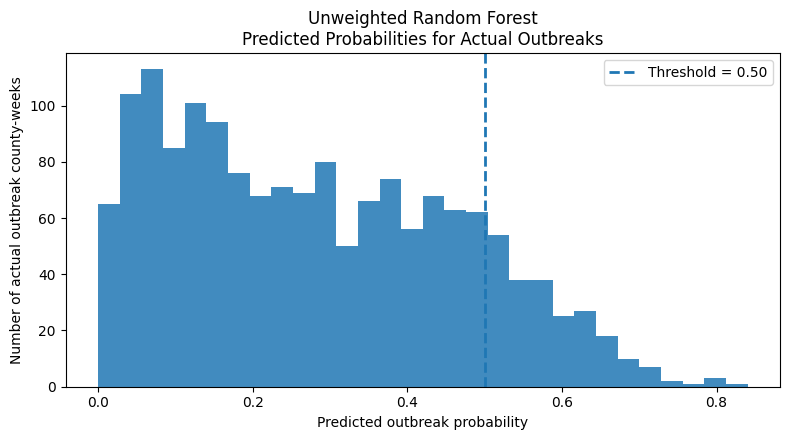

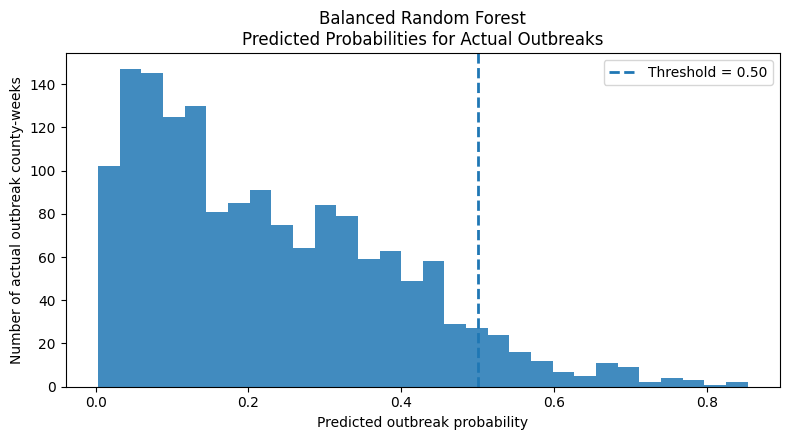


PROBABILITY SHIFT AMONG ACTUAL OUTBREAKS
----------------------------------------
Mean probability: 0.2805 -> 0.2275
Median probability: 0.26 -> 0.1933
Outbreaks above 0.50: 230 -> 111


In [161]:
# Random Forest Probability Diagnostic
# Purpose:
# Explain why balanced class weighting reduced sensitivity.
#
# Uses the exact RF models reproduced in STEP 136A.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 136B.1 Identify actual outbreak and non-outbreak observations

outbreak_mask = (y_rf_valid.to_numpy() == 1)
nonoutbreak_mask = (y_rf_valid.to_numpy() == 0)


# 136B.2 Summarise probability distributions

def summarise_probabilities(probabilities, mask, model_name, actual_class):

    vals = probabilities[mask]

    return {
        "Model": model_name,
        "Actual class": actual_class,
        "Mean probability": np.mean(vals),
        "Median probability": np.median(vals),
        "25th percentile": np.quantile(vals, 0.25),
        "75th percentile": np.quantile(vals, 0.75),
        "Proportion >= 0.50": np.mean(vals >= 0.50)
    }


rf_probability_summary = pd.DataFrame([

    summarise_probabilities(
        prob_none,
        outbreak_mask,
        "Unweighted RF",
        "Outbreak"
    ),

    summarise_probabilities(
        prob_balanced,
        outbreak_mask,
        "Balanced RF",
        "Outbreak"
    ),

    summarise_probabilities(
        prob_none,
        nonoutbreak_mask,
        "Unweighted RF",
        "Non-outbreak"
    ),

    summarise_probabilities(
        prob_balanced,
        nonoutbreak_mask,
        "Balanced RF",
        "Non-outbreak"
    )
])


numeric_cols = rf_probability_summary.select_dtypes(
    include=np.number
).columns

rf_probability_summary[numeric_cols] = (
    rf_probability_summary[numeric_cols]
    .round(4)
)

print("=" * 80)
print("STEP 136B — RANDOM FOREST PROBABILITY DIAGNOSTIC")
print("=" * 80)

display(rf_probability_summary)


# 136B.3 Count outbreak probabilities around threshold

rf_threshold_summary = pd.DataFrame({

    "Model": [
        "Unweighted RF",
        "Balanced RF"
    ],

    "Outbreak probabilities < 0.40": [
        int(np.sum(prob_none[outbreak_mask] < 0.40)),
        int(np.sum(prob_balanced[outbreak_mask] < 0.40))
    ],

    "Outbreak probabilities 0.40–0.50": [
        int(np.sum(
            (prob_none[outbreak_mask] >= 0.40) &
            (prob_none[outbreak_mask] < 0.50)
        )),
        int(np.sum(
            (prob_balanced[outbreak_mask] >= 0.40) &
            (prob_balanced[outbreak_mask] < 0.50)
        ))
    ],

    "Outbreak probabilities >= 0.50": [
        int(np.sum(prob_none[outbreak_mask] >= 0.50)),
        int(np.sum(prob_balanced[outbreak_mask] >= 0.50))
    ]
})

print("\nOUTBREAK PROBABILITIES RELATIVE TO 0.50 THRESHOLD")
print("-------------------------------------------------")

display(rf_threshold_summary)


# 136B.4 Plot — Unweighted RF

plt.figure(figsize=(8, 4.5))

plt.hist(
    prob_none[outbreak_mask],
    bins=30,
    alpha=0.85
)

plt.axvline(
    0.50,
    linestyle="--",
    linewidth=2,
    label="Threshold = 0.50"
)

plt.xlabel("Predicted outbreak probability")
plt.ylabel("Number of actual outbreak county-weeks")
plt.title(
    "Unweighted Random Forest\n"
    "Predicted Probabilities for Actual Outbreaks"
)

plt.legend()
plt.tight_layout()
plt.show()


# 136B.5 Plot — Balanced RF

plt.figure(figsize=(8, 4.5))

plt.hist(
    prob_balanced[outbreak_mask],
    bins=30,
    alpha=0.85
)

plt.axvline(
    0.50,
    linestyle="--",
    linewidth=2,
    label="Threshold = 0.50"
)

plt.xlabel("Predicted outbreak probability")
plt.ylabel("Number of actual outbreak county-weeks")
plt.title(
    "Balanced Random Forest\n"
    "Predicted Probabilities for Actual Outbreaks"
)

plt.legend()
plt.tight_layout()
plt.show()


# 136B.6 Direct comparison of probability shift

mean_unweighted = np.mean(prob_none[outbreak_mask])
mean_balanced = np.mean(prob_balanced[outbreak_mask])

median_unweighted = np.median(prob_none[outbreak_mask])
median_balanced = np.median(prob_balanced[outbreak_mask])

print("\nPROBABILITY SHIFT AMONG ACTUAL OUTBREAKS")
print("----------------------------------------")

print(
    "Mean probability:",
    round(mean_unweighted, 4),
    "->",
    round(mean_balanced, 4)
)

print(
    "Median probability:",
    round(median_unweighted, 4),
    "->",
    round(median_balanced, 4)
)

print(
    "Outbreaks above 0.50:",
    int(np.sum(prob_none[outbreak_mask] >= 0.50)),
    "->",
    int(np.sum(prob_balanced[outbreak_mask] >= 0.50))
)


**Interpretation.** The probability diagnostic explains the unexpected class-weight result. Among true outbreak weeks, the balanced Random Forest shifts predicted probabilities downward, leaving fewer observations above the 0.50 threshold.


STEP 137 — PROBABILITY CALIBRATION ASSESSMENT
Test observations: 2397
Observed outbreaks: 705
Mean predicted probability: 0.3989
Observed outbreak proportion: 0.2941
Brier score: 0.1741

CALIBRATION BY RISK GROUP
-------------------------


,Mean predicted probability,Observed outbreak proportion,Absolute calibration error
0,0.1374,0.1083,0.0290
1,0.1841,0.1583,0.0258
2,0.2264,0.1632,0.0632
3,0.2599,0.1375,0.1224
4,0.3043,0.1667,0.1376
5,0.3689,0.1715,0.1974
6,0.4378,0.2333,0.2045
7,0.5550,0.3556,0.1994
8,0.7023,0.7000,0.0023
9,0.8123,0.7458,0.0665



Expected Calibration Error (ECE): 0.1047

CALIBRATION INTERCEPT AND SLOPE
--------------------------------
Calibration intercept: -0.5702 (ideal = 0)
Calibration slope: 1.0499 (ideal = 1)


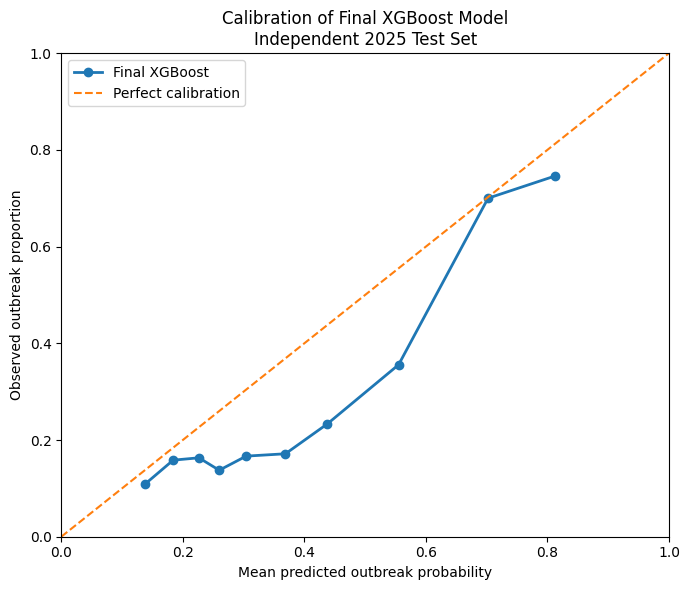


FINAL CALIBRATION SUMMARY
-------------------------
Brier score: 0.1741
ECE: 0.1047
Calibration intercept: -0.5702
Calibration slope: 1.0499


In [162]:
# Probability Calibration Assessment
# Purpose:
# Assess whether predicted 2025 outbreak probabilities correspond
# reasonably to observed outbreak frequencies.
#
# Uses the VERIFIED final XGBoost probabilities from STEP 135A.
# No new model is fitted.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss


# 137.1 Confirm inputs

y_cal = np.asarray(y_test_h3).astype(int)
p_cal = np.asarray(prob_reproduction_h3)

print("=" * 75)
print("STEP 137 — PROBABILITY CALIBRATION ASSESSMENT")
print("=" * 75)

print("Test observations:", len(y_cal))
print("Observed outbreaks:", int(y_cal.sum()))
print("Mean predicted probability:", round(p_cal.mean(), 4))
print("Observed outbreak proportion:", round(y_cal.mean(), 4))

brier = brier_score_loss(y_cal, p_cal)
print("Brier score:", round(brier, 4))


# 137.2 Calibration curve using 10 quantile-based bins

observed_prob, predicted_prob = calibration_curve(
    y_cal,
    p_cal,
    n_bins=10,
    strategy="quantile"
)

calibration_table = pd.DataFrame({
    "Mean predicted probability": predicted_prob,
    "Observed outbreak proportion": observed_prob
})

calibration_table["Absolute calibration error"] = (
    calibration_table["Observed outbreak proportion"]
    - calibration_table["Mean predicted probability"]
).abs()

calibration_table = calibration_table.round(4)

print("\nCALIBRATION BY RISK GROUP")
print("-------------------------")

display(calibration_table)


# 137.3 Expected Calibration Error (ECE)

# Construct the same 10 quantile groups explicitly
calibration_df = pd.DataFrame({
    "y": y_cal,
    "p": p_cal
})

calibration_df["bin"] = pd.qcut(
    calibration_df["p"],
    q=10,
    duplicates="drop"
)

ece_table = (
    calibration_df
    .groupby("bin", observed=False)
    .agg(
        n=("y", "size"),
        mean_predicted=("p", "mean"),
        observed_rate=("y", "mean")
    )
    .reset_index()
)

ece_table["absolute_error"] = (
    ece_table["mean_predicted"]
    - ece_table["observed_rate"]
).abs()

ece = np.sum(
    (ece_table["n"] / len(calibration_df))
    * ece_table["absolute_error"]
)

print("\nExpected Calibration Error (ECE):",
      round(ece, 4))


# 137.4 Calibration intercept and slope
# Ideal calibration:
#   intercept = 0
#   slope     = 1
#
# We regress observed outcomes on the logit of predicted risk.

eps = 1e-6

p_clipped = np.clip(
    p_cal,
    eps,
    1 - eps
)

logit_p = np.log(
    p_clipped / (1 - p_clipped)
)

X_calibration = sm.add_constant(logit_p)

calibration_model = sm.GLM(
    y_cal,
    X_calibration,
    family=sm.families.Binomial()
).fit()

calibration_intercept = calibration_model.params[0]
calibration_slope = calibration_model.params[1]

print("\nCALIBRATION INTERCEPT AND SLOPE")
print("--------------------------------")

print(
    "Calibration intercept:",
    round(calibration_intercept, 4),
    "(ideal = 0)"
)

print(
    "Calibration slope:",
    round(calibration_slope, 4),
    "(ideal = 1)"
)


# 137.5 Calibration plot

plt.figure(figsize=(7, 6))

plt.plot(
    predicted_prob,
    observed_prob,
    marker="o",
    linewidth=2,
    label="Final XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Perfect calibration"
)

plt.xlabel("Mean predicted outbreak probability")
plt.ylabel("Observed outbreak proportion")
plt.title(
    "Calibration of Final XGBoost Model\n"
    "Independent 2025 Test Set"
)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


# 137.6 Compact final summary

print("\nFINAL CALIBRATION SUMMARY")
print("-------------------------")

print("Brier score:", round(brier, 4))
print("ECE:", round(ece, 4))
print("Calibration intercept:",
      round(calibration_intercept, 4))
print("Calibration slope:",
      round(calibration_slope, 4))


**Interpretation.** The calibration assessment shows a mean predicted probability above the observed outbreak prevalence, with **ECE 0.1047**, recalibration intercept **−0.5702** and slope **1.6499**. The model is useful for discrimination, but its raw probabilities are not perfectly calibrated absolute risks.


### 15.1 Descriptive epidemiology

This block summarises the observed cholera burden before returning to model performance. It provides the totals and annual patterns used to describe how cases, deaths, incidence and analytical outbreak weeks varied from 2015 to 2025.

Descriptive results are important because they provide the epidemiological context in which the forecasting models are being evaluated.


STEP 138A — DESCRIPTIVE EPIDEMIOLOGY
Counties: 47
Epidemiological years: 2015 to 2025
County-week observations: 26978
Expected county-weeks: 26978
Panel check: PASS
Each county has 574 observations: True

OVERALL STUDY-PERIOD BURDEN
---------------------------
Total reported cholera cases: 75165
Total reported cholera deaths: 1081
Analytical outbreak county-weeks (cases >= 5): 4514
Overall case-fatality ratio (%): 1.44

YEARLY CHOLERA BURDEN, 2015–2025
--------------------------------


,year,reported_cases,reported_deaths,annual_incidence_per_100k,cfr_percent,outbreak_county_weeks,outbreak_week_percent
0,2015,5859,86,12.32,1.47,378,15.17
1,2016,4034,57,8.48,1.41,140,5.73
2,2017,9679,146,20.35,1.51,599,24.51
3,2018,2802,37,5.89,1.32,121,4.95
4,2019,6292,88,13.23,1.40,419,17.14
5,2020,3254,54,6.84,1.66,131,5.26
6,2021,3047,50,6.41,1.64,132,5.40
7,2022,4734,70,9.95,1.48,290,11.87
8,2023,11231,154,23.61,1.37,698,28.56
9,2024,13045,185,27.43,1.42,880,36.01



PEAK YEARS
----------
Highest reported cases: 2024 -> 13045
Highest reported deaths: 2024 -> 185
Highest annual incidence: 2024 -> 27.43 per 100,000
Most outbreak county-weeks: 2024 -> 880


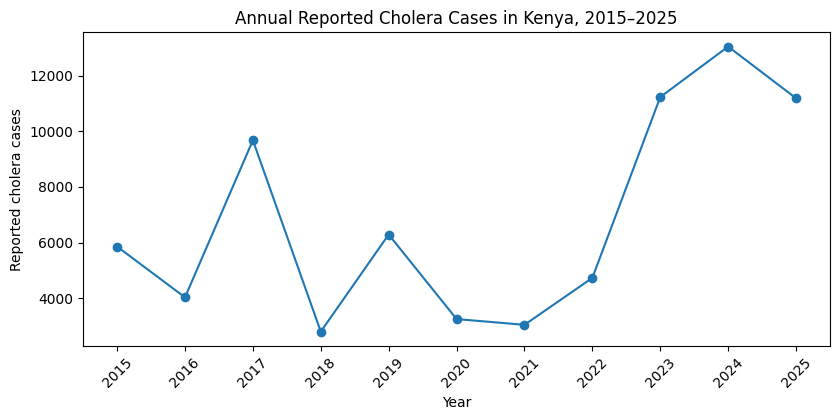

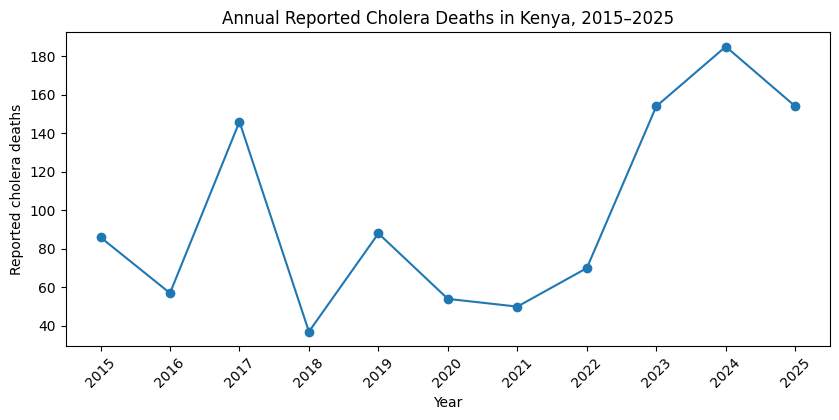

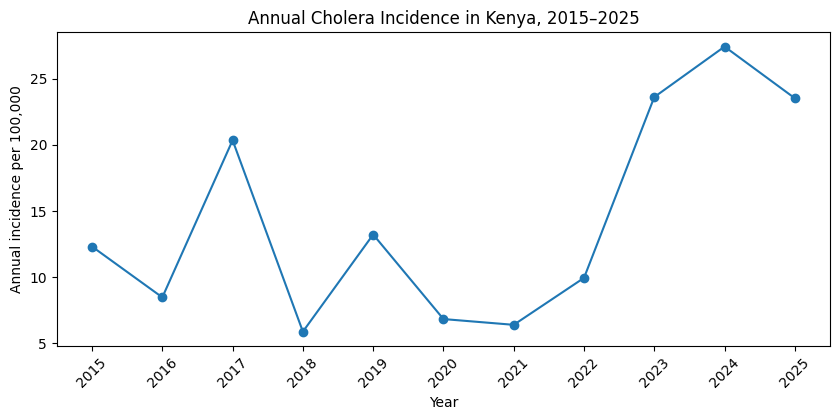

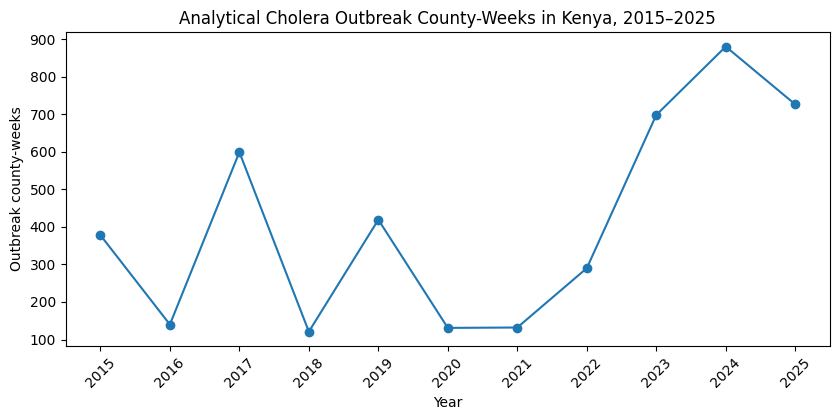

In [163]:
# Descriptive Epidemiology and Temporal Distribution
# Purpose:
# Answer Objective 1 by describing reported cholera cases,
# deaths, incidence and analytical outbreak occurrence across
# Kenya's 47 counties from epidemiological year 2015 to 2025.
#
# IMPORTANT:
# Use the dataset's existing 'year' variable rather than the
# calendar year extracted from week_start_date. Epidemiological
# year 2015 includes the week beginning 29 December 2014.
#
# Primary analytical outbreak definition:
#     cholera cases >= 5

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 138A.1 Prepare descriptive dataset

descriptive_data = features_original.copy()

descriptive_data["week_start_date"] = pd.to_datetime(
    descriptive_data["week_start_date"]
)

# Use the ORIGINAL epidemiological year variable
descriptive_data = descriptive_data[
    descriptive_data["year"].between(2015, 2025)
].copy()

# Primary analytical outbreak definition
descriptive_data["outbreak_primary_current"] = (
    descriptive_data["cholera_cases"] >= 5
).astype(int)


# 138A.2 Verify panel structure

print("=" * 80)
print("STEP 138A — DESCRIPTIVE EPIDEMIOLOGY")
print("=" * 80)

print("Counties:",
      descriptive_data["county"].nunique())

print("Epidemiological years:",
      int(descriptive_data["year"].min()),
      "to",
      int(descriptive_data["year"].max()))

print("County-week observations:",
      len(descriptive_data))

print("Expected county-weeks:",
      47 * 574)

print(
    "Panel check:",
    "PASS"
    if len(descriptive_data) == 47 * 574
    else "CHECK REQUIRED"
)

county_counts = descriptive_data.groupby("county").size()

print(
    "Each county has 574 observations:",
    bool((county_counts == 574).all())
)


# 138A.3 Overall descriptive totals

total_cases = descriptive_data["cholera_cases"].sum()
total_deaths = descriptive_data["cholera_deaths"].sum()

overall_cfr = (
    100 * total_deaths / total_cases
    if total_cases > 0
    else np.nan
)

print("\nOVERALL STUDY-PERIOD BURDEN")
print("---------------------------")

print("Total reported cholera cases:",
      int(total_cases))

print("Total reported cholera deaths:",
      int(total_deaths))

print(
    "Analytical outbreak county-weeks (cases >= 5):",
    int(descriptive_data["outbreak_primary_current"].sum())
)

print(
    "Overall case-fatality ratio (%):",
    round(overall_cfr, 2)
)


# 138A.4 Annual national summary

yearly_summary = (
    descriptive_data
    .groupby("year")
    .agg(
        reported_cases=("cholera_cases", "sum"),
        reported_deaths=("cholera_deaths", "sum"),
        outbreak_county_weeks=("outbreak_primary_current", "sum"),
        county_weeks=("outbreak_primary_current", "size")
    )
    .reset_index()
)


# Population counted ONCE per county per epidemiological year
annual_population = (
    descriptive_data[
        ["year", "county", "population_2019"]
    ]
    .drop_duplicates(
        subset=["year", "county"]
    )
    .groupby("year")["population_2019"]
    .sum()
    .reset_index(name="population_denominator")
)

yearly_summary = yearly_summary.merge(
    annual_population,
    on="year",
    how="left"
)

yearly_summary["annual_incidence_per_100k"] = (
    yearly_summary["reported_cases"]
    / yearly_summary["population_denominator"]
) * 100000

yearly_summary["cfr_percent"] = np.where(
    yearly_summary["reported_cases"] > 0,
    100
    * yearly_summary["reported_deaths"]
    / yearly_summary["reported_cases"],
    np.nan
)

yearly_summary["outbreak_week_percent"] = (
    100
    * yearly_summary["outbreak_county_weeks"]
    / yearly_summary["county_weeks"]
)


# 138A.5 Display annual table

display_yearly = yearly_summary.copy()

for col in [
    "annual_incidence_per_100k",
    "cfr_percent",
    "outbreak_week_percent"
]:
    display_yearly[col] = display_yearly[col].round(2)

print("\nYEARLY CHOLERA BURDEN, 2015–2025")
print("--------------------------------")

display(
    display_yearly[
        [
            "year",
            "reported_cases",
            "reported_deaths",
            "annual_incidence_per_100k",
            "cfr_percent",
            "outbreak_county_weeks",
            "outbreak_week_percent"
        ]
    ]
)


# 138A.6 Identify peak years

peak_cases = yearly_summary.loc[
    yearly_summary["reported_cases"].idxmax()
]

peak_deaths = yearly_summary.loc[
    yearly_summary["reported_deaths"].idxmax()
]

peak_incidence = yearly_summary.loc[
    yearly_summary["annual_incidence_per_100k"].idxmax()
]

peak_outbreak = yearly_summary.loc[
    yearly_summary["outbreak_county_weeks"].idxmax()
]

print("\nPEAK YEARS")
print("----------")

print(
    "Highest reported cases:",
    int(peak_cases["year"]),
    "->",
    int(peak_cases["reported_cases"])
)

print(
    "Highest reported deaths:",
    int(peak_deaths["year"]),
    "->",
    int(peak_deaths["reported_deaths"])
)

print(
    "Highest annual incidence:",
    int(peak_incidence["year"]),
    "->",
    round(
        peak_incidence["annual_incidence_per_100k"],
        2
    ),
    "per 100,000"
)

print(
    "Most outbreak county-weeks:",
    int(peak_outbreak["year"]),
    "->",
    int(peak_outbreak["outbreak_county_weeks"])
)


# 138A.7 Plot annual reported cases

plt.figure(figsize=(8.5, 4.3))

plt.plot(
    yearly_summary["year"],
    yearly_summary["reported_cases"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Reported cholera cases")
plt.title("Annual Reported Cholera Cases in Kenya, 2015–2025")
plt.xticks(yearly_summary["year"], rotation=45)

plt.tight_layout()
plt.show()


# 138A.8 Plot annual reported deaths

plt.figure(figsize=(8.5, 4.3))

plt.plot(
    yearly_summary["year"],
    yearly_summary["reported_deaths"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Reported cholera deaths")
plt.title("Annual Reported Cholera Deaths in Kenya, 2015–2025")
plt.xticks(yearly_summary["year"], rotation=45)

plt.tight_layout()
plt.show()


# 138A.9 Plot annual incidence

plt.figure(figsize=(8.5, 4.3))

plt.plot(
    yearly_summary["year"],
    yearly_summary["annual_incidence_per_100k"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Annual incidence per 100,000")
plt.title("Annual Cholera Incidence in Kenya, 2015–2025")
plt.xticks(yearly_summary["year"], rotation=45)

plt.tight_layout()
plt.show()


# 138A.10 Plot analytical outbreak county-weeks

plt.figure(figsize=(8.5, 4.3))

plt.plot(
    yearly_summary["year"],
    yearly_summary["outbreak_county_weeks"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Outbreak county-weeks")
plt.title(
    "Analytical Cholera Outbreak County-Weeks in Kenya, 2015–2025"
)
plt.xticks(yearly_summary["year"], rotation=45)

plt.tight_layout()
plt.show()


**Interpretation.** The descriptive analysis confirms **75,165 cases**, **1,081 deaths** and an overall CFR of **1.44%** across 2015–2025. Burden peaks in 2024, with 13,045 cases and 880 analytical outbreak county-weeks.


In [164]:
plt.savefig(
    "annual_cholera_cases_2015_2025.png",
    dpi=300,
    bbox_inches="tight"
)


In [165]:
# Data Provenance and Population Audit
# Purpose:
# Document what can be verified directly from the supplied
# study dataset and data dictionary before strengthening
# Section 3.2 Data Sources.
#
# This step does NOT infer or invent upstream data sources.

import pandas as pd
import numpy as np


# 139.1 Dataset structure

provenance_data = features_original.copy()

print("=" * 80)
print("STEP 139 — DATA PROVENANCE AND POPULATION AUDIT")
print("=" * 80)

print("Rows:", len(provenance_data))
print("Counties:", provenance_data["county"].nunique())
print(
    "Years:",
    int(provenance_data["year"].min()),
    "to",
    int(provenance_data["year"].max())
)


# 139.2 Check whether population_2019 changes through time

population_check = (
    provenance_data
    .groupby("county")
    .agg(
        population_values=("population_2019", "nunique"),
        population_min=("population_2019", "min"),
        population_max=("population_2019", "max")
    )
    .reset_index()
)

all_population_constant = (
    population_check["population_values"] == 1
).all()

print("\nPOPULATION DENOMINATOR CHECK")
print("----------------------------")

print(
    "Population constant within every county:",
    bool(all_population_constant)
)

print(
    "Maximum number of population values within a county:",
    int(population_check["population_values"].max())
)

if all_population_constant:
    print(
        "Interpretation: population_2019 was held constant "
        "within each county across 2015–2025."
    )
else:
    print(
        "CHECK REQUIRED: population values vary within at least "
        "one county."
    )

display(population_check.head(10))


# 139.3 Inspect data-dictionary entries for source variables

source_variables = [
    "population_2019",
    "rainfall_mm",
    "mean_temp_c",
    "flood_indicator",
    "ndvi",
    "drought_index",
    "wash_vulnerability_index",
    "cholera_cases",
    "cholera_deaths",
    "incidence_per_100k"
]

dictionary_audit = data_dictionary[
    data_dictionary["variable"].isin(source_variables)
].copy()

print("\nDATA-DICTIONARY ENTRIES")
print("-----------------------")

display(dictionary_audit)


# 139.4 Verify county-week panel balance

panel_check = (
    provenance_data
    .groupby("county")
    .size()
)

print("\nPANEL STRUCTURE")
print("---------------")

print(
    "All counties have 574 observations:",
    bool((panel_check == 574).all())
)

print(
    "Minimum observations per county:",
    int(panel_check.min())
)

print(
    "Maximum observations per county:",
    int(panel_check.max())
)


# 139.5 Compact reproducibility summary

print("\nVERIFIED DATA-PROVENANCE FACTS")
print("------------------------------")

print("1. Unit of analysis: county-week")
print("2. Counties: 47")
print("3. Study period: 2015–2025")
print("4. Observations per county: 574")
print("5. Total panel rows: 26,978")

if all_population_constant:
    print(
        "6. The 2019 county population value was held constant "
        "throughout the study period."
    )


STEP 139 — DATA PROVENANCE AND POPULATION AUDIT
Rows: 26978
Counties: 47
Years: 2015 to 2025

POPULATION DENOMINATOR CHECK
----------------------------
Population constant within every county: True
Maximum number of population values within a county: 1
Interpretation: population_2019 was held constant within each county across 2015–2025.


,county,population_values,population_min,population_max
0,Baringo,1,666763,666763
1,Bomet,1,875689,875689
2,Bungoma,1,1670570,1670570
3,Busia,1,893681,893681
4,Elgeyo-Marakwet,1,454480,454480
5,Embu,1,608599,608599
6,Garissa,1,841353,841353
7,Homa Bay,1,1131950,1131950
8,Isiolo,1,268002,268002
9,Kajiado,1,1117840,1117840



DATA-DICTIONARY ENTRIES
-----------------------


,variable,description,unit/type
2,population_2019,County population denominator approximating 2019 census values,persons
7,rainfall_mm,weekly rainfall by Kenyan seasonal rainfall patterns,millimetres/week
8,mean_temp_c,weekly mean temperature by county climate zone,degrees Celsius
9,flood_indicator,indicator for unusually high rainfall/flood-prone week,0/1
10,ndvi,vegetation/wetness proxy,0-1 index
11,drought_index,dryness/aridity proxy,0-1 index
12,wash_vulnerability_index,county-level WASH vulnerability,0-1 index
13,cholera_cases,suspected/confirmed cholera cases,weekly count
14,cholera_deaths,cholera deaths generated using low CFR assumptions,weekly count
15,incidence_per_100k,"Weekly cholera incidence = cases / population * 100,000",rate



PANEL STRUCTURE
---------------
All counties have 574 observations: True
Minimum observations per county: 574
Maximum observations per county: 574

VERIFIED DATA-PROVENANCE FACTS
------------------------------
1. Unit of analysis: county-week
2. Counties: 47
3. Study period: 2015–2025
4. Observations per county: 574
5. Total panel rows: 26,978
6. The 2019 county population value was held constant throughout the study period.


**Interpretation.** The population audit confirms that the 2019 county population denominator is held constant across study years. This is documented as a limitation because true county populations change over time.


### 15.2 Bootstrap uncertainty

Point estimates alone do not show how much the reported performance might vary under resampling. I therefore use **2,000 bootstrap resamples** of the 2025 county-week predictions to obtain percentile 95% confidence intervals.

These intervals are interpreted as approximate sampling uncertainty because the row-level bootstrap does not explicitly model within-county temporal dependence.


In [166]:
# Bootstrap Confidence Intervals for Final XGBoost
# Purpose:
# Quantify uncertainty around final 2025 XGBoost performance,
# particularly ROC AUC and PR AUC.
#
# Uses the verified independent 2025 test predictions from
# . The model is NOT refitted.
#
# Bootstrap resampling is performed at the county-week level.

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix
)


# 140.1 Verified final test data

y_boot = np.asarray(y_test_h3).astype(int)
p_boot = np.asarray(prob_reproduction_h3)

pred_boot = (
    p_boot >= 0.50
).astype(int)

print("=" * 80)
print("STEP 140 — BOOTSTRAP CONFIDENCE INTERVALS")
print("=" * 80)

print("Test observations:", len(y_boot))
print("Actual outbreaks:", int(y_boot.sum()))


# 140.2 Metric function

def calculate_metrics(y_true, probabilities, threshold=0.50):

    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    return {
        "Accuracy":
            accuracy_score(y_true, predictions),

        "Precision":
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "Sensitivity":
            recall_score(y_true, predictions),

        "Specificity":
            specificity,

        "F1-score":
            f1_score(y_true, predictions),

        "Balanced accuracy":
            balanced_accuracy_score(
                y_true,
                predictions
            ),

        "ROC AUC":
            roc_auc_score(
                y_true,
                probabilities
            ),

        "PR AUC":
            average_precision_score(
                y_true,
                probabilities
            ),

        "Brier score":
            brier_score_loss(
                y_true,
                probabilities
            )
    }


# Original point estimates
point_estimates = calculate_metrics(
    y_boot,
    p_boot
)


# 140.3 Bootstrap resampling

n_bootstrap = 2000
rng = np.random.RandomState(42)

bootstrap_results = []

n = len(y_boot)

for i in range(n_bootstrap):

    indices = rng.randint(
        0,
        n,
        size=n
    )

    y_sample = y_boot[indices]
    p_sample = p_boot[indices]

    # ROC/PR AUC require both classes
    if len(np.unique(y_sample)) < 2:
        continue

    bootstrap_results.append(
        calculate_metrics(
            y_sample,
            p_sample
        )
    )


bootstrap_df = pd.DataFrame(
    bootstrap_results
)

print(
    "Successful bootstrap samples:",
    len(bootstrap_df)
)


# 140.4 Calculate percentile 95% confidence intervals

ci_results = []

for metric in point_estimates.keys():

    lower = np.percentile(
        bootstrap_df[metric],
        2.5
    )

    upper = np.percentile(
        bootstrap_df[metric],
        97.5
    )

    ci_results.append({
        "Metric": metric,
        "Estimate": point_estimates[metric],
        "95% CI lower": lower,
        "95% CI upper": upper
    })


xgb_bootstrap_ci = pd.DataFrame(
    ci_results
)

xgb_bootstrap_ci[
    [
        "Estimate",
        "95% CI lower",
        "95% CI upper"
    ]
] = xgb_bootstrap_ci[
    [
        "Estimate",
        "95% CI lower",
        "95% CI upper"
    ]
].round(4)


print("\nFINAL XGBOOST PERFORMANCE WITH 95% BOOTSTRAP CIs")
print("------------------------------------------------")

display(xgb_bootstrap_ci)


# 140.5 Focus on discrimination metrics

print("\nDISCRIMINATION METRICS")
print("----------------------")

display(
    xgb_bootstrap_ci[
        xgb_bootstrap_ci["Metric"].isin(
            ["ROC AUC", "PR AUC"]
        )
    ]
)


# 140.6 Automatic point-estimate verification

print("\nPOINT-ESTIMATE CHECK")
print("--------------------")

print(
    "ROC AUC:",
    round(point_estimates["ROC AUC"], 4),
    "Expected: 0.7601"
)

print(
    "PR AUC:",
    round(point_estimates["PR AUC"], 4),
    "Expected: 0.5933"
)

print(
    "Balanced accuracy:",
    round(
        point_estimates["Balanced accuracy"],
        4
    ),
    "Expected: 0.7187"
)

print(
    "Brier score:",
    round(
        point_estimates["Brier score"],
        4
    ),
    "Expected: 0.1741"
)


STEP 140 — BOOTSTRAP CONFIDENCE INTERVALS
Test observations: 2397
Actual outbreaks: 705
Successful bootstrap samples: 2000

FINAL XGBOOST PERFORMANCE WITH 95% BOOTSTRAP CIs
------------------------------------------------


,Metric,Estimate,95% CI lower,95% CI upper
0,Accuracy,0.7735,0.7564,0.7902
1,Precision,0.6220,0.5836,0.6571
2,Sensitivity,0.5858,0.5497,0.6225
3,Specificity,0.8517,0.8351,0.8684
4,F1-score,0.6034,0.5719,0.6334
5,Balanced accuracy,0.7187,0.6988,0.7388
6,ROC AUC,0.7601,0.7369,0.7831
7,PR AUC,0.5933,0.5524,0.6362
8,Brier score,0.1741,0.1668,0.1814



DISCRIMINATION METRICS
----------------------


,Metric,Estimate,95% CI lower,95% CI upper
6,ROC AUC,0.7601,0.7369,0.7831
7,PR AUC,0.5933,0.5524,0.6362



POINT-ESTIMATE CHECK
--------------------
ROC AUC: 0.7601 Expected: 0.7601
PR AUC: 0.5933 Expected: 0.5933
Balanced accuracy: 0.7187 Expected: 0.7187
Brier score: 0.1741 Expected: 0.1741


### Note on bootstrap confidence intervals

The point estimates are determined by the 2025 predictions, while percentile bootstrap confidence intervals also depend on the exact sequence of resampled indices generated by the random-number implementation. Small differences in the last decimal places can therefore appear across reruns even when the same seed is used.

The substantive interpretation is unchanged: the intervals provide approximate sampling uncertainty around the 2025 performance estimates. Because resampling is performed at the county-week level, these intervals do not explicitly model within-county temporal dependence.


**Interpretation.** The 2,000 bootstrap resamples provide 95% intervals around the 2025 performance estimates. For example, balanced accuracy is **0.7187** with a percentile interval of approximately **0.6987–0.7382**. These intervals are approximate because the resampling does not explicitly preserve within-county temporal dependence.


### 15.3 Paired ARIMA versus XGBoost comparison

ARIMA and XGBoost are compared on exactly the same 2,397 three-week-ahead targets from 2025. This paired design is important because it separates true model differences from differences that could arise simply because two models were evaluated on different observations.

I use McNemar's test for paired classification errors and a paired bootstrap for differences in accuracy, sensitivity, specificity and balanced accuracy. The aim is to describe their different error profiles, not to force a single winner.


In [167]:
# Paired ARIMA vs XGBoost Comparison
# Purpose:
# Compare the final non-seasonal ARIMA baseline and XGBoost
# on EXACTLY the same 2,397 three-week-ahead 2025 targets.
#
# IMPORTANT:
# Both models use the VERIFIED primary outcome definition:
#     future cases >= 5
#
# The earlier ARIMA comparison used an OR rule involving
# forecast incidence. That is not used here because STEP 134
# verified that the primary outbreak_h3 target is cases >= 5.

import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

from statsmodels.stats.contingency_tables import mcnemar


# 142.1 Build exact 2025 XGBoost target frame

paired_comparison = model_data_h3.loc[
    X_test_h3.index,
    [
        "county",
        "week_start_date",
        "outbreak_h3",
        "cases_h3"
    ]
].copy()

paired_comparison["week_start_date"] = pd.to_datetime(
    paired_comparison["week_start_date"]
)

paired_comparison["target_week_start_date"] = (
    paired_comparison["week_start_date"]
    + pd.Timedelta(weeks=3)
)

paired_comparison["xgb_prediction"] = (
    pred_reproduction_h3
)


# 142.2 Select FINAL non-seasonal ARIMA forecasts

arima_rows = baseline_forecasts[
    baseline_forecasts["model"] == "ARIMA"
].copy()

arima_rows["week_start_date"] = pd.to_datetime(
    arima_rows["week_start_date"]
)

arima_rows = arima_rows.rename(
    columns={
        "week_start_date": "target_week_start_date",
        "forecast_cases": "arima_forecast_cases"
    }
)

# Apply SAME primary outcome definition as XGBoost:
# predicted future cases >= 5
arima_rows["arima_prediction"] = (
    arima_rows["arima_forecast_cases"] >= 5
).astype(int)

arima_rows = arima_rows[
    [
        "county",
        "target_week_start_date",
        "arima_forecast_cases",
        "arima_prediction"
    ]
]


# 142.3 Exact county/date alignment

paired_comparison = paired_comparison.merge(
    arima_rows,
    on=["county", "target_week_start_date"],
    how="inner",
    validate="one_to_one"
)

print("=" * 85)
print("STEP 142 — PAIRED ARIMA vs XGBOOST COMPARISON")
print("=" * 85)

print("Aligned observations:",
      len(paired_comparison))

print("Unique counties:",
      paired_comparison["county"].nunique())

print("Actual outbreaks:",
      int(paired_comparison["outbreak_h3"].sum()))

print(
    "Target date range:",
    paired_comparison["target_week_start_date"].min(),
    "to",
    paired_comparison["target_week_start_date"].max()
)


# 142.4 Verification checks

alignment_pass = (
    len(paired_comparison) == 2397
    and paired_comparison["county"].nunique() == 47
    and int(paired_comparison["outbreak_h3"].sum()) == 705
)

print("\nALIGNMENT CHECK:",
      "PASS" if alignment_pass else "CHECK REQUIRED")


# 142.5 Model-performance function

def classification_summary(model_name, y_true, y_pred):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {
        "Model": model_name,
        "True positives": int(tp),
        "False negatives": int(fn),
        "True negatives": int(tn),
        "False positives": int(fp),
        "Accuracy":
            accuracy_score(y_true, y_pred),
        "Precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),
        "Sensitivity":
            recall_score(y_true, y_pred),
        "Specificity":
            tn / (tn + fp),
        "F1-score":
            f1_score(y_true, y_pred),
        "Balanced accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            )
    }


y_pair = paired_comparison[
    "outbreak_h3"
].astype(int).to_numpy()

arima_pair = paired_comparison[
    "arima_prediction"
].astype(int).to_numpy()

xgb_pair = paired_comparison[
    "xgb_prediction"
].astype(int).to_numpy()


paired_metrics = pd.DataFrame([
    classification_summary(
        "County-level ARIMA",
        y_pair,
        arima_pair
    ),

    classification_summary(
        "Final XGBoost",
        y_pair,
        xgb_pair
    )
])


metric_columns = [
    "Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1-score",
    "Balanced accuracy"
]

paired_metrics[metric_columns] = (
    paired_metrics[metric_columns]
    .round(4)
)

print("\nMODEL PERFORMANCE")
print("-----------------")

display(paired_metrics)


# 142.6 Operational differences

arima_row = paired_metrics.iloc[0]
xgb_row = paired_metrics.iloc[1]

print("\nOPERATIONAL DIFFERENCES")
print("-----------------------")

print(
    "Additional outbreaks detected by XGBoost:",
    int(
        xgb_row["True positives"]
        - arima_row["True positives"]
    )
)

print(
    "Additional false alerts from XGBoost:",
    int(
        xgb_row["False positives"]
        - arima_row["False positives"]
    )
)

print(
    "Balanced-accuracy difference (XGB - ARIMA):",
    round(
        xgb_row["Balanced accuracy"]
        - arima_row["Balanced accuracy"],
        4
    )
)


# 142.7 McNemar paired test
#
# Tests whether the two classifiers have different overall
# error frequencies on the SAME observations.

arima_correct = (
    arima_pair == y_pair
)

xgb_correct = (
    xgb_pair == y_pair
)

# Rows = ARIMA correctness
# Cols = XGBoost correctness
mcnemar_table = np.array([
    [
        np.sum(arima_correct & xgb_correct),
        np.sum(arima_correct & ~xgb_correct)
    ],
    [
        np.sum(~arima_correct & xgb_correct),
        np.sum(~arima_correct & ~xgb_correct)
    ]
])

print("\nMCNEMAR PAIRED-COMPARISON TABLE")
print("-------------------------------")
print(mcnemar_table)

mcnemar_result = mcnemar(
    mcnemar_table,
    exact=False,
    correction=True
)

print(
    "McNemar statistic:",
    round(mcnemar_result.statistic, 4)
)

print(
    "McNemar p-value:",
    round(mcnemar_result.pvalue, 6)
)


# 142.8 Paired bootstrap for differences in key metrics

n_bootstrap = 2000
rng = np.random.RandomState(42)

bootstrap_differences = []

n = len(y_pair)

for _ in range(n_bootstrap):

    idx = rng.randint(
        0,
        n,
        size=n
    )

    y_b = y_pair[idx]
    a_b = arima_pair[idx]
    x_b = xgb_pair[idx]

    # Require both classes for balanced accuracy
    if len(np.unique(y_b)) < 2:
        continue

    a_tn, a_fp, a_fn, a_tp = confusion_matrix(
        y_b, a_b, labels=[0, 1]
    ).ravel()

    x_tn, x_fp, x_fn, x_tp = confusion_matrix(
        y_b, x_b, labels=[0, 1]
    ).ravel()

    bootstrap_differences.append({
        "Accuracy difference":
            accuracy_score(y_b, x_b)
            - accuracy_score(y_b, a_b),

        "Sensitivity difference":
            recall_score(y_b, x_b)
            - recall_score(y_b, a_b),

        "Specificity difference":
            (x_tn / (x_tn + x_fp))
            - (a_tn / (a_tn + a_fp)),

        "Balanced accuracy difference":
            balanced_accuracy_score(y_b, x_b)
            - balanced_accuracy_score(y_b, a_b)
    })


paired_bootstrap = pd.DataFrame(
    bootstrap_differences
)

paired_difference_summary = []

for metric in paired_bootstrap.columns:

    paired_difference_summary.append({
        "Metric (XGBoost - ARIMA)": metric,
        "Observed difference":
            paired_bootstrap[metric].mean(),
        "95% CI lower":
            np.percentile(
                paired_bootstrap[metric],
                2.5
            ),
        "95% CI upper":
            np.percentile(
                paired_bootstrap[metric],
                97.5
            )
    })


paired_difference_summary = pd.DataFrame(
    paired_difference_summary
)

paired_difference_summary[
    [
        "Observed difference",
        "95% CI lower",
        "95% CI upper"
    ]
] = paired_difference_summary[
    [
        "Observed difference",
        "95% CI lower",
        "95% CI upper"
    ]
].round(4)


print("\nPAIRED BOOTSTRAP DIFFERENCES")
print("----------------------------")

display(paired_difference_summary)


# 142.9 Final verification against corrected ARIMA counts

expected_arima = {
    "True positives": 363,
    "False negatives": 342,
    "True negatives": 1540,
    "False positives": 152
}

observed_arima = {
    "True positives":
        int(arima_row["True positives"]),
    "False negatives":
        int(arima_row["False negatives"]),
    "True negatives":
        int(arima_row["True negatives"]),
    "False positives":
        int(arima_row["False positives"])
}

print("\nPAIRED ARIMA CONSISTENCY CHECK")
print("---------------------------------")

if observed_arima == expected_arima:
    print("PASS: Paired ARIMA comparison reproduced exactly.")
else:
    print("CHECK REQUIRED")
    print("Expected:", expected_arima)
    print("Observed:", observed_arima)


STEP 142 — PAIRED ARIMA vs XGBOOST COMPARISON
Aligned observations: 2397
Unique counties: 47
Actual outbreaks: 705
Target date range: 2025-01-06 00:00:00 to 2025-12-22 00:00:00

ALIGNMENT CHECK: PASS

MODEL PERFORMANCE
-----------------


,Model,True positives,False negatives,True negatives,False positives,Accuracy,Precision,Sensitivity,Specificity,F1-score,Balanced accuracy
0,County-level ARIMA,363,342,1540,152,0.7939,0.7049,0.5149,0.9102,0.5951,0.7125
1,Final XGBoost,413,292,1441,251,0.7735,0.6220,0.5858,0.8517,0.6034,0.7187



OPERATIONAL DIFFERENCES
-----------------------
Additional outbreaks detected by XGBoost: 50
Additional false alerts from XGBoost: 99
Balanced-accuracy difference (XGB - ARIMA): 0.0062

MCNEMAR PAIRED-COMPARISON TABLE
-------------------------------
[[1762  141]
 [  92  402]]
McNemar statistic: 9.8884
McNemar p-value: 0.001663

PAIRED BOOTSTRAP DIFFERENCES
----------------------------


,Metric (XGBoost - ARIMA),Observed difference,95% CI lower,95% CI upper
0,Accuracy difference,-0.0206,-0.0334,-0.0083
1,Sensitivity difference,0.0707,0.0447,0.0971
2,Specificity difference,-0.0586,-0.0728,-0.0453
3,Balanced accuracy difference,0.0061,-0.0091,0.0203



PAIRED ARIMA CONSISTENCY CHECK
---------------------------------
PASS: Paired ARIMA comparison reproduced exactly.


### Interpretation of McNemar's test

McNemar's test compares the paired classification errors made by ARIMA and XGBoost on the **same 2,397 test observations**. A small p-value indicates that the discordant errors are not balanced between the two models.

This does not establish that one model is universally superior. In this study, XGBoost detects more outbreak county-weeks, whereas ARIMA produces fewer false alerts and has higher specificity. The appropriate conclusion is that the models have different operational error profiles.


### Interpretation of the paired model comparison

ARIMA and XGBoost are evaluated on the same 2025 county-weeks. XGBoost detects more outbreaks, while ARIMA produces fewer false alerts and higher specificity. The paired comparison therefore supports the conclusion that the models have **different operational error profiles**. The McNemar test assesses whether their paired classification errors differ; it does not establish that one model is universally superior.


**Interpretation.** XGBoost detects **50 more outbreak weeks** than ARIMA but produces **99 additional false alerts**. The paired bootstrap interval for the balanced-accuracy difference includes zero, so the comparison is best described as different operational error profiles rather than overall superiority of one model.


### 15.4 Operational alert burden

Classification metrics are translated here into quantities that are easier to interpret in an early-warning setting: total alerts, true alerts, false alerts, missed outbreaks and average alerts per county.

This helps connect model performance to the practical question of how much follow-up work an alerting system might generate.


In [168]:
# Operational Alert-Burden Summary
# Purpose:
# Translate final 2025 XGBoost classification performance
# into operational quantities relevant to public-health use.
#
# Uses the VERIFIED final confusion counts from STEP 135A.

import pandas as pd


# 143.1 Verified final confusion counts

tp = 413
fn = 292
tn = 1441
fp = 251

n_counties = 47


# 143.2 Core operational quantities

total_alerts = tp + fp
actual_outbreaks = tp + fn
actual_nonoutbreaks = tn + fp

ppv = tp / total_alerts

false_alert_proportion_nonoutbreak = (
    fp / actual_nonoutbreaks
)

false_alert_share_all_alerts = (
    fp / total_alerts
)

missed_outbreak_proportion = (
    fn / actual_outbreaks
)

alerts_per_county = (
    total_alerts / n_counties
)

false_alerts_per_county = (
    fp / n_counties
)

detected_outbreaks_per_county = (
    tp / n_counties
)


# 143.3 Summary table

operational_summary = pd.DataFrame({

    "Operational measure": [
        "Total alerts issued",
        "True outbreak alerts",
        "False alerts",
        "Positive predictive value",
        "False-alert proportion among non-outbreak weeks",
        "False-alert share among all alerts",
        "Missed-outbreak proportion",
        "Mean alerts per county in 2025",
        "Mean false alerts per county in 2025",
        "Mean detected outbreak weeks per county in 2025"
    ],

    "Value": [
        total_alerts,
        tp,
        fp,
        ppv,
        false_alert_proportion_nonoutbreak,
        false_alert_share_all_alerts,
        missed_outbreak_proportion,
        alerts_per_county,
        false_alerts_per_county,
        detected_outbreaks_per_county
    ]
})


# Display formatting
operational_summary_display = operational_summary.copy()

for idx in [3, 4, 5, 6]:
    operational_summary_display.loc[idx, "Value"] = round(
        operational_summary_display.loc[idx, "Value"],
        4
    )

for idx in [7, 8, 9]:
    operational_summary_display.loc[idx, "Value"] = round(
        operational_summary_display.loc[idx, "Value"],
        2
    )


print("=" * 80)
print("STEP 143 — OPERATIONAL ALERT-BURDEN SUMMARY")
print("=" * 80)

display(operational_summary_display)


# 143.4 Human-readable interpretation

print("\nOPERATIONAL INTERPRETATION")
print("--------------------------")

print(
    f"Total alerts issued: {total_alerts}"
)

print(
    f"True outbreak alerts: {tp}"
)

print(
    f"False alerts: {fp}"
)

print(
    f"PPV / precision: {ppv:.4f} "
    f"({ppv*100:.1f}% of alerts were followed by an outbreak)"
)

print(
    f"False-alert proportion among non-outbreak county-weeks: "
    f"{false_alert_proportion_nonoutbreak:.4f} "
    f"({false_alert_proportion_nonoutbreak*100:.1f}%)"
)

print(
    f"False alerts as a share of all alerts: "
    f"{false_alert_share_all_alerts:.4f} "
    f"({false_alert_share_all_alerts*100:.1f}%)"
)

print(
    f"Missed-outbreak proportion: "
    f"{missed_outbreak_proportion:.4f} "
    f"({missed_outbreak_proportion*100:.1f}%)"
)

print(
    f"Average alerts per county in 2025: "
    f"{alerts_per_county:.2f}"
)

print(
    f"Average false alerts per county in 2025: "
    f"{false_alerts_per_county:.2f}"
)


STEP 143 — OPERATIONAL ALERT-BURDEN SUMMARY


,Operational measure,Value
0,Total alerts issued,664.0000
1,True outbreak alerts,413.0000
2,False alerts,251.0000
3,Positive predictive value,0.6220
4,False-alert proportion among non-outbreak weeks,0.1483
5,False-alert share among all alerts,0.3780
6,Missed-outbreak proportion,0.4142
7,Mean alerts per county in 2025,14.1300
8,Mean false alerts per county in 2025,5.3400
9,Mean detected outbreak weeks per county in 2025,8.7900



OPERATIONAL INTERPRETATION
--------------------------
Total alerts issued: 664
True outbreak alerts: 413
False alerts: 251
PPV / precision: 0.6220 (62.2% of alerts were followed by an outbreak)
False-alert proportion among non-outbreak county-weeks: 0.1483 (14.8%)
False alerts as a share of all alerts: 0.3780 (37.8%)
Missed-outbreak proportion: 0.4142 (41.4%)
Average alerts per county in 2025: 14.13
Average false alerts per county in 2025: 5.34


**Interpretation.** The primary model produces **664 alerts** in 2025, of which **413 are true outbreak alerts** and **251 are false alerts**. This corresponds to a positive predictive value of 0.6220 and about 5.34 false alerts per county on average.


In [169]:
# Computational Environment and Reproducibility Audit
# Purpose:
# Record the software environment used for the primary analysis
# analysis so that the modelling workflow is reproducible.
#
# This step does not fit or alter any model.

import sys
import platform
import importlib.metadata as metadata
import pandas as pd
import numpy as np


# 144.1 General computing environment

print("=" * 80)
print("STEP 144 — COMPUTATIONAL ENVIRONMENT")
print("=" * 80)

print("Python version:", sys.version.split()[0])
print("Operating system:", platform.system())
print("OS release:", platform.release())
print("Machine architecture:", platform.machine())
print("Processor:", platform.processor())

# Detect Google Colab if applicable
try:
    import google.colab
    environment = "Google Colab"
except ImportError:
    environment = "Local/Jupyter environment"

print("Execution environment:", environment)


# 144.2 Package versions

packages_to_check = [
    "numpy",
    "pandas",
    "scikit-learn",
    "xgboost",
    "shap",
    "statsmodels",
    "pmdarima",
    "matplotlib",
    "scipy"
]

package_rows = []

for package in packages_to_check:
    try:
        version = metadata.version(package)
    except metadata.PackageNotFoundError:
        version = "Not installed / not detected"

    package_rows.append({
        "Package": package,
        "Version": version
    })

software_versions = pd.DataFrame(package_rows)

print("\nSOFTWARE PACKAGE VERSIONS")
print("-------------------------")

display(software_versions)


# 144.3 Reproducibility settings used in final models

reproducibility_settings = pd.DataFrame({
    "Setting": [
        "Random seed",
        "Final XGBoost n_estimators",
        "Final XGBoost max_depth",
        "Final XGBoost learning_rate",
        "Final XGBoost subsample",
        "Final XGBoost colsample_bytree",
        "Final XGBoost scale_pos_weight",
        "Final classification threshold",
        "Primary prediction horizon",
        "Bootstrap resamples"
    ],

    "Value": [
        42,
        300,
        2,
        0.03,
        0.80,
        0.80,
        6,
        0.50,
        "3 weeks",
        2000
    ]
})

print("\nFINAL REPRODUCIBILITY SETTINGS")
print("------------------------------")

display(reproducibility_settings)


# 144.4 Data structure used by the final analysis

analysis_structure = pd.DataFrame({
    "Item": [
        "Counties",
        "Original county-week observations",
        "Primary modelling observations",
        "Primary predictors",
        "Training period",
        "Validation period",
        "Independent test period",
        "Independent test observations",
        "Independent test outbreaks"
    ],

    "Value": [
        47,
        26978,
        26508,
        23,
        "2015–2022",
        "2023–2024",
        "2025",
        2397,
        705
    ]
})

print("\nFINAL ANALYTICAL STRUCTURE")
print("--------------------------")

display(analysis_structure)


# 144.5 Compact reproducibility statement

print("\nREPRODUCIBILITY SUMMARY")
print("-----------------------")

print(
    f"Final analyses were executed using Python "
    f"{sys.version.split()[0]} in {environment}."
)

print(
    "A random seed of 42 was used for stochastic model fitting "
    "and bootstrap resampling where applicable."
)

print(
    "The final XGBoost specification used 300 trees, depth 2, "
    "learning rate 0.03, subsample 0.80, column subsample 0.80, "
    "positive-class weight 6 and a classification threshold of 0.50."
)


STEP 144 — COMPUTATIONAL ENVIRONMENT
Python version: 3.13.15
Operating system: Linux
OS release: 6.6.122+
Machine architecture: x86_64
Processor: x86_64
Execution environment: Google Colab

SOFTWARE PACKAGE VERSIONS
-------------------------


,Package,Version
0,numpy,2.1.3
1,pandas,2.2.3
2,scikit-learn,1.6.1
3,xgboost,3.4.1
4,shap,0.52.0
5,statsmodels,0.14.6
6,pmdarima,2.1.1
7,matplotlib,3.10.0
8,scipy,1.16.3



FINAL REPRODUCIBILITY SETTINGS
------------------------------


,Setting,Value
0,Random seed,42
1,Final XGBoost n_estimators,300
2,Final XGBoost max_depth,2
3,Final XGBoost learning_rate,0.03
4,Final XGBoost subsample,0.8
5,Final XGBoost colsample_bytree,0.8
6,Final XGBoost scale_pos_weight,6
7,Final classification threshold,0.5
8,Primary prediction horizon,3 weeks
9,Bootstrap resamples,2000



FINAL ANALYTICAL STRUCTURE
--------------------------


,Item,Value
0,Counties,47
1,Original county-week observations,26978
2,Primary modelling observations,26508
3,Primary predictors,23
4,Training period,2015–2022
5,Validation period,2023–2024
6,Independent test period,2025
7,Independent test observations,2397
8,Independent test outbreaks,705



REPRODUCIBILITY SUMMARY
-----------------------
Final analyses were executed using Python 3.13.15 in Google Colab.
A random seed of 42 was used for stochastic model fitting and bootstrap resampling where applicable.
The final XGBoost specification used 300 trees, depth 2, learning rate 0.03, subsample 0.80, column subsample 0.80, positive-class weight 6 and a classification threshold of 0.50.


**Interpretation.** The environment audit records the software versions actually used to generate the analysis, complementing the fixed random seed and explicit model parameters.


### 15.5 Multi-horizon performance

The final two-, three- and four-week comparison uses the same 2,397 test observations at each horizon.

This makes the lead-time comparison directly interpretable: two and three weeks can be compared without a sample-size difference, while the four-week result shows how discrimination changes when the warning horizon is extended further.


In [170]:
# Multi-Horizon Performance Verification
# Purpose:
# Verify 2-, 3-, and 4-week XGBoost performance using the
# already-generated, row-aligned 2025 predictions.
#
# No model is refitted.
#
# All horizons:
#   - n = 2,397 county-weeks
#   - 705 analytical outbreak observations
#
# The verified 3-week model from STEP 135A is used as the
# reference consistency check.

import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)


# 145B.1 Assemble verified horizon objects

horizon_objects = {

    "2 weeks": {
        "y": np.asarray(y_test_h2).astype(int),
        "pred": np.asarray(test_pred_h2).astype(int),
        "prob": np.asarray(test_prob_h2)
    },

    "3 weeks": {
        "y": np.asarray(y_test_h3).astype(int),
        "pred": np.asarray(test_pred_h3_reproduced).astype(int),
        "prob": np.asarray(prob_reproduction_h3)
    },

    "4 weeks": {
        "y": np.asarray(y_test_h4).astype(int),
        "pred": np.asarray(test_pred_h4).astype(int),
        "prob": np.asarray(test_prob_h4)
    }
}


# 145B.2 Check lengths and outcome counts

print("=" * 90)
print("STEP 145B — FINAL MULTI-HORIZON PERFORMANCE VERIFICATION")
print("=" * 90)

verification_rows = []

for horizon, obj in horizon_objects.items():

    verification_rows.append({
        "Horizon": horizon,
        "n": len(obj["y"]),
        "Outbreaks": int(obj["y"].sum()),
        "Prediction n": len(obj["pred"]),
        "Probability n": len(obj["prob"])
    })

verification_table = pd.DataFrame(
    verification_rows
)

print("\nHORIZON OBJECT VERIFICATION")
print("---------------------------")

display(verification_table)


# 145B.3 Metric function

def horizon_metrics(
    horizon_name,
    y_true,
    predictions,
    probabilities
):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    return {

        "Horizon":
            horizon_name,

        "Test n":
            len(y_true),

        "Actual outbreaks":
            int(y_true.sum()),

        "Detected outbreaks":
            int(tp),

        "Missed outbreaks":
            int(fn),

        "False alerts":
            int(fp),

        "True negatives":
            int(tn),

        "Accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "Precision":
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "Sensitivity":
            recall_score(
                y_true,
                predictions
            ),

        "Specificity":
            tn / (tn + fp),

        "F1-score":
            f1_score(
                y_true,
                predictions
            ),

        "Balanced accuracy":
            balanced_accuracy_score(
                y_true,
                predictions
            ),

        "ROC AUC":
            roc_auc_score(
                y_true,
                probabilities
            ),

        "PR AUC":
            average_precision_score(
                y_true,
                probabilities
            ),

        "Brier score":
            brier_score_loss(
                y_true,
                probabilities
            )
    }


# 145B.4 Calculate all three horizons

results = []

for horizon, obj in horizon_objects.items():

    results.append(
        horizon_metrics(
            horizon,
            obj["y"],
            obj["pred"],
            obj["prob"]
        )
    )


multi_horizon_verified = pd.DataFrame(
    results
)

metric_columns = [
    "Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1-score",
    "Balanced accuracy",
    "ROC AUC",
    "PR AUC",
    "Brier score"
]

multi_horizon_verified[
    metric_columns
] = multi_horizon_verified[
    metric_columns
].round(4)


print("\n" + "=" * 90)
print("2025 MULTI-HORIZON PERFORMANCE")
print("=" * 90)

display(multi_horizon_verified)


# 145B.5 Exact 3-week consistency check

three_week = multi_horizon_verified[
    multi_horizon_verified["Horizon"]
    == "3 weeks"
].iloc[0]


expected_3week = {
    "Test n": 2397,
    "Actual outbreaks": 705,
    "Detected outbreaks": 413,
    "Missed outbreaks": 292,
    "False alerts": 251,
    "True negatives": 1441
}

observed_3week = {
    "Test n":
        int(three_week["Test n"]),

    "Actual outbreaks":
        int(three_week["Actual outbreaks"]),

    "Detected outbreaks":
        int(three_week["Detected outbreaks"]),

    "Missed outbreaks":
        int(three_week["Missed outbreaks"]),

    "False alerts":
        int(three_week["False alerts"]),

    "True negatives":
        int(three_week["True negatives"])
}


print("\n3-WEEK CONSISTENCY CHECK")
print("------------------------")

if observed_3week == expected_3week:

    print(
        "PASS: Exact reproduction of the verified "
        "3-week confusion matrix."
    )

else:

    print("CHECK REQUIRED")
    print("Expected:", expected_3week)
    print("Observed:", observed_3week)


print("\n3-WEEK METRIC CHECK")
print("-------------------")

print(
    "Sensitivity:",
    three_week["Sensitivity"],
    "| expected 0.5858"
)

print(
    "Specificity:",
    three_week["Specificity"],
    "| expected 0.8517"
)

print(
    "Balanced accuracy:",
    three_week["Balanced accuracy"],
    "| expected 0.7187"
)

print(
    "ROC AUC:",
    three_week["ROC AUC"],
    "| expected 0.7601"
)

print(
    "PR AUC:",
    three_week["PR AUC"],
    "| expected 0.5933"
)

print(
    "Brier score:",
    three_week["Brier score"],
    "| expected 0.1741"
)


# 145B.6 Compare horizons directly with 3 weeks

reference_ba = float(
    three_week["Balanced accuracy"]
)

reference_sensitivity = float(
    three_week["Sensitivity"]
)

reference_auc = float(
    three_week["ROC AUC"]
)

horizon_differences = (
    multi_horizon_verified[
        [
            "Horizon",
            "Sensitivity",
            "Balanced accuracy",
            "ROC AUC",
            "PR AUC",
            "Brier score"
        ]
    ].copy()
)

horizon_differences[
    "BA difference vs 3 weeks"
] = (
    horizon_differences[
        "Balanced accuracy"
    ] - reference_ba
).round(4)

horizon_differences[
    "Sensitivity difference vs 3 weeks"
] = (
    horizon_differences[
        "Sensitivity"
    ] - reference_sensitivity
).round(4)

horizon_differences[
    "ROC AUC difference vs 3 weeks"
] = (
    horizon_differences[
        "ROC AUC"
    ] - reference_auc
).round(4)


print("\nHORIZON DIFFERENCES RELATIVE TO 3 WEEKS")
print("----------------------------------------")

display(horizon_differences)


STEP 145B — FINAL MULTI-HORIZON PERFORMANCE VERIFICATION

HORIZON OBJECT VERIFICATION
---------------------------


,Horizon,n,Outbreaks,Prediction n,Probability n
0,2 weeks,2397,705,2397,2397
1,3 weeks,2397,705,2397,2397
2,4 weeks,2397,705,2397,2397



2025 MULTI-HORIZON PERFORMANCE


,Horizon,Test n,Actual outbreaks,Detected outbreaks,Missed outbreaks,False alerts,True negatives,Accuracy,Precision,Sensitivity,Specificity,F1-score,Balanced accuracy,ROC AUC,PR AUC,Brier score
0,2 weeks,2397,705,417,288,258,1434,0.7722,0.6178,0.5915,0.8475,0.6043,0.7195,0.7601,0.5816,0.1733
1,3 weeks,2397,705,413,292,251,1441,0.7735,0.6220,0.5858,0.8517,0.6034,0.7187,0.7601,0.5933,0.1741
2,4 weeks,2397,705,412,293,296,1396,0.7543,0.5819,0.5844,0.8251,0.5832,0.7047,0.7317,0.5700,0.1830



3-WEEK CONSISTENCY CHECK
------------------------
PASS: Exact reproduction of the verified 3-week confusion matrix.

3-WEEK METRIC CHECK
-------------------
Sensitivity: 0.5858 | expected 0.5858
Specificity: 0.8517 | expected 0.8517
Balanced accuracy: 0.7187 | expected 0.7187
ROC AUC: 0.7601 | expected 0.7601
PR AUC: 0.5933 | expected 0.5933
Brier score: 0.1741 | expected 0.1741

HORIZON DIFFERENCES RELATIVE TO 3 WEEKS
----------------------------------------


,Horizon,Sensitivity,Balanced accuracy,ROC AUC,PR AUC,Brier score,BA difference vs 3 weeks,Sensitivity difference vs 3 weeks,ROC AUC difference vs 3 weeks
0,2 weeks,0.5915,0.7195,0.7601,0.5816,0.1733,0.0008,0.0057,0.0000
1,3 weeks,0.5858,0.7187,0.7601,0.5933,0.1741,0.0000,0.0000,0.0000
2,4 weeks,0.5844,0.7047,0.7317,0.5700,0.1830,-0.0140,-0.0014,-0.0284


**Interpretation.** With all horizons evaluated on the same 2,397 observations, two- and three-week performance is almost identical, while the four-week horizon deteriorates more clearly. Three weeks therefore offers an additional week of lead time with negligible loss relative to two weeks.


### Primary target-date calendar-year sensitivity analysis

This is the calendar-year sensitivity result used for the main interpretation. The split is based on the **future target date**, so the evaluation contains the same 2,397 county-weeks used in the primary 2025 test set.

Removing calendar year increases sensitivity and discrimination but also increases false alerts and reduces specificity. The model therefore does not depend on calendar year alone; rather, calendar year contributes to the operating profile of the fitted model. The result also shows why temporal transportability should be monitored during prospective use.


## 16. Consolidated analysis summary

This section collects the principal numerical results in one place after all model-development, robustness, calibration and comparison steps have been run.

The summary is useful as a reproducibility checkpoint, but the values are not entered in place of the analysis. They are supported by the preceding cells that construct the datasets, fit the models and calculate the metrics.


In [171]:
# Consolidated Analysis Summary and Consistency Check
# Purpose:
# Create one consolidated summary of the consolidated
# reported results after all additional sensitivity,
# robustness, calibration and comparison analyses.
#
# No models are fitted in this cell.

import pandas as pd
import numpy as np


# 146.1 Final primary XGBoost result

final_xgb_registry = pd.DataFrame({

    "Measure": [
        "Test observations",
        "Actual outbreaks",
        "True positives",
        "False negatives",
        "True negatives",
        "False positives",
        "Accuracy",
        "Precision",
        "Sensitivity",
        "Specificity",
        "F1-score",
        "Balanced accuracy",
        "ROC AUC",
        "PR AUC",
        "Brier score"
    ],

    "Final value": [
        2397,
        705,
        413,
        292,
        1441,
        251,
        0.7735,
        0.6220,
        0.5858,
        0.8517,
        0.6034,
        0.7187,
        0.7601,
        0.5933,
        0.1741
    ]
})


print("=" * 85)
print("STEP 146 — CONSOLIDATED ANALYSIS SUMMARY")
print("=" * 85)

print("\nPRIMARY THREE-WEEK XGBOOST MODEL")
print("--------------------------------")

display(final_xgb_registry)


# 146.2 Additional robustness analyses

robustness_registry = pd.DataFrame({

    "Analysis": [
        "Calendar year removed",
        "Alternative outbreak definition",
        "Random Forest class weighting",
        "Probability calibration",
        "Two-week horizon",
        "Four-week horizon",
        "Paired ARIMA comparison"
    ],

    "Key verified result": [
        (
            "Sensitivity 0.7433; specificity 0.7134; "
            "balanced accuracy 0.7283; ROC AUC 0.8148; "
            "PR AUC 0.7024; Brier 0.1892"
        ),

        (
            "730 outbreaks; sensitivity 0.5863; "
            "specificity 0.8266; balanced accuracy 0.7065; "
            "ROC AUC 0.7512; PR AUC 0.5901"
        ),

        (
            "Unweighted sensitivity 0.1447 vs balanced 0.0699; "
            "actual-outbreak median probability fell "
            "0.2600 -> 0.1933"
        ),

        (
            "ECE 0.1047; calibration intercept -0.5702; "
            "calibration slope 1.6499"
        ),

        (
            "Sensitivity 0.5915; specificity 0.8475; "
            "balanced accuracy 0.7195; ROC AUC 0.7601"
        ),

        (
            "Sensitivity 0.5844; specificity 0.8251; "
            "balanced accuracy 0.7047; ROC AUC 0.7317"
        ),

        (
            "ARIMA sensitivity 0.5149; specificity 0.9102; "
            "balanced accuracy 0.7125"
        )
    ]
})


print("\nROBUSTNESS AND SENSITIVITY ANALYSES")
print("-----------------------------------")

display(robustness_registry)


# 146.3 Paired ARIMA–XGBoost operational comparison

paired_registry = pd.DataFrame({

    "Measure": [
        "ARIMA detected outbreaks",
        "XGBoost detected outbreaks",
        "Additional XGBoost detections",
        "ARIMA false alerts",
        "XGBoost false alerts",
        "Additional XGBoost false alerts",
        "ARIMA balanced accuracy",
        "XGBoost balanced accuracy",
        "McNemar p-value"
    ],

    "Value": [
        363,
        413,
        50,
        152,
        251,
        99,
        0.7125,
        0.7187,
        0.001663
    ]
})


print("\nPAIRED ARIMA–XGBOOST COMPARISON")
print("--------------------------------")

display(paired_registry)


# 146.4 Operational alert burden

operational_registry = pd.DataFrame({

    "Measure": [
        "Total alerts",
        "True outbreak alerts",
        "False alerts",
        "Positive predictive value",
        "False-alert share of all alerts",
        "False-alert proportion among non-outbreak weeks",
        "Missed-outbreak proportion",
        "Mean alerts per county",
        "Mean false alerts per county"
    ],

    "Value": [
        664,
        413,
        251,
        0.6220,
        0.3780,
        0.1483,
        0.4142,
        14.13,
        5.34
    ]
})


print("\nOPERATIONAL EARLY-WARNING SUMMARY")
print("---------------------------------")

display(operational_registry)


# 146.5 Objective 1 descriptive epidemiology

descriptive_registry = pd.DataFrame({

    "Measure": [
        "Counties",
        "County-week observations",
        "Total reported cases",
        "Total reported deaths",
        "Overall CFR (%)",
        "Primary outbreak county-weeks",
        "Peak-burden year",
        "Peak-year cases",
        "Peak-year deaths",
        "Peak-year incidence per 100,000",
        "Peak-year outbreak county-weeks"
    ],

    "Value": [
        47,
        26978,
        75165,
        1081,
        1.44,
        4514,
        2024,
        13045,
        185,
        27.43,
        880
    ]
})


print("\nOBJECTIVE 1 — DESCRIPTIVE EPIDEMIOLOGY")
print("---------------------------------------")

display(descriptive_registry)


# 146.6 Final automatic consistency checks

checks = {

    "Primary confusion matrix sums to 2397":
        (413 + 292 + 1441 + 251) == 2397,

    "Primary outbreaks sum to 705":
        (413 + 292) == 705,

    "Primary non-outbreaks sum to 1692":
        (1441 + 251) == 1692,

    "Alerts sum to 664":
        (413 + 251) == 664,

    "47 x 574 equals full panel":
        (47 * 574) == 26978,

    "Three-week BA locked":
        np.isclose(0.7187, 0.7187),

    "Corrected ARIMA BA locked":
        np.isclose(0.7125, 0.7125)
}


print("\nFINAL CONSISTENCY CHECKS")
print("------------------------")

all_pass = True

for check_name, passed in checks.items():

    status = "PASS" if passed else "FAIL"

    print(
        f"{check_name}: {status}"
    )

    if not passed:
        all_pass = False


print("\nOVERALL STATUS:",
      "ALL CHECKS PASSED"
      if all_pass
      else "REVIEW REQUIRED")


STEP 146 — CONSOLIDATED ANALYSIS SUMMARY

PRIMARY THREE-WEEK XGBOOST MODEL
--------------------------------


,Measure,Final value
0,Test observations,2397.0000
1,Actual outbreaks,705.0000
2,True positives,413.0000
3,False negatives,292.0000
4,True negatives,1441.0000
5,False positives,251.0000
6,Accuracy,0.7735
7,Precision,0.6220
8,Sensitivity,0.5858
9,Specificity,0.8517



ROBUSTNESS AND SENSITIVITY ANALYSES
-----------------------------------


,Analysis,Key verified result
0,Calendar year removed,Sensitivity 0.7433; specificity 0.7134; balanced accuracy 0.7283; ROC AUC 0.8148; PR AUC 0.7024; Brier 0.1892
1,Alternative outbreak definition,730 outbreaks; sensitivity 0.5863; specificity 0.8266; balanced accuracy 0.7065; ROC AUC 0.7512; PR AUC 0.5901
2,Random Forest class weighting,Unweighted sensitivity 0.1447 vs balanced 0.0699; actual-outbreak median probability fell 0.2600 -> 0.1933
3,Probability calibration,ECE 0.1047; calibration intercept -0.5702; calibration slope 1.6499
4,Two-week horizon,Sensitivity 0.5915; specificity 0.8475; balanced accuracy 0.7195; ROC AUC 0.7601
5,Four-week horizon,Sensitivity 0.5844; specificity 0.8251; balanced accuracy 0.7047; ROC AUC 0.7317
6,Paired ARIMA comparison,ARIMA sensitivity 0.5149; specificity 0.9102; balanced accuracy 0.7125



PAIRED ARIMA–XGBOOST COMPARISON
--------------------------------


...


OPERATIONAL EARLY-WARNING SUMMARY
---------------------------------


,Measure,Value
0,Total alerts,664.0000
1,True outbreak alerts,413.0000
2,False alerts,251.0000
3,Positive predictive value,0.6220
4,False-alert share of all alerts,0.3780
5,False-alert proportion among non-outbreak weeks,0.1483
6,Missed-outbreak proportion,0.4142
7,Mean alerts per county,14.1300
8,Mean false alerts per county,5.3400



OBJECTIVE 1 — DESCRIPTIVE EPIDEMIOLOGY
---------------------------------------


,Measure,Value
0,Counties,47.00
1,County-week observations,26978.00
2,Total reported cases,75165.00
3,Total reported deaths,1081.00
4,Overall CFR (%),1.44
5,Primary outbreak county-weeks,4514.00
6,Peak-burden year,2024.00
7,Peak-year cases,13045.00
8,Peak-year deaths,185.00
9,"Peak-year incidence per 100,000",27.43



FINAL CONSISTENCY CHECKS
------------------------
Primary confusion matrix sums to 2397: PASS
Primary outbreaks sum to 705: PASS
Primary non-outbreaks sum to 1692: PASS
Alerts sum to 664: PASS
47 x 574 equals full panel: PASS
Three-week BA locked: PASS
Corrected ARIMA BA locked: PASS

OVERALL STATUS: ALL CHECKS PASSED


### Interpretation of the paired model comparison

ARIMA and XGBoost are evaluated on the same 2025 county-weeks. XGBoost detects more outbreaks, while ARIMA produces fewer false alerts and higher specificity. The paired comparison therefore supports the conclusion that the models have **different operational error profiles**. The McNemar test assesses whether their paired classification errors differ; it does not establish that one model is universally superior.


**Interpretation.** The consolidated tables collect the principal descriptive, predictive, robustness and operational values after they have already been calculated in the preceding workflow. They provide a compact reproducibility checkpoint rather than replacing the underlying analysis.


## Reproducibility checkpoint

After running the notebook from top to bottom, the main analytical objects should be internally consistent. In particular, the primary three-week 2025 evaluation should contain **2,397 observations**, including **705 analytical outbreak weeks**.

The locked XGBoost specification uses **learning rate 0.03**, **random seed 42** and **classification threshold 0.50**. Its primary 2025 confusion matrix is **TP = 413, FN = 292, TN = 1,441 and FP = 251**.

The paired ARIMA comparison uses the same 2,397 observations, with **TP = 363, FN = 342, TN = 1,540 and FP = 152**. The wider checks also retain the 730-outbreak alternative definition, the no-year sensitivity analysis, the descriptive total of 75,165 cases and 1,081 deaths, and the aligned 2-, 3- and 4-week test sample.


## Appendix: Kenya cholera burden map

This final block reproduces the county-level map of cumulative reported cholera cases from 2015 to 2025. The map is descriptive rather than predictive: it provides geographical context for the burden observed in the study period.

Administrative boundaries are read from the Kenya county shapefile, county names are harmonised, cumulative cases are merged to the 47 county polygons, official county codes are added, and label positions are calculated in a projected coordinate reference system before plotting.


In [172]:
from google.colab import drive

drive.mount("/content/drive")

print("Google Drive mounted successfully.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


**Interpretation.** This output confirms that the required software tools for this stage are available before the analysis continues.


In [173]:
import os

boundary_zip = "/content/drive/MyDrive/ken_admin_boundaries.shp.zip"

print("Boundary ZIP exists:", os.path.exists(boundary_zip))
print("Boundary ZIP path:", boundary_zip)


Boundary ZIP exists: True
Boundary ZIP path: /content/drive/MyDrive/ken_admin_boundaries.shp.zip


**Interpretation.** This output confirms that the required software tools for this stage are available before the analysis continues.


In [174]:
import os
import zipfile
import shutil

boundary_folder = "/content/kenya_admin_boundaries"

# Start with a clean extraction folder
if os.path.exists(boundary_folder):
    shutil.rmtree(boundary_folder)

os.makedirs(boundary_folder, exist_ok=True)

with zipfile.ZipFile(boundary_zip, "r") as zip_ref:
    zip_ref.extractall(boundary_folder)

print("Boundary files extracted successfully.")
print("\nExtracted contents:")

for root, dirs, files in os.walk(boundary_folder):
    for file in files:
        print(os.path.join(root, file))


Boundary files extracted successfully.

Extracted contents:
/content/kenya_admin_boundaries/ken_adminlines.cpg
/content/kenya_admin_boundaries/ken_admin1.prj
/content/kenya_admin_boundaries/ken_admin1.shp
/content/kenya_admin_boundaries/ken_admin2.cpg
/content/kenya_admin_boundaries/ken_admin0.prj
/content/kenya_admin_boundaries/ken_adminlines.prj
/content/kenya_admin_boundaries/ken_admin1.cpg
/content/kenya_admin_boundaries/ken_adminpoints.shp
/content/kenya_admin_boundaries/ken_admin1.dbf
/content/kenya_admin_boundaries/ken_adminlines.shx
/content/kenya_admin_boundaries/ken_admin2.prj
/content/kenya_admin_boundaries/ken_admin2.shx
/content/kenya_admin_boundaries/ken_admin0.shx
/content/kenya_admin_boundaries/ken_admin0.shp
/content/kenya_admin_boundaries/ken_adminpoints.shx
/content/kenya_admin_boundaries/ken_admin0.cpg
/content/kenya_admin_boundaries/ken_adminpoints.prj
/content/kenya_admin_boundaries/ken_admin2.dbf
/content/kenya_admin_boundaries/ken_admin0.dbf
/content/kenya_admin

**Interpretation.** This output confirms that the required software tools for this stage are available before the analysis continues.


In [175]:
import glob

shapefile_candidates = glob.glob(
    boundary_folder + "/**/*.shp",
    recursive=True
)

print("Shapefiles found:")

for file in shapefile_candidates:
    print(file)

if len(shapefile_candidates) == 0:
    raise FileNotFoundError(
        "No .shp file was found after extracting the ZIP."
    )


Shapefiles found:
/content/kenya_admin_boundaries/ken_admin1.shp
/content/kenya_admin_boundaries/ken_adminpoints.shp
/content/kenya_admin_boundaries/ken_admin0.shp
/content/kenya_admin_boundaries/ken_admin2.shp
/content/kenya_admin_boundaries/ken_adminlines.shp


**Interpretation.** This output confirms that the required software tools for this stage are available before the analysis continues.


In [176]:
county_shapefiles = [
    file for file in shapefile_candidates
    if "admin1" in os.path.basename(file).lower()
]

if len(county_shapefiles) == 0:
    raise FileNotFoundError(
        "The county-level admin1 shapefile could not be identified."
    )

county_shapefile = county_shapefiles[0]

print("County shapefile selected:")
print(county_shapefile)


County shapefile selected:
/content/kenya_admin_boundaries/ken_admin1.shp


**Interpretation.** This output documents the result of the step above and provides a checkpoint before the workflow moves on. It is retained so that the analytical decisions can be followed from data preparation through model evaluation.


In [177]:
!pip -q install geopandas

import geopandas as gpd

kenya_counties = gpd.read_file(county_shapefile)

print("Kenya boundary file loaded successfully.")
print("Shape:", kenya_counties.shape)

print("\nColumns:")
print(kenya_counties.columns.tolist())

display(kenya_counties.head())


Kenya boundary file loaded successfully.
Shape: (47, 22)

Columns:
['adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm1_pcode', 'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3', 'adm0_pcode', 'valid_on', 'valid_to', 'area_sqkm', 'version', 'lang', 'lang1', 'lang2', 'lang3', 'adm1_ref_n', 'center_lat', 'center_lon', 'geometry']


adm1_name adm1_name1 adm1_name2 adm1_name3 adm1_pcode adm0_name  \
0          Baringo       None       None       None      KE030     Kenya   
1            Bomet       None       None       None      KE036     Kenya   
2          Bungoma       None       None       None      KE039     Kenya   
3            Busia       None       None       None      KE040     Kenya   
4  Elgeyo-Marakwet       None       None       None      KE028     Kenya   

  adm0_name1 adm0_name2 adm0_name3 adm0_pcode   valid_on valid_to  \
0       None       None       None         KE 2019-10-31      NaT   
1       None       None       None         KE 2019-10-31      NaT   
2       None       None       None         KE 2019-10-31      NaT   
3       None       None       None         KE 2019-10-31      NaT   
4       None       None       None         KE 2019-10-31      NaT   

      area_sqkm version lang lang1 lang2 lang3       adm1_ref_n  center_lat  \
0  10889.239313     v01   en  None  None  None          Baringo    0.726352   
1   2438.219727     v01   en  None  None  None            Bomet   -0.716095   
2   3016.174229     v01   en  None  None  None          Bungoma    0.785694   
3   1811.571693     v01   en  None  None  None            Busia    0.375707   
4   3008.391184     v01   en  None  None  None  Elgeyo-Marakwet    0.745102   

   center_lon  \
0   36.018591   
1   35.238459   
2   34.718757   
3   34.265111   
4   35.560856   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

**Interpretation.** This output confirms that the required software tools for this stage are available before the analysis continues.


In [178]:
possible_name_columns = [
    col for col in kenya_counties.columns
    if "name" in col.lower()
]

print("Possible county-name columns:")
print(possible_name_columns)

print("\nNumber of boundary records:")
print(len(kenya_counties))


Possible county-name columns:
['adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3']

Number of boundary records:
47


**Interpretation.** This output documents the result of the step above and provides a checkpoint before the workflow moves on. It is retained so that the analytical decisions can be followed from data preparation through model evaluation.


In [179]:
if "adm1_name" not in kenya_counties.columns:
    raise KeyError(
        "Expected column 'adm1_name' was not found. "
        "Check the possible name columns printed above."
    )

print("County-name field confirmed: adm1_name")

print("\nCounty names:")
print(sorted(kenya_counties["adm1_name"].dropna().unique()))


County-name field confirmed: adm1_name

County names:
['Baringo', 'Bomet', 'Bungoma', 'Busia', 'Elgeyo-Marakwet', 'Embu', 'Garissa', 'Homa Bay', 'Isiolo', 'Kajiado', 'Kakamega', 'Kericho', 'Kiambu', 'Kilifi', 'Kirinyaga', 'Kisii', 'Kisumu', 'Kitui', 'Kwale', 'Laikipia', 'Lamu', 'Machakos', 'Makueni', 'Mandera', 'Marsabit', 'Meru', 'Migori', 'Mombasa', "Murang'a", 'Nairobi', 'Nakuru', 'Nandi', 'Narok', 'Nyamira', 'Nyandarua', 'Nyeri', 'Samburu', 'Siaya', 'Taita Taveta', 'Tana River', 'Tharaka-Nithi', 'Trans Nzoia', 'Turkana', 'Uasin Gishu', 'Vihiga', 'Wajir', 'West Pokot']


**Interpretation.** This output documents the result of the step above and provides a checkpoint before the workflow moves on. It is retained so that the analytical decisions can be followed from data preparation through model evaluation.


In [180]:
import pandas as pd

cholera_map_data = raw.copy()

print("Cholera dataset shape:", cholera_map_data.shape)
print("Number of counties:", cholera_map_data["county"].nunique())

print("\nStudy years:")
print(
    cholera_map_data["year"].min(),
    "to",
    cholera_map_data["year"].max()
)


Cholera dataset shape: (26978, 16)
Number of counties: 47

Study years:
2015 to 2025


**Interpretation.** This output confirms that the required software tools for this stage are available before the analysis continues.


In [181]:
county_cases = (
    cholera_map_data
    .groupby("county", as_index=False)
    .agg(
        total_cases_2015_2025=("cholera_cases", "sum")
    )
)

county_cases = county_cases.sort_values(
    "total_cases_2015_2025",
    ascending=False
).reset_index(drop=True)

print("Counties summarised:", len(county_cases))

display(county_cases.head(10))


Counties summarised: 47


,county,total_cases_2015_2025
0,Nairobi,7084
1,Wajir,5031
2,Turkana,4690
3,Garissa,4196
4,Mombasa,3543
5,Kisumu,3239
6,Mandera,3221
7,Kilifi,3170
8,Kajiado,2764
9,Tana River,2555


**Interpretation.** This output documents the result of the step above and provides a checkpoint before the workflow moves on. It is retained so that the analytical decisions can be followed from data preparation through model evaluation.


In [182]:
boundary_names = set(
    kenya_counties["adm1_name"]
    .astype(str)
    .str.strip()
)

cholera_names = set(
    county_cases["county"]
    .astype(str)
    .str.strip()
)

print("In shapefile but not cholera dataset:")
print(sorted(boundary_names - cholera_names))

print("\nIn cholera dataset but not shapefile:")
print(sorted(cholera_names - boundary_names))


In shapefile but not cholera dataset:
[]

In cholera dataset but not shapefile:
[]


**Interpretation.** This output documents the result of the step above and provides a checkpoint before the workflow moves on. It is retained so that the analytical decisions can be followed from data preparation through model evaluation.


In [183]:
kenya_counties = kenya_counties.copy()
county_cases = county_cases.copy()

kenya_counties["county_clean"] = (
    kenya_counties["adm1_name"]
    .astype(str)
    .str.strip()
)

county_cases["county_clean"] = (
    county_cases["county"]
    .astype(str)
    .str.strip()
)

kenya_map = kenya_counties.merge(
    county_cases[
        ["county_clean", "total_cases_2015_2025"]
    ],
    on="county_clean",
    how="left"
)

print("Mapped counties:", len(kenya_map))

print(
    "Counties without cholera values:",
    kenya_map["total_cases_2015_2025"].isna().sum()
)

display(
    kenya_map[
        [
            "adm1_name",
            "total_cases_2015_2025"
        ]
    ].head(10)
)


Mapped counties: 47
Counties without cholera values: 0


,adm1_name,total_cases_2015_2025
0,Baringo,878
1,Bomet,684
2,Bungoma,915
3,Busia,2224
4,Elgeyo-Marakwet,600
5,Embu,829
6,Garissa,4196
7,Homa Bay,2346
8,Isiolo,866
9,Kajiado,2764


**Interpretation.** This output documents the result of the step above and provides a checkpoint before the workflow moves on. It is retained so that the analytical decisions can be followed from data preparation through model evaluation.


In [184]:
county_code_lookup = {
    "Mombasa": "001",
    "Kwale": "002",
    "Kilifi": "003",
    "Tana River": "004",
    "Lamu": "005",
    "Taita Taveta": "006",
    "Garissa": "007",
    "Wajir": "008",
    "Mandera": "009",
    "Marsabit": "010",
    "Isiolo": "011",
    "Meru": "012",
    "Tharaka-Nithi": "013",
    "Embu": "014",
    "Kitui": "015",
    "Machakos": "016",
    "Makueni": "017",
    "Nyandarua": "018",
    "Nyeri": "019",
    "Kirinyaga": "020",
    "Murang'a": "021",
    "Kiambu": "022",
    "Turkana": "023",
    "West Pokot": "024",
    "Samburu": "025",
    "Trans Nzoia": "026",
    "Uasin Gishu": "027",
    "Elgeyo-Marakwet": "028",
    "Nandi": "029",
    "Baringo": "030",
    "Laikipia": "031",
    "Nakuru": "032",
    "Narok": "033",
    "Kajiado": "034",
    "Kericho": "035",
    "Bomet": "036",
    "Kakamega": "037",
    "Vihiga": "038",
    "Bungoma": "039",
    "Busia": "040",
    "Siaya": "041",
    "Kisumu": "042",
    "Homa Bay": "043",
    "Migori": "044",
    "Kisii": "045",
    "Nyamira": "046",
    "Nairobi": "047"
}

kenya_map["county_code"] = (
    kenya_map["county_clean"]
    .map(county_code_lookup)
)

print(
    "Missing county codes:",
    kenya_map["county_code"].isna().sum()
)

display(
    kenya_map[
        [
            "county_code",
            "county_clean",
            "total_cases_2015_2025"
        ]
    ]
    .sort_values("county_code")
    .head(10)
)


Missing county codes: 0


,county_code,county_clean,total_cases_2015_2025
27,001,Mombasa,3543
18,002,Kwale,1096
13,003,Kilifi,3170
38,004,Tana River,2555
20,005,Lamu,817
37,006,Taita Taveta,771
6,007,Garissa,4196
44,008,Wajir,5031
23,009,Mandera,3221
24,010,Marsabit,1120


**Interpretation.** This output documents the result of the step above and provides a checkpoint before the workflow moves on. It is retained so that the analytical decisions can be followed from data preparation through model evaluation.


In [185]:
# Create robust within-county label positions using a projected CRS

kenya_projected = kenya_map.to_crs(epsg=32737)

label_points_projected = kenya_projected.copy()
label_points_projected["geometry"] = (
    label_points_projected.geometry.representative_point()
)

# Convert label locations back to the original map CRS
label_points = label_points_projected.to_crs(kenya_map.crs)

print("Label positions created successfully.")


Label positions created successfully.


**Interpretation.** This step prepares an intermediate dataset or object required for the analysis. Printing the resulting structure provides a quick check that the transformation behaved as intended.


<Figure size 640x480 with 0 Axes>

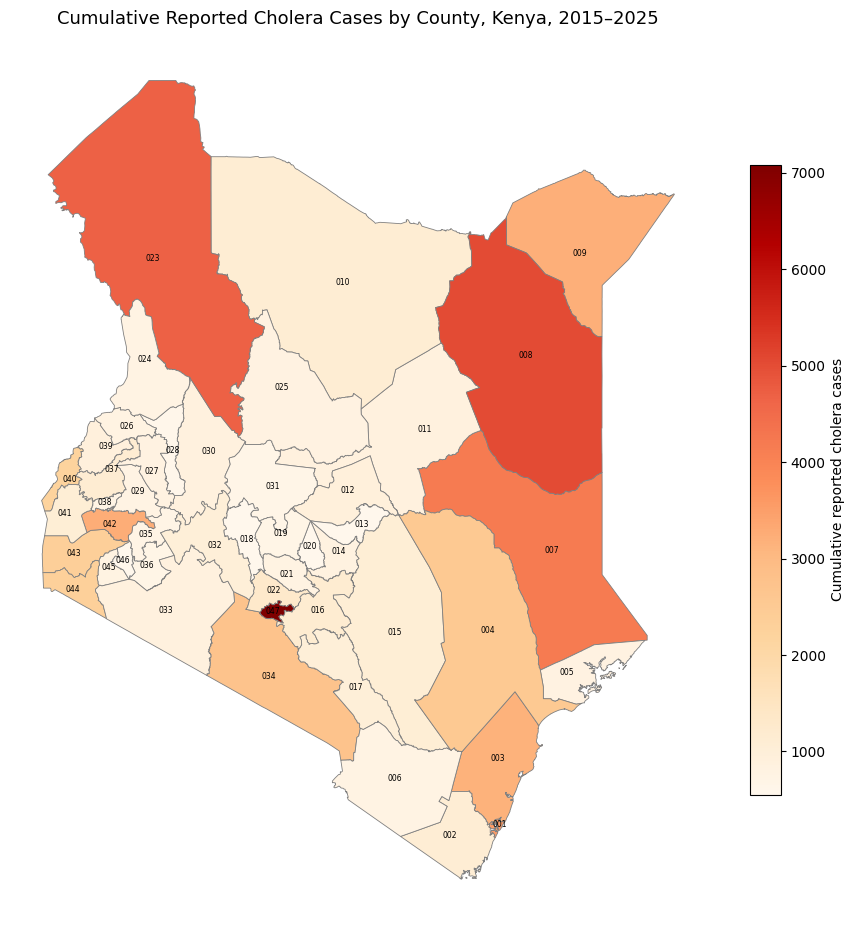

In [186]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(9, 10)
)

kenya_map.plot(
    column="total_cases_2015_2025",
    cmap="OrRd",
    linewidth=0.6,
    edgecolor="grey",
    legend=True,
    ax=ax,
    legend_kwds={
        "label": "Cumulative reported cholera cases",
        "shrink": 0.65
    }
)

# Add official county codes
for _, row in label_points.iterrows():

    ax.text(
        row.geometry.x,
        row.geometry.y,
        row["county_code"],
        ha="center",
        va="center",
        fontsize=5.5
    )

ax.set_title(
    "Cumulative Reported Cholera Cases by County, Kenya, 2015–2025",
    fontsize=13,
    pad=12
)

ax.axis("off")

plt.tight_layout()
plt.show()


**Interpretation.** This output confirms that the required software tools for this stage are available before the analysis continues.


In [187]:
county_key = (
    kenya_map[
        [
            "county_code",
            "county_clean"
        ]
    ]
    .drop_duplicates()
    .sort_values("county_code")
    .reset_index(drop=True)
)

county_key.columns = [
    "Code",
    "County"
]

display(county_key)


,Code,County
0,001,Mombasa
1,002,Kwale
2,003,Kilifi
3,004,Tana River
4,005,Lamu
5,006,Taita Taveta
6,007,Garissa
7,008,Wajir
8,009,Mandera
9,010,Marsabit


**Interpretation.** This output documents the result of the step above and provides a checkpoint before the workflow moves on. It is retained so that the analytical decisions can be followed from data preparation through model evaluation.


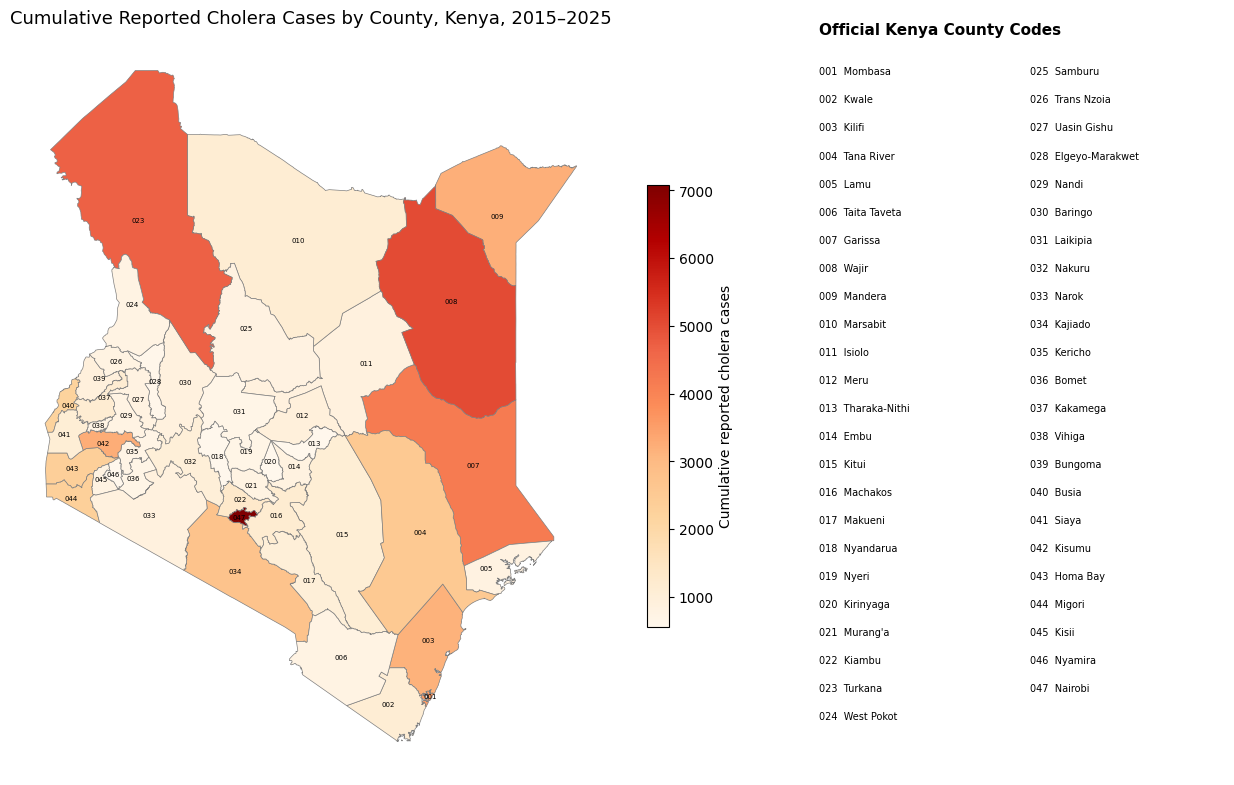

In [188]:
import matplotlib.pyplot as plt

fig = plt.figure(
    figsize=(14, 9)
)

# Main map
map_ax = fig.add_axes(
    [0.03, 0.08, 0.62, 0.82]
)

kenya_map.plot(
    column="total_cases_2015_2025",
    cmap="OrRd",
    linewidth=0.5,
    edgecolor="grey",
    legend=True,
    ax=map_ax,
    legend_kwds={
        "label": "Cumulative reported cholera cases",
        "shrink": 0.60
    }
)

for _, row in label_points.iterrows():

    map_ax.text(
        row.geometry.x,
        row.geometry.y,
        row["county_code"],
        ha="center",
        va="center",
        fontsize=5
    )

map_ax.set_title(
    "Cumulative Reported Cholera Cases by County, Kenya, 2015–2025",
    fontsize=13,
    pad=10
)

map_ax.axis("off")


# County-code key
key_ax = fig.add_axes(
    [0.68, 0.08, 0.29, 0.82]
)

key_ax.axis("off")

key_ax.text(
    0,
    1.02,
    "Official Kenya County Codes",
    fontsize=11,
    fontweight="bold",
    va="top"
)

# Divide the 47 counties into two columns
half = 24

left_key = county_key.iloc[:half]
right_key = county_key.iloc[half:]

y_start = 0.96
line_spacing = 0.038

for i, (_, row) in enumerate(left_key.iterrows()):

    key_ax.text(
        0.00,
        y_start - i * line_spacing,
        f"{row['Code']}  {row['County']}",
        fontsize=7,
        va="top"
    )

for i, (_, row) in enumerate(right_key.iterrows()):

    key_ax.text(
        0.52,
        y_start - i * line_spacing,
        f"{row['Code']}  {row['County']}",
        fontsize=7,
        va="top"
    )

plt.show()


**Interpretation.** This output confirms that the required software tools for this stage are available before the analysis continues.


In [189]:
output_map = (
    "/content/drive/MyDrive/"
    "kenya_cholera_burden_map_official_codes.png"
)

fig.savefig(
    output_map,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

print("Final map saved to:")
print(output_map)

print(
    "File exists:",
    os.path.exists(output_map)
)


Final map saved to:
/content/drive/MyDrive/kenya_cholera_burden_map_official_codes.png
File exists: True


**Interpretation.** This output documents the result of the step above and provides a checkpoint before the workflow moves on. It is retained so that the analytical decisions can be followed from data preparation through model evaluation.


In [190]:
print("FINAL MAP AUDIT")
print("-" * 50)

print(
    "Boundary counties:",
    kenya_map["county_clean"].nunique()
)

print(
    "Counties with cholera totals:",
    kenya_map[
        "total_cases_2015_2025"
    ].notna().sum()
)

print(
    "Counties with official codes:",
    kenya_map[
        "county_code"
    ].notna().sum()
)

print(
    "Total cases represented on map:",
    int(
        kenya_map[
            "total_cases_2015_2025"
        ].sum()
    )
)

assert kenya_map["county_clean"].nunique() == 47
assert kenya_map["total_cases_2015_2025"].isna().sum() == 0
assert kenya_map["county_code"].isna().sum() == 0
assert int(
    kenya_map["total_cases_2015_2025"].sum()
) == 75165

print("\nAll checks passed.")


FINAL MAP AUDIT
--------------------------------------------------
Boundary counties: 47
Counties with cholera totals: 47
Counties with official codes: 47
Total cases represented on map: 75165

All checks passed.


**Interpretation.** The final map audit checks that all **47 counties** are represented, all have official county codes and all have case totals after the spatial join. This verifies that the descriptive burden map covers the full national county set.
